# Credit Scoring by Python Programming

Objective : Modelling of

* PD
* LGD
* EAD

and then computation of ECL. Each term would be explained as we proceed.

# Data
Lending club data from Kaggle.
https://www.kaggle.com/datasets/adarshsng/lending-club-loan-data-csv

Lending Club is a peer-to-peer Lending company based in the US. They match people looking to invest money with people looking to borrow money. When investors invest their money through Lending Club, this money is passed onto borrowers, and when borrowers pay their loans back, the capital plus the interest passes on back to the investors. It is a win for everybody as they can get typically lower loan rates and higher investor returns.

The Lending Club dataset contains complete loan data for all loans issued through the 2007-2015, including the current loan status (Current, Late, Fully Paid, etc.) and latest payment information. Features (aka variables) include credit scores, number of finance inquiries, address including zip codes and state, and collections among others. Collections indicates whether the customer has missed one or more payments and the team is trying to recover their money. The file is a matrix of about 890 thousand observations and 75 variables.


In [2]:
# Uploading the loan data description
import pandas as pd

# Reading the xlsx file
desc = pd.read_excel('LCDataDictionary.xlsx')

/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [2]:
desc.head()

,LoanStatNew,Description
0,addr_state,The state provided by the borrower in the loan...
1,annual_inc,The self-reported annual income provided by th...
2,annual_inc_joint,The combined self-reported annual income provi...
3,application_type,Indicates whether the loan is an individual ap...
4,collection_recovery_fee,post charge off collection fee


# DATA DESCRIPTION

saved in a dataframe desc

In [3]:
# Displaying all rows and columns as following
for i in range(len(desc)):
    print(desc.iloc[i, 0]," : ", desc.iloc[i, 1])

addr_state  :  The state provided by the borrower in the loan application
annual_inc  :  The self-reported annual income provided by the borrower during registration.
annual_inc_joint  :  The combined self-reported annual income provided by the co-borrowers during registration
application_type  :  Indicates whether the loan is an individual application or a joint application with two co-borrowers
collection_recovery_fee  :  post charge off collection fee
collections_12_mths_ex_med  :  Number of collections in 12 months excluding medical collections
delinq_2yrs  :  The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years
desc  :  Loan description provided by the borrower
dti  :  A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income.
dti_joint  :  A ratio calculated using the co-borrowers' tot

In [4]:
desc.set_index('LoanStatNew', inplace=True) # Setting the index to LoanStatNew
desc.head()

,Description
LoanStatNew,
addr_state,The state provided by the borrower in the loan...
annual_inc,The self-reported annual income provided by th...
annual_inc_joint,The combined self-reported annual income provi...
application_type,Indicates whether the loan is an individual ap...
collection_recovery_fee,post charge off collection fee


*Date of Calculation i.e Reference date is 01, December, 2017*

In [5]:
#importing the crucial libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Data Preparation

importing loan data and proceeding forward...

In [32]:
loan_data_backup = pd.read_csv('loan_data_2007_2014.csv') # Reading the csv file
# data backup to avoid any data loss
loan_data = loan_data_backup.copy() # Copying the data to loan_data



/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/3658994392.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  loan_data_backup = pd.read_csv('loan_data_2007_2014.csv') # Reading the csv file


In [7]:
pd.options.display.max_columns = None # Displaying all columns
# Displaying the first 10 rows
pd.options.display.max_rows = 10 # Displaying all rows
loan_data.head(10)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.00,0.00,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.00,0.00,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.00,0.00,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.90,766.90,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,1075269,1311441,5000,5000,5000.0,36 months,7.90,156.46,A,A4,Veolia Transportaton,3 years,RENT,36000.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,wedding,My wedding loan I promise to pay back,852xx,AZ,11.20,0.0,Nov-04,3.0,NaN,NaN,9.0,0.0,7963,28.3,12.0,f,0.00,0.00,5631.377753,5631.38,5000.00,631.38,0.00,0.00,0.00,Jan-15,161.03,NaN,Sep-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,1069639,1304742,7000,7000,7000.0,60 months,15.96,170.08

In [796]:
loan_data['id'].nunique() # Checking the unique values in id column

466285

In [8]:
loan_data.info() # Displaying the information of the data



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

* The data has 466285 rows and 75 columns
* There are columns with missing values
* The data types of the columns are float64, int64 and object

# General Preprocessing

Preprocessing few continuous variables

In [9]:
# Looking into emp_length column
loan_data['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [33]:
# Converting the emp_length column to numeric

dict = { "10+ years": 10,
        '< 1 year': 0,
        '1 year': 1,
        '3 years': 3,
        '8 years': 8,
        '9 years': 9,
        '4 years': 4,
        '5 years': 5,
        '6 years': 6,
        '2 years': 2,
        '7 years': 7,
        'n/a': np.nan}

loan_data['emp_length'] = loan_data['emp_length'].map(dict)



In [11]:
loan_data['emp_length'] # emp_length column after conversion to numeric

0         10.0
1          0.0
2         10.0
3         10.0
4          1.0
          ... 
466280     4.0
466281    10.0
466282     7.0
466283     3.0
466284    10.0
Name: emp_length, Length: 466285, dtype: float64

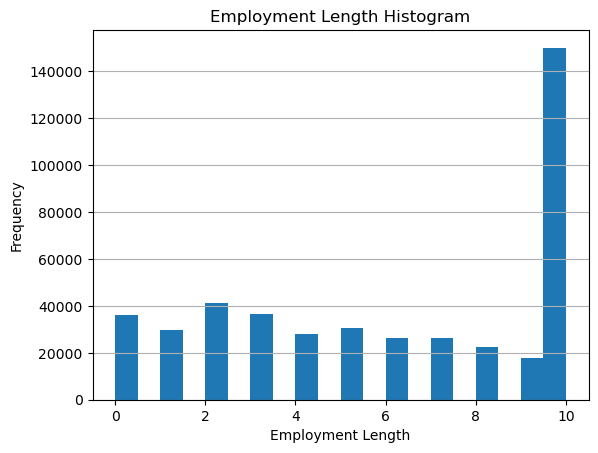

In [12]:
# Plotting the histogram of the emp_length column
loan_data['emp_length'].plot(kind = 'hist', bins = 20)
plt.xlabel('Employment Length')
plt.ylabel('Frequency')
plt.title('Employment Length Histogram')
plt.grid(axis='y')
plt.show()

In [13]:
# Considering the term column
loan_data['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [34]:
loan_data['term'] = loan_data['term'].apply(lambda x: int(x.split()[0])) # Converting the term column to numeric

In [15]:
loan_data['term'] # term column after conversion to numeric

0         36
1         60
2         36
3         36
4         60
          ..
466280    60
466281    60
466282    60
466283    36
466284    36
Name: term, Length: 466285, dtype: int64

In [16]:
# Looking at the earliest_cr_line column
loan_data['earliest_cr_line'].head(5)

# This looks like a date column, so we need to convert it to date format

0    Jan-85
1    Apr-99
2    Nov-01
3    Feb-96
4    Jan-96
Name: earliest_cr_line, dtype: object

In [17]:
loan_data['earliest_cr_line'].isnull().sum()

# Argh! There are some missing values in the earliest_cr_line column as well

29

In [35]:
# We need to convert the earliest_cr_line column to date format
# First we convert the year to 4 digits like 85 converted to 1985 and 
# 03 converted to 2003



y = loan_data['earliest_cr_line'].apply(lambda x: x.split('-')[1] if isinstance(x, str) else x)

y = y.apply(lambda x: ('19'+x if int(x) > 17 else '20'+x) if isinstance(x, str) else x)

z = loan_data['earliest_cr_line'].apply(lambda x: x.split('-')[0] if isinstance(x, str) else x)


In [36]:
# Here we first add day 01 to the month and year and 
# then convert it to date format
earliest_cr_line = '01-'+ z + '-' + y # Create a string for date conversion
earliest_cr_line = pd.to_datetime(earliest_cr_line, format = '%d-%b-%Y') # Converting to date format

In [37]:
loan_data['earliest_cr_line_date'] = earliest_cr_line
loan_data['earliest_cr_line_date'].sort_values(ascending = True).head(10)

# So the date conversion was successful!

421431   1944-01-01
14118    1946-01-01
259702   1946-08-01
440091   1948-01-01
363960   1949-06-01
453054   1950-05-01
429024   1950-10-01
140828   1950-11-01
15315    1950-12-01
290492   1951-01-01
Name: earliest_cr_line_date, dtype: datetime64[ns]

In [38]:
# Finding the number of months since the earliest credit line
# We will use the reference date as 1st December 2017
import datetime as dt
reference_date = pd.to_datetime('2017-12-01') # Setting the reference date
avg_month_length = 30.44 # Average number of days in a month
months_since_earliest_cr = round((reference_date - loan_data['earliest_cr_line_date']).dt.days / avg_month_length) # Calculating the difference in days
loan_data['months_since_earliest_cr'] = months_since_earliest_cr # Storing the result in the DataFrame

In [22]:
loan_data['months_since_earliest_cr'].describe() # Describing the months_since_earliest_cr column
# minimum months is 73 and maximum months is 887

count    466256.000000
mean        242.491078
std          86.928944
min          73.000000
25%         184.000000
50%         226.000000
75%         285.000000
max         887.000000
Name: months_since_earliest_cr, dtype: float64

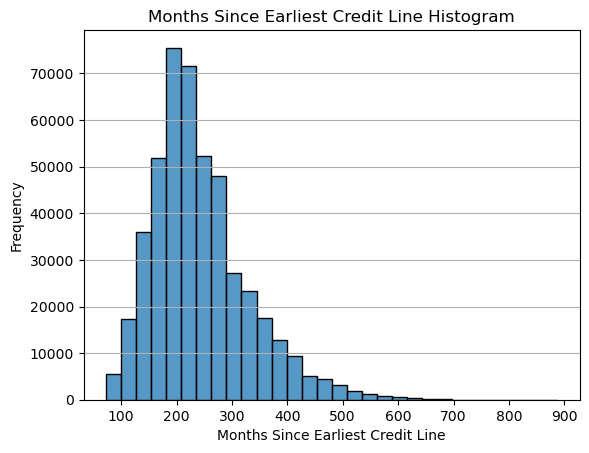

In [26]:
sns.histplot(data=loan_data, x='months_since_earliest_cr', bins=30) # Plotting the histogram of the months_since_earliest_cr column
plt.xlabel('Months Since Earliest Credit Line')
plt.ylabel('Frequency')
plt.title('Months Since Earliest Credit Line Histogram')
plt.grid(axis='y')
plt.show()

In [27]:
# Lets look into the issue_d column
desc.loc['issue_d']

Description    The month which the loan was funded
Name: issue_d, dtype: object

In [28]:
loan_data['issue_d'].head()

# this looks similar to the earliest_cr_line column
# so we will convert it to date format just like we 
# did for earliest_cr_line column

0    Dec-11
1    Dec-11
2    Dec-11
3    Dec-11
4    Dec-11
Name: issue_d, dtype: object

In [29]:
loan_data['issue_d'].isnull().sum()

# Thank God! It has no missing values.

0

In [39]:
# We need to convert the issue_d column to date format
# First we convert the year to 4 digits like 85 converted to 1985 and 
# 03 converted to 2003



y = loan_data['issue_d'].apply(lambda x: x.split('-')[1] if isinstance(x, str) else x)

y = y.apply(lambda x: ('19'+x if int(x) > 17 else '20'+x) if isinstance(x, str) else x)

z = loan_data['issue_d'].apply(lambda x: x.split('-')[0] if isinstance(x, str) else x)


In [40]:
# Here we first add day 01 to the month and year and 
# then convert it to date format
issue_d = '01-'+ z + '-' + y # Create a string for date conversion
issue_d = pd.to_datetime(issue_d, format = '%d-%b-%Y') # Converting to date format

In [41]:
# Finding the number of months since the issue date
# We will use the reference date as 1st December 2017
import datetime as dt
reference_date = pd.to_datetime('2017-12-01') # Setting the reference date
avg_month_length = 30.44 # Average number of days in a month
months_since_issue_d = round((reference_date - issue_d).dt.days / avg_month_length) # Calculating the difference in days
loan_data['months_since_issue_d'] = months_since_issue_d # Storing the result in the DataFrame

In [34]:
loan_data['months_since_issue_d'].describe() # Describing the months_since_issue_d column

count    466285.000000
mean         51.255187
std          14.340154
min          36.000000
25%          41.000000
50%          47.000000
75%          57.000000
max         126.000000
Name: months_since_issue_d, dtype: float64

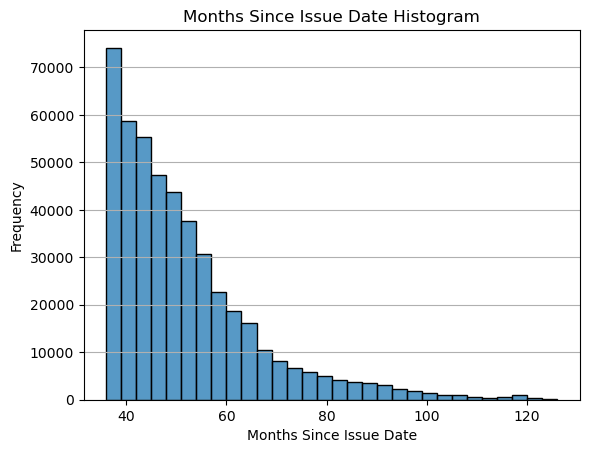

In [35]:
sns.histplot(data=loan_data, x='months_since_issue_d', bins=30) # Plotting the histogram of the months_since_issue_d column
plt.xlabel('Months Since Issue Date') # Setting the x-axis label
plt.ylabel('Frequency')
plt.title('Months Since Issue Date Histogram')
plt.grid(axis='y')
plt.show()

In [42]:
# Now lets remove these date columns as we have got them into month data
loan_data = loan_data.drop(['earliest_cr_line', 'issue_d', 'earliest_cr_line_date'], axis=1) # Dropping the earliest_cr_line and issue_d
loan_data.head() # Displaying the first few rows of the updated DataFrame

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,months_since_earliest_cr,months_since_issue_d
0,0,1077501,1296599,5000,5000,4975.0,36,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,395.0,72.0
1,1,1077430,1314167,2500,2500,2500.0,60,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,224.0,72.0
2,2,1077175,1313524,2400,2400,2400.0,36,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,193.0,72.0
3,3,1076863,1277178,10000,10000,10000.0,36,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,262.0,72.0
4,4,1075358,1311748,3000,3000,3000.0,60,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,263.0,72.0


In [43]:
# There are three more such columns which are in date format
# These are last_pymnt_d, last_credit_pull_d and next_pymnt_d
# For how many times i have to do this? :(
# Better to write a function for this
def date_to_months(column):
    y = loan_data[column].apply(lambda x: x.split('-')[1] if isinstance(x, str) else x)
    y = y.apply(lambda x: ('19'+x if int(x) > 17 else '20'+x) if isinstance(x, str) else x)
    z = loan_data[column].apply(lambda x: x.split('-')[0] if isinstance(x, str) else x)
    date = '01-'+ z + '-' + y
    date = pd.to_datetime(date, format = '%d-%b-%Y')
    reference_date = pd.to_datetime('2017-12-01')
    avg_month_length = 30.44
    months_since_date = round((reference_date - date).dt.days / avg_month_length)
    loan_data['months_since_' + column] = months_since_date
    loan_data.drop(column, axis=1, inplace=True)

In [44]:
# Lets do this for the last_pymnt_d, last_credit_pull_d and next_pymnt_d columns
date_to_months('last_pymnt_d')
date_to_months('last_credit_pull_d')
date_to_months('next_pymnt_d')


Preprocessing a few Categorical variables

In [45]:
# Finding the non numeric columns
non_numeric_columns = loan_data.select_dtypes(include=['object']).columns # Selecting the non numeric columns   
non_numeric_columns # Displaying the non numeric columns

Index(['grade', 'sub_grade', 'emp_title', 'home_ownership',
       'verification_status', 'loan_status', 'pymnt_plan', 'url', 'desc',
       'purpose', 'title', 'zip_code', 'addr_state', 'initial_list_status',
       'application_type'],
      dtype='object')

In [46]:
# What is with emp-title?
unique_emp_titles = loan_data['emp_title'].nunique() # Finding the number of unique employment titles
print(f"Number of unique employment titles: {unique_emp_titles}")
# There are 205475 unique titles, so we can't use this column for analysis
# Let's drop this column
loan_data.drop('emp_title', axis=1, inplace=True) # Dropping the emp_title column

Number of unique employment titles: 205475


In [41]:
# What about grade?
unique_grades = loan_data['grade'].unique() # Storing unique values in a variable
print(unique_grades) # Displaying the unique values in the grade column

# We shall keep this column as it is a categorical column

['B' 'C' 'A' 'E' 'F' 'D' 'G']


In [42]:
grade_counts = loan_data['grade'].value_counts() # Storing the frequency of each grade in a variable
print(grade_counts) # Displaying the frequency of each grade

grade
B    136929
C    125293
D     76888
A     74867
E     35757
F     13229
G      3322
Name: count, dtype: int64


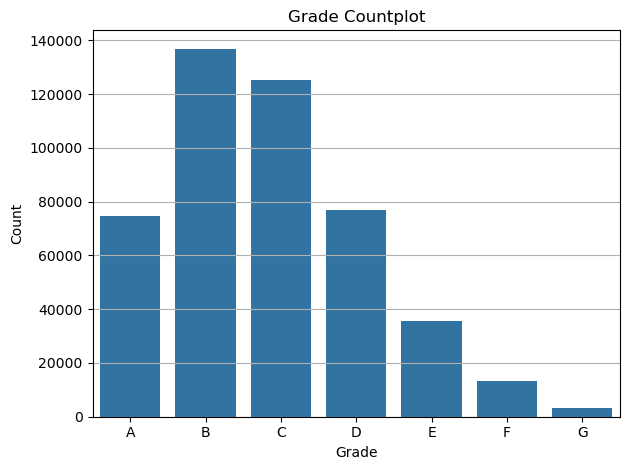

In [43]:
# making a bar plot of the grade column 
ordered_grades = sorted(loan_data['grade'].unique()) # Sorting the grades
sns.countplot(data=loan_data, x='grade', order=ordered_grades) # Creating a countplot of the grade column
plt.xlabel('Grade') # Setting the x-axis label
plt.ylabel('Count') # Setting the y-axis label
plt.title('Grade Countplot') # Setting the title of the plot
plt.grid(axis='y')

plt.tight_layout()
plt.show() # Displaying the plot

In [44]:
# What about sub_grade?
unique_sub_grades = loan_data['sub_grade'].unique() # Storing unique values in a variable
print(unique_sub_grades) # Displaying the unique values in the sub_grade column
# We shall keep this column as it is a categorical column

['B2' 'C4' 'C5' 'C1' 'B5' 'A4' 'E1' 'F2' 'C3' 'B1' 'D1' 'A1' 'B3' 'B4'
 'C2' 'D2' 'A3' 'A5' 'D5' 'A2' 'E4' 'D3' 'D4' 'F3' 'E3' 'F4' 'F1' 'E5'
 'G4' 'E2' 'G3' 'G2' 'G1' 'F5' 'G5']


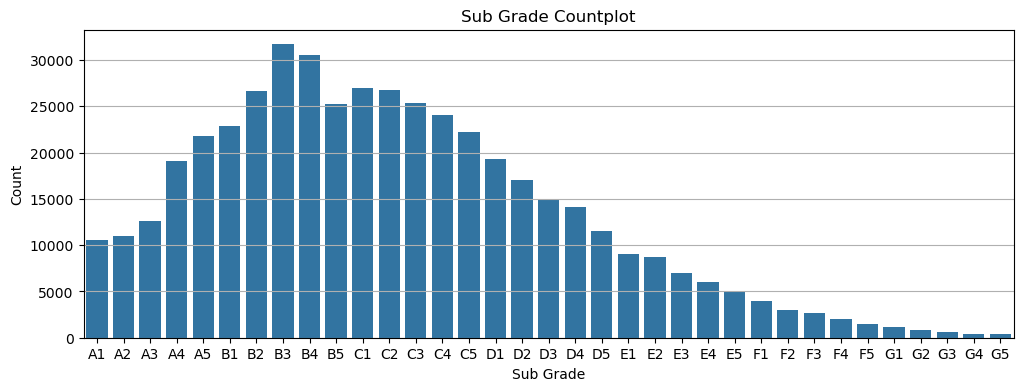

In [45]:
#Plotting the sub_grade column
plt.figure(figsize=(12,4)) # Setting the figure size
sub_grade_order = sorted(loan_data['sub_grade'].unique()) # Sorting the sub_grade column
sns.countplot(data=loan_data, x='sub_grade', order = sub_grade_order) # Creating a countplot
plt.xlabel('Sub Grade') # Setting the x-axis label
plt.ylabel('Count') # Setting the y-axis label
plt.title('Sub Grade Countplot') # Setting the title of the plot
plt.grid(axis='y')
plt.show() # Displaying the plot

In [46]:
sub_grade_counts = loan_data['sub_grade'].value_counts() # Storing the frequency of each sub_grade in a variable
print(sub_grade_counts) # Displaying the frequency of each sub_grade


sub_grade
B3    31686
B4    30505
C1    26953
C2    26740
B2    26610
C3    25317
B5    25252
C4    24105
B1    22876
C5    22178
A5    21757
D1    19261
A4    19045
D2    17046
D3    14916
D4    14099
A3    12568
D5    11566
A2    10956
A1    10541
E1     9033
E2     8669
E3     6976
E4     5992
E5     5087
F1     3940
F2     3001
F3     2708
F4     2067
F5     1513
G1     1109
G2      823
G3      583
G4      422
G5      385
Name: count, dtype: int64


In [47]:
# What about home_ownership?
unique_home_ownership = loan_data['home_ownership'].unique() # Storing unique values in a variable
print(unique_home_ownership) # Displaying the unique values in the home_ownership column

# We keep the home_ownership column as it is a categorical column

['RENT' 'OWN' 'MORTGAGE' 'OTHER' 'NONE' 'ANY']


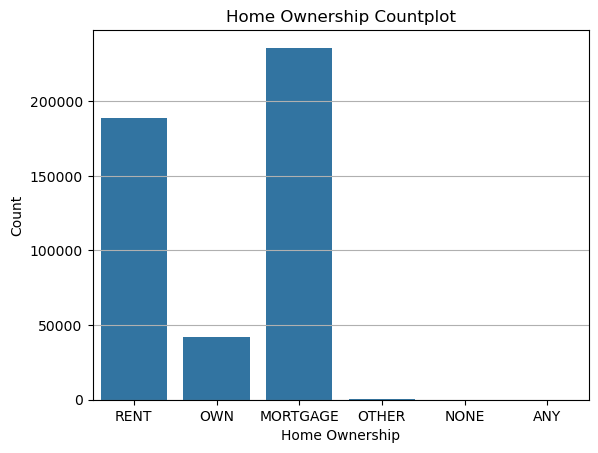

In [48]:
#Plottin the home_ownership column
sns.countplot(data=loan_data, x='home_ownership') # Creating a countplot of the home_ownership column
plt.xlabel('Home Ownership') # Setting the x-axis label
plt.ylabel('Count') # Setting the y-axis label
plt.title('Home Ownership Countplot') # Setting the title of the plot
plt.grid(axis='y')
plt.show() # Displaying the plot

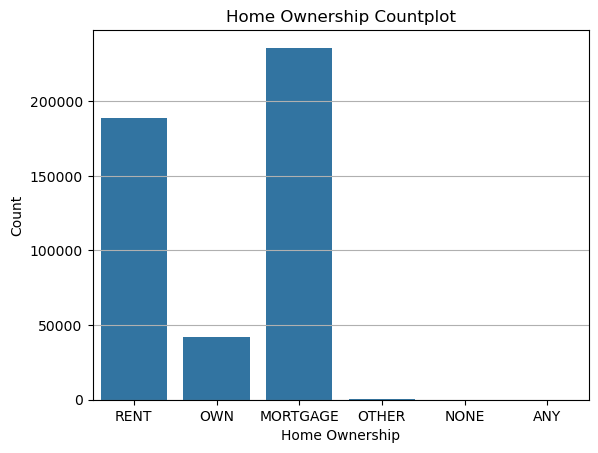

In [31]:


# Plotting the home_ownership column again!
sns.countplot(data=loan_data, x='home_ownership') # Creating a countplot of the home_ownership column
plt.xlabel('Home Ownership') # Setting the x-axis label
plt.ylabel('Count') # Setting the y-axis label
plt.title('Home Ownership Countplot') # Setting the title of the plot
plt.grid(axis='y')
plt.show() # Displaying the plot

In [49]:
# Lets look into verification_status
unique_verification_status = loan_data['verification_status'].unique() # Storing unique values in a variable
print(unique_verification_status) # Displaying the unique values in the verification_status column

# Is there any difference between Verified and Source Verified?
# Only the client knows the difference!
# We keep this column as it is a categorical

['Verified' 'Source Verified' 'Not Verified']


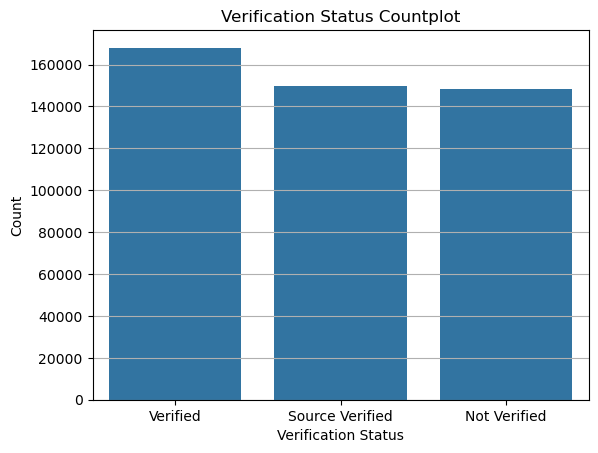

In [50]:
#Plotting the verification_status column
sns.countplot(data=loan_data, x='verification_status') # Creating a countplot of the verification_status column
plt.xlabel('Verification Status') # Setting the x-axis label
plt.ylabel('Count') # Setting the y-axis label
plt.title('Verification Status Countplot') # Setting the title of the plot
plt.grid(axis='y')
plt.show() # Displaying the plot

In [51]:
# Lets look into loan_status
unique_loan_status = loan_data['loan_status'].unique() # Storing unique values in a variable
print(unique_loan_status) # Displaying the unique values in the loan_status column
n_unique_loan_status = loan_data['loan_status'].nunique() # Finding the number of unique loan statuses
print(f"Number of unique loan statuses: {n_unique_loan_status}") # Displaying the number of unique loan statuses

# Loan status is our target variable and we shall refine it later!

['Fully Paid' 'Charged Off' 'Current' 'Default' 'Late (31-120 days)'
 'In Grace Period' 'Late (16-30 days)'
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']
Number of unique loan statuses: 9


In [47]:
# What is pymnt_plan?
unique_pymnt_plan = loan_data['pymnt_plan'].unique() # Storing unique values in a variable
print(unique_pymnt_plan) # Displaying the unique values in the pymnt_plan column
n_unique_pymnt_plan = loan_data['pymnt_plan'].nunique() # Finding the number of unique pymnt_plan
print(f"Number of unique pymnt_plan: {n_unique_pymnt_plan}") # Displaying the number of unique pymnt_plan
# Let's explore other features related to payment plans for further analysis.


pymnt_plan_counts = loan_data['pymnt_plan'].value_counts(normalize=True) # Storing the frequency of each pymnt_plan in a variable
print(pymnt_plan_counts)

# We shall drop this column as it has only one unique value 'n' 99% of the time
loan_data.drop('pymnt_plan', axis=1, inplace=True) # Dropping the pymnt_plan column
    

['n' 'y']
Number of unique pymnt_plan: 2
pymnt_plan
n    0.999981
y    0.000019
Name: proportion, dtype: float64


In [48]:
# Lets look into url and desc columns
print('No of unique url: ', loan_data['url'].nunique()) # Displaying the unique counts of the url column
print('No of unique desc: ', loan_data['desc'].nunique()) # Displaying the unique counts of the desc column
# These are not categorical columns and have too many unique values
# We shall drop these columns
loan_data.drop(['url', 'desc'], axis=1, inplace=True) # Dropping the url and desc columns

No of unique url:  466285
No of unique desc:  124435


In [54]:
# What about purpose?
unique_purpose = loan_data['purpose'].unique() # Storing unique values in a variable
print(unique_purpose) # Displaying the
# unique values in the purpose column
n_unique_purpose = loan_data['purpose'].nunique() # Finding the number of unique purposes
print(f"Number of unique purposes: {n_unique_purpose}") # Displaying the number
# of unique purposes
# We will keep this column as it is a categorical column

['credit_card' 'car' 'small_business' 'other' 'wedding'
 'debt_consolidation' 'home_improvement' 'major_purchase' 'medical'
 'moving' 'vacation' 'house' 'renewable_energy' 'educational']
Number of unique purposes: 14


In [49]:
# What about the columns : 'title', 'zip_code', 'addr_state'?
print('No of unique title: ', loan_data['title'].nunique()) # Displaying the unique counts of the title column
print('No of unique zip_code: ', loan_data['zip_code'].nunique()) # Displaying the unique counts of the zip_code column
print('No of unique addr_state: ', loan_data['addr_state'].nunique()) # Displaying the unique counts of the addr_state column

# Title and zip_code have too many unique values

# We shall drop these columns
loan_data.drop(['title', 'zip_code'], axis=1, inplace=True) # Dropping the title and zip_code columns

No of unique title:  63098
No of unique zip_code:  888
No of unique addr_state:  50


In [56]:
# What about addr_state?
unique_addr_state = loan_data['addr_state'].unique() # Storing unique values in a variable
print(unique_addr_state) # Displaying the unique values in the addr_state column
# We shall keep the addr_state column as it is a categorical column

['AZ' 'GA' 'IL' 'CA' 'OR' 'NC' 'TX' 'VA' 'MO' 'CT' 'UT' 'FL' 'NY' 'PA'
 'MN' 'NJ' 'KY' 'OH' 'SC' 'RI' 'LA' 'MA' 'WA' 'WI' 'AL' 'CO' 'KS' 'NV'
 'AK' 'MD' 'WV' 'VT' 'MI' 'DC' 'SD' 'NH' 'AR' 'NM' 'MT' 'HI' 'WY' 'OK'
 'DE' 'MS' 'TN' 'IA' 'NE' 'ID' 'IN' 'ME']


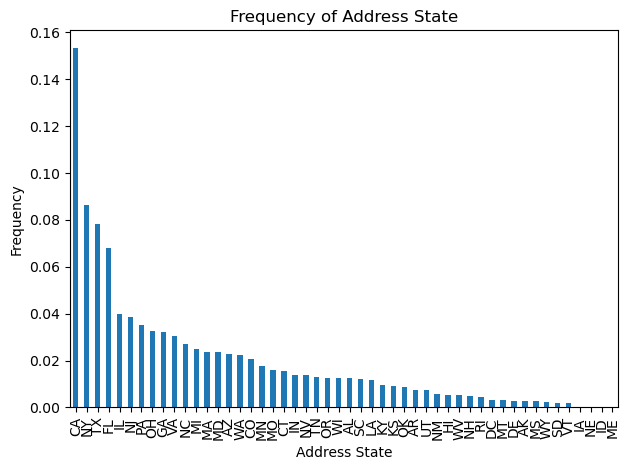

In [57]:
# Displaying the frequency of each addr_state
addr_state_counts = loan_data['addr_state'].value_counts(normalize=True)

# Visualizing the frequency distribution
addr_state_counts.plot(kind='bar', title='Frequency of Address State', ylabel='Frequency', xlabel='Address State')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [58]:
# Lets look into initial_list_status
unique_initial_list_status = loan_data['initial_list_status'].unique() # Storing unique values in a variable
print(unique_initial_list_status) # Displaying the unique values in the initial_list_status column
# We shall keep the initial_list_status column as it is a categorical column

['f' 'w']


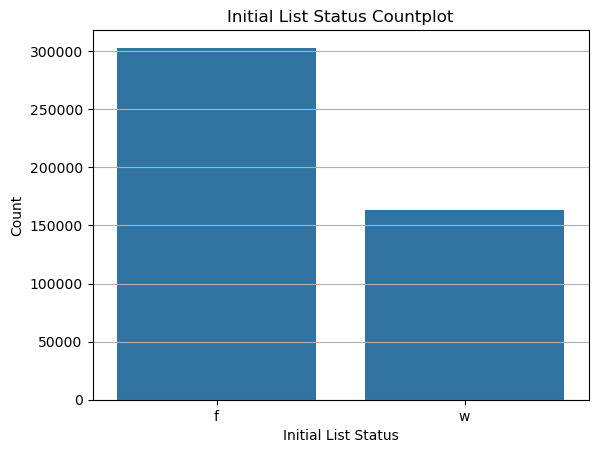

In [59]:
#plotting the initial_list_status column
sns.countplot(data=loan_data, x='initial_list_status') # Creating a countplot of the initial_list_status column
plt.xlabel('Initial List Status') # Setting the x-axis label
plt.ylabel('Count') # Setting the y-axis label
plt.title('Initial List Status Countplot') # Setting the title of the plot
plt.grid(axis='y')
plt.show() # Displaying the plot

In [60]:
# Finally, lets look in the application_type column
unique_application_type = loan_data['application_type'].unique() # Storing unique values in a variable
print(unique_application_type) # Displaying the unique values in the application_type column

['INDIVIDUAL']


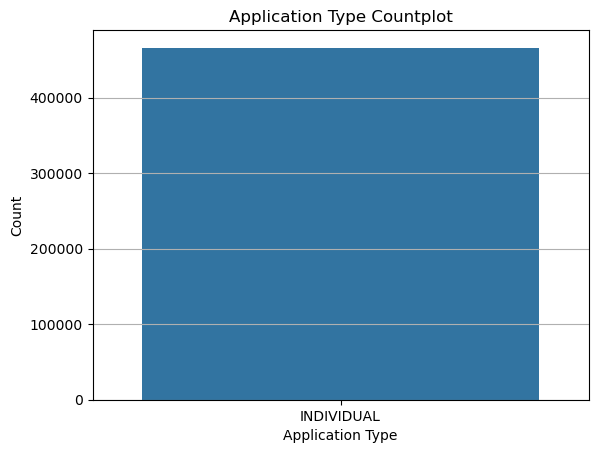

In [61]:
#plotting the application_type column
sns.countplot(data=loan_data, x='application_type') # Creating a countplot of the application_type column
plt.xlabel('Application Type') # Setting the x-axis label
plt.ylabel('Count') # Setting the y-axis label
plt.title('Application Type Countplot') # Setting the title of the plot
plt.grid(axis='y')
plt.show() # Displaying the plot

In [50]:

# All values are 'INDIVIDUAL', so better to drop this column
loan_data.drop('application_type', axis=1, inplace=True) # Dropping the application_type column

# Check for Missing Values 

In [51]:
pd.options.display.max_rows = None # Displaying all rows
missing_percentage = pd.DataFrame((loan_data.isnull().sum().sort_values(ascending=False)/len(loan_data))*100) # Finding the missing values in each column
missing_percentage.columns = ['Missing Percentage'] # Renaming the column
missing_percentage.head(40) # Displaying the missing values in each column

,Missing Percentage
all_util,100.000000
open_il_6m,100.000000
open_rv_12m,100.000000
open_rv_24m,100.000000
open_il_24m,100.000000
max_bal_bc,100.000000
open_il_12m,100.000000
mths_since_rcnt_il,100.000000
inq_fi,100.000000
total_bal_il,100.000000


In [52]:
# Finding columns having missing values == 100%
missing_cols = missing_percentage[missing_percentage['Missing Percentage'] == 100].index # Finding columns having missing values == 100%
missing_cols = missing_cols.tolist() # Converting the columns to a list
missing_cols # Displaying the columns having missing values == 100%

['all_util',
 'open_il_6m',
 'open_rv_12m',
 'open_rv_24m',
 'open_il_24m',
 'max_bal_bc',
 'open_il_12m',
 'mths_since_rcnt_il',
 'inq_fi',
 'total_bal_il',
 'total_cu_tl',
 'inq_last_12m',
 'open_acc_6m',
 'verification_status_joint',
 'dti_joint',
 'annual_inc_joint',
 'il_util']

In [53]:
# Lets first remove the missing_cols which have missing values > 100%""
loan_data.drop(missing_cols, axis=1, inplace=True) # Dropping the columns having missing values > 48%

In [54]:
#Consider the column total_rev_hi_lim
# total_rev_hi_lim is the total revolving high credit/credit limit
# This column is important and we can't drop it
# We replace the missing values by funded_amount of corresponding loan
loan_data['total_rev_hi_lim'] = loan_data['total_rev_hi_lim'].fillna(loan_data['funded_amnt']) # Replacing the missing values by funded_amnt

In [55]:
loan_data['total_rev_hi_lim'].isnull().sum() # Checking if there are any missing values in the total_rev_hi_lim column

0

In [56]:
# Check for the missing values in Annual Income
loan_data['annual_inc'].isnull().sum() # Checking if there are any missing values in the annual_inc column
# Only 4 missing values in the annual_inc column

4

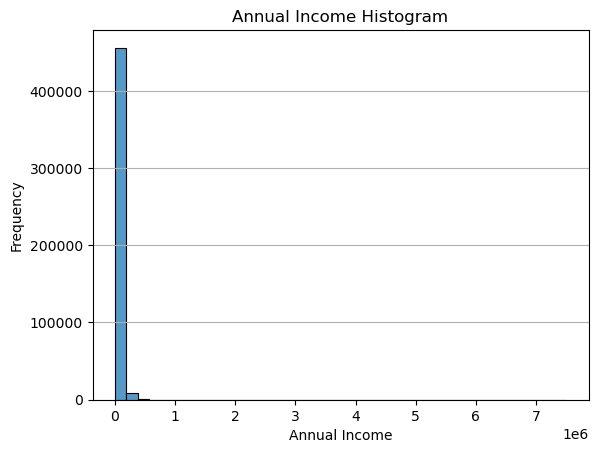

In [69]:
sns.histplot(data=loan_data, x='annual_inc', bins=40) # Creating a histogram of the annual_inc column
plt.xlabel('Annual Income') # Setting the x-axis label
plt.ylabel('Frequency') # Setting the y-axis label
plt.title('Annual Income Histogram') # Setting the title of the plot
plt.grid(axis='y')
plt.show() # Displaying the plot

In [57]:
# Seeing the histogram, we can replace the missing values by the median of the column
loan_data['annual_inc'] = loan_data['annual_inc'].fillna(loan_data['annual_inc'].median()) # Replacing the missing values by the median of the column

In [68]:
# Lets consider the following columns

#‘mths_since_earliest_cr_line’

#‘acc_now_delinq’

#‘total_acc’

#‘pub_rec’

#‘open_acc’

#‘inq_last_6mths’

#‘delinq_2yrs’

#‘emp_length_int’

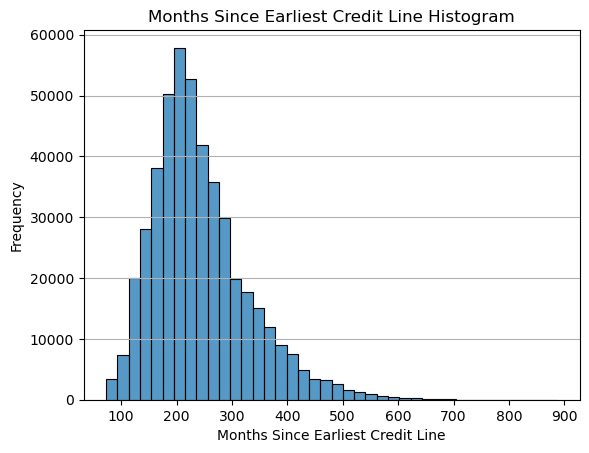

In [71]:
# Plotting a histogram of the mths_since_earliest_cr_line column
sns.histplot(data=loan_data, x='months_since_earliest_cr', bins=40) # Creating a histogram of the mths_since_earliest_cr_line column
plt.xlabel('Months Since Earliest Credit Line') # Setting the x-axis label
plt.ylabel('Frequency') # Setting the y-axis label
plt.title('Months Since Earliest Credit Line Histogram') # Setting the title of the plot
plt.grid(axis='y')
plt.show() # Displaying the plot

In [58]:
# Finding the median of the mths_since_earliest_cr_line column grade wise as an example
median_months_since_earliest_cr = loan_data.groupby('grade')['months_since_earliest_cr'].median() # Finding the median of the months_since_earliest_cr_line column for each grade
print(median_months_since_earliest_cr) # Print the result for better analysis

grade
A    240.0
B    228.0
C    222.0
D    218.0
E    220.0
F    217.0
G    220.0
Name: months_since_earliest_cr, dtype: float64


In [59]:
# Seeing the histogram, we can replace the missing values by the median of the column grade wise
loan_data['months_since_earliest_cr'] = loan_data.groupby('grade')['months_since_earliest_cr'].transform(lambda x: x.fillna(x.median())) # Replacing the missing values by the median of the column grade wise


In [60]:
loan_data['months_since_earliest_cr'].isnull().sum() # Checking if there are any missing values in the months_since_earliest_cr column

0

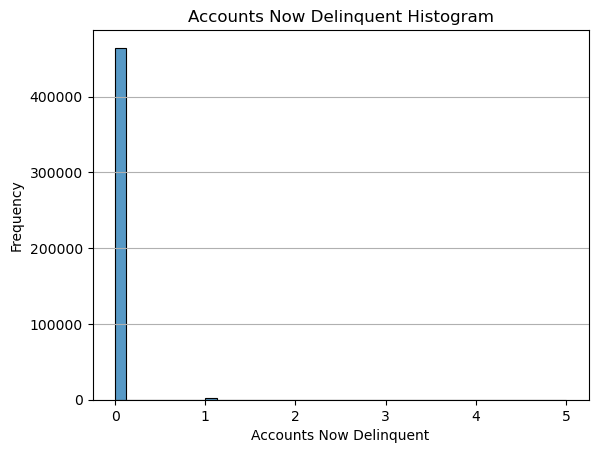

In [75]:
#Plotting the histogram of the acc_now_delinq column
sns.histplot(data=loan_data, x='acc_now_delinq', bins=40) # Creating a histogram of the acc_now_delinq column
plt.xlabel('Accounts Now Delinquent') # Setting the x-axis label
plt.ylabel('Frequency') # Setting the y-axis label
plt.title('Accounts Now Delinquent Histogram') # Setting the title of the plot
plt.grid(axis='y')
plt.show()


In [61]:
# Seeing the histogram, we can replace the missing values by the median of the column
loan_data['acc_now_delinq'] = loan_data['acc_now_delinq'].fillna(loan_data['acc_now_delinq'].median()) # Replacing the missing values by the median of the column

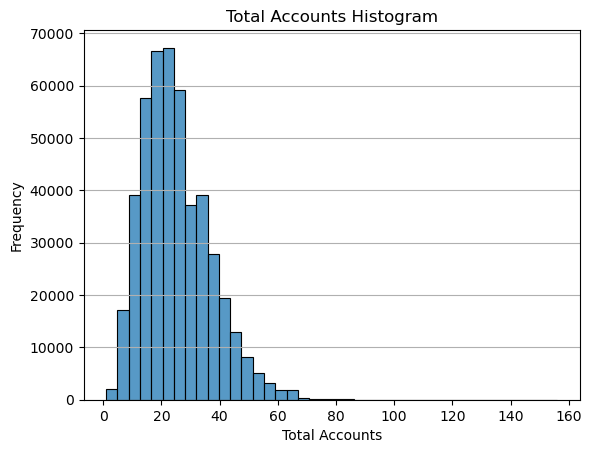

In [77]:
# plottin the histogram of the total_acc column
sns.histplot(data=loan_data, x='total_acc', bins=40) # Creating a histogram of the total_acc column
plt.xlabel('Total Accounts') # Setting the x-axis label
plt.ylabel('Frequency') # Setting the y-axis label
plt.title('Total Accounts Histogram') # Setting the title of the plot
plt.grid(axis='y')
plt.show()


In [62]:
# Seeing the histogram, we can replace the missing values by the median of the column grade wise
loan_data['total_acc'] = loan_data.groupby('grade')['total_acc'].transform(lambda x: x.fillna(x.median())) # Replacing the missing values by the median of the column grade wise

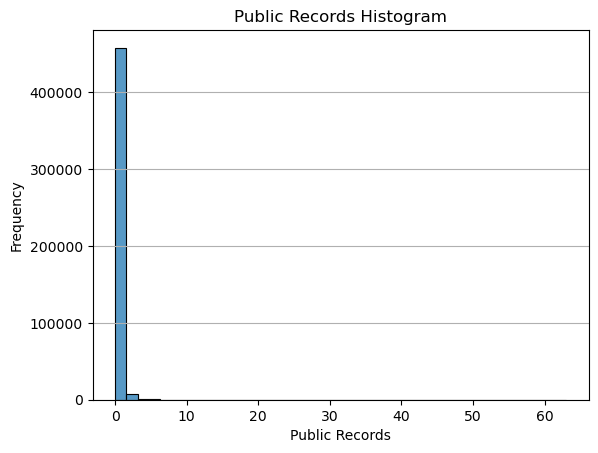

In [79]:
# Going into pub_rec, plotting the histogram
sns.histplot(data=loan_data, x='pub_rec', bins=40) # Creating a histogram of the pub_rec column
plt.xlabel('Public Records') # Setting the x-axis label
plt.ylabel('Frequency') # Setting the y-axis label
plt.title('Public Records Histogram') # Setting the title of the plot
plt.grid(axis='y')
plt.show()

In [63]:
# Seeing the histogram, we can replace the missing values by the median of the column
loan_data['pub_rec'] = loan_data['pub_rec'].fillna(loan_data['pub_rec'].median()) # Replacing the missing values by the median of the column

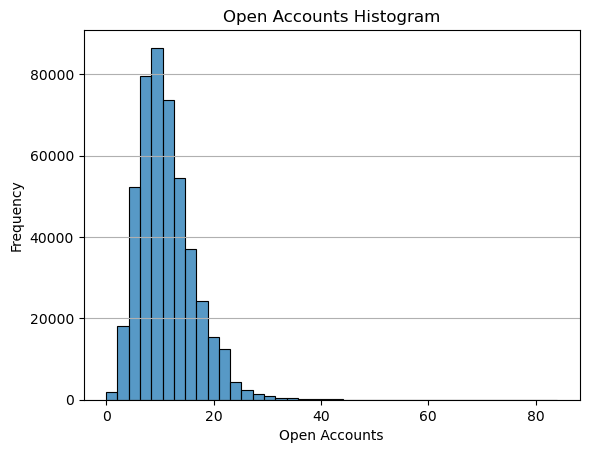

In [81]:
# Going into open_acc, plottin the histogram
sns.histplot(data=loan_data, x='open_acc', bins=40) # Creating a histogram of the open_acc column
plt.xlabel('Open Accounts') # Setting the x-axis label
plt.ylabel('Frequency') # Setting the y-axis label
plt.title('Open Accounts Histogram') # Setting the title of the plot
plt.grid(axis='y')
plt.show()

In [64]:
# Seeing the histogram, we can replace the missing values by the median of the column grade wise
loan_data['open_acc'] = loan_data.groupby('grade')['open_acc'].transform(lambda x: x.fillna(x.median())) # Replacing the missing values by the median of the column grade wise

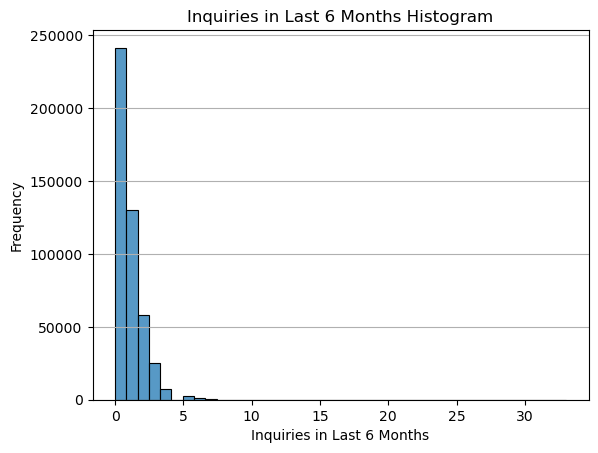

In [83]:
# Look into inq_last_6mths
sns.histplot(data=loan_data, x='inq_last_6mths', bins=40) # Creating a histogram of the inq_last_6mths column
plt.xlabel('Inquiries in Last 6 Months') # Setting the x-axis label
plt.ylabel('Frequency') # Setting the y-axis label
plt.title('Inquiries in Last 6 Months Histogram') # Setting the title of the plot
plt.grid(axis='y')
plt.show()

In [65]:
# Seeing the histogram, we can replace the missing values by the median of the column
loan_data['inq_last_6mths'] = loan_data['inq_last_6mths'].fillna(loan_data['inq_last_6mths'].median()) # Replacing the missing values by the median of the column

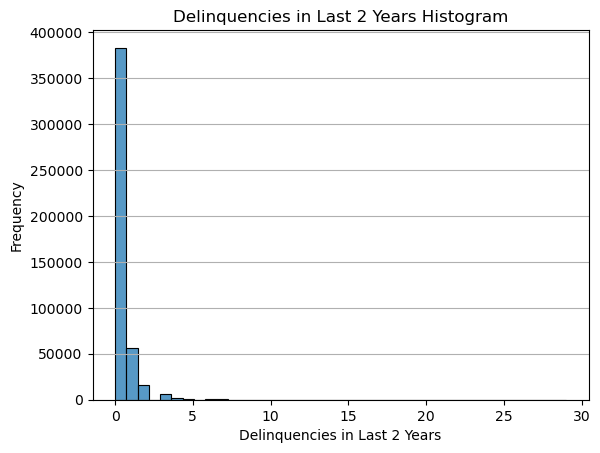

In [85]:
# Looking into delinq_2yrs
sns.histplot(data=loan_data, x='delinq_2yrs', bins=40) # Creating a histogram of the delinq_2yrs column
plt.xlabel('Delinquencies in Last 2 Years') # Setting the x-axis label
plt.ylabel('Frequency') # Setting the y-axis label
plt.title('Delinquencies in Last 2 Years Histogram') # Setting the title of the plot
plt.grid(axis='y')
plt.show()

In [66]:
# Seeing the histogram, we can replace the missing values by the median of the column
loan_data['delinq_2yrs'] = loan_data['delinq_2yrs'].fillna(loan_data['delinq_2yrs'].median()) # Replacing the missing values by the median of the column

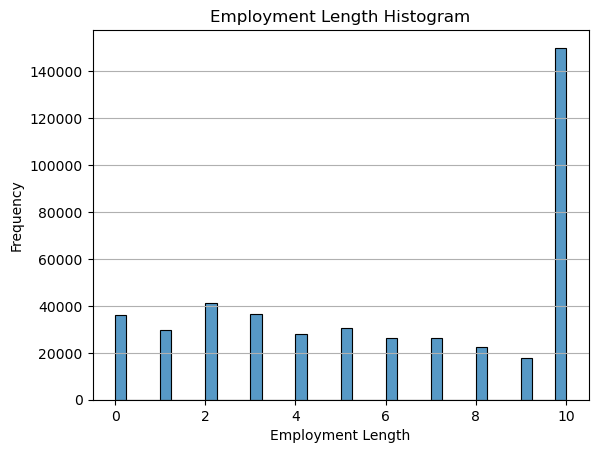

In [87]:
# Looking into emp_length_int
sns.histplot(data=loan_data, x='emp_length', bins=40) # Creating a histogram of the emp_length_int column
plt.xlabel('Employment Length') # Setting the x-axis label
plt.ylabel('Frequency') # Setting the y-axis label
plt.title('Employment Length Histogram') # Setting the title of the plot
plt.grid(axis='y')
plt.show()

In [67]:
# Seeing the histogram, we can replace the missing values by the median of the column grade wise
loan_data['emp_length'] = loan_data.groupby('grade')['emp_length'].transform(lambda x: x.fillna(x.median())) # Replacing the missing values by the median of the column grade wise

In [68]:
# Lets look into the missing values again
pd.options.display.max_rows = None # Displaying all rows
missing_percentage = pd.DataFrame((loan_data.isnull().sum().sort_values(ascending=False)/len(loan_data))*100) # Finding the missing values in each column
missing_percentage.columns = ['Missing Percentage'] # Renaming the column
missing_percentage.head(8) # Displaying the missing values in each column

,Missing Percentage
mths_since_last_record,86.566585
mths_since_last_major_derog,78.773926
mths_since_last_delinq,53.690554
months_since_next_pymnt_d,48.728567
tot_cur_bal,15.071469
tot_coll_amt,15.071469
months_since_last_pymnt_d,0.080637
revol_util,0.072917


In [69]:
# There are still missing values in 8 columns
# Lets find these columns and save them into a list
missing_cols = missing_percentage[missing_percentage['Missing Percentage'] > 0].index # Finding columns having missing values
missing_cols = missing_cols.tolist() # Converting the columns to a list
missing_cols # Displaying the columns having missing values

['mths_since_last_record',
 'mths_since_last_major_derog',
 'mths_since_last_delinq',
 'months_since_next_pymnt_d',
 'tot_cur_bal',
 'tot_coll_amt',
 'months_since_last_pymnt_d',
 'revol_util',
 'collections_12_mths_ex_med',
 'months_since_last_credit_pull_d']

In [70]:
# Lets define a function which can fill the missing values in these columns grade wise
def fill_missing_values(column):
    loan_data[column] = loan_data.groupby('grade')[column].transform(lambda x: x.fillna(x.median())) # Replacing the missing values by the median of the column grade wise

In [71]:
# Using the fill_missing_values function to fill the missing values in the missing_cols
for col in missing_cols:
    fill_missing_values(col)


missing_percentage_after = pd.DataFrame((loan_data.isnull().sum().sort_values(ascending=False)/len(loan_data)) * 100)
missing_percentage_after.columns = ['Missing Percentage']
missing_percentage_after.head(8)


,Missing Percentage
Unnamed: 0,0.0
last_pymnt_amnt,0.0
initial_list_status,0.0
out_prncp,0.0
out_prncp_inv,0.0
total_pymnt,0.0
total_pymnt_inv,0.0
total_rec_prncp,0.0


In [72]:
# Lets drop the Unnamed: 0 column as it is not required
loan_data.drop('Unnamed: 0', axis=1, inplace=True) # Dropping the Unnamed: 0 column

# Missing values resolved

In [ ]:
#id and member_id are not useful for analysis
# But we might need it somewhere in future, so we will keep it for now
#loan_data.drop(['id', 'member_id'], axis=1, inplace=True) # Dropping the id and member_id columns

In [73]:
# Lets look into the columns of the dataframe now
col = loan_data.columns
for i in col:
    print(i)
    


id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_length
home_ownership
annual_inc
verification_status
loan_status
purpose
addr_state
dti
delinq_2yrs
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_amnt
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
acc_now_delinq
tot_coll_amt
tot_cur_bal
total_rev_hi_lim
months_since_earliest_cr
months_since_issue_d
months_since_last_pymnt_d
months_since_last_credit_pull_d
months_since_next_pymnt_d


In [74]:
loan_data.isnull().sum().sum() # Checking if there are any missing values in the DataFrame

0

In [76]:
# write this data to a new csv file
loan_data.to_csv('loan_data_2007_2014_cleaned.csv', index=False) # Writing the cleaned data to a new csv file

# How does the PD Model look like?

 * Default definition of the PD model : Borrower is over 90 days past due
 * Default is Bad Loan taken as 0 and Non Default is Good Loan taken as 1
 * The PD model is a binary classification model
 * The PD model is a logistic regression model
 * ln(odds) = b0 + b1*x1 + b2*x2 + ... + bn*xn , where x1, x2, ... xn are the independent variables
 * odds = p/(1-p) , where p is the probability of non default
    and p = 1/(1+exp(-ln(odds)))
 * The PD model is a probability model
 * PD Model's interpretability should be easy to understand, so that it can be explained to the stakeholders
 * So all independent variables should be dummy variables
 * Both discrete and continuous variables can be used as independent variables but they should be converted to dummy variables
 * The dependent variable is a binary variable i.e Default (0) or Non Default (1)
 * The PD model is a supervised learning model
 * The PD model is a classification model


# PD Model

Dependent Variable preparation

In [75]:
# Consider the loan_status column
loan_data['loan_status'].value_counts(normalize=True) # Displaying the frequency of each loan status

loan_status
Current                                                0.480878
Fully Paid                                             0.396193
Charged Off                                            0.091092
Late (31-120 days)                                     0.014798
In Grace Period                                        0.006747
Does not meet the credit policy. Status:Fully Paid     0.004263
Late (16-30 days)                                      0.002612
Default                                                0.001784
Does not meet the credit policy. Status:Charged Off    0.001632
Name: proportion, dtype: float64

* Fully paid , In Grace Period, Current accounts,
    Does not meet the credit policy. Status: Fully Paid, Late (16-30 days) have not defaulted
* Charged Off accounts, Late (31-120 days), Default,
 Does not meet the credit policy. Status: Charged Off accounts have defaulted
* We club the defaulted accounts into one category (1) and the non-defaulted accounts into another category (0).


In [60]:
# Lets form a new column 'good_bad' which will have 1 for default and 0 for non default
loan_data['good_bad'] = np.where(loan_data['loan_status'].isin(['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off']), 0, 1) # Creating the good_bad column
loan_data.drop('loan_status', axis=1, inplace=True) # Dropping the loan_status column

In [61]:
loan_data['good_bad'].value_counts(normalize=True) # Displaying the frequency of each loan status

good_bad
1    0.905491
0    0.094509
Name: proportion, dtype: float64

In [3]:
loan_data_2 = loan_data.copy() # Creating a copy of the DataFrame
loan_data_2.to_csv('loan_data_2007_2014_updated.csv', index=False) # Saving the updated DataFrame to a csv file

NameError: name 'loan_data' is not defined

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [803]:
loan_data = pd.read_csv('loan_data_2007_2014_updated.csv') # Reading the updated csv file

In [ ]:
#loan_data2 = pd.read_csv('loan_data_2007_2014_updated.csv') # Reading the updated csv file

In [804]:
loan_data.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,months_since_earliest_cr,months_since_issue_d,months_since_last_pymnt_d,months_since_last_credit_pull_d,months_since_next_pymnt_d,good_bad
0,1077501,1296599,5000,5000,4975.0,36,10.65,162.87,B,B2,...,0.0,0.0,83983.0,5000.0,395.0,72.0,35.0,23.0,22.0,1
1,1077430,1314167,2500,2500,2500.0,60,15.27,59.83,C,C4,...,0.0,0.0,71570.0,2500.0,224.0,72.0,56.0,51.0,22.0,0
2,1077175,1313524,2400,2400,2400.0,36,15.96,84.33,C,C5,...,0.0,0.0,71570.0,2400.0,193.0,72.0,42.0,23.0,22.0,1
3,1076863,1277178,10000,10000,10000.0,36,13.49,339.31,C,C1,...,0.0,0.0,71570.0,10000.0,262.0,72.0,35.0,35.0,22.0,1
4,1075358,1311748,3000,3000,3000.0,60,12.69,67.79,B,B5,...,0.0,0.0,83983.0,3000.0,263.0,72.0,23.0,23.0,22.0,1


# Independent Variables Preparation

* For discrete variables, we already have the dummy variables.
* We turn continuous variables into discrete variables by binning by our wisdom. This is fineclassing.
* Later we may bundle some of the classes together to reduce the number of classes. 
    It constructs new categories based on the initial ones. This is course classing.
* We use the weight of evidence (WOE) to encode the classes.
* We use the information value (IV) to select the best classes.
* WOE for a class is the natural logarithm of the odds ratio i.e ln(p1/p0). **It tells the extent an 
    independent variable would predict the dependent variable.** Here p1 is the conditional probability of
    the dependent variable being 1 given it is from that class and p0 is the conditional probability of 
    the dependent variable being 0 given it is from that class. In other words, 
    p0 is proportion of bads in the class with respect to all bads in all classes and
    p1 is proportion of goods in the class with respect to all goods in all classes. So WOE tells to what
    extent an independent variable would predict the dependent variable.
    An illustration is given below.

    | Class | Goods | Bads | Total | p1         | p0       | WOE = ln(p1/p0)      |
    |-------|-------|------|-------|------------|----------|-----                 |
    | 1     | 4000  | 600  | 4600  | 4000/16000 | 600/4000 | ln(0.25/0.15) = 0.51 |
    | 2     | 12000 | 3400 | 15400 | 12000/16000| 3400/4000| ln(0.75/0.85) = -0.127 |   
    |-------|-------|------|-------|---------   |--------  |-----                 |
    | Total | 16000 | 4000 | 20000 | 100        | 100      |                      |
    _______________________________________________________________

* Here we come across Course Classing. It is the process of bundling some of the classes together to 
    reduce the number of classes.It constructs new categories based on the initial ones.
    We bundle the categories with similar WOE values together. It lowers the number of classes and consequently
    the number of dummy variables. It also reduces the risk of overfitting. It is a subjective process.

* IV is the sum of the difference between p1 and p0 multiplied by WOE. **It tells how much information the original
independent variable brings with respect to explaining the dependent variable.** It is calculated as (p1-p0)*WOE. 
 It is the sum of the difference between the proportion of bads and goods in a class multiplied by the WOE of the class.
    An illustration is given below, we use the same classes as above with same data.
    IV = (0.25-0.15)*0.51 + (0.75-0.85)*(-0.127) = 0.0637
* So if we have k categories after fineclassing, we compute the WOE of k categories and the IV of k categories.
* In other words, IV is a weighted average of the WOE of the categories.
* IV can be used for preselection of independent variables. 
  It is a measure of the predictive power of the independent variable.
* IV ranges from 0 to 1, greater values indicate greater predictive power.
* We use the IV to select the best classes. We use the following criteria.
    | IV       | Predictiveness  |
    |--------- |-----------------|
    | < 0.02   | Not useful      |
    | 0.02-0.1 | Weak            |
    | 0.1-0.3  | Medium          |
    | 0.3-0.5  | Strong          |
    | > 0.5    | Suspicious      |
    ____________________________
    * In our analysis, we would use more advanced methods to select the best classes, not IV.
    






# Example : Computing WOE and IV for Grade Variable

In [7]:
# Consider the Grade Column 
df_good = loan_data.groupby('grade')['good_bad'].sum() # Displaying the sum of bad loans for each grade
df_good # Displaying the sum of bad loans for each grade

grade
A     72302
B    127538
C    112966
D     66731
E     29759
F     10414
G      2507
Name: good_bad, dtype: int64

In [8]:
df_total = loan_data.groupby('grade')['good_bad'].size() # Displaying the total number of loans for each grade
df_total # Displaying the total number of loans for each grade

grade
A     74867
B    136929
C    125293
D     76888
E     35757
F     13229
G      3322
Name: good_bad, dtype: int64

In [9]:
df_prop_borrower = df_total/df_total.sum() # Displaying the proportion of borrowers for each grade
df_prop_borrower # Displaying the proportion of borrowers for each grade

grade
A    0.160561
B    0.293659
C    0.268705
D    0.164895
E    0.076685
F    0.028371
G    0.007124
Name: good_bad, dtype: float64

In [10]:
df_bad = df_total - df_good # Displaying the sum of good loans for each grade
df_bad # Displaying the sum of good loans for each grade

grade
A     2565
B     9391
C    12327
D    10157
E     5998
F     2815
G      815
Name: good_bad, dtype: int64

In [11]:
p_1 = df_good / df_good.sum() # Calculating the conditional probability p0
p_0 = df_bad / df_bad.sum() # Calculating the conditional probability p1

In [12]:
# Concatenating the DataFrames p_0, p_1, and df_prop_borrower
df_p = pd.concat([ p_0, p_1, df_prop_borrower], axis=1)
df_p.columns = ['p0', 'p1', 'prop_borrower'] # Renaming the columns
df_p # Displaying the DataFrame

,p0,p1,prop_borrower
grade,,,
A,0.058206,0.171244,0.160561
B,0.213102,0.302067,0.293659
C,0.279727,0.267554,0.268705
D,0.230485,0.158049,0.164895
E,0.136108,0.070483,0.076685
F,0.063879,0.024665,0.028371
G,0.018494,0.005938,0.007124


In [13]:
# Finding WOE for each grade in df_p
df_p['WOE'] = np.log(df_p['p1'] / df_p['p0']) # Calculating the WOE

In [14]:
# Finding IV for each grade in df_p
df_p['IV'] = ((df_p['p1'] - df_p['p0']) * df_p['WOE']).sum() # Calculating the IV

In [15]:
df_p_sorted = df_p.sort_values(by='WOE', ascending=True) # Storing the sorted DataFrame
df_p_sorted # Displaying the sorted DataFrame

,p0,p1,prop_borrower,WOE,IV
grade,,,,,
G,0.018494,0.005938,0.007124,-1.136132,0.275656
F,0.063879,0.024665,0.028371,-0.951597,0.275656
E,0.136108,0.070483,0.076685,-0.658080,0.275656
D,0.230485,0.158049,0.164895,-0.377279,0.275656
C,0.279727,0.267554,0.268705,-0.044491,0.275656
B,0.213102,0.302067,0.293659,0.348877,0.275656
A,0.058206,0.171244,0.160561,1.079108,0.275656


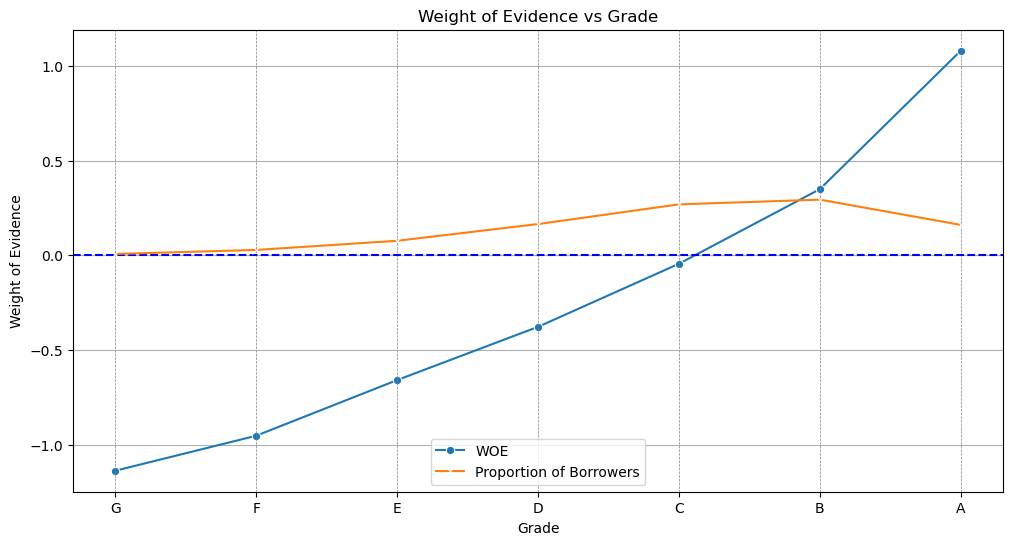

In [16]:
# Lets plot a beautiful plot of the WOE values with grades on x axis
plt.figure(figsize=(12,6)) # Setting the figure size
sns.lineplot(data=df_p_sorted, x=df_p_sorted.index, y='WOE', marker='o',label = 'WOE') # Creating a lineplot of the WOE values
plt.xlabel('Grade') # Setting the x-axis label
for i in range(len(df_p_sorted)):
        plt.axvline(x=i, color='grey', linestyle='--', linewidth=0.5)
plt.axhline(y=0, color='blue', linestyle='--') # Adding a horizontal line
sns.lineplot(data=df_p_sorted, x=df_p_sorted.index, y='prop_borrower', marker='x', label='Proportion of Borrowers') # Creating a lineplot of the borrower proportions
plt.ylabel('Weight of Evidence') # Setting the y-axis label
plt.title('Weight of Evidence vs Grade') # Setting the title of the plot
plt.legend()
plt.grid(axis='y')
plt.show()

# The WOE for each grade is different and this is a good sign, we will keep the grades as it is.


# The WOE for each grade is different and this is a good sign, we will keep the grades as it is.


Lets have a dictionary to store the categories of each column after clubbing

In [17]:
dummy_dict = {'grade':df_p_sorted.index.tolist()} # Creating a dictionary of the grades
dummy_dict

# Here the first element of list in value would be the reference category which has lowest
# WOE value. When we will convert the grade column to dummy variables, we will drop the first
# element of the list in value of the dictionary

{'grade': ['G', 'F', 'E', 'D', 'C', 'B', 'A']}

In [805]:
# Finding the non numeric columns again
non_numeric_columns = loan_data.select_dtypes(include=['object']).columns # Selecting the non numeric columns   
non_numeric_columns_list = non_numeric_columns.tolist() # Converting to list for easier manipulation
non_numeric_columns_list # Displaying the non numeric columns as a list

['grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'initial_list_status',
 'application_type']

In [19]:
# We need to find the WOE for each of the categorical variables
# We define a function to do this ardous task!
def give_woe_iv(col, loan_data):
                            
    df_good = loan_data.groupby(col)['good_bad'].sum()
    df_total = loan_data.groupby(col)['good_bad'].size()
    df_bad = df_total - df_good
    df_prop_borrower = df_total / df_total.sum()
              
    p_1 = df_good / df_good.sum()
    p_0 = df_bad / df_bad.sum()
    df_p = pd.concat([p_0, p_1, df_prop_borrower], axis=1)
    df_p.columns = ['p0', 'p1', 'prop_borrower']
    
    df_p['WOE'] = np.log(df_p['p1'] / df_p['p0'])
    df_p['IV'] = ((df_p['p1'] - df_p['p0']) * df_p['WOE']).sum()
    df_p_sorted = df_p.sort_values(by='WOE', ascending=True)
   
        
    print(f"Information Value for {col}: {df_p['IV'].iloc[0]}")
    
    return df_p_sorted

In [20]:
# Also, lets for a function to plot the WOE values for each categorical column
def plot_woe(df_p_sorted, col):
    plt.figure(figsize=(12,6))
    sns.lineplot(data=df_p_sorted, x=df_p_sorted.index, y='WOE', marker='o',label = 'WOE',color = 'blue')
    plt.xlabel(col)
    plt.xticks(rotation=90, fontsize=12)
    plt.ylabel('Weight of Evidence')
    plt.axhline(y=0, color='black', linestyle='--')
    # Plot verticle dotted lines for each category
    for i in range(len(df_p_sorted)):
        plt.axvline(x=i, color='gray', linestyle='--', linewidth=0.5)
    sns.lineplot(data=df_p_sorted, x=df_p_sorted.index, y='prop_borrower', marker='x', color='red', label='proportion of borrowers')
    plt.title(f'Weight of Evidence vs {col}')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

In [21]:
# Lets have a function for even storing the categories in a dictionary
def store_categories(df_p_sorted, col, dummy_dict):
    dummy_dict[col] = df_p_sorted.index.tolist()
    return dummy_dict

Information Value for home_ownership: inf


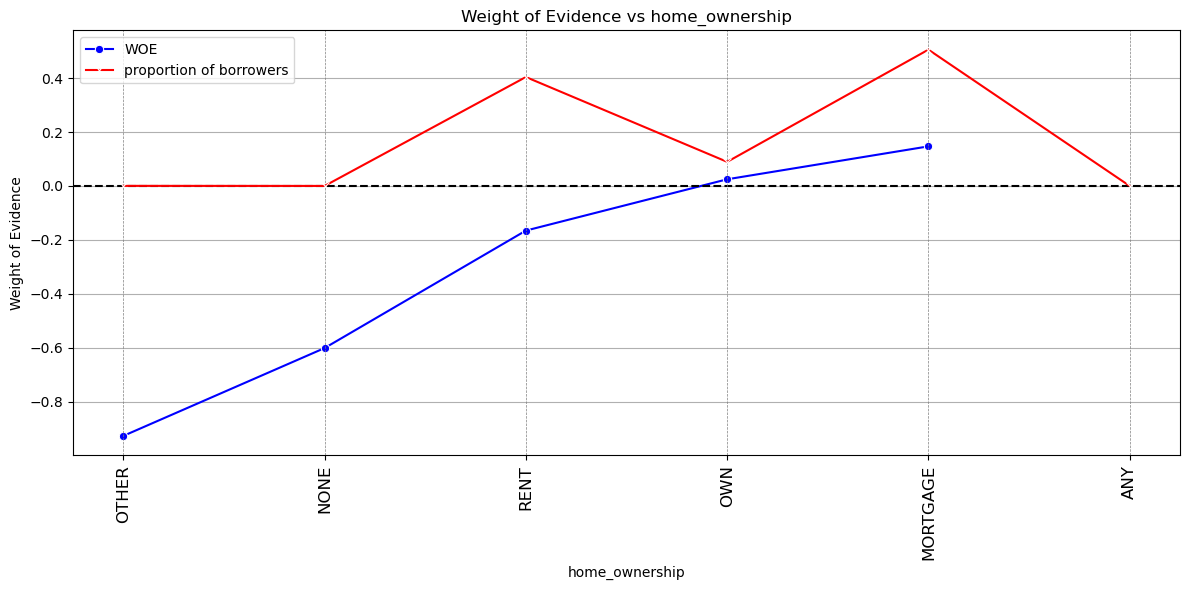

In [22]:
# Lets compute the WoE for home_ownership
df_p_sorted = give_woe_iv('home_ownership', loan_data)
plot_woe(df_p_sorted, 'home_ownership')

In [23]:
loan_data['home_ownership'].value_counts(normalize=True) # Displaying the frequency of each home ownership

home_ownership
MORTGAGE    0.505860
RENT        0.404201
OWN         0.089439
OTHER       0.000390
NONE        0.000107
ANY         0.000002
Name: proportion, dtype: float64

In [806]:
# As seen from the percentage values, we can combine 'OTHER','NONE', 'ANY' with 'RENT' as Other,etc is very less in number
# and 'RENT' is the next lowest in WOE value
loan_data['home_ownership'] = loan_data['home_ownership'].replace(['OTHER', 'RENT','NONE','ANY'], 'OTHER_RENT_NONE_ANY') # Replacing 'OTHER' and 'RENT' with 'OTHER_RENT'


Information Value for home_ownership: 0.02238734113630051


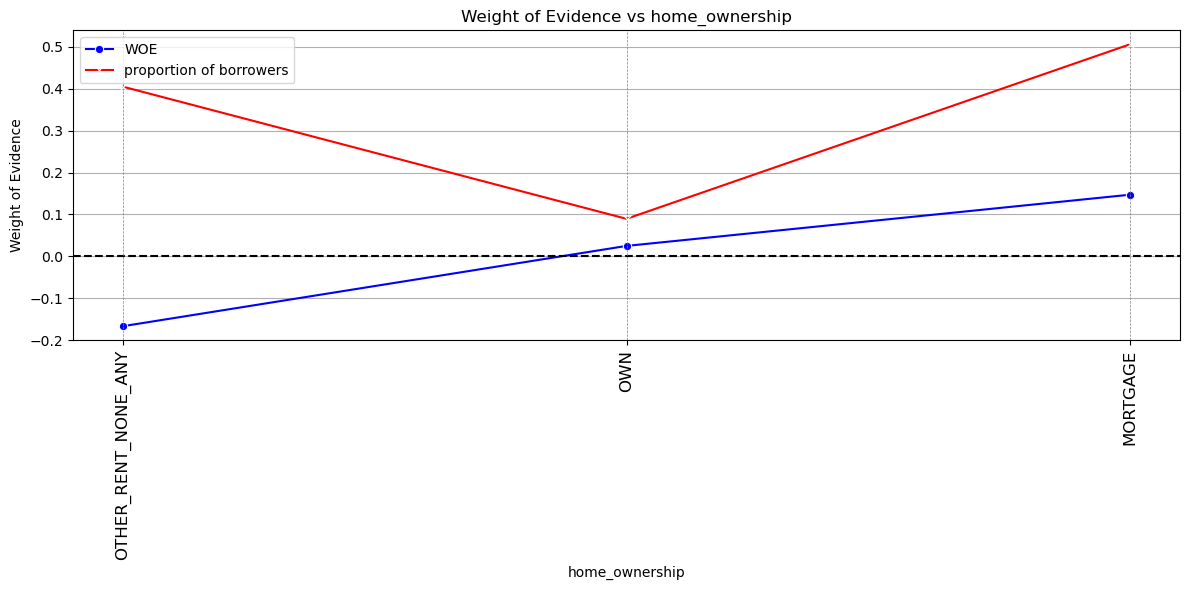

In [25]:
# Lets compute the WoE for home_ownership
df_p_sorted = give_woe_iv('home_ownership', loan_data)
plot_woe(df_p_sorted, 'home_ownership')

In [26]:
# Now we update the dummy_dict with the new values
dummy_dict = store_categories(df_p_sorted, 'home_ownership', dummy_dict)

In [27]:
print(dummy_dict)

{'grade': ['G', 'F', 'E', 'D', 'C', 'B', 'A'], 'home_ownership': ['OTHER_RENT_NONE_ANY', 'OWN', 'MORTGAGE']}


Information Value for addr_state: inf


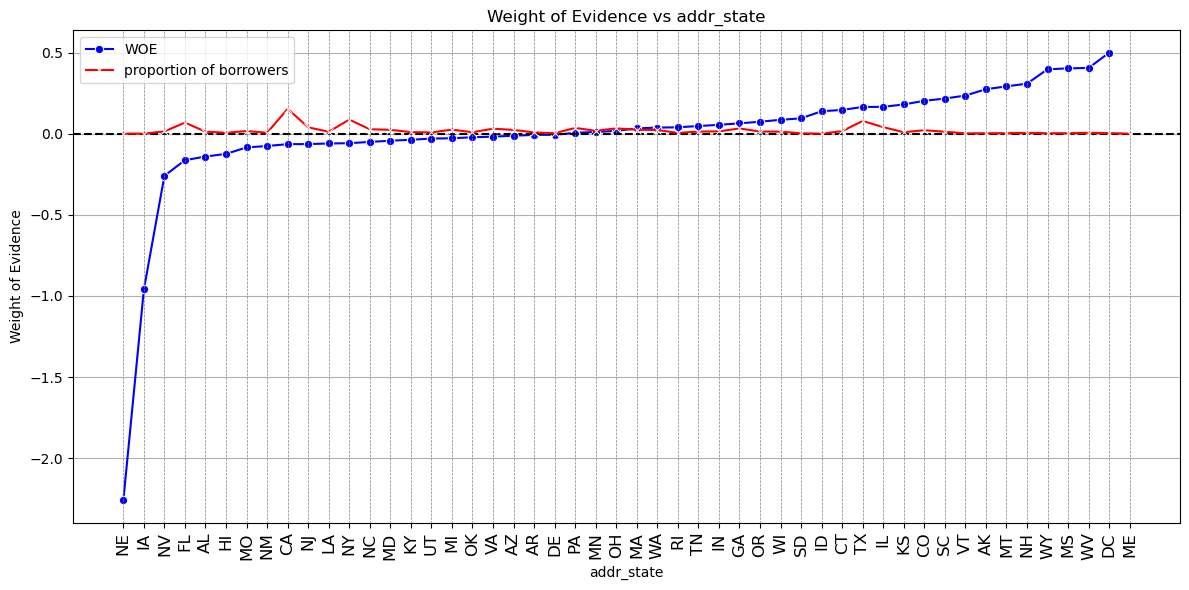

In [28]:
# Lets find WOE for  'addr_state'
df_p_sorted = give_woe_iv('addr_state', loan_data)
plot_woe(df_p_sorted, 'addr_state')

In [130]:
df_p_sorted

,p0,p1,prop_borrower,WOE,IV
addr_state,,,,,
NE,0.000159,0.000017,0.000030,-2.259786,inf
IA,0.000068,0.000026,0.000030,-0.960503,inf
NV,0.017632,0.013600,0.013981,-0.259663,inf
FL,0.078583,0.066729,0.067849,-0.163521,inf
AL,0.014251,0.012375,0.012552,-0.141116,inf
HI,0.005968,0.005267,0.005334,-0.124877,inf
MO,0.017382,0.015968,0.016102,-0.084856,inf
NM,0.005945,0.005509,0.005550,-0.076225,inf
CA,0.162476,0.152268,0.153232,-0.064891,inf


Information Value for addr_state: inf


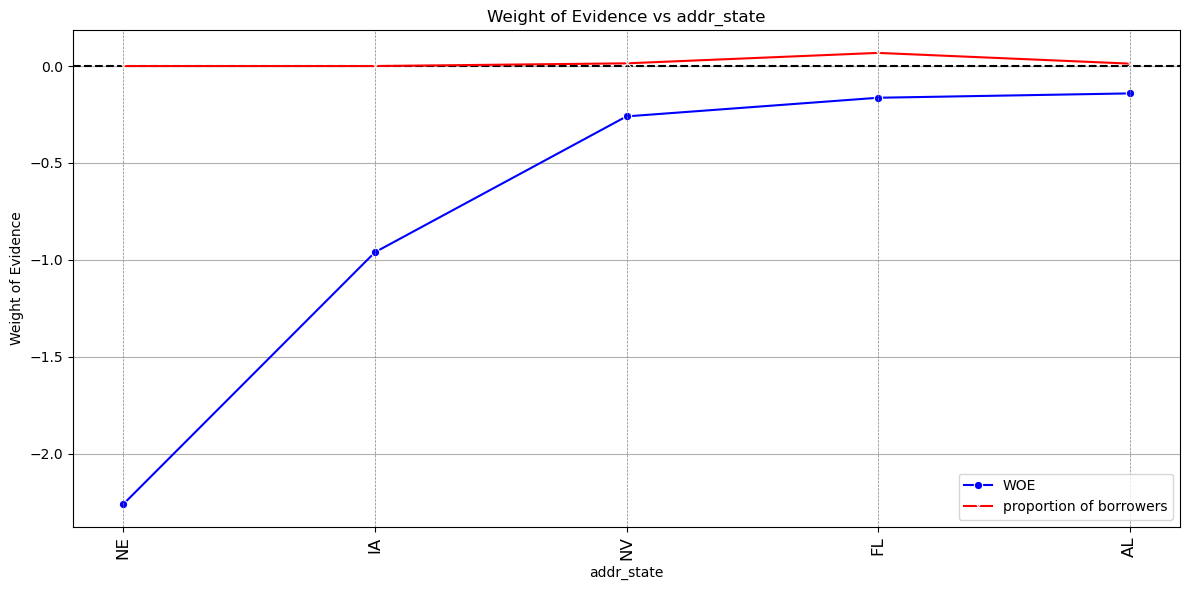

In [ ]:
# Lets find WOE for  'addr_state'
df_p_sorted = give_woe_iv('addr_state', loan_data)
plot_woe(df_p_sorted[:5], 'addr_state')

# Looking at the first 5 states

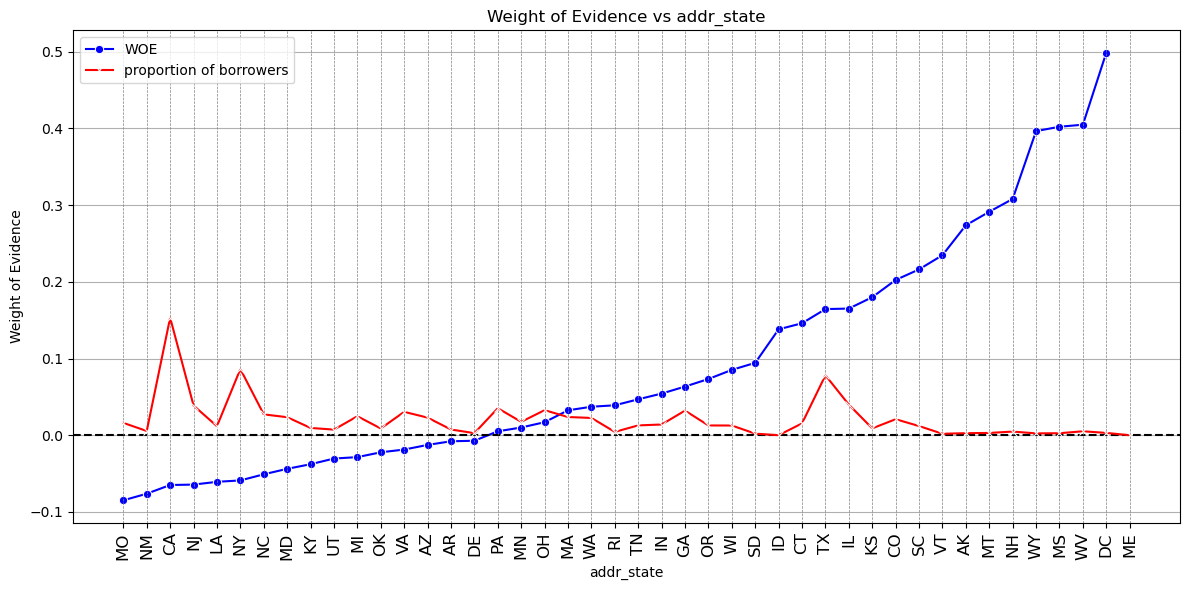

In [137]:
plot_woe(df_p_sorted[6:], 'addr_state')

In [807]:
# Looking at the above two graphs, we do the fineclassing as follows:
loan_data['addr_state_c'] = loan_data['addr_state'].replace(['NE', 'IA','NV'], 'NE_IA_NV')
loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['FL','AL','MO','NM'],'FL_AL_MO_NM')
loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['NJ','LA'],'NJ_LA')
loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['NC','MD','KY','UT','MI'],'NC_MD_KY_UT_MI')
loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['OK','VA','AZ','AR','DE'],'OK_VA_AZ_AR_DE')
loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['PA','MN','OH'],'PA_MN_OH')
loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['MA','WA','RI','TN','IN','GA','OR','WI','SD'],'MA_WA_RI_TN_IN_GA_OR_WI_SD')
loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['ID','CT','IL','KS','CO','SC'],'ID_CT_IL_KS_CO_SC')
loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['VT','AK','MT','NH','WY','MS','WV','DC','ME'],'VT_AK_MT_NH_WY_MS_WV_DC_ME')

In [30]:
loan_data['addr_state_c'].value_counts()

addr_state_c
CA                            71450
MA_WA_RI_TN_IN_GA_OR_WI_SD    63963
FL_AL_MO_NM                   47586
ID_CT_IL_KS_CO_SC             45340
NC_MD_KY_UT_MI                43071
NY                            40242
PA_MN_OH                      39819
TX                            36439
OK_VA_AZ_AR_DE                33811
NJ_LA                         23550
VT_AK_MT_NH_WY_MS_WV_DC_ME    11980
NE_IA_NV                       6547
HI                             2487
Name: count, dtype: int64

Information Value for addr_state_c: 0.01284584137600943


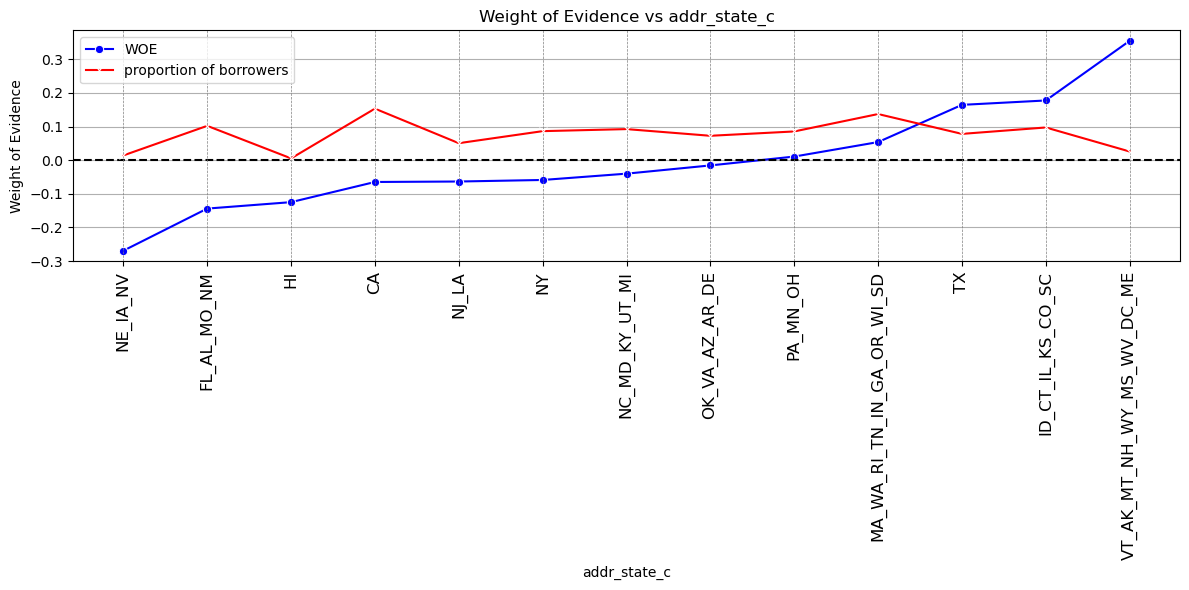

In [31]:
# Lets find WOE for  'addr_state_c'
df_p_sorted = give_woe_iv('addr_state_c', loan_data)
plot_woe(df_p_sorted, 'addr_state_c')

In [32]:
# Now we update the dummy_dict with the new values
dummy_dict = store_categories(df_p_sorted, 'addr_state_c', dummy_dict)

Information Value for verification_status: 0.022882612556066814


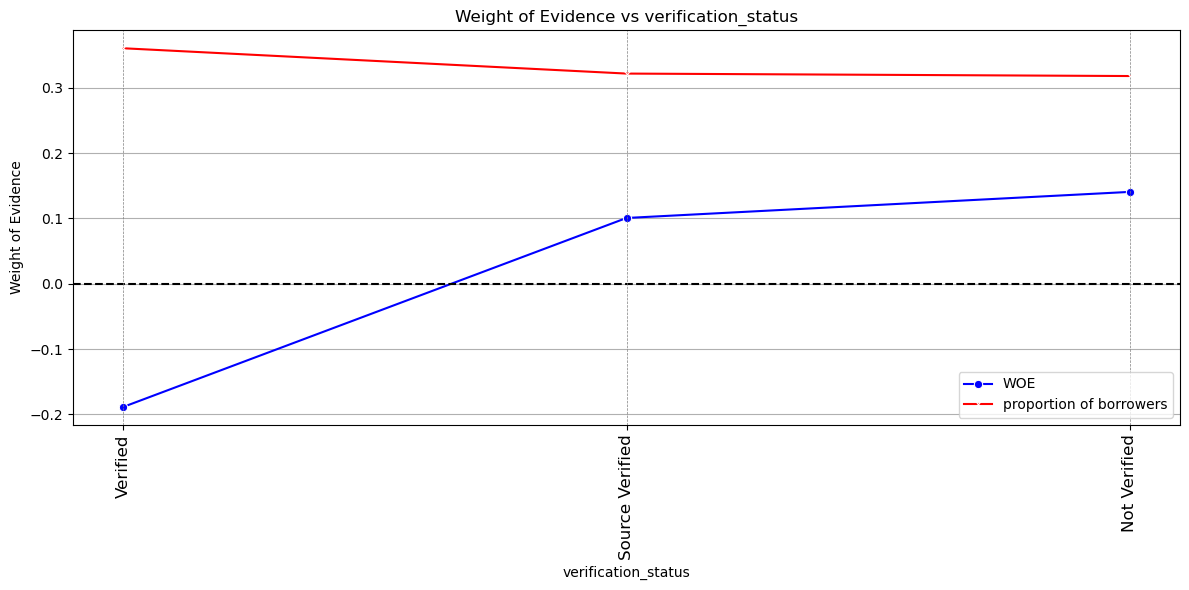

In [33]:
# Lets find WOE for  'verification_status'
df_p_sorted = give_woe_iv('verification_status', loan_data)
plot_woe(df_p_sorted, 'verification_status')

In [34]:
# We dont need further course classing here.
# Now we update the dummy_dict with the new values
dummy_dict = store_categories(df_p_sorted, 'verification_status', dummy_dict)

Information Value for purpose: 0.04400737250602171


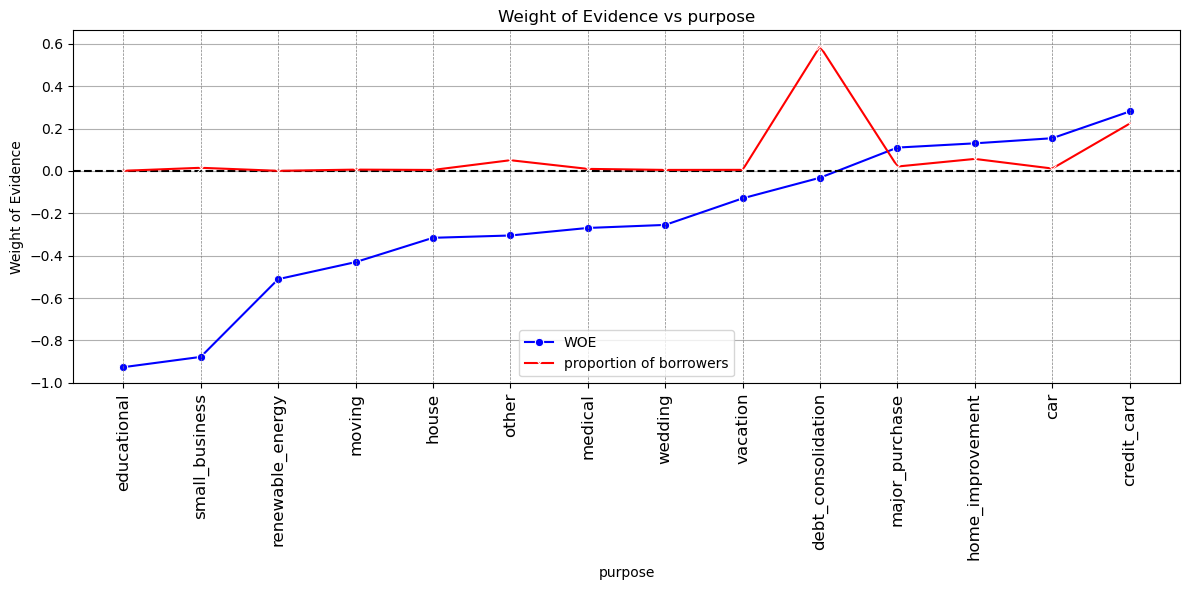

In [35]:
# Lets find WOE for  'purpose'
df_p_sorted = give_woe_iv('purpose', loan_data)
plot_woe(df_p_sorted, 'purpose')

In [36]:
loan_data['purpose'].value_counts()

purpose
debt_consolidation    274195
credit_card           104157
home_improvement       26537
other                  23690
major_purchase          9828
small_business          7013
car                     5397
medical                 4602
moving                  2994
vacation                2487
wedding                 2343
house                   2269
educational              422
renewable_energy         351
Name: count, dtype: int64

In [ ]:
# We wont do course classing of purpose further because it doesnt make any sense of joining purposes which can be for different reasons

In [37]:
# We dont need further course classing here.
# Now we update the dummy_dict with the new values
dummy_dict = store_categories(df_p_sorted, 'purpose', dummy_dict)

Information Value for initial_list_status: 0.04524254087833612


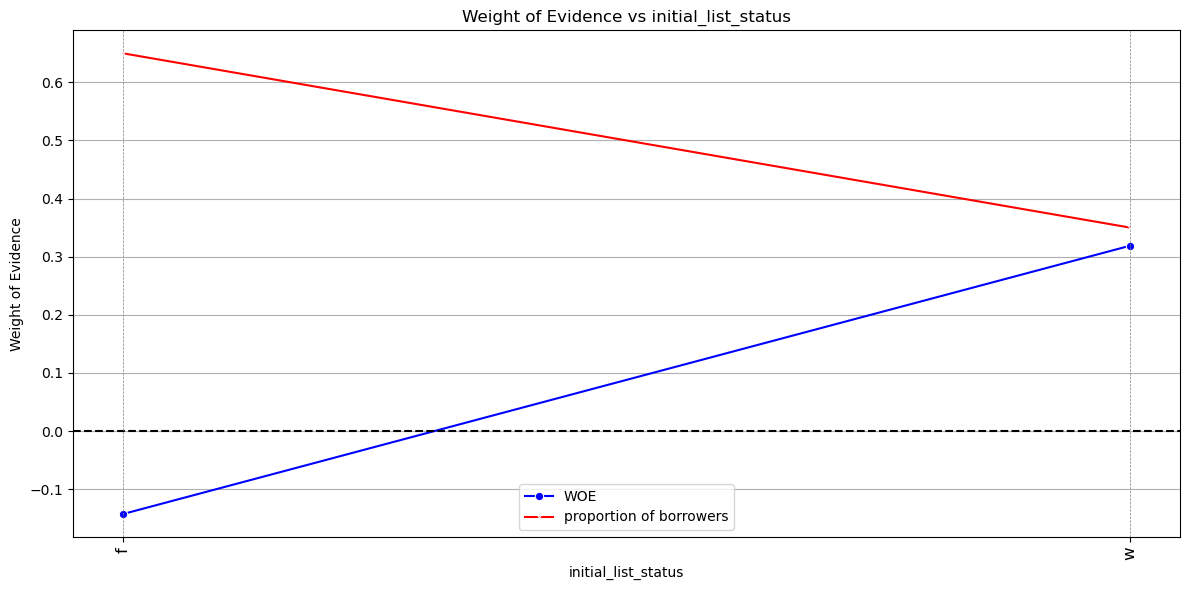

In [38]:
# Lets find WOE for  'initial_list_status'
df_p_sorted = give_woe_iv('initial_list_status', loan_data)
plot_woe(df_p_sorted, 'initial_list_status')

In [39]:
# We dont need further course classing here.
# Now we update the dummy_dict with the new values
dummy_dict = store_categories(df_p_sorted, 'initial_list_status', dummy_dict)

Information Value for sub_grade: 0.2993488307011605


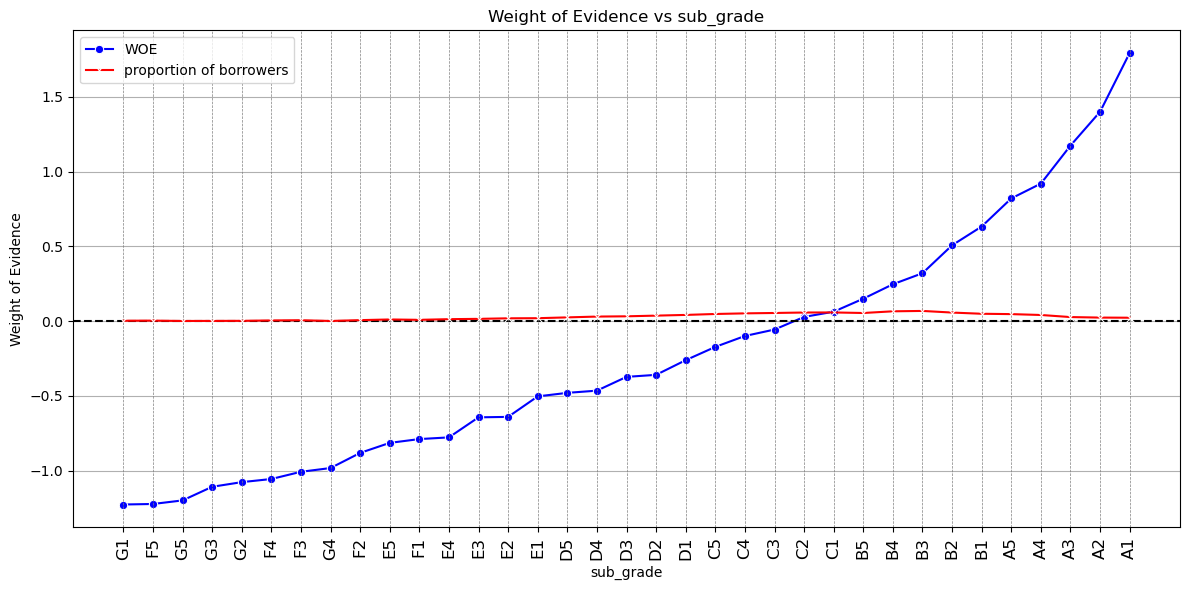

In [159]:
# Lets find WOE for sub_grade
df_p_sorted = give_woe_iv('sub_grade', loan_data)
plot_woe(df_p_sorted, 'sub_grade')

# The subgrades mostly have very low borrower proportions, but combining them doesnt make sense
# Will this feature even be useful? 


# Preprocessing of Continuous Variables


In [808]:
# Lets find the numerical columns
numeric_columns = loan_data.select_dtypes(include=['int64', 'float64']).columns # Selecting the numeric columns
numeric_columns_list = numeric_columns.tolist() # Converting to list for easier manipulation
numeric_columns_list # Displaying the numeric columns as a

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'emp_length',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'months_since_earliest_cr',
 'months_since_issue_d',
 'months_since_last_pymnt_d',
 'months_since_last_credit_pull_d',
 'months_since_next_pymnt_d',
 'good_bad']

In [41]:
# We need to find the WOE for each of the continuous variables
# We define a function to do this ardous task!
# We keep the order of the bins as it is since these are continuous variables and not qualitative
def give_woe_iv_cont(col, loan_data):
                            
    df_good = loan_data.groupby(col)['good_bad'].sum()
    df_total = loan_data.groupby(col)['good_bad'].size()
    df_prop_borrower = df_total / df_total.sum()
    df_bad = df_total - df_good
              
    p_1 = df_good / df_good.sum()
    p_0 = df_bad / df_bad.sum()
    df_p = pd.concat([p_0, p_1, df_prop_borrower], axis=1)
    df_p.columns = ['p0', 'p1', 'prop_borrower']
    
    
    df_p['WOE'] = np.log(df_p['p1'] / df_p['p0'])
    df_p['IV'] = ((df_p['p1'] - df_p['p0']) * df_p['WOE']).sum()
    df_p.index.name = 'bin'
    df_p.reset_index(inplace=True)
    #df_p.index = df_p.index.astype(str)

    print(f"Information Value for {col}: {df_p['IV'].iloc[0]}")
    
    return df_p

In [42]:
# Also, lets for a function to plot the WOE values for each continuous column
def plot_woe_cont(df_p, col):
    
    x = np.array(df_p.iloc[:,0].apply(str))
    y = df_p['WOE']
    plt.figure(figsize=(12,6))
    sns.lineplot(data=df_p, x=x, y='WOE', marker='o', label='WOE', color='blue')
    plt.xlabel(col)
    plt.xticks(rotation=90, fontsize=12)
    plt.ylabel('Weight of Evidence')
    plt.axhline(y=0, color='black', linestyle='--')
    # Plot vertical dotted lines for each category
    for i in range(len(df_p)):
        plt.axvline(x=i, color='gray', linestyle='--', linewidth=0.5)
    sns.lineplot(data=df_p, x=x, y='prop_borrower', marker='x', color='red', label='proportion of borrowers')
    plt.title(f'Weight of Evidence vs {col}')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

Information Value for term: 0.03306138503387442


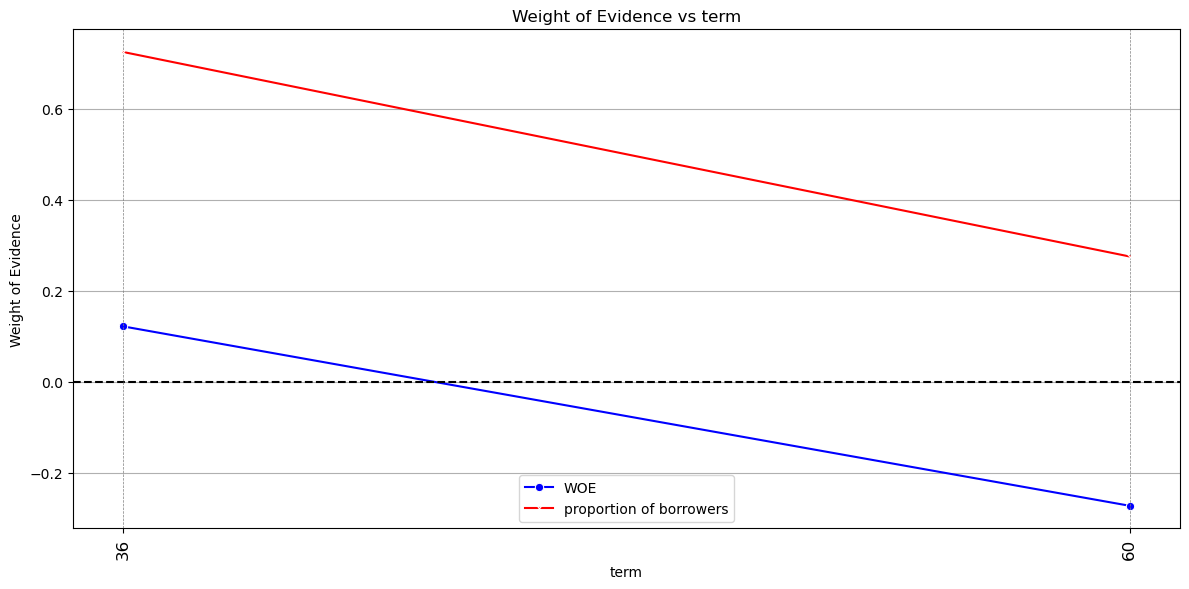

In [43]:
# Finding the WOE for term
df_p = give_woe_iv_cont('term', loan_data)
plot_woe_cont(df_p, 'term')

# Looks like we dont need to course class it further

In [809]:
# For term, we can convert the 36 months to 0 and 60 months to 1
loan_data['term:60'] = loan_data['term'].replace([36, 60], [0, 1]) # Replacing ' 36 months' and ' 60 months' with 0 and 1
# Convert it to category
loan_data['term:60'] = loan_data['term:60'].astype('category')

In [810]:
loan_data.drop(['term'], axis=1, inplace=True) # Dropping the term column

In [48]:
# Lets look into months_since_issue_d

loan_data['months_since_issue_d'].nunique()

91

In [811]:
# First do fine classing by rough grouping
loan_data['months_since_issue_d_class'] = pd.cut(loan_data['months_since_issue_d'], 50) # Creating 50 bins



/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for months_since_issue_d_class: 0.22072789626995815


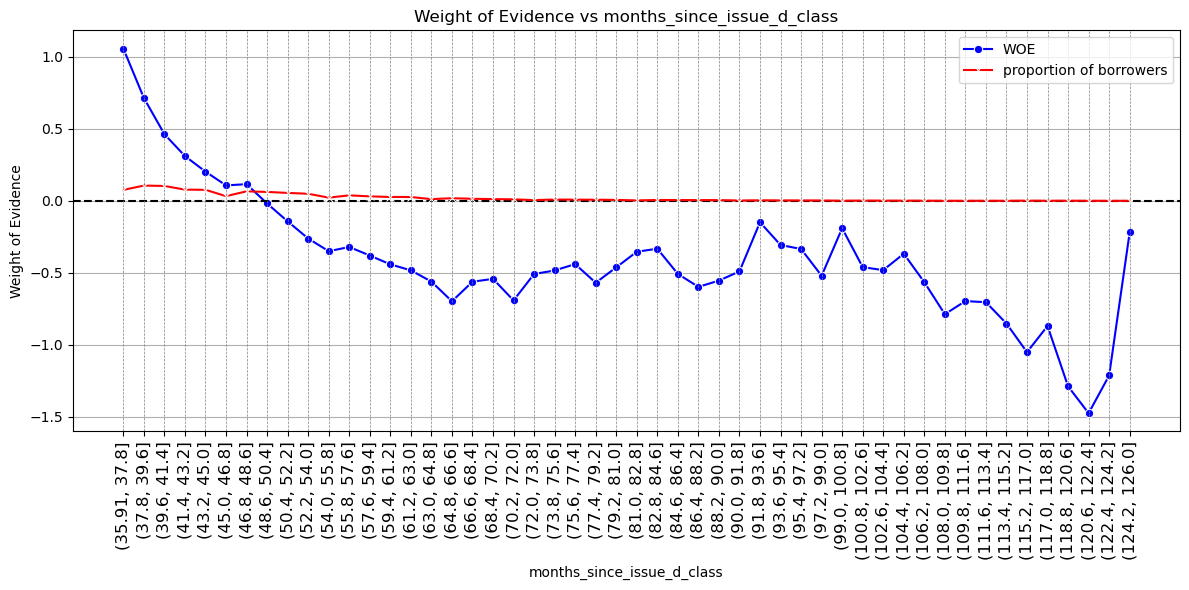

In [50]:
# Lets find the WOE for months_since_issue_d_class
df_p = give_woe_iv_cont('months_since_issue_d_class', loan_data)
plot_woe_cont(df_p, 'months_since_issue_d_class')

In [284]:
# Fine classing

# One class is months_since_issue_d < 38
# Second class is 38 <= months_since_issue_d < 40
# Third class is 40 <= months_since_issue_d < 42

# The plot needs to be magnified to observe the changing WOE beyond 42 months


In [181]:
df_p
# Looking at the bins and WOE values in the table

,bin,p0,p1,prop_borrower,WOE,IV
0,"(35.91, 37.8]",0.028070,0.080821,0.075836,1.057526,0.220728
1,"(37.8, 39.6]",0.054484,0.111286,0.105918,0.714200,0.220728
2,"(39.6, 41.4]",0.067328,0.106943,0.103199,0.462720,0.220728
3,"(41.4, 43.2]",0.058500,0.079817,0.077802,0.310698,0.220728
4,"(43.2, 45.0]",0.063402,0.077661,0.076314,0.202864,0.220728
5,"(45.0, 46.8]",0.029704,0.033064,0.032746,0.107147,0.220728
6,"(46.8, 48.6]",0.059159,0.066414,0.065728,0.115682,0.220728
7,"(48.6, 50.4]",0.062789,0.061634,0.061743,-0.018568,0.220728
8,"(50.4, 52.2]",0.062562,0.054247,0.055033,-0.142617,0.220728
9,"(52.2, 54.0]",0.061814,0.047570,0.048916,-0.261914,0.220728


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for months_since_issue_d_class: 0.22072789626995815


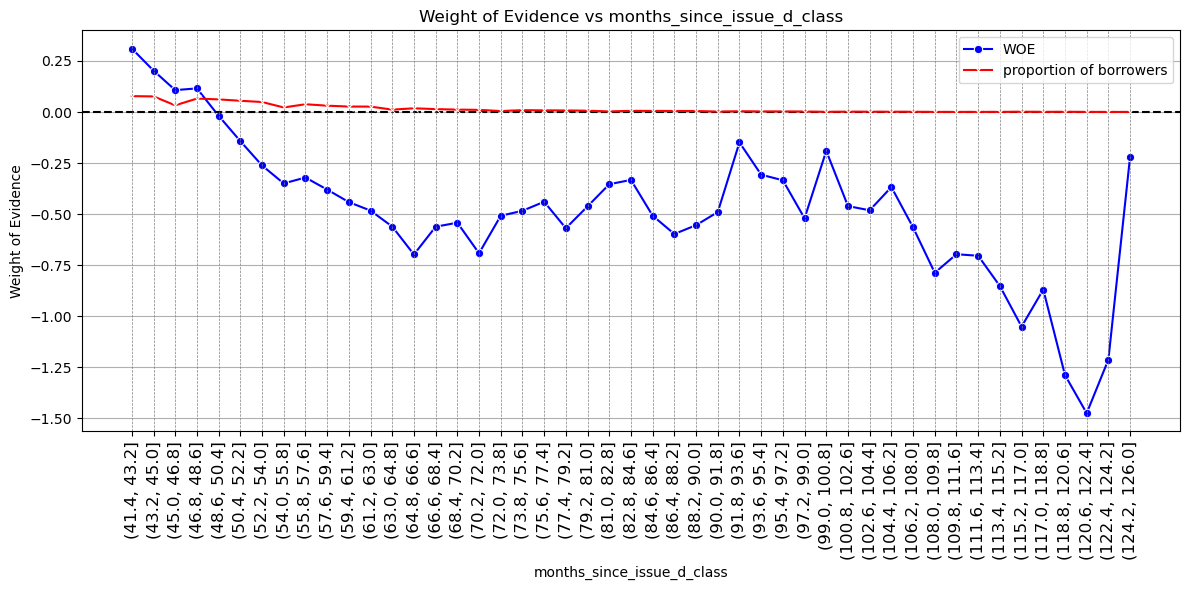

In [51]:
# The plot needs to be magnified to observe the changing WOE beyond 42 months
# Lets plot the WOE values for months_since_issue_d_class beyond 42 months
df_p = give_woe_iv_cont('months_since_issue_d_class', loan_data)
plot_woe_cont(df_p.iloc[3:,], 'months_since_issue_d_class')

In [287]:
# Fine classing

# One class is months_since_issue_d < 38
# Second class is 38 <= months_since_issue_d < 40
# Third class is 40 <= months_since_issue_d < 42

# The plot needs to be magnified to observe the changing WOE beyond 42 months, and we got :

# Fourth class is 42 <= months_since_issue_d < 44
# Fifth class is 44 <= months_since_issue_d < 45
# Sixth class is 45 <= months_since_issue_d < 49
# Seventh class is 49 <= months_since_issue_d < 50
# Eighth class is 50 <= months_since_issue_d < 51
# Ninth class is 51 <= months_since_issue_d < 52
# Tenth class is 52 <= months_since_issue_d < 54
# Eleventh class is 54 <= months_since_issue_d < 63
# Twelfth class is 63 <= months_since_issue_d < 76
# Thirteenth class is 76 <= months_since_issue_d < 96
# Fourteenth class is >= 96 months

In [812]:
# Lets do the course classing
loan_data['months_since_issue_d_class :<38'] = np.where(loan_data['months_since_issue_d'] < 38, 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :38-40'] = np.where((loan_data['months_since_issue_d'] >= 38) & (loan_data['months_since_issue_d'] < 40), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :40-42'] = np.where((loan_data['months_since_issue_d'] >= 40) & (loan_data['months_since_issue_d'] < 42), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :42-44'] = np.where((loan_data['months_since_issue_d'] >= 42) & (loan_data['months_since_issue_d'] < 44), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :44-45'] = np.where((loan_data['months_since_issue_d'] >= 44) & (loan_data['months_since_issue_d'] < 45), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :45-49'] = np.where((loan_data['months_since_issue_d'] >= 45) & (loan_data['months_since_issue_d'] < 49), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :49-50'] = np.where((loan_data['months_since_issue_d'] >= 49) & (loan_data['months_since_issue_d'] < 50), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :50-51'] = np.where((loan_data['months_since_issue_d'] >= 50) & (loan_data['months_since_issue_d'] < 51), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :51-52'] = np.where((loan_data['months_since_issue_d'] >= 51) & (loan_data['months_since_issue_d'] < 52), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :52-54'] = np.where((loan_data['months_since_issue_d'] >= 52) & (loan_data['months_since_issue_d'] < 54), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :54-63'] = np.where((loan_data['months_since_issue_d'] >= 54) & (loan_data['months_since_issue_d'] < 63), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :63-76'] = np.where((loan_data['months_since_issue_d'] >= 63) & (loan_data['months_since_issue_d'] < 76), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :76-96'] = np.where((loan_data['months_since_issue_d'] >= 76) & (loan_data['months_since_issue_d'] < 96), 1, 0) # Creating a new column
loan_data['months_since_issue_d_class :>=96'] = np.where(loan_data['months_since_issue_d'] >= 96, 1, 0) # Creating a new column

In [813]:
# Lets drop the columns months_since_issue_d and months_since_issue_d_class
loan_data.drop(['months_since_issue_d', 'months_since_issue_d_class'], axis=1, inplace=True) # Dropping the months_since_issue_d and months_since_issue_d_class columns

In [54]:
# Lets look into the column int_rate_factor
loan_data['int_rate'].nunique()

506

In [814]:
# Lets first do a rough fine classing by cutting it into bins
loan_data['int_rate_class'] = pd.cut(loan_data['int_rate'], 50) # Creating 50 bins

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for int_rate_class: 0.34796567672248846


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/3647959730.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


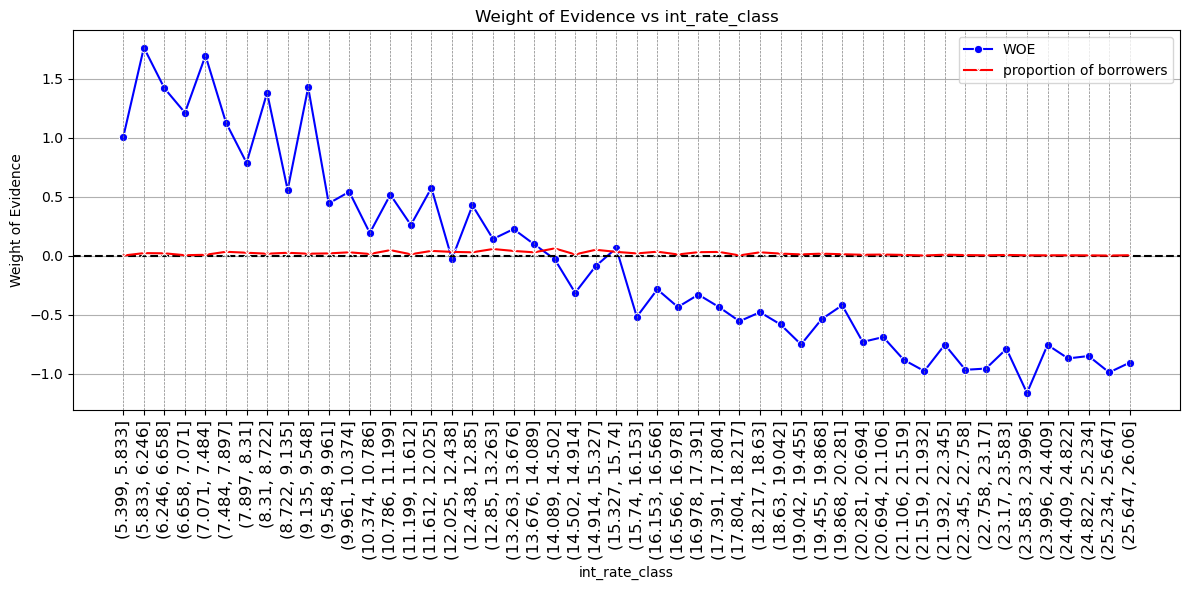

In [187]:
# Lets find the WOE for int_rate_class
df_p = give_woe_iv_cont('int_rate_class', loan_data)
plot_woe_cont(df_p, 'int_rate_class')

In [188]:
df_p

,bin,p0,p1,prop_borrower,WOE,IV
0,"(5.399, 5.833]",0.000817,0.002243,0.002108,1.009995,0.347966
1,"(5.833, 6.246]",0.004198,0.024537,0.022615,1.765566,0.347966
2,"(6.246, 6.658]",0.005469,0.022640,0.021017,1.420656,0.347966
3,"(6.658, 7.071]",0.001566,0.005267,0.004918,1.213171,0.347966
4,"(7.071, 7.484]",0.001679,0.009173,0.008465,1.697934,0.347966
5,"(7.484, 7.897]",0.011732,0.036259,0.033941,1.128368,0.347966
6,"(7.897, 8.31]",0.012458,0.027396,0.025984,0.788028,0.347966
7,"(8.31, 8.722]",0.004788,0.019097,0.017745,1.383397,0.347966
8,"(8.722, 9.135]",0.015249,0.026647,0.025570,0.558168,0.347966
9,"(9.135, 9.548]",0.004584,0.019111,0.017738,1.427732,0.347966


Information Value for int_rate_class: 0.34796567672248846


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


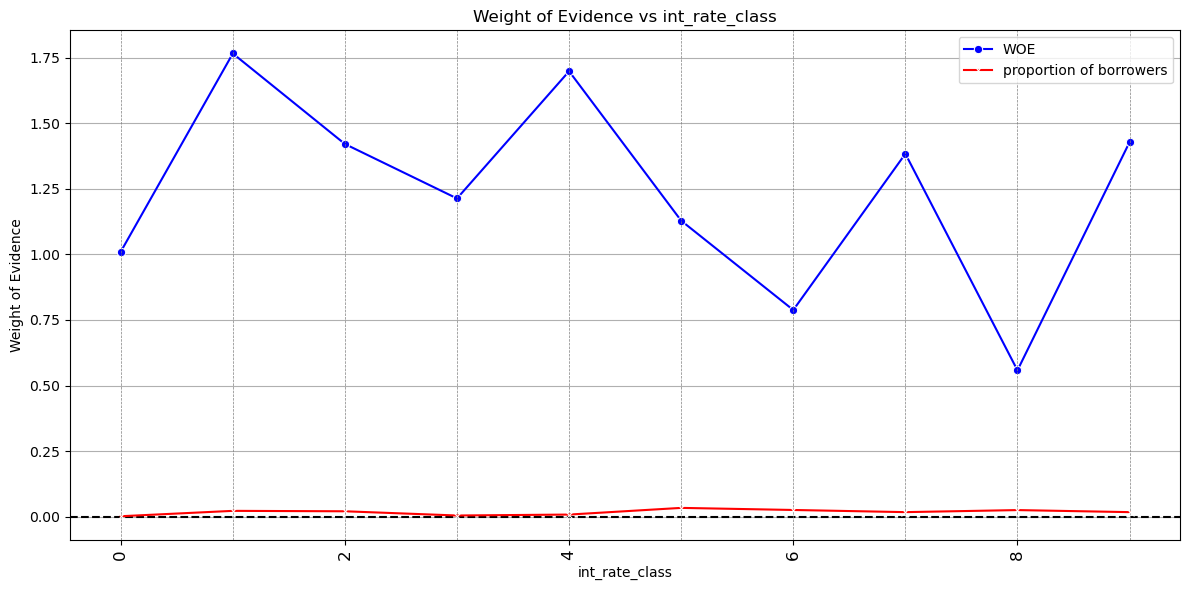

In [189]:
# Let us magnify the plot to look into the first 10 bins only
df_p = give_woe_iv_cont('int_rate_class', loan_data)

plot_woe(df_p.iloc[:10], 'int_rate_class')

In [ ]:
# Course classing
# First class : 5<= int_rate < 9.6

Information Value for int_rate_class: 0.34796567672248846


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


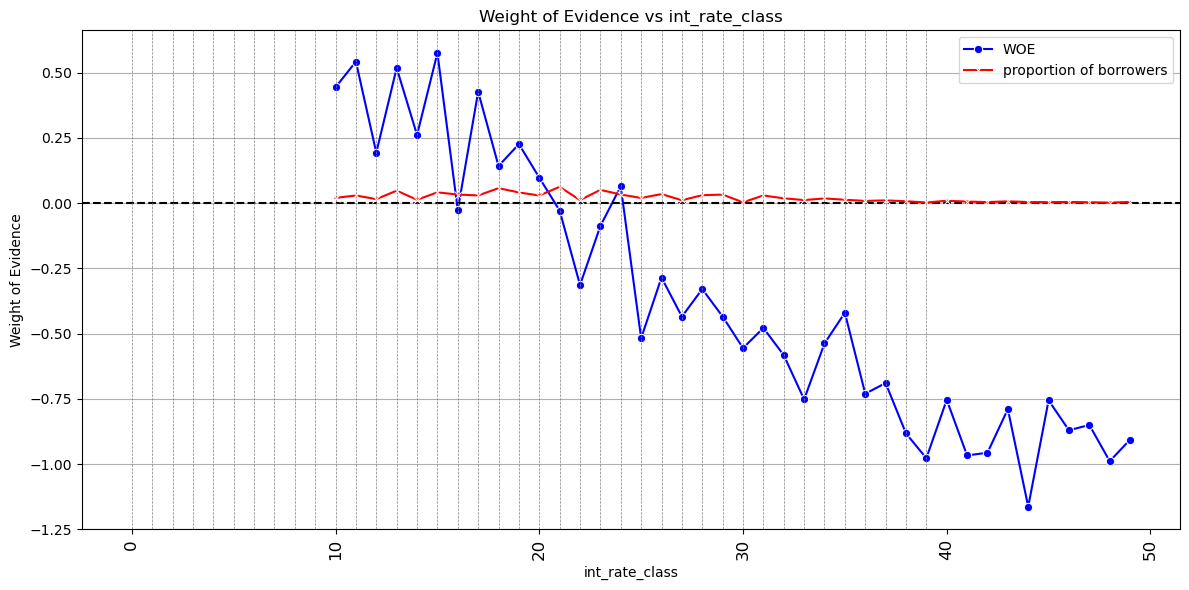

In [190]:
# Lets look into the WOE plot beyond 9.6 int rate
df_p = give_woe_iv_cont('int_rate_class', loan_data)
plot_woe(df_p.iloc[10:,], 'int_rate_class')

In [191]:
# Course classing
# First class : 5<= int_rate < 9.6
# Second class : 9.6 <= int_rate < 12
# Third class : 12 <= int_rate < 14.5
# Fourth class : 14.5 <= int_rate < 16
# Fifth class : 16 <= int_rate < 20
# Sixth class : int_rate >= 20

In [815]:
# Lets do the course classing
loan_data['int_rate_class :5-9.6'] = np.where((loan_data['int_rate'] >= 5) & (loan_data['int_rate'] < 9.6), 1, 0) # Creating a new column
loan_data['int_rate_class :9.6-12'] = np.where((loan_data['int_rate'] >= 9.6) & (loan_data['int_rate'] < 12), 1, 0) # Creating a new column
loan_data['int_rate_class :12-14.5'] = np.where((loan_data['int_rate'] >= 12) & (loan_data['int_rate'] < 14.5), 1, 0) # Creating a new column
loan_data['int_rate_class :14.5-16'] = np.where((loan_data['int_rate'] >= 14.5) & (loan_data['int_rate'] < 16), 1, 0) # Creating a new column
loan_data['int_rate_class :16-20'] = np.where((loan_data['int_rate'] >= 16) & (loan_data['int_rate'] < 20), 1, 0) # Creating a new column
loan_data['int_rate_class :>=20'] = np.where(loan_data['int_rate'] >= 20, 1, 0) # Creating a new column

In [816]:
# Drop the int_rate and int_rate_class columns
loan_data.drop(['int_rate', 'int_rate_class'], axis=1, inplace=True) # Dropping the int_rate and int_rate

In [58]:
# Lets get into the funded_amnt column
loan_data['funded_amnt'].nunique()

1354

In [818]:
# Lets first do a rough fine classing by cutting it into bins
loan_data['funded_amnt_class'] = pd.cut(loan_data['funded_amnt'], 50) 

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for funded_amnt_class: 0.014755036238730038


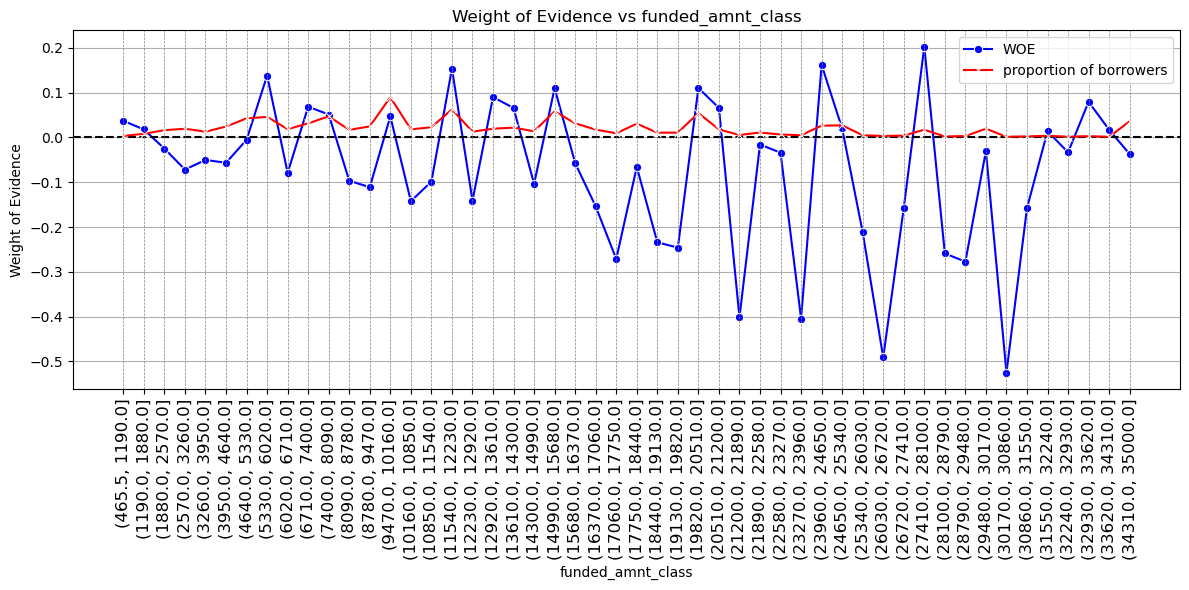

In [196]:
# Lets find the WOE for funded_amnt_class
df_p = give_woe_iv_cont('funded_amnt_class', loan_data)
plot_woe_cont(df_p, 'funded_amnt_class')

In [819]:
# The plot is so messy, WOE is oscillating a lot, and it shows that it is independent of the funded amount
# We can drop funded_amnt and funded_amnt_class
loan_data.drop(['funded_amnt', 'funded_amnt_class'], axis=1, inplace=True) # Dropping the funded_amnt and funded_amnt_class columns


In [311]:
# We look into the following columns
#‘mths_since_earliest_cr_line’;

#‘installment’;

# ‘delinq_2yrs’;

# ‘inq_last_6mths’;

#‘open_acc’;

# ‘pub_rec’;

#‘total_acc’;

# ‘acc_now_delinq’.

In [198]:
# mths_since_earliest_cr_line
loan_data['months_since_earliest_cr'].nunique()

664

In [820]:
# Lets first do a rough fine classing by cutting it into bins
loan_data['months_since_earliest_cr_class'] = pd.cut(loan_data['months_since_earliest_cr'], 50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for months_since_earliest_cr_class: inf


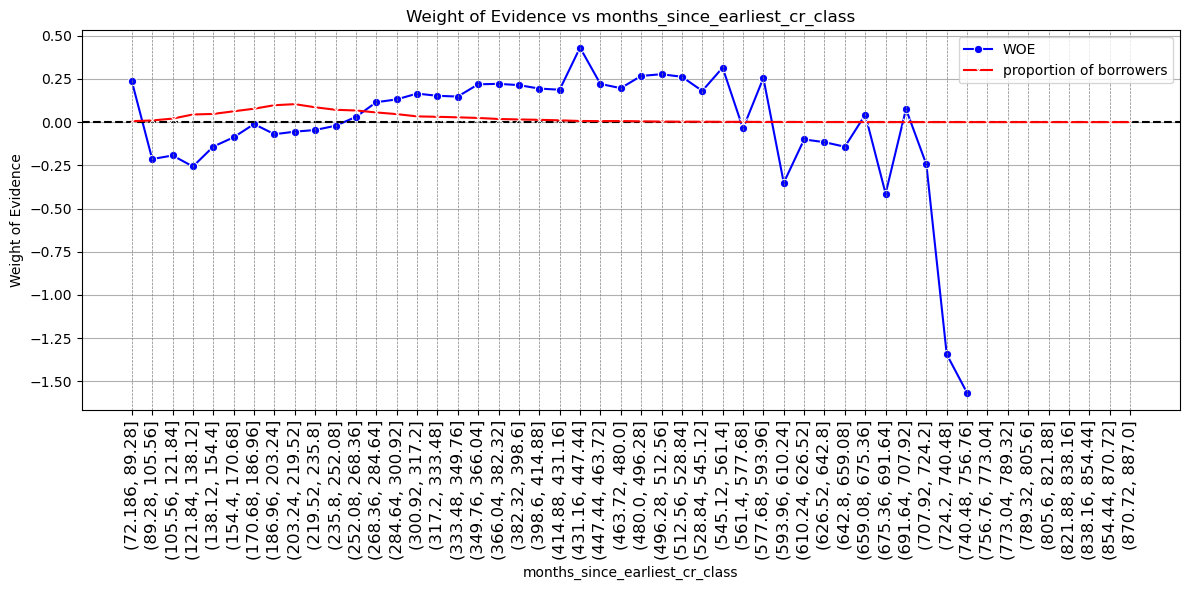

In [200]:
# Lets find the WOE for months_since_earliest_cr_class
df_p = give_woe_iv_cont('months_since_earliest_cr_class', loan_data)
plot_woe_cont(df_p, 'months_since_earliest_cr_class')

In [ ]:
# The course classing is as follows:
# First class : months_since_earliest_cr < 171
# Second class : 171 <= months_since_earliest_cr < 253
# Third class : 253 <= months_since_earliest_cr < 432
# Fourth class : 432 <= months_since_earliest_cr < 562
# Fifth class : 562 <= months_since_earliest_cr 


In [821]:
# The course classing is as follows:
loan_data['months_since_earliest_cr_class :<171'] = np.where(loan_data['months_since_earliest_cr'] < 171, 1, 0) # Creating a new column
loan_data['months_since_earliest_cr_class :171-253'] = np.where((loan_data['months_since_earliest_cr'] >= 171) & (loan_data['months_since_earliest_cr'] < 253), 1, 0) # Creating a new column
loan_data['months_since_earliest_cr_class :253-432'] = np.where((loan_data['months_since_earliest_cr'] >= 253) & (loan_data['months_since_earliest_cr'] < 432), 1, 0) # Creating a new column
loan_data['months_since_earliest_cr_class :432-562'] = np.where((loan_data['months_since_earliest_cr'] >= 432) & (loan_data['months_since_earliest_cr'] < 562), 1, 0) # Creating a new column
loan_data['months_since_earliest_cr_class :>=562'] = np.where(loan_data['months_since_earliest_cr'] >= 562, 1, 0) # Creating a new column

In [822]:
# Drop the months_since_earliest_cr and months_since_earliest_cr_class columns
loan_data.drop(['months_since_earliest_cr', 'months_since_earliest_cr_class'], axis=1, inplace=True) # Dropping the months_since_earliest_cr and months_since_earliest_cr_class columns

In [203]:
# Lets look into installment
loan_data['installment'].nunique()

55622

In [823]:
# Lets first do a rough fine classing by cutting it into bins
loan_data['installment_class'] = pd.cut(loan_data['installment'], 50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for installment_class: 0.012187267612048507


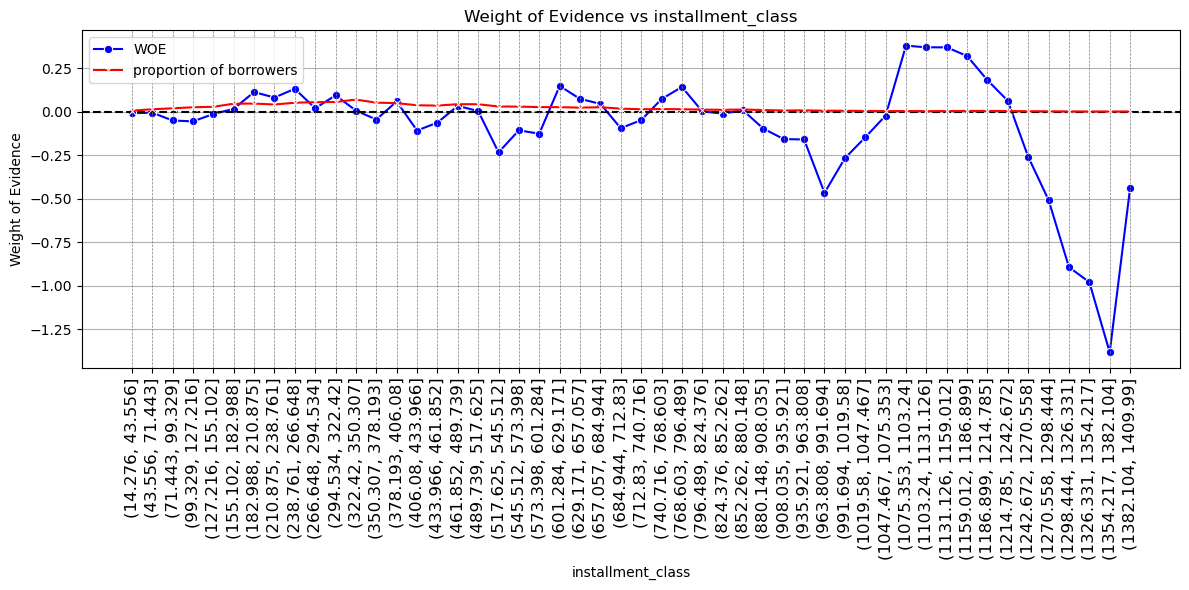

In [205]:
# Finding WoE
df_p = give_woe_iv_cont('installment_class', loan_data)
plot_woe_cont(df_p, 'installment_class')

In [824]:
# The WOE is fluctuating around 0, it is not a good predictor
# We can drop the installment and installment_class columns
loan_data.drop(['installment', 'installment_class'], axis=1, inplace=True) # Dropping the installment and installment_class

In [207]:
# Lets look into delinq_2yrs
loan_data['delinq_2yrs'].nunique()

24

In [208]:
loan_data['delinq_2yrs'].value_counts(normalize=True)

delinq_2yrs
0.0     0.821350
1.0     0.120579
2.0     0.034979
3.0     0.012190
4.0     0.005100
5.0     0.002651
6.0     0.001349
7.0     0.000742
8.0     0.000380
9.0     0.000238
10.0    0.000139
11.0    0.000088
12.0    0.000081
13.0    0.000054
14.0    0.000017
15.0    0.000015
18.0    0.000013
16.0    0.000011
17.0    0.000006
19.0    0.000006
21.0    0.000004
22.0    0.000004
29.0    0.000002
24.0    0.000002
Name: proportion, dtype: float64

Information Value for delinq_2yrs: inf


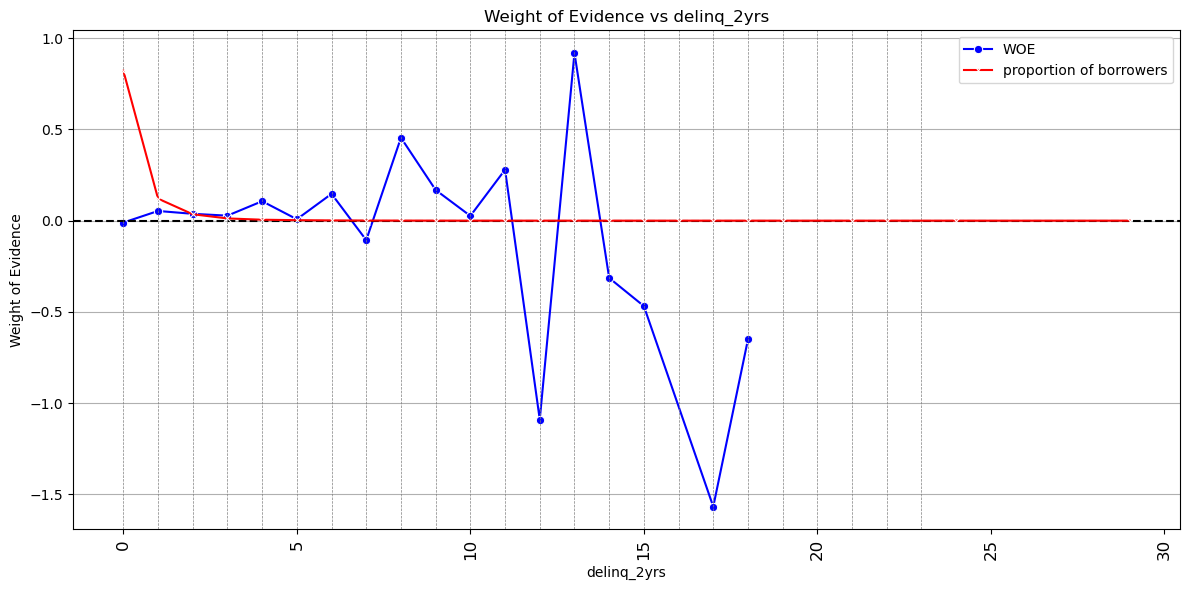

In [209]:
# Lets find the WOE of delinq_2yrs
df_p = give_woe_iv('delinq_2yrs', loan_data)
plot_woe(df_p, 'delinq_2yrs')

In [825]:
# Lets do the course classing as follows:
# First class : delinq_2yrs <=3
# Second class : delinq_2yrs > 3

# Lets do the course classing
loan_data['delinq_2yrs :<=3'] = np.where(loan_data['delinq_2yrs'] <= 3, 1, 0) # Creating a new column
loan_data['delinq_2yrs :>3'] = np.where(loan_data['delinq_2yrs'] > 3, 1, 0) # Creating

In [826]:
# Drop the delinq_2yrs column
loan_data.drop(['delinq_2yrs'], axis=1, inplace=True) # Dropping the delinq_2yrs column

In [212]:
# Lets look int ‘inq_last_6mths’
loan_data['inq_last_6mths'].nunique()

28

In [213]:
loan_data['inq_last_6mths'].value_counts(normalize=True)

inq_last_6mths
0.0     0.517981
1.0     0.279117
2.0     0.124012
3.0     0.053885
4.0     0.015529
5.0     0.005936
6.0     0.002548
7.0     0.000418
8.0     0.000262
9.0     0.000107
10.0    0.000051
11.0    0.000032
12.0    0.000032
15.0    0.000019
13.0    0.000013
14.0    0.000013
18.0    0.000009
16.0    0.000006
17.0    0.000004
24.0    0.000004
19.0    0.000004
32.0    0.000002
33.0    0.000002
31.0    0.000002
28.0    0.000002
25.0    0.000002
27.0    0.000002
20.0    0.000002
Name: proportion, dtype: float64

Information Value for inq_last_6mths: inf


/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


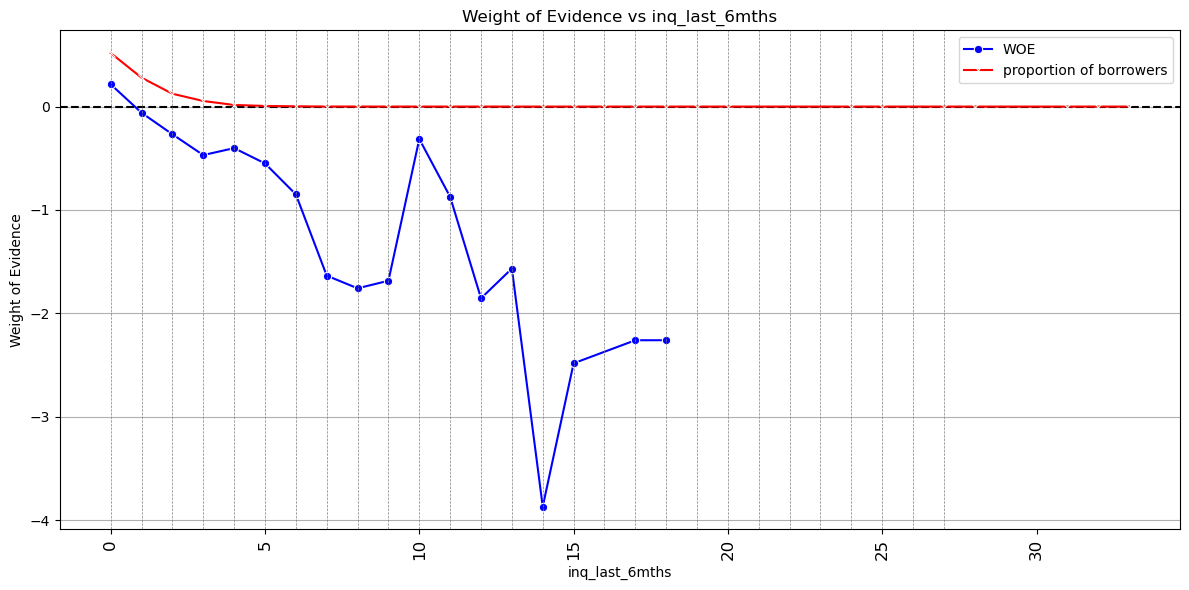

In [214]:
# Plottin the WOE
df_p = give_woe_iv('inq_last_6mths', loan_data)
plot_woe(df_p, 'inq_last_6mths')

In [827]:
# Lets do the course classing as follows:
# First class : inq_last_6mths = 0
# Second class : inq_last_6mths = 1
# Third class : inq_last_6mths >=2 and <=4
# Fourth class : inq_last_6mths >=5

# The course classing here
loan_data['inq_last_6mths :0'] = np.where(loan_data['inq_last_6mths'] == 0, 1, 0) # Creating a new column
loan_data['inq_last_6mths :1'] = np.where(loan_data['inq_last_6mths'] == 1, 1, 0) # Creating a new column
loan_data['inq_last_6mths :2-4'] = np.where((loan_data['inq_last_6mths'] >= 2) & (loan_data['inq_last_6mths'] <= 4), 1, 0) # Creating a new column
loan_data['inq_last_6mths :>=5'] = np.where(loan_data['inq_last_6mths'] >= 5, 1, 0) # Creating a new column

In [828]:
# Drop the inq_last_6mths column
loan_data.drop(['inq_last_6mths'], axis=1, inplace=True) # Dropping the inq_last_6mths column

In [217]:
# Lets look into ‘open_acc’
loan_data['open_acc'].nunique()

62

In [218]:
loan_data['open_acc'].value_counts(normalize=True)

open_acc
9.0     0.094404
10.0    0.091208
8.0     0.089844
11.0    0.083906
7.0     0.080642
12.0    0.074171
6.0     0.066133
13.0    0.063922
14.0    0.053036
5.0     0.046204
15.0    0.043394
16.0    0.036049
17.0    0.028721
4.0     0.026996
18.0    0.023301
19.0    0.018544
20.0    0.014300
3.0     0.011795
21.0    0.011321
22.0    0.008786
23.0    0.006773
24.0    0.005259
25.0    0.004146
2.0     0.003839
26.0    0.002818
27.0    0.002288
28.0    0.001643
29.0    0.001338
30.0    0.001038
31.0    0.000768
32.0    0.000635
33.0    0.000476
34.0    0.000397
35.0    0.000337
1.0     0.000305
36.0    0.000270
37.0    0.000214
38.0    0.000167
39.0    0.000144
40.0    0.000084
41.0    0.000077
42.0    0.000062
43.0    0.000041
45.0    0.000039
44.0    0.000026
49.0    0.000017
46.0    0.000015
0.0     0.000015
47.0    0.000013
48.0    0.000013
50.0    0.000011
53.0    0.000011
51.0    0.000011
58.0    0.000009
52.0    0.000004
54.0    0.000004
76.0    0.000004
55.0    0.000004
62.0 

Information Value for open_acc: inf


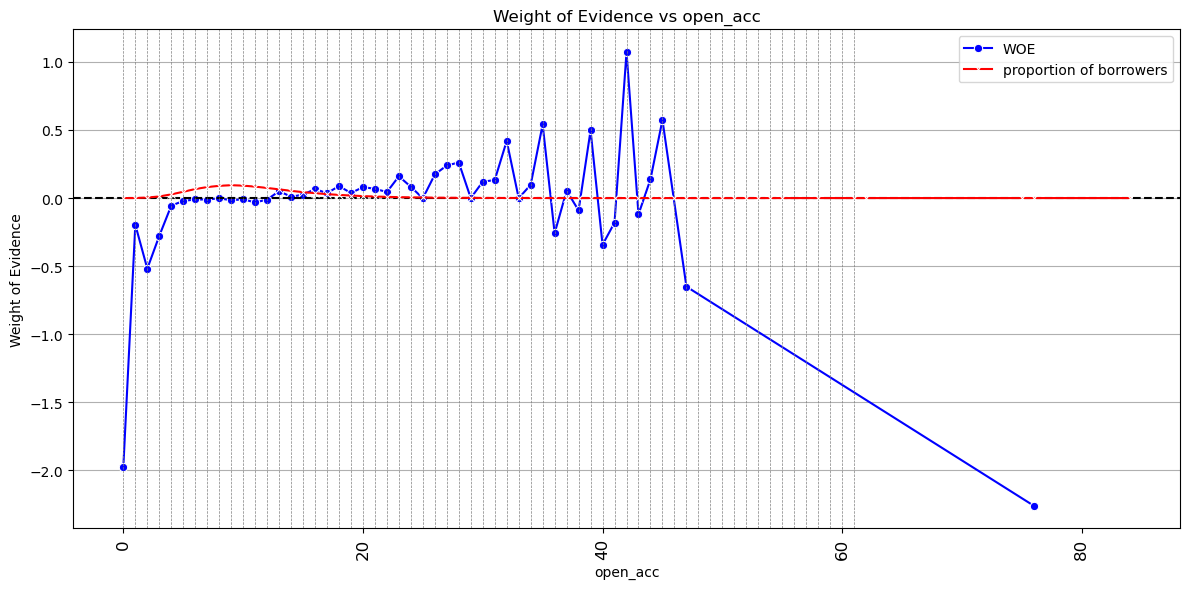

In [219]:
# Plottin the WOE
df_p = give_woe_iv('open_acc', loan_data)
plot_woe(df_p, 'open_acc')

In [829]:
# It seems that the WOE is fluctuating a lot, and it is not a good predictor
# We can drop the open_acc column
loan_data.drop(['open_acc'], axis=1, inplace=True) # Dropping the open_acc column

In [221]:
# ‘pub_rec’
loan_data['pub_rec'].nunique()

26

In [222]:
loan_data['pub_rec'].value_counts(normalize=True)

pub_rec
0.0     0.868400
1.0     0.113774
2.0     0.012061
3.0     0.003455
4.0     0.001115
5.0     0.000592
6.0     0.000292
7.0     0.000133
8.0     0.000062
9.0     0.000034
10.0    0.000028
11.0    0.000017
12.0    0.000004
18.0    0.000004
13.0    0.000004
40.0    0.000002
34.0    0.000002
21.0    0.000002
63.0    0.000002
54.0    0.000002
14.0    0.000002
15.0    0.000002
16.0    0.000002
19.0    0.000002
49.0    0.000002
17.0    0.000002
Name: proportion, dtype: float64

Information Value for pub_rec: inf


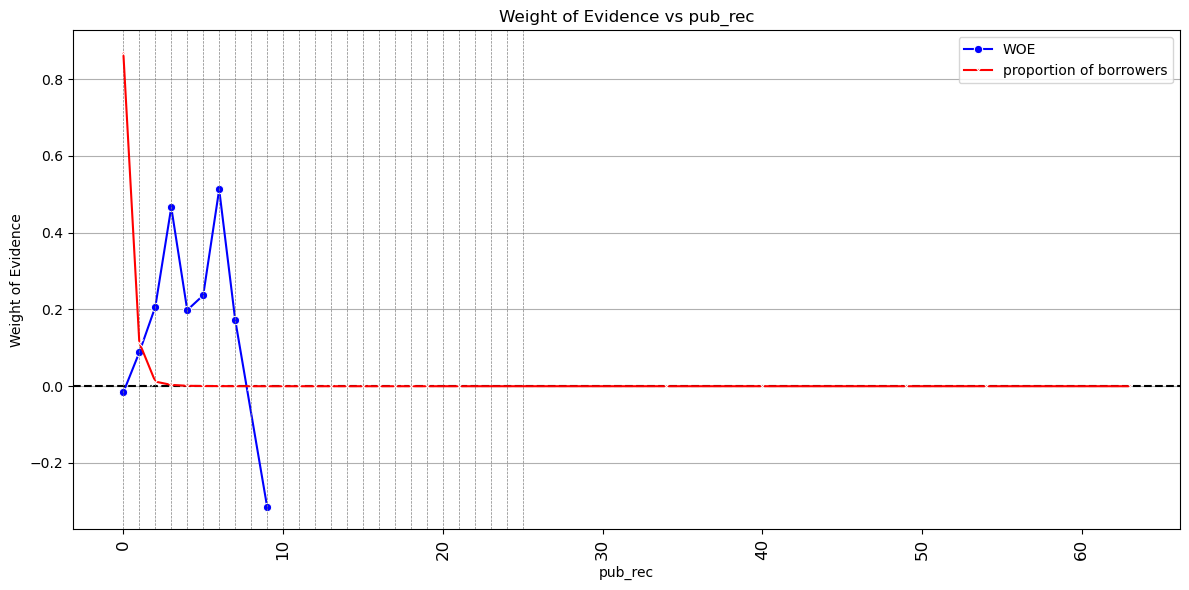

In [223]:
# Plottin the WOE
df_p = give_woe_iv('pub_rec', loan_data)
plot_woe(df_p, 'pub_rec')

In [830]:
# The WOE is not predictable, we can drop the pub_rec column
loan_data.drop(['pub_rec'], axis=1, inplace=True) # Drop

In [225]:
#‘total_acc’
loan_data['total_acc'].nunique()

112

In [226]:
total_acc = loan_data['total_acc'].value_counts(normalize=True)
total_acc

total_acc
21.0     0.036645
20.0     0.036615
22.0     0.036518
23.0     0.035894
19.0     0.035834
18.0     0.035365
17.0     0.035193
24.0     0.035144
25.0     0.033726
16.0     0.033572
26.0     0.032684
15.0     0.032000
27.0     0.031041
14.0     0.029943
28.0     0.029596
29.0     0.028322
13.0     0.028002
30.0     0.026737
12.0     0.025107
31.0     0.024627
32.0     0.023649
11.0     0.022675
33.0     0.021459
34.0     0.020074
10.0     0.019681
35.0     0.018474
36.0     0.016915
9.0      0.016368
37.0     0.015696
38.0     0.014036
8.0      0.013468
39.0     0.013196
40.0     0.011967
41.0     0.010884
7.0      0.010401
42.0     0.009951
43.0     0.008958
44.0     0.008190
6.0      0.007746
45.0     0.007242
46.0     0.006297
47.0     0.005846
48.0     0.005188
5.0      0.005119
49.0     0.004557
50.0     0.004116
51.0     0.003509
52.0     0.003434
4.0      0.003225
63.0     0.003078
53.0     0.002848
54.0     0.002475
55.0     0.002215
56.0     0.001956
57.0     0.001684


Information Value for total_acc: inf


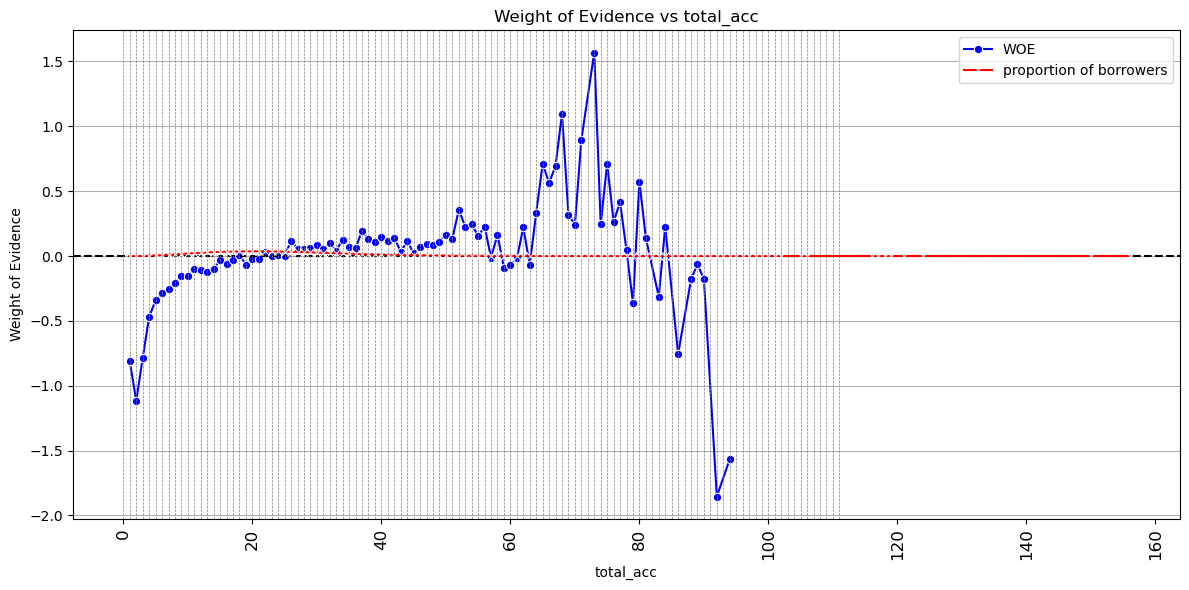

In [227]:
# Plotting the WOE
df_p = give_woe_iv('total_acc', loan_data)
plot_woe(df_p, 'total_acc')

In [831]:
# The course classing is as follows:
# First class : total_acc <= 5
# Second class : total_acc >= 6 and <= 18
# Third class : total_acc >= 19 and <= 52
# Fourth class : total_acc >= 53
loan_data['total_acc :<=5'] = np.where(loan_data['total_acc'] <= 5, 1, 0) # Creating a new column
loan_data['total_acc :6-18'] = np.where((loan_data['total_acc'] >= 6) & (loan_data['total_acc'] <= 18), 1, 0) # Creating a new column
loan_data['total_acc :19-52'] = np.where((loan_data['total_acc'] >= 19) & (loan_data['total_acc'] <= 52), 1, 0) # Creating a new column
loan_data['total_acc :>=53'] = np.where(loan_data['total_acc'] >= 53, 1, 0) # Creating a new column

In [832]:
# Lets drop the total_acc column
loan_data.drop(['total_acc'], axis=1, inplace=True) # Dropping the total_acc column

In [230]:
# Lets look into ‘acc_now_delinq’
loan_data['acc_now_delinq'].nunique()

6

Information Value for acc_now_delinq: inf


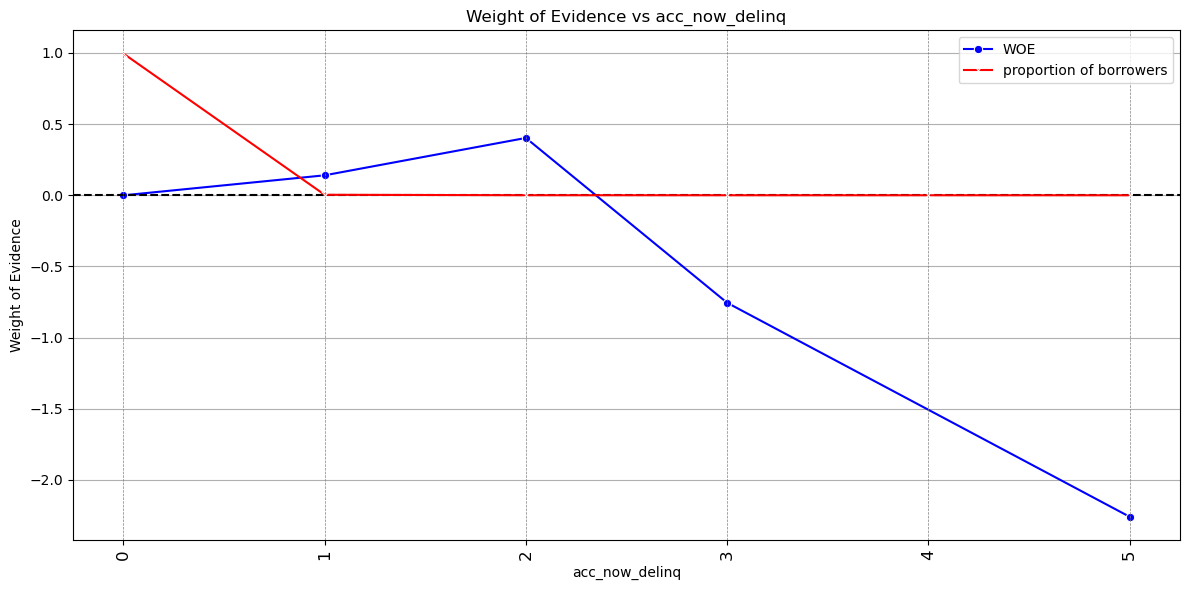

In [231]:
# Finding the WOE
df_p = give_woe_iv('acc_now_delinq', loan_data)
plot_woe(df_p, 'acc_now_delinq')

In [833]:
# A huge proportion of the borrowers have 0 accounts now delinquent
# Then how would it help us differentiate between the good and bad borrowers?
# We can drop the acc_now_delinq column
loan_data.drop(['acc_now_delinq'], axis=1, inplace=True) # Dropping the acc_now_delinq column

In [233]:
# Lets look into the annual_inc column
loan_data['annual_inc'].nunique()

31901

In [834]:
# We will do a rough fine classing by cutting it into bins
loan_data['annual_inc_class'] = pd.cut(loan_data['annual_inc'], 50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for annual_inc_class: inf


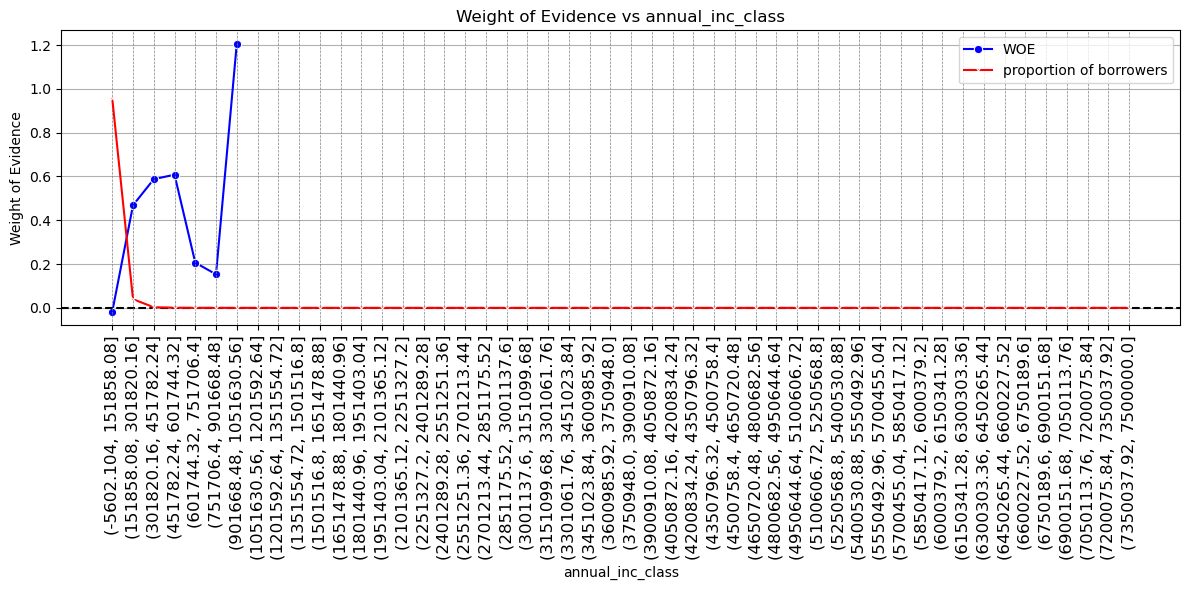

In [235]:
# Lets find the WOE for annual_inc_class
df_p = give_woe_iv_cont('annual_inc_class', loan_data)
plot_woe_cont(df_p, 'annual_inc_class')

In [236]:
df_p

# 95% of the borrowers fall in the first bin itself. This means we need more bins.

,bin,p0,p1,prop_borrower,WOE,IV
0,"(-5602.104, 151858.08]",0.971839,0.954523,0.956160,-0.017978,inf
1,"(151858.08, 301820.16]",0.025642,0.040962,0.039514,0.468414,inf
2,"(301820.16, 451782.24]",0.001702,0.003062,0.002934,0.587447,inf
3,"(451782.24, 601744.32]",0.000454,0.000834,0.000798,0.608113,inf
4,"(601744.32, 751706.4]",0.000204,0.000251,0.000247,0.206429,inf
5,"(751706.4, 901668.48]",0.000136,0.000159,0.000157,0.153148,inf
6,"(901668.48, 1051630.56]",0.000023,0.000076,0.000071,1.205950,inf
7,"(1051630.56, 1201592.64]",0.000000,0.000050,0.000045,inf,inf
8,"(1201592.64, 1351554.72]",0.000000,0.000024,0.000021,inf,inf
9,"(1351554.72, 1501516.8]",0.000000,0.000014,0.000013,inf,inf


In [837]:
# We will do a rough fine classing by cutting it into bins 100
loan_data['annual_inc_class'] = pd.cut(loan_data['annual_inc'], 100)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for annual_inc_class: inf


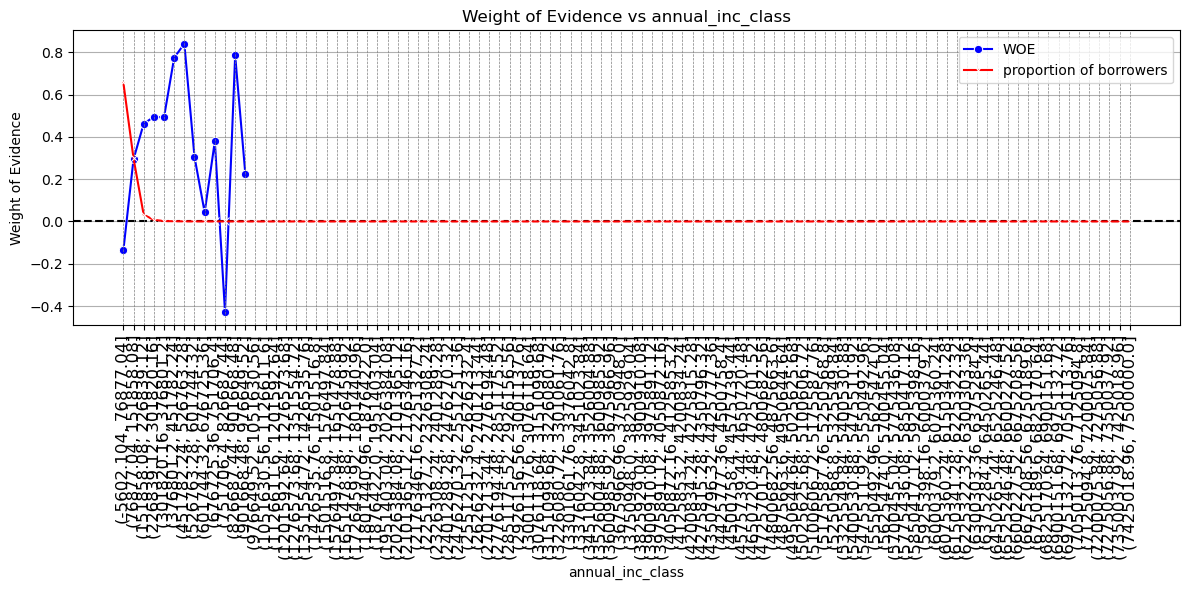

In [238]:
# Lets find the WOE for annual_inc_class
df_p = give_woe_iv_cont('annual_inc_class', loan_data)
plot_woe_cont(df_p, 'annual_inc_class')

In [239]:
df_p

,bin,p0,p1,prop_borrower,WOE,IV
0,"(-5602.104, 76877.04]",0.743487,0.648195,0.657201,-0.137160,inf
1,"(76877.04, 151858.08]",0.228352,0.306328,0.298959,0.293771,inf
2,"(151858.08, 226839.12]",0.020809,0.033038,0.031882,0.462270,inf
3,"(226839.12, 301820.16]",0.004833,0.007925,0.007633,0.494443,inf
4,"(301820.16, 376801.2]",0.001180,0.001930,0.001859,0.492159,inf
5,"(376801.2, 451782.24]",0.000522,0.001132,0.001074,0.774331,inf
6,"(451782.24, 526763.28]",0.000227,0.000526,0.000498,0.840307,inf
7,"(526763.28, 601744.32]",0.000227,0.000308,0.000300,0.305164,inf
8,"(601744.32, 676725.36]",0.000113,0.000118,0.000118,0.042800,inf
9,"(676725.36, 751706.4]",0.000091,0.000133,0.000129,0.379272,inf


In [77]:
# It seems that >90% of the borrowers fall in the first two bins itself despite of increasing the number of bins
# Lets find 95% percentile of annual_inc
percentile_95 = np.percentile(loan_data['annual_inc'], 95)
print("95th percentile of annual income:", percentile_95)

95th percentile of annual income: 150000.0


In [78]:
# Lets first have a temporary data frame of the rows where annual_inc is less than 95th percentile
loan_data_temp = loan_data[loan_data['annual_inc'] < percentile_95]

In [79]:
# Lets create 50 bins of annual_inc for the temporary data frame
loan_data_temp['annual_inc_class'] = pd.cut(loan_data_temp['annual_inc'], 50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1442342048.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_temp['annual_inc_class'] = pd.cut(loan_data_temp['annual_inc'], 50)


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for annual_inc_class: 0.056374620020988975


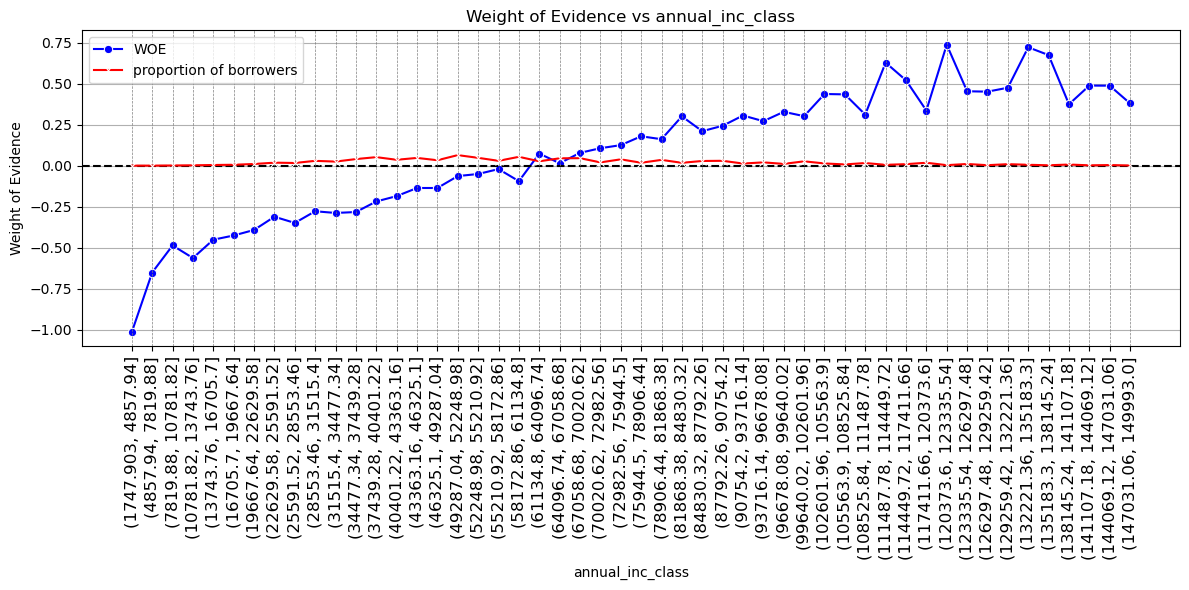

In [243]:
# Lets find the WOE for annual_inc_class from the temporary data frame
df_p = give_woe_iv_cont('annual_inc_class', loan_data_temp)
plot_woe_cont(df_p, 'annual_inc_class')

In [836]:
# So we do the course classing as follows:
# First class : annual_inc < 10000
# Second class : annual_inc >= 10000 and < 22000
# Third class : annual_inc >= 22000 and < 37000
# Fourth class : annual_inc >= 37000 and < 46000
# Fifth class : annual_inc >= 46000 and < 56000
# Sixth class : annual_inc >= 56000 and < 76000
# Seventh class : annual_inc >= 76000 and < 96000
# Eighth class : annual_inc >= 96000 and < 114000
# Ninth class : annual_inc >= 114000 and < 140000
# Tenth class : annual_inc >= 140000 

# So the classes would be
loan_data['annual_inc_class :<10000'] = np.where(loan_data['annual_inc'] < 10000, 1, 0) # Creating a new column
loan_data['annual_inc_class :10000-22000'] = np.where((loan_data['annual_inc'] >= 10000) & (loan_data['annual_inc'] < 22000), 1, 0) # Creating a new column
loan_data['annual_inc_class :22000-37000'] = np.where((loan_data['annual_inc'] >= 22000) & (loan_data['annual_inc'] < 37000), 1, 0) # Creating a new column
loan_data['annual_inc_class :37000-46000'] = np.where((loan_data['annual_inc'] >= 37000) & (loan_data['annual_inc'] < 46000), 1, 0) # Creating a new column
loan_data['annual_inc_class :46000-56000'] = np.where((loan_data['annual_inc'] >= 46000) & (loan_data['annual_inc'] < 56000), 1, 0) # Creating a new column
loan_data['annual_inc_class :56000-76000'] = np.where((loan_data['annual_inc'] >= 56000) & (loan_data['annual_inc'] < 76000), 1, 0) # Creating a new column
loan_data['annual_inc_class :76000-96000'] = np.where((loan_data['annual_inc'] >= 76000) & (loan_data['annual_inc'] < 96000), 1, 0) # Creating a new column
loan_data['annual_inc_class :96000-114000'] = np.where((loan_data['annual_inc'] >= 96000) & (loan_data['annual_inc'] < 114000), 1, 0) # Creating a new column
loan_data['annual_inc_class :114000-140000'] = np.where((loan_data['annual_inc'] >= 114000) & (loan_data['annual_inc'] < 140000), 1, 0) # Creating a new column
loan_data['annual_inc_class :>=140000'] = np.where(loan_data['annual_inc'] >= 140000, 1, 0) # Creating a new column

In [838]:
# Lets drop the annual_inc and annual_inc_class columns
loan_data.drop(['annual_inc', 'annual_inc_class'], axis=1, inplace=True) # Dropping the annual_inc and annual_inc_class columns

In [246]:
# Consider for dti
loan_data['dti'].nunique()

3997

In [247]:
loan_data['dti'].value_counts(normalize=True)

dti
14.40    0.000879
19.20    0.000817
12.00    0.000791
16.80    0.000789
18.00    0.000783
13.20    0.000781
0.00     0.000778
20.40    0.000759
15.60    0.000731
21.60    0.000661
10.80    0.000635
16.20    0.000631
22.80    0.000628
24.00    0.000616
15.12    0.000605
14.64    0.000600
12.48    0.000596
15.84    0.000596
9.60     0.000588
16.32    0.000588
13.44    0.000585
18.60    0.000583
18.72    0.000579
17.04    0.000577
16.08    0.000577
14.88    0.000573
13.92    0.000570
12.72    0.000568
13.80    0.000566
18.48    0.000564
20.88    0.000562
11.52    0.000562
17.76    0.000562
16.56    0.000560
13.68    0.000560
14.16    0.000555
11.76    0.000553
19.68    0.000551
15.48    0.000547
15.63    0.000545
20.00    0.000540
16.77    0.000538
12.96    0.000534
14.74    0.000534
13.65    0.000532
18.96    0.000532
17.28    0.000532
21.36    0.000530
16.26    0.000530
18.12    0.000530
15.71    0.000530
12.58    0.000525
15.00    0.000525
12.24    0.000525
18.14    0.000525
16.30 

In [839]:
# Lets first do a rough fine classing by cutting it into bins
loan_data['dti_class'] = pd.cut(loan_data['dti'], 50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for dti_class: 0.023701815254818726


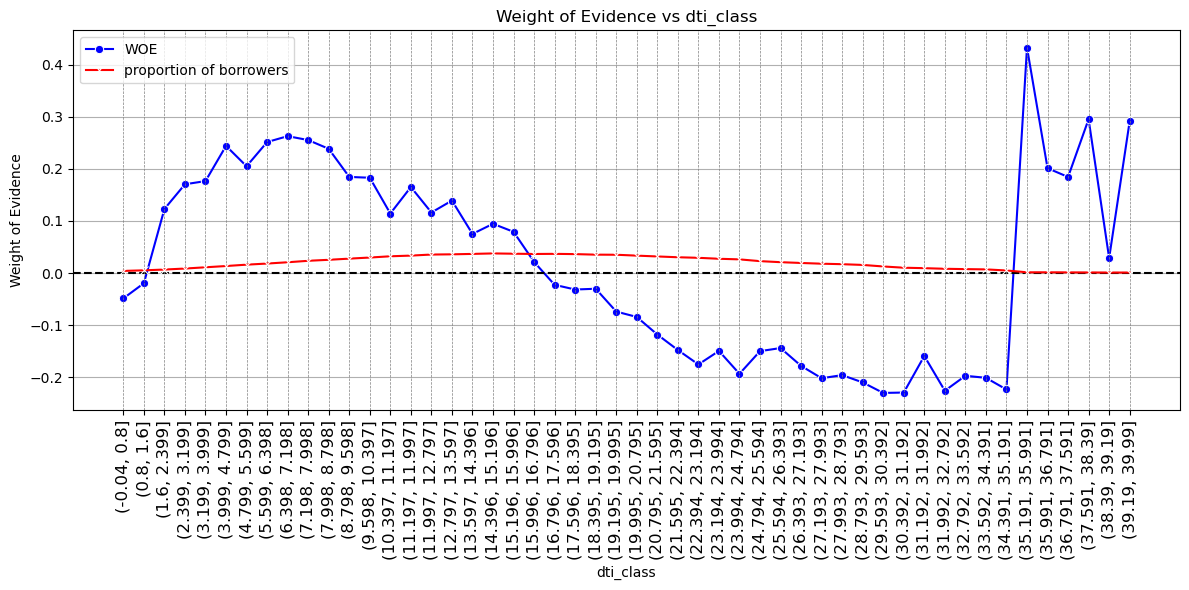

In [249]:
# Finding the WOE
df_p = give_woe_iv_cont('dti_class', loan_data)
plot_woe_cont(df_p, 'dti_class')

In [840]:
# The course classing is as follows:
# First class : dti <= 1.6
# Second class : dti > 1.6 and <= 4
# Third class : dti > 4 and <= 11.2
# Fourth class : dti > 11.2 and <= 15.2
# Fifth class : dti > 15.2 and <= 17.6
# Sixth class : dti > 17.6 and <= 19.2
# Seventh class : dti > 19.2 and <= 20.8
# Eighth class : dti > 20.8 and <= 23.2
# Ninth class : dti > 23.2 and <= 27.2
# Tenth class : dti > 27.2 and <= 35.2
# Eleventh class : dti > 35.2 

# So the classes would be
loan_data['dti_class :<=1.6'] = np.where(loan_data['dti'] <= 1.6, 1, 0) # Creating a new column
loan_data['dti_class :1.6-4'] = np.where((loan_data['dti'] > 1.6) & (loan_data['dti'] <= 4), 1, 0) # Creating a new column
loan_data['dti_class :4-11.2'] = np.where((loan_data['dti'] > 4) & (loan_data['dti'] <= 11.2), 1, 0) # Creating a new column
loan_data['dti_class :11.2-15.2'] = np.where((loan_data['dti'] > 11.2) & (loan_data['dti'] <= 15.2), 1, 0) # Creating a new column
loan_data['dti_class :15.2-17.6'] = np.where((loan_data['dti'] > 15.2) & (loan_data['dti'] <= 17.6), 1, 0) # Creating a new column
loan_data['dti_class :17.6-19.2'] = np.where((loan_data['dti'] > 17.6) & (loan_data['dti'] <= 19.2), 1, 0) # Creating a new column
loan_data['dti_class :19.2-20.8'] = np.where((loan_data['dti'] > 19.2) & (loan_data['dti'] <= 20.8), 1, 0) # Creating a new column
loan_data['dti_class :20.8-23.2'] = np.where((loan_data['dti'] > 20.8) & (loan_data['dti'] <= 23.2), 1, 0) # Creating a new column
loan_data['dti_class :23.2-27.2'] = np.where((loan_data['dti'] > 23.2) & (loan_data['dti'] <= 27.2), 1, 0) # Creating a new column
loan_data['dti_class :27.2-35.2'] = np.where((loan_data['dti'] > 27.2) & (loan_data['dti'] <= 35.2), 1, 0) # Creating a new column
loan_data['dti_class :>35.2'] = np.where(loan_data['dti'] > 35.2, 1, 0) # Creating a new column


In [841]:
# Lets drop the dti and dti_class columns
loan_data.drop(['dti', 'dti_class'], axis=1, inplace=True) # Dropping the dti

In [842]:
# Lets find the numeric columns again
numeric_columns = loan_data.select_dtypes(include=['int64', 'float64']).columns # Selecting the numeric columns
numeric_columns_list = numeric_columns.tolist() # Converting to list for easier manipulation
numeric_columns_list 

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt_inv',
 'emp_length',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'revol_bal',
 'revol_util',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'months_since_last_pymnt_d',
 'months_since_last_credit_pull_d',
 'months_since_next_pymnt_d',
 'good_bad',
 'months_since_issue_d_class :<38',
 'months_since_issue_d_class :38-40',
 'months_since_issue_d_class :40-42',
 'months_since_issue_d_class :42-44',
 'months_since_issue_d_class :44-45',
 'months_since_issue_d_class :45-49',
 'months_since_issue_d_class :49-50',
 'months_since_issue_d_class :50-51',
 'months_since_issue_d_class :51-52',
 'months_since_issue_d_class :52-54',
 'months_since_issue_d_class :54-63

In [253]:
# Lets work with loan_amnt
loan_data['loan_amnt'].nunique()

1352

In [843]:
# Lets first do a rough fine classing by cutting it into bins
loan_data['loan_amnt_class'] = pd.cut(loan_data['loan_amnt'], 50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for loan_amnt_class: 0.014535301297335022


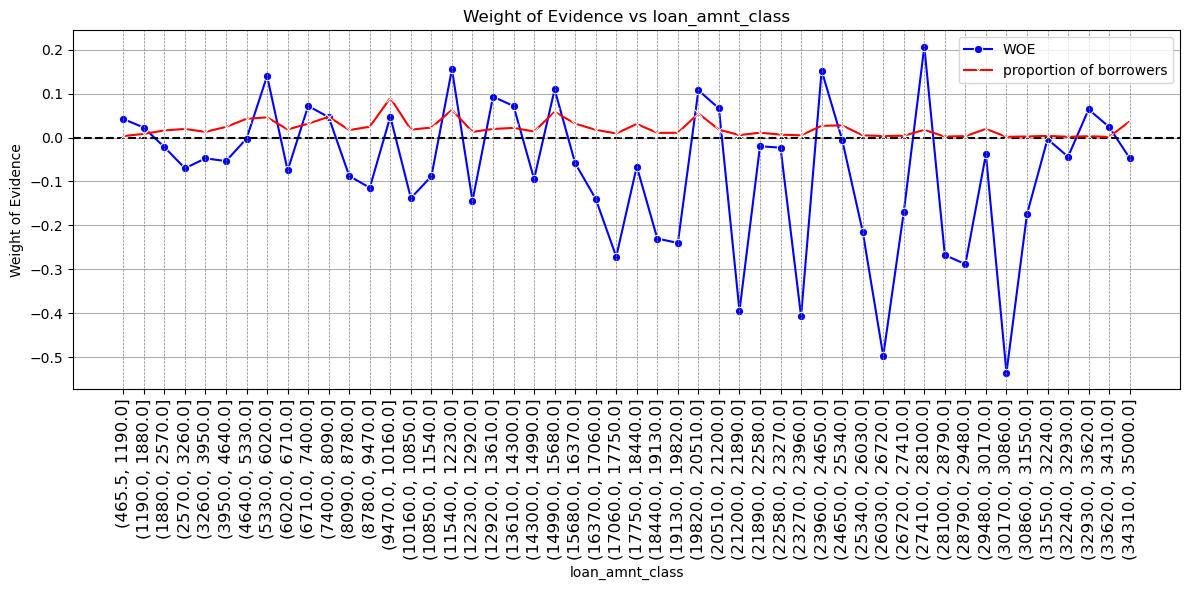

In [255]:
# Finding the WOE
df_p = give_woe_iv_cont('loan_amnt_class', loan_data)
plot_woe_cont(df_p, 'loan_amnt_class')

In [844]:
# We cant make any sense out of the WOE values, we can drop the loan_amnt and loan_amnt_class columns
loan_data.drop(['loan_amnt', 'loan_amnt_class'], axis=1, inplace=True) # Dropping the loan_amnt and loan_amnt_class columns

In [257]:
#Lets look into 'funded_amnt_inv'
loan_data['funded_amnt_inv'].nunique()

9854

In [845]:
# Lets first do a rough fine classing by cutting it into bins
loan_data['funded_amnt_inv_class'] = pd.cut(loan_data['funded_amnt_inv'], 50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for funded_amnt_inv_class: 0.021940276827787746


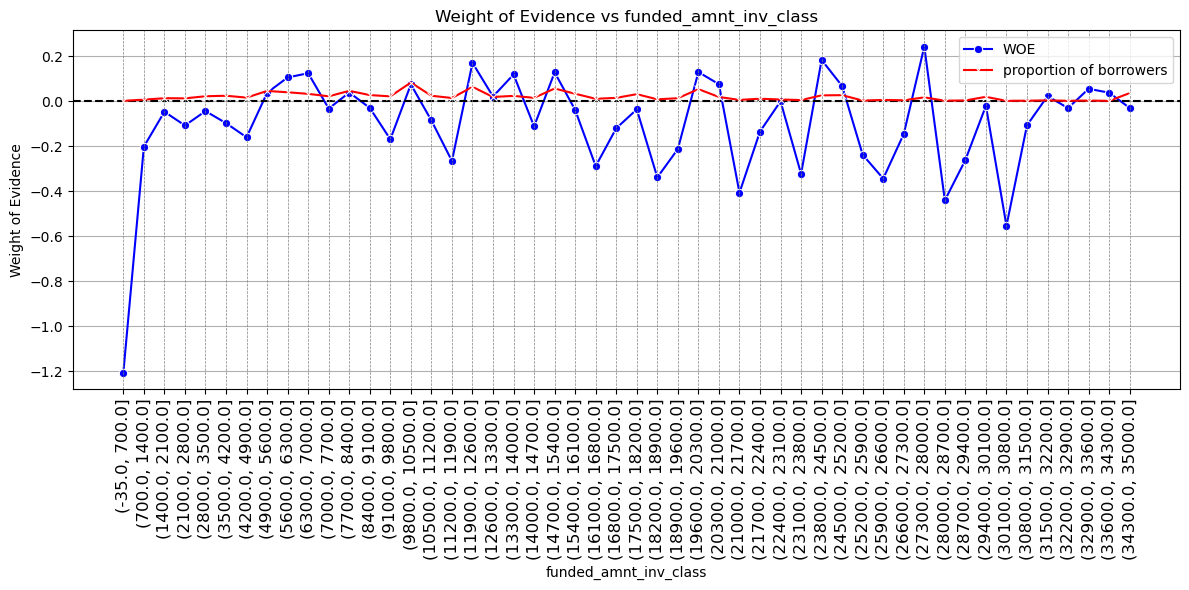

In [259]:
# Finding the WOE
df_p = give_woe_iv_cont('funded_amnt_inv_class', loan_data)
plot_woe_cont(df_p, 'funded_amnt_inv_class')

In [846]:
# WOE is fluctuating a lot, we can drop the funded_amnt_inv and funded_amnt_inv_class columns
loan_data.drop(['funded_amnt_inv', 'funded_amnt_inv_class'], axis=1, inplace=True) # Dropping the funded_amnt_inv and funded

In [261]:
# Lets look into emp_length
loan_data['emp_length'].nunique()

11

In [401]:
loan_data['emp_length'].value_counts(normalize=True)

emp_length
10.0    0.321797
6.0     0.096158
2.0     0.088729
3.0     0.078484
0.0     0.077774
5.0     0.065998
1.0     0.063528
7.0     0.061042
4.0     0.060098
8.0     0.048029
9.0     0.038363
Name: proportion, dtype: float64

Information Value for emp_length: 0.007115203165804189


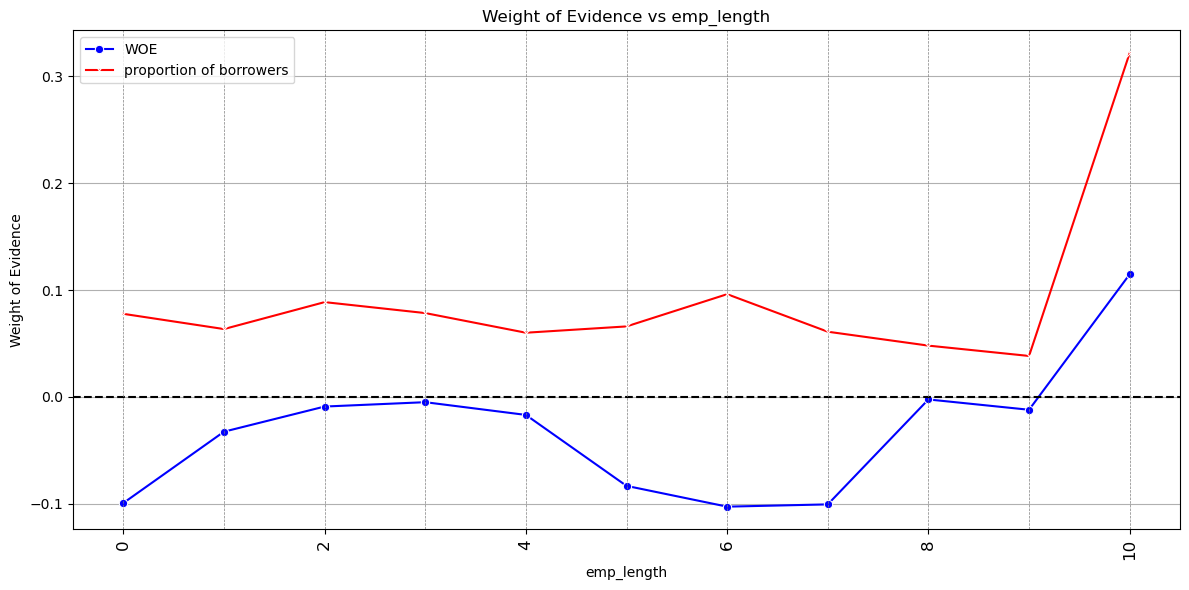

In [262]:
# Finding the WOE
df_p = give_woe_iv('emp_length', loan_data)
plot_woe(df_p, 'emp_length')

In [847]:
# The course classing is as follows:
# First class : emp_length = 0
# Second class : emp_length = 1-4
# Third class : emp_length = 5-7
# Fourth class : emp_length = 8-9
# Fifth class : emp_length = 10+

# So the classes would be
loan_data['emp_length :0'] = np.where(loan_data['emp_length'] == 0, 1, 0) # Creating a new column
loan_data['emp_length :1-4'] = np.where(loan_data['emp_length'].isin(range(1,5)), 1, 0) # Creating a new column
loan_data['emp_length :5-7'] = np.where(loan_data['emp_length'].isin(range(5,8)), 1, 0) # Creating a new column
loan_data['emp_length :8-9'] = np.where(loan_data['emp_length'].isin(range(8,10)), 1, 0) # Creating a new column
loan_data['emp_length :10+'] = np.where(loan_data['emp_length'] >= 10, 1, 0) # Creating a new column


In [848]:
# Lets drop the emp_length column
loan_data.drop(['emp_length'], axis=1, inplace=True) # Dropping the emp_length column

In [265]:
# Lets look into the revol_bal column
loan_data['revol_bal'].nunique()


58142

In [266]:
desc.loc['revol_bal']

Description    Total credit revolving balance
Name: revol_bal, dtype: object

In [849]:
# Lets first do a rough fine classing by cutting it into bins
loan_data['revol_bal_class'] = pd.cut(loan_data['revol_bal'], 100)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for revol_bal_class: inf


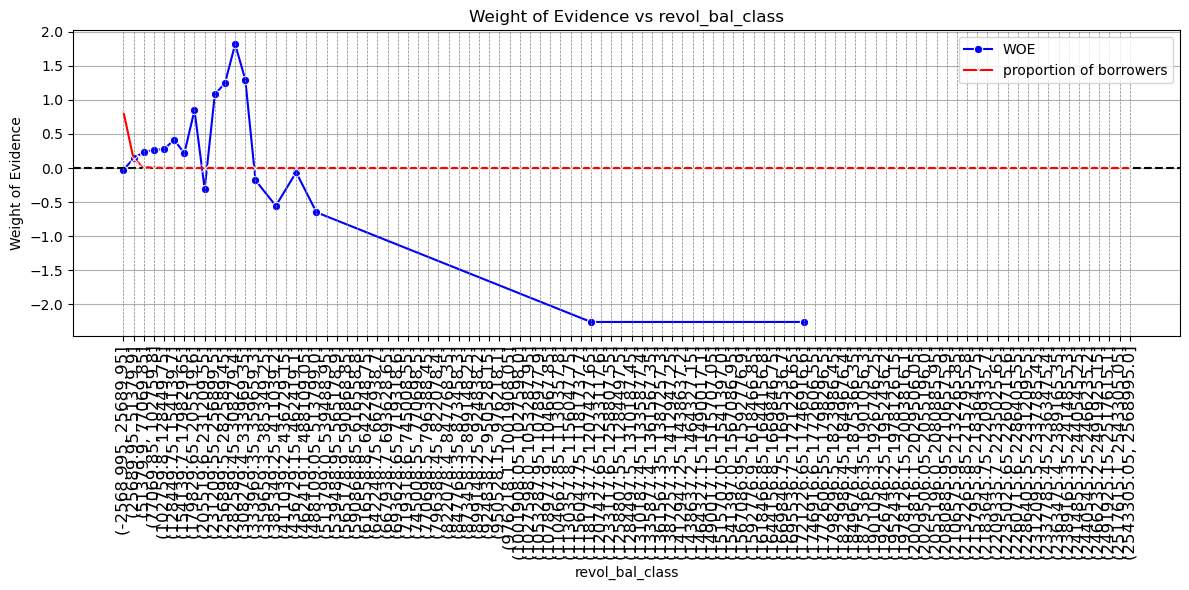

In [268]:
# Finding the WOE
df_p = give_woe_iv_cont('revol_bal_class', loan_data)
plot_woe_cont(df_p, 'revol_bal_class')

In [269]:
df_p

,bin,p0,p1,prop_borrower,WOE,IV
0,"(-2568.995, 25689.95]",0.858219,0.833510,0.835845,-0.029214,inf
1,"(25689.95, 51379.9]",0.120836,0.139033,0.137313,0.140276,inf
2,"(51379.9, 77069.85]",0.012254,0.015483,0.015177,0.233879,inf
3,"(77069.85, 102759.8]",0.003835,0.005009,0.004898,0.267126,inf
4,"(102759.8, 128449.75]",0.002042,0.002693,0.002631,0.276553,inf
5,"(128449.75, 154139.7]",0.000998,0.001511,0.001463,0.414363,inf
6,"(154139.7, 179829.65]",0.000635,0.000789,0.000774,0.216152,inf
7,"(179829.65, 205519.6]",0.000227,0.000531,0.000502,0.849275,inf
8,"(205519.6, 231209.55]",0.000477,0.000351,0.000362,-0.307096,inf
9,"(231209.55, 256899.5]",0.000091,0.000268,0.000251,1.081308,inf


In [851]:
# Lets have a temporary data frame of the rows where revol_bal is less than 95th percentile
percentile_95 = np.percentile(loan_data['revol_bal'], 95)
loan_data_temp = loan_data[loan_data['revol_bal'] < percentile_95]


In [271]:
percentile_95

40952.79999999999

In [852]:
# Lets create 50 bins of revol_bal for the temporary data frame
loan_data_temp['revol_bal_class'] = pd.cut(loan_data_temp['revol_bal'], 50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/2489094178.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_temp['revol_bal_class'] = pd.cut(loan_data_temp['revol_bal'], 50)


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for revol_bal_class: 0.006094125653425294


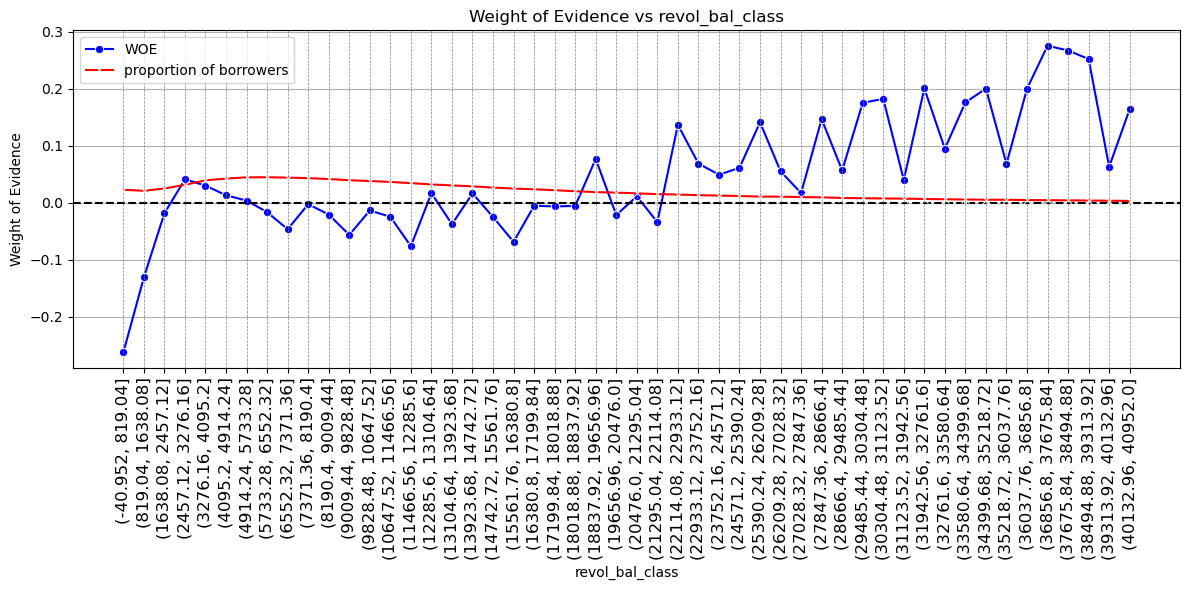

In [273]:
# Lets find the WOE for revol_bal_class from the temporary data frame
df_p = give_woe_iv_cont('revol_bal_class', loan_data_temp)
plot_woe_cont(df_p, 'revol_bal_class')

In [853]:
# The course classing is as follows:    
# First class : revol_bal < 819
# Second class : revol_bal >= 819 and < 1639
# Third class : revol_bal >= 1639 and < 5734
# Fourth class : revol_bal >= 5734 and < 12286
# Fifth class : revol_bal >= 12286 and < 18019
# Sixth class : revol_bal >= 18019 and < 22115
# Seventh class : revol_bal >= 22115 and < 29486
# Eighth class : revol_bal >= 29486 and < 40952
# Ninth class : revol_bal >= 40952 

# So the classes would be
loan_data['revol_bal_class :<819'] = np.where(loan_data['revol_bal'] < 819, 1, 0) # Creating a new column
loan_data['revol_bal_class :819-1639'] = np.where((loan_data['revol_bal'] >= 819) & (loan_data['revol_bal'] < 1639), 1, 0) # Creating a new column
loan_data['revol_bal_class :1639-5734'] = np.where((loan_data['revol_bal'] >= 1639) & (loan_data['revol_bal'] < 5734), 1, 0) # Creating a new column
loan_data['revol_bal_class :5734-12286'] = np.where((loan_data['revol_bal'] >= 5734) & (loan_data['revol_bal'] < 12286), 1, 0) # Creating a new column
loan_data['revol_bal_class :12286-18019'] = np.where((loan_data['revol_bal'] >= 12286) & (loan_data['revol_bal'] < 18019), 1, 0) # Creating a new column
loan_data['revol_bal_class :18019-22115'] = np.where((loan_data['revol_bal'] >= 18019) & (loan_data['revol_bal'] < 22115), 1, 0) # Creating a new column
loan_data['revol_bal_class :22115-29486'] = np.where((loan_data['revol_bal'] >= 22115) & (loan_data['revol_bal'] < 29486), 1, 0) # Creating a new column
loan_data['revol_bal_class :29486-40952'] = np.where((loan_data['revol_bal'] >= 29486) & (loan_data['revol_bal'] < 40952), 1, 0) # Creating a new column
loan_data['revol_bal_class :>=40952'] = np.where(loan_data['revol_bal'] >= 40952, 1, 0) # Creating a new column



In [854]:
# Lets drop the revol_bal and revol_bal_class columns
loan_data.drop(['revol_bal', 'revol_bal_class'], axis=1, inplace=True) # Dropping the revol_bal and revol_bal_class columns

In [276]:
# Lets look into the total_rev_hi_lim column
loan_data['total_rev_hi_lim'].nunique()

14933

In [855]:
# Creating 100 bins for total_rev_hi_lim
loan_data['total_rev_hi_lim_class'] = pd.cut(loan_data['total_rev_hi_lim'], 50)


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()
/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Information Value for total_rev_hi_lim_class: inf


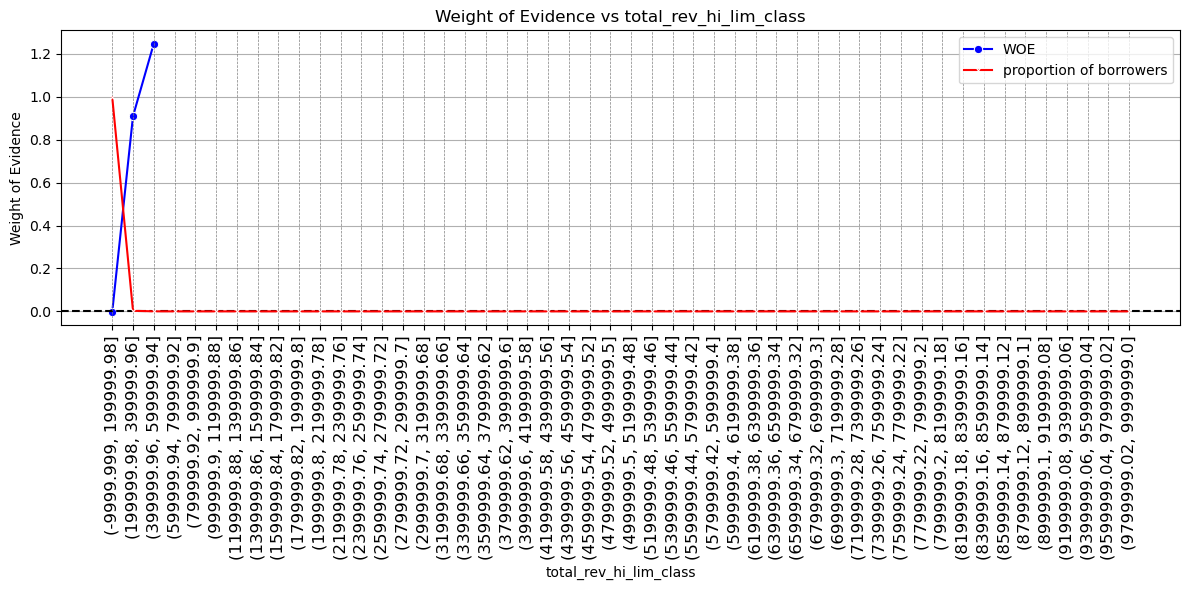

In [278]:
# Finding the WOE
df_p = give_woe_iv_cont('total_rev_hi_lim_class', loan_data)
plot_woe_cont(df_p, 'total_rev_hi_lim_class')


In [98]:
# Finding the 95th percentile of total_rev_hi_lim
percentile_95 = np.percentile(loan_data['total_rev_hi_lim'], 95)
print("95th percentile of total_rev_hi_lim:", percentile_95)

95th percentile of total_rev_hi_lim: 72300.0


In [856]:
# Lets do the following course classing
# First class : total_rev_hi_lim < 200000
# Second class : total_rev_hi_lim >= 200000 and < 600000
# Third class : total_rev_hi_lim >= 600000 

# So the classes would be
loan_data['total_rev_hi_lim_class :<200000'] = np.where(loan_data['total_rev_hi_lim'] < 200000, 1, 0) # Creating a new column
loan_data['total_rev_hi_lim_class :200000-600000'] = np.where((loan_data['total_rev_hi_lim'] >= 200000) & (loan_data['total_rev_hi_lim'] < 600000), 1, 0) # Creating a new column
loan_data['total_rev_hi_lim_class :>=600000'] = np.where(loan_data['total_rev_hi_lim'] >= 600000, 1, 0) # Creating a new column

In [857]:
# Lets drop the total_rev_hi_lim and total_rev_hi_lim_class columns
loan_data.drop(['total_rev_hi_lim', 'total_rev_hi_lim_class'], axis=1, inplace=True) # Dropping the total_rev_hi_lim and total_rev_hi_lim_class columns

In [858]:
# Lets find the numeric columns again
numeric_columns = loan_data.select_dtypes(include=['int64', 'float64']).columns # Selecting the numeric columns
numeric_columns_list = numeric_columns.tolist() # Converting to list for easier manipulation
numeric_columns_list

['id',
 'member_id',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'revol_util',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'tot_coll_amt',
 'tot_cur_bal',
 'months_since_last_pymnt_d',
 'months_since_last_credit_pull_d',
 'months_since_next_pymnt_d',
 'good_bad',
 'months_since_issue_d_class :<38',
 'months_since_issue_d_class :38-40',
 'months_since_issue_d_class :40-42',
 'months_since_issue_d_class :42-44',
 'months_since_issue_d_class :44-45',
 'months_since_issue_d_class :45-49',
 'months_since_issue_d_class :49-50',
 'months_since_issue_d_class :50-51',
 'months_since_issue_d_class :51-52',
 'months_since_issue_d_class :52-54',
 'months_since_issue_d_class :54-63',
 'months_since_issue_d_class :63-76',
 'months_since_issue_d_class :76-96',
 'mon

In [284]:
# Lets look into 'mths_since_last_delinq'
loan_data['mths_since_last_delinq'].nunique()

145

/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Information Value for mths_since_last_delinq: inf


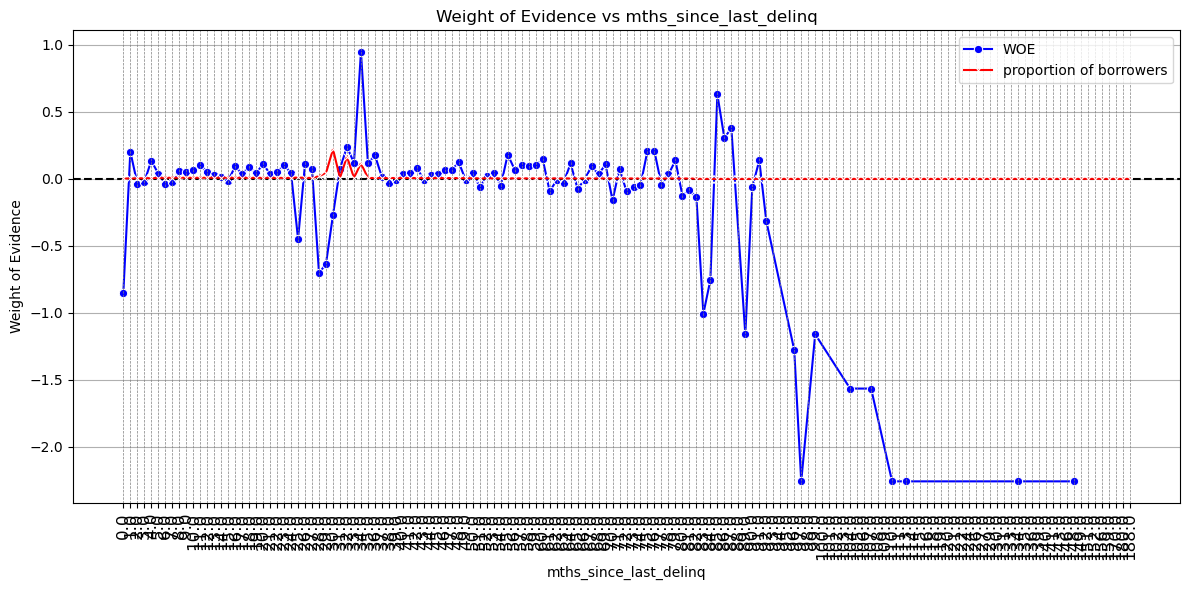

In [285]:
# Finding the WOE
df_p = give_woe_iv_cont('mths_since_last_delinq', loan_data)
plot_woe_cont(df_p, 'mths_since_last_delinq')

In [859]:
# This is too much fluctuation in value of WOE
# Drop 'mths_since_last_delinq'
loan_data.drop(columns=['mths_since_last_delinq'], inplace=True)

In [287]:
# Lets look into 'mths_since_last_record'
loan_data['mths_since_last_record'].nunique()

123

/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Information Value for mths_since_last_record: inf


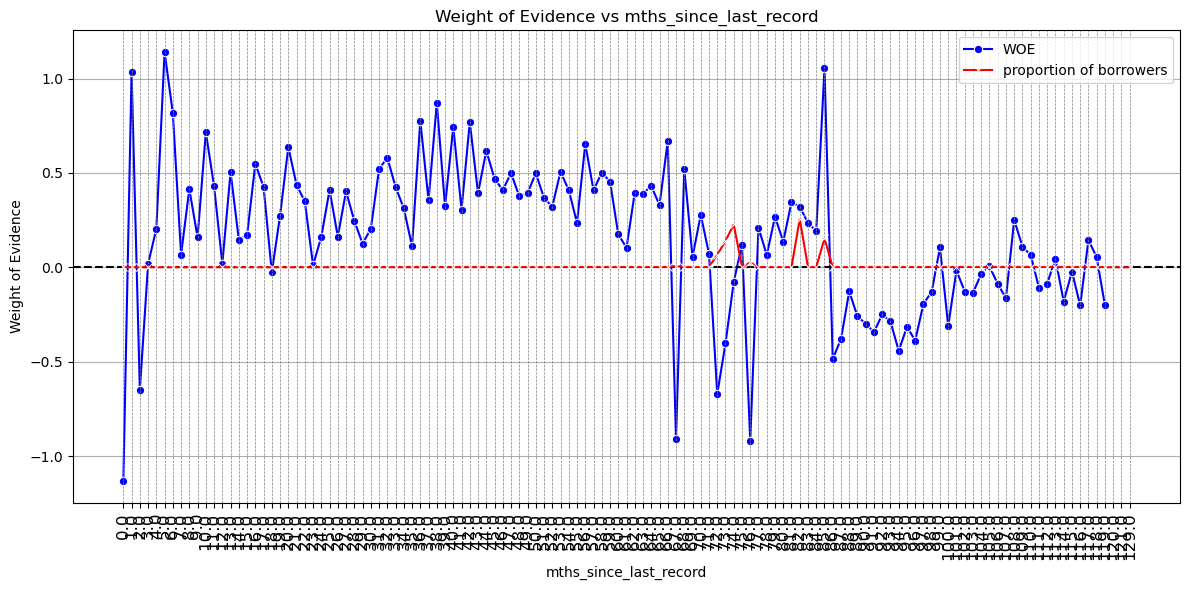

In [288]:
# Finding WoE
df_p = give_woe_iv_cont('mths_since_last_record', loan_data)
plot_woe_cont(df_p, 'mths_since_last_record')

In [860]:
# Lets first cut it in 15 bins
loan_data['mths_since_last_record_class'] = pd.cut(loan_data['mths_since_last_record'], 15)


Information Value for mths_since_last_record_class: 0.1660750337672627


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


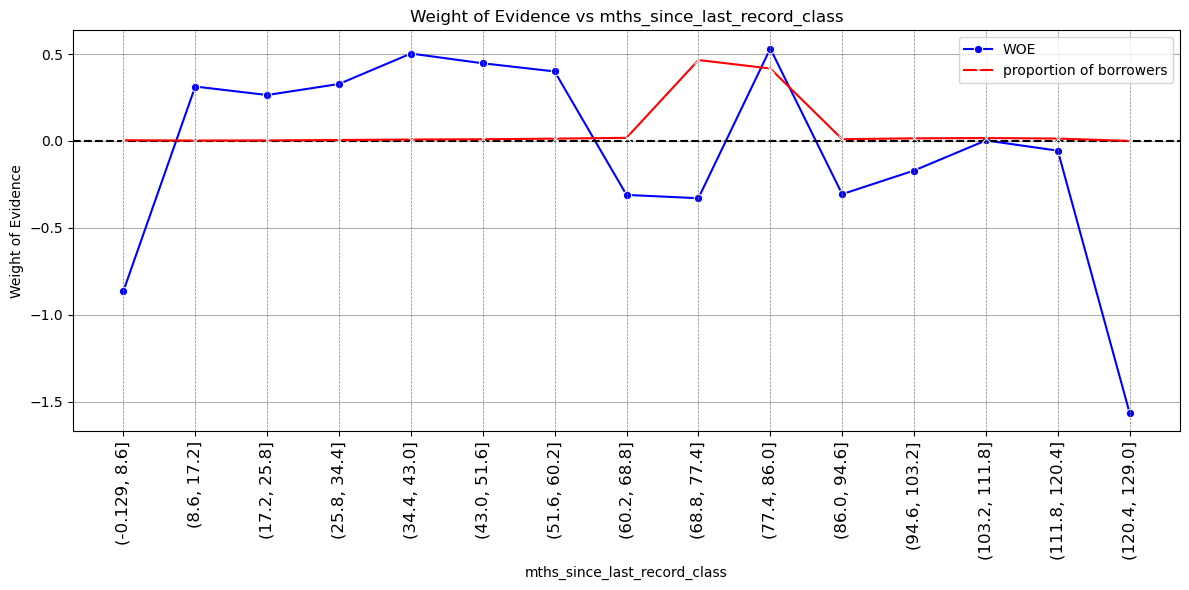

In [290]:
# Finding WoE
df_p = give_woe_iv_cont('mths_since_last_record_class', loan_data)
plot_woe_cont(df_p, 'mths_since_last_record_class')

In [861]:
# Lets do course classing as follows:
# First class : mths_since_last_record < 43
# Second class : mths_since_last_record >= 43 and < 69
# Third class : mths_since_last_record >= 69 and < 87
# Fourth class : mths_since_last_record >= 87 

# So the classes would be
loan_data['mths_since_last_record :<43'] = np.where(loan_data['mths_since_last_record'] < 43, 1, 0) # Creating a new column
loan_data['mths_since_last_record :43-69'] = np.where((loan_data['mths_since_last_record'] >= 43) & (loan_data['mths_since_last_record'] < 69), 1, 0) # Creating a new column
loan_data['mths_since_last_record :69-87'] = np.where((loan_data['mths_since_last_record'] >= 69) & (loan_data['mths_since_last_record'] < 87), 1, 0) # Creating a new column
loan_data['mths_since_last_record :>=87'] = np.where(loan_data['mths_since_last_record'] >= 87, 1, 0) # Creating a new column


In [862]:
#drop months_since_last_record and months_since_last_record_class
loan_data.drop(['mths_since_last_record','mths_since_last_record_class'],axis =1 , inplace = True)

In [292]:
# Lets talk about 'revol_util'
loan_data['revol_util'].nunique()

1269

In [863]:
# Lets cut this into 50 bins
loan_data['revol_util_class'] = pd.cut(loan_data['revol_util'], bins=50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for revol_util_class: inf


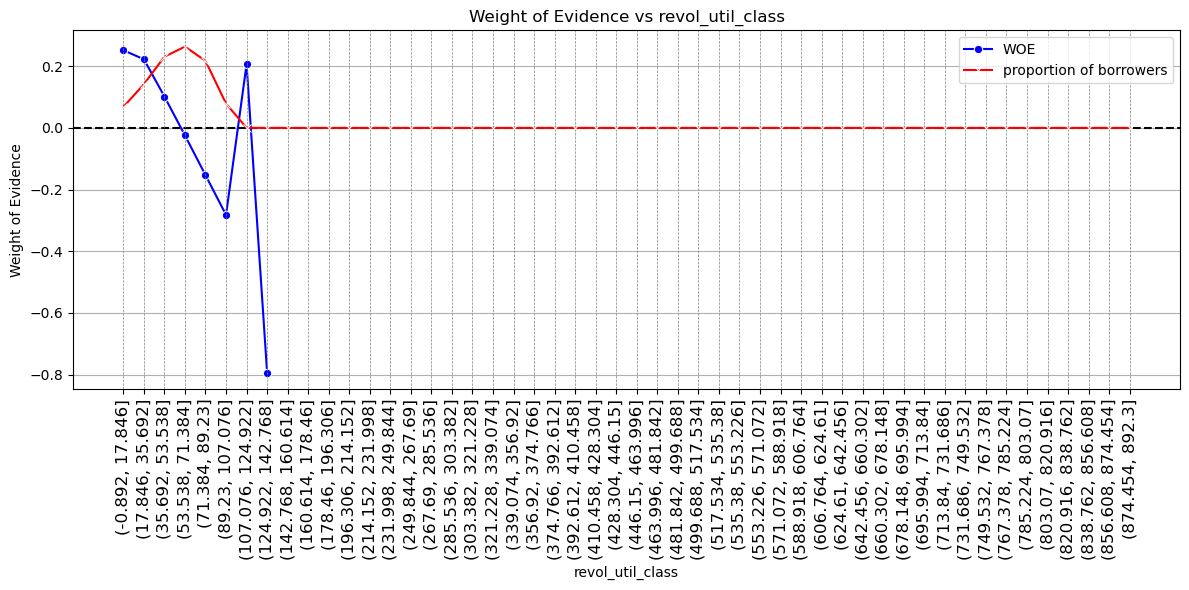

In [294]:
# Finding WoE
df_p = give_woe_iv_cont('revol_util_class', loan_data)
plot_woe_cont(df_p, 'revol_util_class')

In [864]:
# The course classing is as follows:
# First class : revol_util < 36
# Second class : revol_util >=36 and < 70
# Third class : revol_util >= 70 and < 124
# Fourth class : revol_util >= 124

# The classes shall be
loan_data['revol_util :<36'] = np.where(loan_data['revol_util'] < 36, 1, 0) # Creating a new column
loan_data['revol_util :36-70'] = np.where((loan_data['revol_util'] >= 36) & (loan_data['revol_util'] < 70), 1, 0) # Creating a new column
loan_data['revol_util :70-124'] = np.where((loan_data['revol_util'] >= 70) & (loan_data['revol_util'] < 124), 1, 0) # Creating a new column
loan_data['revol_util :>=124'] = np.where(loan_data['revol_util'] >= 124, 1, 0) # Creating a new column


In [865]:
# drop revol_util and revol_util_class
loan_data.drop(['revol_util','revol_util_class'],axis =1 , inplace = True)

In [298]:
# Lets get into column 'out_prncp'
loan_data['out_prncp'].nunique()

135665

In [866]:
# Cut it into 50 bins
loan_data['out_prncp_class'] = pd.cut(loan_data['out_prncp'], bins=50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for out_prncp_class: 2.2072119194367827


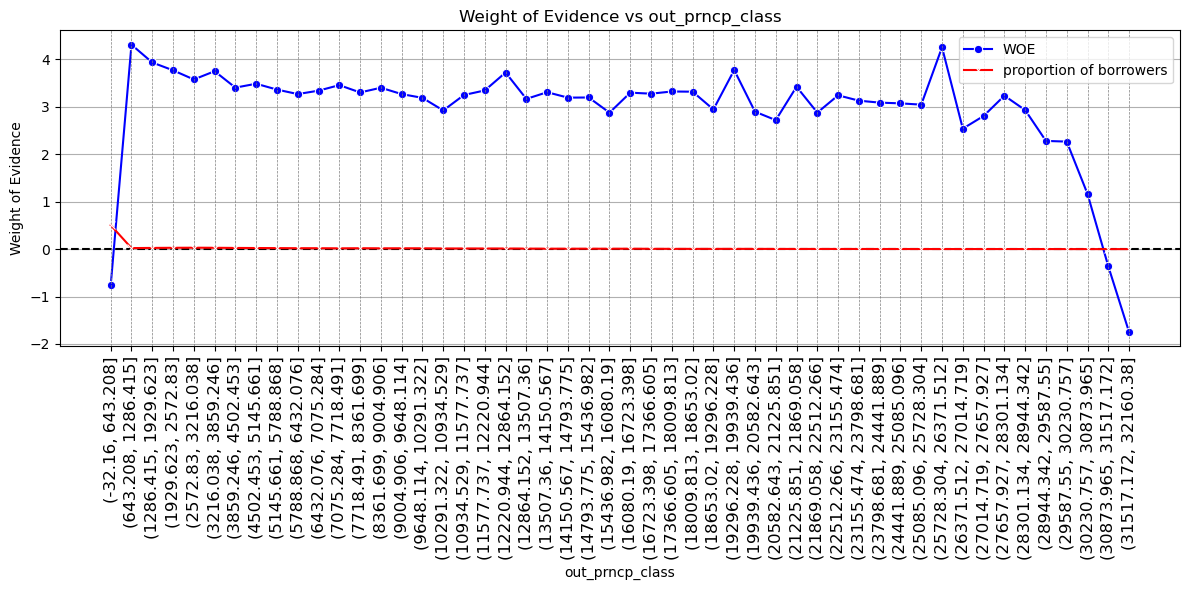

In [300]:
# Find WoE
df_p = give_woe_iv_cont('out_prncp_class', loan_data)
plot_woe_cont(df_p, 'out_prncp_class')

In [ ]:
# Lets find the 75th percentile of out_prncp
percentile_75 = np.percentile(loan_data['out_prncp'], 75)
print("75th percentile of out_prncp:", percentile_75)

75th percentile of out_prncp: 7341.65


In [316]:
loan_data['out_prncp'].describe()

count    466285.000000
mean       4410.062342
std        6355.078769
min           0.000000
25%           0.000000
50%         441.470000
75%        7341.650000
max       32160.380000
Name: out_prncp, dtype: float64

In [318]:
# Lets have a temporary data frame of the rows where out_prncp is less than 75th percentile
loan_data_temp = loan_data[loan_data['out_prncp'] < percentile_75]

In [319]:
# Cut the data into 50 bins of the column
loan_data_temp['out_prncp_class'] = pd.cut(loan_data_temp['out_prncp'], bins=50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/4097995901.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_temp['out_prncp_class'] = pd.cut(loan_data_temp['out_prncp'], bins=50)


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_58010/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for out_prncp_class: inf


/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


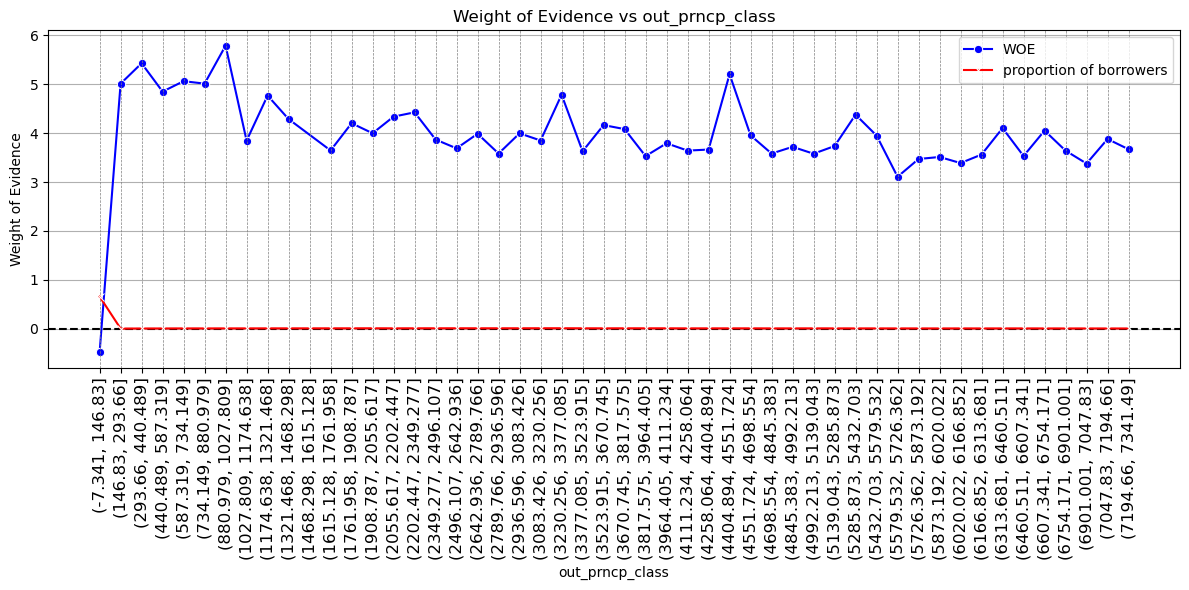

In [320]:
# Find WOE based on loan_data_temp
df_p = give_woe_iv_cont('out_prncp_class', loan_data_temp)
plot_woe_cont(df_p, 'out_prncp_class')

In [867]:
# The plots of WOE are not convincing enough. Lets drop this columns
loan_data.drop(['out_prncp_class', 'out_prncp'], axis=1, inplace=True)


In [868]:
# Lets save the data till now in a csv as system keeps hanging
loan_data.to_csv('loan_data_reformed.csv', index=False)

In [114]:
# Lets look into the next column 'out_prncp_inv'
loan_data['out_prncp_inv'].nunique()

141189

In [869]:
# Lets create 50 bins first
loan_data['out_prncp_inv_class'] = pd.cut(loan_data['out_prncp_inv'], bins=50)


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for out_prncp_inv_class: 2.206887490824586


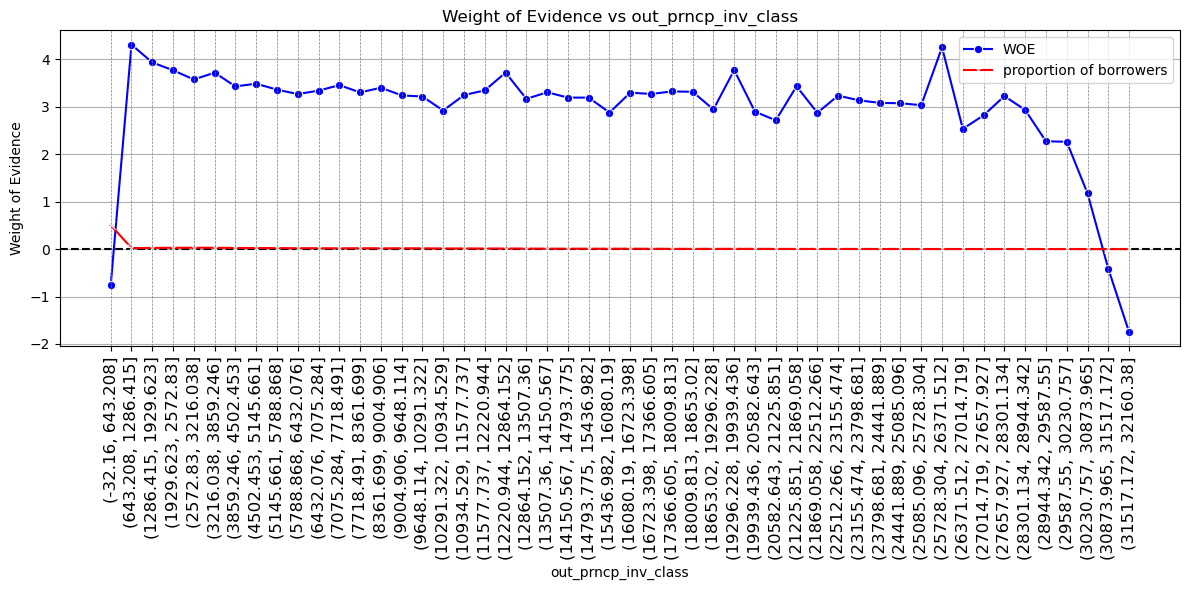

In [116]:
# Lets find the WOE
df_p = give_woe_iv_cont('out_prncp_inv_class', loan_data)
plot_woe_cont(df_p, 'out_prncp_inv_class')

In [870]:
# Seems out_prncp_inv shares the same fate as of out_prncp, we can drop this column
loan_data.drop(['out_prncp_inv_class', 'out_prncp_inv'], axis=1, inplace=True)

In [118]:
# Lets look into the next column 'total_pymnt'
loan_data['total_pymnt'].nunique()

351609

In [871]:
# create 50 bins
loan_data['total_pymnt_class'] = pd.cut(loan_data['total_pymnt'], bins=50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for total_pymnt_class: inf


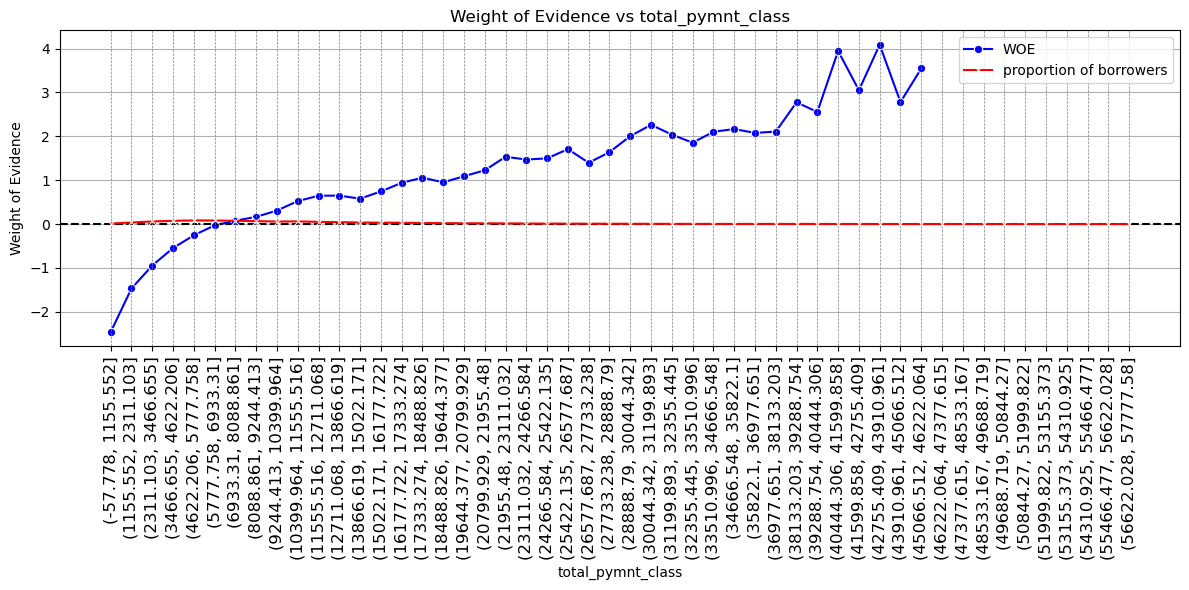

In [120]:
# Find woe
df_p = give_woe_iv_cont('total_pymnt_class', loan_data)
plot_woe_cont(df_p, 'total_pymnt_class')

In [872]:
# total_pymnt is not a good predictor, we can drop this column
loan_data.drop(['total_pymnt_class', 'total_pymnt'], axis=1, inplace=True)

In [873]:
loan_data.drop(['total_pymnt_inv'], axis=1, inplace=True) # Dropping the total_pymnt_inv column as it would be highly correlated with total_pymnt

In [123]:
# Lets drop the following variables as they are not useful
loan_data.drop(['total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt','collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code'], axis=1, inplace=True)


In [875]:
# Lets find the numeric columns again
numeric_columns = loan_data.select_dtypes(include=['int64', 'float64']).columns # Selecting the numeric columns
numeric_columns_list = numeric_columns.tolist() # Converting to list for easier manipulation
numeric_columns_list

['id',
 'member_id',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'tot_coll_amt',
 'tot_cur_bal',
 'months_since_last_pymnt_d',
 'months_since_last_credit_pull_d',
 'months_since_next_pymnt_d',
 'good_bad',
 'months_since_issue_d_class :<38',
 'months_since_issue_d_class :38-40',
 'months_since_issue_d_class :40-42',
 'months_since_issue_d_class :42-44',
 'months_since_issue_d_class :44-45',
 'months_since_issue_d_class :45-49',
 'months_since_issue_d_class :49-50',
 'months_since_issue_d_class :50-51',
 'months_since_issue_d_class :51-52',
 'months_since_issue_d_class :52-54',
 'months_since_issue_d_class :54-63',
 'months_since_issue_d_class :63-76',
 'months_since_issue_d_class :76-96',
 'months_since_issue_d_class :>=96',
 'int_rate_class :5-9.6',
 'int_rate_class :9.6-12',
 'int_rate_class :12-14.5',
 'int_rate_class :14.5-1

In [125]:
# Lets work on 'tot_coll_amt'
loan_data['tot_coll_amt'].nunique()

6321

In [876]:
# Cut it into 50 bins
loan_data['tot_coll_amt_class'] = pd.cut(loan_data['tot_coll_amt'], bins=50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for tot_coll_amt_class: inf


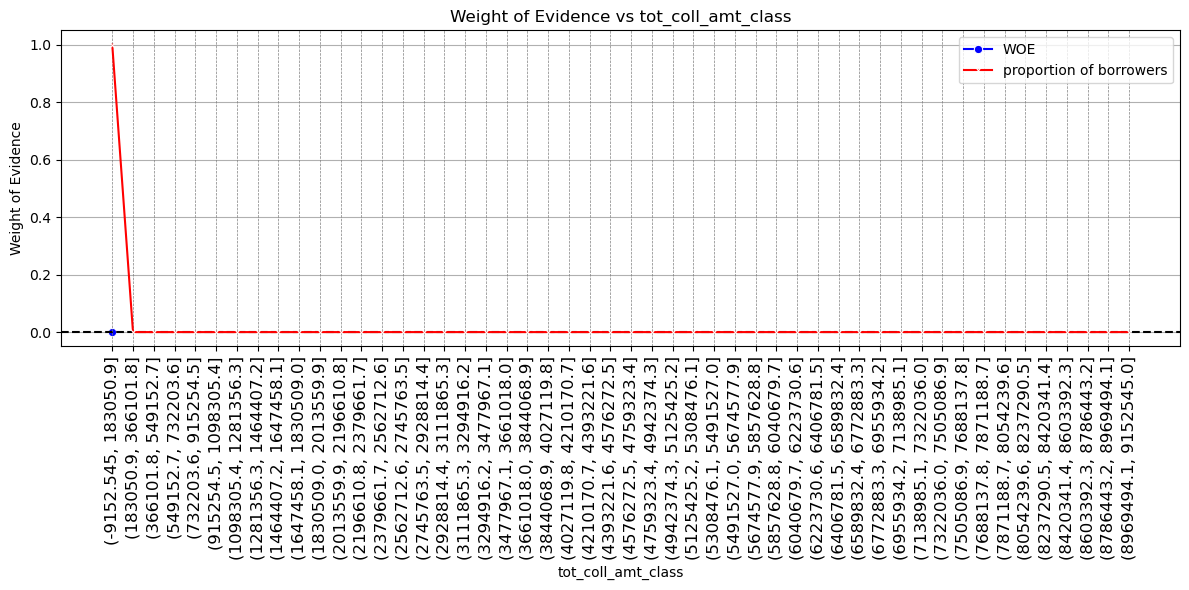

In [127]:
# find woe
df_p = give_woe_iv_cont('tot_coll_amt_class', loan_data)
plot_woe_cont(df_p, 'tot_coll_amt_class')

In [877]:
# drop tot_coll_amt and tot_coll_amt_class
loan_data.drop(['tot_coll_amt', 'tot_coll_amt_class'], axis=1, inplace=True)

In [129]:
# Lets work on 'tot_cur_bal'
loan_data['tot_cur_bal'].nunique()

220692

In [878]:
# binning
loan_data['tot_cur_bal_class'] = pd.cut(loan_data['tot_cur_bal'], bins=50)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for tot_cur_bal_class: inf


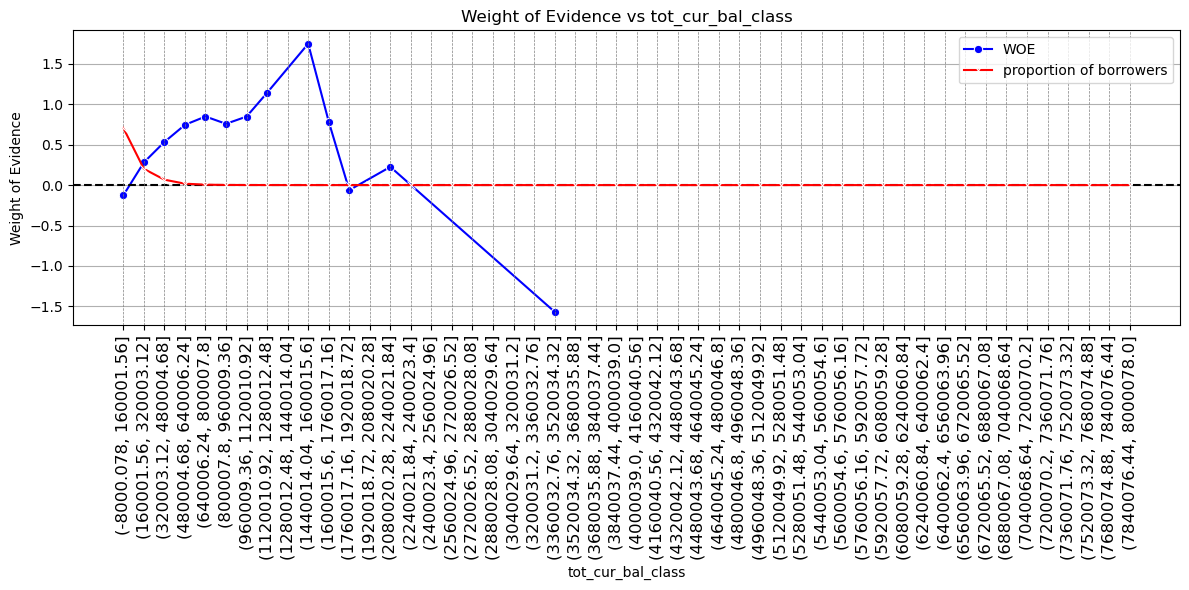

In [131]:
# finding woe
df_p = give_woe_iv_cont('tot_cur_bal_class', loan_data)
plot_woe_cont(df_p, 'tot_cur_bal_class')

In [132]:
# Consider a temporary data frame of the rows where tot_cur_bal is less than 95th percentile
percentile_95 = np.percentile(loan_data['tot_cur_bal'], 95)
loan_data_temp = loan_data[loan_data['tot_cur_bal'] < percentile_95]

In [133]:
# binning of 'total_cur_bal' in 50 bins
loan_data_temp['tot_cur_bal_class'] = pd.cut(loan_data_temp['tot_cur_bal'], bins=50)


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/4077386607.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_temp['tot_cur_bal_class'] = pd.cut(loan_data_temp['tot_cur_bal'], bins=50)


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_good = loan_data.groupby(col)['good_bad'].sum()
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_1328/1003548446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total = loan_data.groupby(col)['good_bad'].size()


Information Value for tot_cur_bal_class: 0.09840476677015803


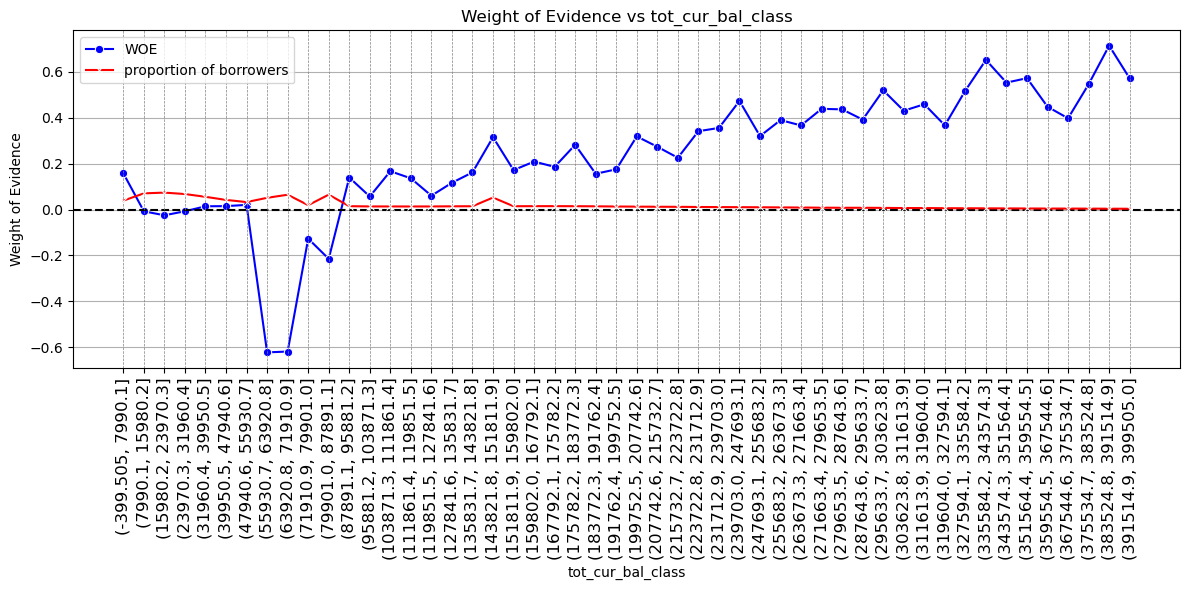

In [134]:
# finding WOE
df_p = give_woe_iv_cont('tot_cur_bal_class', loan_data_temp)
plot_woe_cont(df_p, 'tot_cur_bal_class')

In [879]:
# We do the following course classing:
# Class 1 : tot_cur_bal < 16000
# Class 2 : tot_cur_bal >= 16000 & < 55000
# Class 3 : tot_cur_bal >= 55000 & < 63000
# Class 4 : tot_cur_bal >= 63000 & < 72000
# Class 5 : tot_cur_bal >= 72000 & < 96000
# Class 6 : tot_cur_bal >= 96000 & < 150000
# Class 7 : tot_cur_bal >= 150000

# So the classes would be
loan_data['tot_cur_bal :<16000'] = np.where(loan_data['tot_cur_bal'] < 16000, 1, 0) # Creating a new column
loan_data['tot_cur_bal :16000-55000'] = np.where((loan_data['tot_cur_bal'] >= 16000) & (loan_data['tot_cur_bal'] < 55000), 1, 0) # Creating a new column
loan_data['tot_cur_bal :55000-63000'] = np.where((loan_data['tot_cur_bal'] >= 55000) & (loan_data['tot_cur_bal'] < 63000), 1, 0) # Creating a new column
loan_data['tot_cur_bal :63000-72000'] = np.where((loan_data['tot_cur_bal'] >= 63000) & (loan_data['tot_cur_bal'] < 72000), 1, 0) # Creating a new column
loan_data['tot_cur_bal :72000-96000'] = np.where((loan_data['tot_cur_bal'] >= 72000) & (loan_data['tot_cur_bal'] < 96000), 1, 0) # Creating a new column
loan_data['tot_cur_bal :96000-150000'] = np.where((loan_data['tot_cur_bal'] >= 96000) & (loan_data['tot_cur_bal'] < 150000), 1, 0) # Creating a new column
loan_data['tot_cur_bal :>=150000'] = np.where(loan_data['tot_cur_bal'] >= 150000, 1, 0) # Creating a new column

In [880]:
# Lets drop the tot_cur_bal and tot_cur_bal_class columns
loan_data.drop(['tot_cur_bal', 'tot_cur_bal_class'], axis=1, inplace=True) # Dropping the tot_cur_bal and tot_cur_bal_class columns

In [137]:
# Lets look into 'months_since_last_pymnt_d'
loan_data['months_since_last_pymnt_d'].nunique()


98

Information Value for months_since_last_pymnt_d: 3.9249278810287946


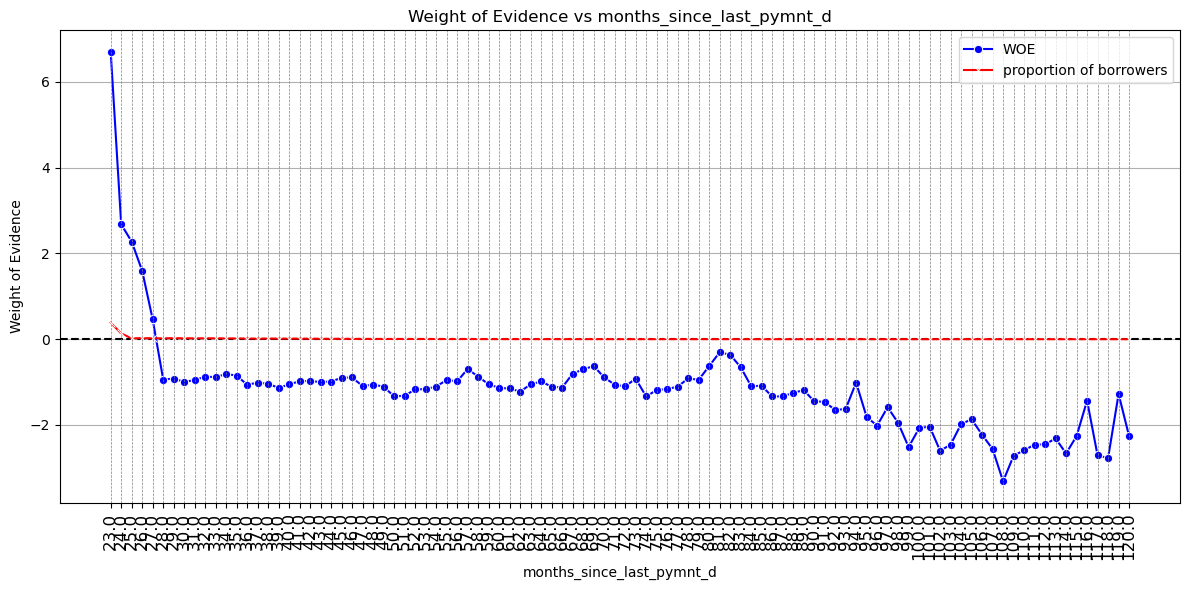

In [138]:
# Finding woe
df_p = give_woe_iv_cont('months_since_last_pymnt_d', loan_data)
plot_woe_cont(df_p, 'months_since_last_pymnt_d')

In [881]:
# The graph is not convincing, we can drop this column
loan_data.drop(['months_since_last_pymnt_d'], axis=1, inplace=True) # Dropping the months_since_last_p

In [882]:
# Lets drop 'months_since_last_credit_pull_d','months_since_next_pymnt_d'
loan_data.drop(['months_since_last_credit_pull_d','months_since_next_pymnt_d'], axis=1, inplace=True)

In [883]:
# Lets find the numeric columns again
numeric_columns = loan_data.select_dtypes(include=['int64', 'float64']).columns # Selecting the numeric columns
numeric_columns_list = numeric_columns.tolist() # Converting to list for easier manipulation
numeric_columns_list

['id',
 'member_id',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'good_bad',
 'months_since_issue_d_class :<38',
 'months_since_issue_d_class :38-40',
 'months_since_issue_d_class :40-42',
 'months_since_issue_d_class :42-44',
 'months_since_issue_d_class :44-45',
 'months_since_issue_d_class :45-49',
 'months_since_issue_d_class :49-50',
 'months_since_issue_d_class :50-51',
 'months_since_issue_d_class :51-52',
 'months_since_issue_d_class :52-54',
 'months_since_issue_d_class :54-63',
 'months_since_issue_d_class :63-76',
 'months_since_issue_d_class :76-96',
 'months_since_issue_d_class :>=96',
 'int_rate_class :5-9.6',
 'int_rate_class :9.6-12',
 'int_rate_class :12-14.5',
 'int_rate_class :14.5-16',
 'int_rate_class :16-20',
 'int_rate_class :>=20',
 'months_since_earliest_cr_class :<171',
 'months_since_earliest_cr_class 

In [884]:
# Lets save the data till now in a csv as system keeps hanging
loan_data.to_csv('loan_data_reformed.csv', index=False)

In [143]:
#

In [283]:
# Exploring the columns of loan_data now
loan_data.columns

Index(['id', 'member_id', 'grade', 'sub_grade', 'home_ownership',
       'verification_status', 'purpose', 'addr_state',
       'mths_since_last_delinq', 'mths_since_last_record',
       ...
       'revol_bal_class :1639-5734', 'revol_bal_class :5734-12286',
       'revol_bal_class :12286-18019', 'revol_bal_class :18019-22115',
       'revol_bal_class :22115-29486', 'revol_bal_class :29486-40952',
       'revol_bal_class :>=40952', 'total_rev_hi_lim_class :<200000',
       'total_rev_hi_lim_class :200000-600000',
       'total_rev_hi_lim_class :>=600000'],
      dtype='object', length=107)

# Creating Dummies out of The Categorical Variables

In [885]:
# first drop the subgrade column
loan_data.drop(['sub_grade'], axis=1, inplace=True) # Dropping the sub_grade column

In [886]:
# Finding the non numeric columns again
non_numeric_columns = loan_data.select_dtypes(include=['object']).columns # Selecting the non numeric columns   
non_numeric_columns_list = non_numeric_columns.tolist() # Converting to list for easier manipulation
non_numeric_columns_list # Displaying the non numeric columns as a list

['grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'initial_list_status',
 'application_type',
 'addr_state_c']

In [887]:
# drop addr_state
loan_data.drop(['addr_state'], axis=1, inplace=True) # Dropping the addr_state column

In [888]:
loan_data.drop(['application_type'], axis=1, inplace=True) # Dropping as decided earlier

In [889]:
# Finding the non numeric columns again
non_numeric_columns = loan_data.select_dtypes(include=['object']).columns # Selecting the non numeric columns   
non_numeric_columns_list = non_numeric_columns.tolist() # Converting to list for easier manipulation
non_numeric_columns_list # Displaying the non numeric columns as a list

['grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'initial_list_status',
 'addr_state_c']

In [891]:
# write the data to a csv
loan_data.to_csv('loan_data_reformed.csv', index=False)

In [147]:
# Where is the dummy_dict?
dummy_dict

{'grade': ['G', 'F', 'E', 'D', 'C', 'B', 'A'],
 'home_ownership': ['OTHER_RENT_NONE_ANY', 'OWN', 'MORTGAGE'],
 'addr_state_c': ['NE_IA_NV',
  'FL_AL_MO_NM',
  'HI',
  'CA',
  'NJ_LA',
  'NY',
  'NC_MD_KY_UT_MI',
  'OK_VA_AZ_AR_DE',
  'PA_MN_OH',
  'MA_WA_RI_TN_IN_GA_OR_WI_SD',
  'TX',
  'ID_CT_IL_KS_CO_SC',
  'VT_AK_MT_NH_WY_MS_WV_DC_ME'],
 'verification_status': ['Verified', 'Source Verified', 'Not Verified'],
 'purpose': ['educational',
  'small_business',
  'renewable_energy',
  'moving',
  'house',
  'other',
  'medical',
  'wedding',
  'vacation',
  'debt_consolidation',
  'major_purchase',
  'home_improvement',
  'car',
  'credit_card'],
 'initial_list_status': ['f', 'w']}

In [892]:
# As we can see how to convert the grade column to dummy variables, we do this for 
# all the non numeric columns 
# We define a function to do this ardous task!
def create_dummies(column, loan_data):
    dummies = pd.get_dummies(loan_data[column], prefix=column, prefix_sep=':', drop_first=True, dtype=int) # Creating dummy variables
    loan_data.drop(column, axis=1, inplace=True) # Dropping the original column
    loan_data = pd.concat([loan_data, dummies], axis=1) # Concatenating the dummy variables to the DataFrame
    loan_data.reset_index(drop=True, inplace=True)
    return loan_data # Returning the updated DataFrame

In [893]:
dummies_list = [x for x in non_numeric_columns_list] # Creating a list 
# of non numeric columns except loan_status
for column in dummies_list:
    loan_data = create_dummies(column, loan_data) # Creating dummy variables for each non numeric column

In [155]:
# Lets look at all columns of loan_data
for column in loan_data.columns:
    print(column)

id
member_id
good_bad
term:60
months_since_issue_d_class :<38
months_since_issue_d_class :38-40
months_since_issue_d_class :40-42
months_since_issue_d_class :42-44
months_since_issue_d_class :44-45
months_since_issue_d_class :45-49
months_since_issue_d_class :49-50
months_since_issue_d_class :50-51
months_since_issue_d_class :51-52
months_since_issue_d_class :52-54
months_since_issue_d_class :54-63
months_since_issue_d_class :63-76
months_since_issue_d_class :76-96
months_since_issue_d_class :>=96
int_rate_class :5-9.6
int_rate_class :9.6-12
int_rate_class :12-14.5
int_rate_class :14.5-16
int_rate_class :16-20
int_rate_class :>=20
months_since_earliest_cr_class :<171
months_since_earliest_cr_class :171-253
months_since_earliest_cr_class :253-432
months_since_earliest_cr_class :432-562
months_since_earliest_cr_class :>=562
delinq_2yrs :<=3
delinq_2yrs :>3
inq_last_6mths :0
inq_last_6mths :1
inq_last_6mths :2-4
inq_last_6mths :>=5
total_acc :<=5
total_acc :6-18
total_acc :19-52
total_acc

In [894]:
reference_category_numerical = ['term:60',
                                'months_since_issue_d_class :<38',
                                'int_rate_class :5-9.6',
                                'months_since_earliest_cr_class :<171',
                                'delinq_2yrs :<=3',
                                'inq_last_6mths :0',
                                'total_acc :<=5',
                                'annual_inc_class :<10000',
                                'dti_class :<=1.6',
                                'emp_length :0',
                                'revol_bal_class :<819',
                                'total_rev_hi_lim_class :<200000',
                                'mths_since_last_record :<43',
                                'revol_util :<36',
                                'tot_cur_bal :<16000'
]
                               
                                
                                
                                
                                
                                               
                         # Reference category for numerical columns





In [895]:
reference_category = reference_category_numerical + ['grade:A','home_ownership:OTHER_RENT_NONE_ANY','addr_state_c:NE_IA_NV',
                                                          'verification_status:Not Verified','purpose:car', 'initial_list_status:f',
                                                          'addr_state_c:CA']
                                                          # Reference category for all columns

In [983]:
reference_category_pd = reference_category

In [896]:
# We will drop the columns that are in the reference category
loan_data.drop(reference_category_numerical, axis=1, inplace=True)

In [897]:
loan_data.head()

,id,member_id,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,...,addr_state_c:ID_CT_IL_KS_CO_SC,addr_state_c:MA_WA_RI_TN_IN_GA_OR_WI_SD,addr_state_c:NC_MD_KY_UT_MI,addr_state_c:NE_IA_NV,addr_state_c:NJ_LA,addr_state_c:NY,addr_state_c:OK_VA_AZ_AR_DE,addr_state_c:PA_MN_OH,addr_state_c:TX,addr_state_c:VT_AK_MT_NH_WY_MS_WV_DC_ME
0,1077501,1296599,5000.00,861.07,0.00,0.00,0.00,171.62,0.0,42.0,...,0,0,0,0,0,0,1,0,0,0
1,1077430,1314167,456.46,435.17,0.00,117.08,1.11,119.66,0.0,43.0,...,0,1,0,0,0,0,0,0,0,0
2,1077175,1313524,2400.00,603.65,0.00,0.00,0.00,649.91,0.0,43.0,...,1,0,0,0,0,0,0,0,0,0
3,1076863,1277178,10000.00,2209.33,16.97,0.00,0.00,357.48,0.0,43.0,...,0,0,0,0,0,0,0,0,0,0
4,1075358,1311748,2233.10,1009.07,0.00,0.00,0.00,67.79,0.0,42.0,...,0,1,0,0,0,0,0,0,0,0


In [161]:
loan_data.to_csv('loan_data_2.csv', index=False) # Saving the preprocessed data to a csv file

In [898]:
loan_data.to_csv('loan_data_pd.csv',index=False)

# Data Preparation : Splitting the Data 
 (or spitting the facts? :p)

In [899]:
import pandas as pd
import numpy as np
loan_data = pd.read_csv('loan_data_2.csv') # Reading the DataFrame from a csv file

In [918]:
# Splitting the data into train and test
from sklearn.model_selection import train_test_split
X = loan_data.drop(['good_bad','id','member_id'], axis=1) # Creating the feature matrix
y = loan_data['good_bad'] # Creating the target vector
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Splitting the data into train and

In [919]:
X_train.head()

,months_since_issue_d_class :38-40,months_since_issue_d_class :40-42,months_since_issue_d_class :42-44,months_since_issue_d_class :44-45,months_since_issue_d_class :45-49,months_since_issue_d_class :49-50,months_since_issue_d_class :50-51,months_since_issue_d_class :51-52,months_since_issue_d_class :52-54,months_since_issue_d_class :54-63,...,addr_state_c:ID_CT_IL_KS_CO_SC,addr_state_c:MA_WA_RI_TN_IN_GA_OR_WI_SD,addr_state_c:NC_MD_KY_UT_MI,addr_state_c:NE_IA_NV,addr_state_c:NJ_LA,addr_state_c:NY,addr_state_c:OK_VA_AZ_AR_DE,addr_state_c:PA_MN_OH,addr_state_c:TX,addr_state_c:VT_AK_MT_NH_WY_MS_WV_DC_ME
427211,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
206088,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
136020,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
412305,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
36159,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [171]:
# Let me write this to a csv file for future reference  
X_train.to_csv('loan_data_X_train.csv', index=False) # Writing the train feature matrix to a csv file
X_test.to_csv('loan_data_X_test.csv', index=False) # Writing the test feature matrix to a csv file
y_train.to_csv('loan_data_y_train.csv', index=False) # Writing the train target vector to a csv file
y_test.to_csv('loan_data_y_test.csv', index=False) # Writing the test target vector to a csv file
# Additional logging to confirm successful file writes
print("CSV files for train and test datasets have been written successfully.")

CSV files for train and test datasets have been written successfully.


# PD Model Estimation

**Logistic Regression**

In [921]:
# Lets check for multicoliniearity in X_train
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
#X_train = sm.add_constant(X_train) # Adding a constant
vif = pd.DataFrame() # Creating a DataFrame
vif["variables"] = X_train.columns # Add the variable names
vif["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])] # Add the VIF values
vif = vif[vif['VIF']>10] # Selecting the variables with VIF greater than 10
vif.sort_values(by='VIF', ascending=False) # Sorting the values

,variables,VIF
33,annual_inc_class :56000-76000,80.135197
27,total_acc :19-52,76.108825
85,purpose:debt_consolidation,51.055992
34,annual_inc_class :76000-96000,49.122853
32,annual_inc_class :46000-56000,48.189386
63,mths_since_last_record :69-87,43.108640
31,annual_inc_class :37000-46000,42.108083
30,annual_inc_class :22000-37000,38.774270
26,total_acc :6-18,34.580748
35,annual_inc_class :96000-114000,26.442454


# Multicollinearity in the X data, as shown by VIF > 10

Note : Use Ridge Regression to handle multicollinearity. Ridge Regression adds a regularization term to the regression, which helps mitigate the effects of multicollinearity.

In [904]:
pd.options.display.max_rows = None

# Never Scale X for Credit Risk Modelling

## Build a Logistic Regression Model with P-Values

** Applicable when there is no High Multicolinearity

from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_p_values:
    
    def __init__(self,*args,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs,max_iter=1000)

    def fit(self,X,y):
        self.model.fit(X,y)
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X)
        Cramer_Rao = np.linalg.inv(F_ij)
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores]
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [66]:
from sklearn.linear_model import LogisticRegression
import scipy.stats as stat
import numpy as np

class RidgeLogisticRegression_with_p_values:
    
    def __init__(self, alpha=1.0, *args, **kwargs):
        self.alpha = alpha
        self.model = LogisticRegression(penalty='l2', C=1/self.alpha, solver='lbfgs', max_iter=1000, *args, **kwargs)
    
    def fit(self, X, y):
        self.model.fit(X, y)
        
        # Number of observations and features
        n = X.shape[0]
        p = X.shape[1]
        
        # Compute the predicted probabilities
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom, (X.shape[1], 1)).T
        F_ij = np.dot((X / denom).T, X)
        
        # Add regularization term to avoid singular matrix
        F_ij += self.alpha * np.eye(F_ij.shape[0])
        
        # Compute the inverse of the Fisher Information Matrix
        Cramer_Rao = np.linalg.inv(F_ij)
        
        # Compute the standard errors of the coefficients
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        
        # Compute the z-scores
        z_scores = self.model.coef_[0] / sigma_estimates
        
        # Compute the p-values
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores]
        
        # Store the coefficients, intercept, and p-values
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values
        return self



In [923]:
X = X_train
y = y_train

In [924]:
# Example usage
reg_pd = RidgeLogisticRegression_with_p_values(alpha=1.0)
reg_pd.fit(X, y)


In [925]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = X_train.columns.values)
summary_table['Coefficients'] = np.transpose(reg_pd.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg_pd.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,3.874465
1,months_since_issue_d_class :38-40,-0.311221
2,months_since_issue_d_class :40-42,-0.499822
3,months_since_issue_d_class :42-44,-0.676330
4,months_since_issue_d_class :44-45,-0.768602
5,months_since_issue_d_class :45-49,-0.852095
6,months_since_issue_d_class :49-50,-1.014846
7,months_since_issue_d_class :50-51,-1.007860
8,months_since_issue_d_class :51-52,-1.057456
9,months_since_issue_d_class :52-54,-1.161235


In [926]:
p_values = reg_pd.p_values

In [927]:
p_values = np.append(np.nan, np.array(p_values))

In [928]:
summary_table['p_values'] = p_values

In [929]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,3.874465,NaN
1,months_since_issue_d_class :38-40,-0.311221,5.860841e-15
2,months_since_issue_d_class :40-42,-0.499822,5.427325e-38
3,months_since_issue_d_class :42-44,-0.676330,1.754543e-64
4,months_since_issue_d_class :44-45,-0.768602,6.553374e-66
5,months_since_issue_d_class :45-49,-0.852095,2.893503e-117
6,months_since_issue_d_class :49-50,-1.014846,5.743786e-105
7,months_since_issue_d_class :50-51,-1.007860,2.468379e-103
8,months_since_issue_d_class :51-52,-1.057456,1.050676e-112
9,months_since_issue_d_class :52-54,-1.161235,7.075711e-178


In [932]:
# Our Null Hypothesis is that the variable is not significant
# If p-value is less than 0.05, we reject the Null Hypothesis
# lets filter out the significant variables
summary_table = summary_table[summary_table['p_values'] < 0.05]
significant_features = summary_table['Feature name'].values

# We will fit the model with all the features whose atleast one category is found significant

In [931]:
summary_table

,Feature name,Coefficients,p_values
1,months_since_issue_d_class :38-40,-0.311221,5.860841e-15
2,months_since_issue_d_class :40-42,-0.499822,5.427325e-38
3,months_since_issue_d_class :42-44,-0.676330,1.754543e-64
4,months_since_issue_d_class :44-45,-0.768602,6.553374e-66
5,months_since_issue_d_class :45-49,-0.852095,2.893503e-117
6,months_since_issue_d_class :49-50,-1.014846,5.743786e-105
7,months_since_issue_d_class :50-51,-1.007860,2.468379e-103
8,months_since_issue_d_class :51-52,-1.057456,1.050676e-112
9,months_since_issue_d_class :52-54,-1.161235,7.075711e-178
10,months_since_issue_d_class :54-63,-1.356600,1.647566e-306


In [934]:
significant_features_pd = significant_features.tolist()
significant_features_pd

['months_since_issue_d_class :38-40',
 'months_since_issue_d_class :40-42',
 'months_since_issue_d_class :42-44',
 'months_since_issue_d_class :44-45',
 'months_since_issue_d_class :45-49',
 'months_since_issue_d_class :49-50',
 'months_since_issue_d_class :50-51',
 'months_since_issue_d_class :51-52',
 'months_since_issue_d_class :52-54',
 'months_since_issue_d_class :54-63',
 'months_since_issue_d_class :63-76',
 'months_since_issue_d_class :76-96',
 'months_since_issue_d_class :>=96',
 'int_rate_class :9.6-12',
 'int_rate_class :12-14.5',
 'int_rate_class :14.5-16',
 'int_rate_class :16-20',
 'int_rate_class :>=20',
 'months_since_earliest_cr_class :253-432',
 'months_since_earliest_cr_class :432-562',
 'months_since_earliest_cr_class :>=562',
 'inq_last_6mths :1',
 'inq_last_6mths :2-4',
 'inq_last_6mths :>=5',
 'annual_inc_class :37000-46000',
 'annual_inc_class :46000-56000',
 'annual_inc_class :56000-76000',
 'annual_inc_class :76000-96000',
 'annual_inc_class :96000-114000',
 '

In [935]:
X_train.columns.to_list()

['months_since_issue_d_class :38-40',
 'months_since_issue_d_class :40-42',
 'months_since_issue_d_class :42-44',
 'months_since_issue_d_class :44-45',
 'months_since_issue_d_class :45-49',
 'months_since_issue_d_class :49-50',
 'months_since_issue_d_class :50-51',
 'months_since_issue_d_class :51-52',
 'months_since_issue_d_class :52-54',
 'months_since_issue_d_class :54-63',
 'months_since_issue_d_class :63-76',
 'months_since_issue_d_class :76-96',
 'months_since_issue_d_class :>=96',
 'int_rate_class :9.6-12',
 'int_rate_class :12-14.5',
 'int_rate_class :14.5-16',
 'int_rate_class :16-20',
 'int_rate_class :>=20',
 'months_since_earliest_cr_class :171-253',
 'months_since_earliest_cr_class :253-432',
 'months_since_earliest_cr_class :432-562',
 'months_since_earliest_cr_class :>=562',
 'delinq_2yrs :>3',
 'inq_last_6mths :1',
 'inq_last_6mths :2-4',
 'inq_last_6mths :>=5',
 'total_acc :6-18',
 'total_acc :19-52',
 'total_acc :>=53',
 'annual_inc_class :10000-22000',
 'annual_inc_c

In [ ]:
#######################################################

In [936]:
final_inputs_pd = [
    
    'months_since_issue_d_class :38-40',
 'months_since_issue_d_class :40-42',
 'months_since_issue_d_class :42-44',
 'months_since_issue_d_class :44-45',
 'months_since_issue_d_class :45-49',
 'months_since_issue_d_class :49-50',
 'months_since_issue_d_class :50-51',
 'months_since_issue_d_class :51-52',
 'months_since_issue_d_class :52-54',
 'months_since_issue_d_class :54-63',
 'months_since_issue_d_class :63-76',
 'months_since_issue_d_class :76-96',
 'months_since_issue_d_class :>=96',
 'int_rate_class :9.6-12',
 'int_rate_class :12-14.5',
 'int_rate_class :14.5-16',
 'int_rate_class :16-20',
 'int_rate_class :>=20',
 'months_since_earliest_cr_class :171-253',
 'months_since_earliest_cr_class :253-432',
 'months_since_earliest_cr_class :432-562',
 'months_since_earliest_cr_class :>=562',
 
 'inq_last_6mths :1',
 'inq_last_6mths :2-4',
 'inq_last_6mths :>=5',

 'annual_inc_class :10000-22000',
 'annual_inc_class :22000-37000',
 'annual_inc_class :37000-46000',
 'annual_inc_class :46000-56000',
 'annual_inc_class :56000-76000',
 'annual_inc_class :76000-96000',
 'annual_inc_class :96000-114000',
 'annual_inc_class :114000-140000',
 'annual_inc_class :>=140000',
 'dti_class :1.6-4',
 'dti_class :4-11.2',
 'dti_class :11.2-15.2',
 'dti_class :15.2-17.6',
 'dti_class :17.6-19.2',
 'dti_class :19.2-20.8',
 'dti_class :20.8-23.2',
 'dti_class :23.2-27.2',
 'dti_class :27.2-35.2',
 'dti_class :>35.2',
 'emp_length :1-4',
 'emp_length :5-7',
 'emp_length :8-9',
 'emp_length :10+',
 'revol_bal_class :819-1639',
 'revol_bal_class :1639-5734',
 'revol_bal_class :5734-12286',
 'revol_bal_class :12286-18019',
 'revol_bal_class :18019-22115',
 'revol_bal_class :22115-29486',
 'revol_bal_class :29486-40952',
 'revol_bal_class :>=40952',
 
 'mths_since_last_record :43-69',
 'mths_since_last_record :69-87',
 'mths_since_last_record :>=87',
 
 'tot_cur_bal :16000-55000',
 'tot_cur_bal :55000-63000',
 'tot_cur_bal :63000-72000',
 'tot_cur_bal :72000-96000',
 'tot_cur_bal :96000-150000',
 'tot_cur_bal :>=150000',

 'grade:B',
 'grade:C',
 'grade:D',
 'grade:E',
 'grade:F',
 'grade:G',

 'home_ownership:OTHER_RENT_NONE_ANY',
 'home_ownership:OWN',

 'verification_status:Source Verified',
 'verification_status:Verified',

 'purpose:credit_card',
 'purpose:debt_consolidation',
 'purpose:educational',
 'purpose:home_improvement',
 'purpose:house',
 'purpose:major_purchase',
 'purpose:medical',
 'purpose:moving',
 'purpose:other',
 'purpose:renewable_energy',
 'purpose:small_business',
 'purpose:vacation',
 'purpose:wedding',

 'initial_list_status:w',

 'addr_state_c:FL_AL_MO_NM',
 'addr_state_c:HI',
 'addr_state_c:ID_CT_IL_KS_CO_SC',
 'addr_state_c:MA_WA_RI_TN_IN_GA_OR_WI_SD',
 'addr_state_c:NC_MD_KY_UT_MI',
 'addr_state_c:NE_IA_NV',
 'addr_state_c:NJ_LA',
 'addr_state_c:NY',
 'addr_state_c:OK_VA_AZ_AR_DE',
 'addr_state_c:PA_MN_OH',
 'addr_state_c:TX',
 'addr_state_c:VT_AK_MT_NH_WY_MS_WV_DC_ME'
     
]

In [937]:
# Splitting the data into train and test again
from sklearn.model_selection import train_test_split
X = loan_data[final_inputs_pd] # Creating the feature matrix
y = loan_data['good_bad'] # Creating the target vector
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Splitting the data into train and

In [938]:
X_train.shape

(373028, 101)

In [939]:
X = X_train
y = y_train
reg_pd = RidgeLogisticRegression_with_p_values(alpha=1.0)
reg_pd.fit(X, y)

In [940]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = final_inputs_pd)
summary_table['Coefficients'] = np.transpose(reg_pd.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg_pd.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,3.930919
1,months_since_issue_d_class :38-40,-0.317744
2,months_since_issue_d_class :40-42,-0.501614
3,months_since_issue_d_class :42-44,-0.686056
4,months_since_issue_d_class :44-45,-0.774377
5,months_since_issue_d_class :45-49,-0.838983
6,months_since_issue_d_class :49-50,-1.012319
7,months_since_issue_d_class :50-51,-1.010261
8,months_since_issue_d_class :51-52,-1.057292
9,months_since_issue_d_class :52-54,-1.157497


In [941]:
p_values = reg_pd.p_values
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values

summary_table

,Feature name,Coefficients,p_values
0,Intercept,3.930919,NaN
1,months_since_issue_d_class :38-40,-0.317744,1.692672e-15
2,months_since_issue_d_class :40-42,-0.501614,4.043588e-38
3,months_since_issue_d_class :42-44,-0.686056,3.456432e-66
4,months_since_issue_d_class :44-45,-0.774377,8.462931e-67
5,months_since_issue_d_class :45-49,-0.838983,3.722125e-113
6,months_since_issue_d_class :49-50,-1.012319,2.610583e-104
7,months_since_issue_d_class :50-51,-1.010261,7.204374e-104
8,months_since_issue_d_class :51-52,-1.057292,1.162001e-112
9,months_since_issue_d_class :52-54,-1.157497,2.390532e-176


# How to interpret the coefficients of a logistic regression model in context of PD Modelling and Credit Scoring?
The coefficients of a logistic regression model are the log odds of the dependent variable (in this case, the probability of default or credit risk) for a one unit change in the independent variable. 
In the context of PD modeling and credit scoring, the coefficients can be interpreted as the impact of each independent variable on the probability of default or credit risk.
The difference between two coefficients can be interpreted as the difference in log odds of the dependent variable for a one unit change in the independent variable.
For example, if the coefficient for a variable is 0.5, this means that a one unit increase in that variable is associated with a 0.5 increase in the log odds of default or credit risk.
To convert the log odds to probabilities, you can use the logistic function, which is the inverse of the logit function. 

The logistic function is defined as:
P(y=1) = 1 / (1 + exp(-z))

where z is the linear combination of the coefficients and independent variables.
By plugging in the values of the coefficients and independent variables into the logistic function, you can calculate the probability of default or credit risk for a given set of independent variables.
Overall, the coefficients of a logistic regression model provide valuable insights into the relationship between the independent variables and the probability of default or credit risk, and can be used to make informed decisions in the context of PD modeling and credit scoring.


# PD Model Validation

In [942]:
# Validating the logistic regression model
from sklearn import metrics
y_hat_test_pd = reg_pd.model.predict(X_test)
y_hat_test_proba_pd = reg_pd.model.predict_proba(X_test)


In [943]:
y_hat_test_proba_pd # Probabilities of being good or bad for each test sample

# (PD, 1-PD) PD being probability of default

array([[0.05578871, 0.94421129],
       [0.08870142, 0.91129858],
       [0.10976024, 0.89023976],
       ...,
       [0.01948611, 0.98051389],
       [0.03468491, 0.96531509],
       [0.04569425, 0.95430575]])

In [944]:
num_bad_predictions = len(y_hat_test_pd) - y_hat_test_pd.sum()
print("Number of bad predictions:", num_bad_predictions)

Number of bad predictions: 21


In [945]:
y_hat_test_proba_pd[:,0] # Probability of being a bad loan for each test sample

array([0.05578871, 0.08870142, 0.10976024, ..., 0.01948611, 0.03468491,
       0.04569425])

In [947]:
# Lets form a dataframe of actual and predicted values
df_actual_pred = pd.DataFrame(y_test)
df_actual_pred['Predicted Probability'] = np.transpose(y_hat_test_proba_pd[:, 1])
df_actual_pred.head(5)

,good_bad,Predicted Probability
362514,1,0.944211
288564,1,0.911299
213591,1,0.890240
263083,1,0.962866
165001,1,0.969949


In [948]:
threshold = 0.5
y_test_predict_pd = np.where(y_hat_test_proba_pd[:,1] > threshold, 1, 0) # Converting the probabilities to 0 and 1

In [949]:
df_actual_pred['Predicted'] = y_test_predict_pd
df_actual_pred.head(5)

,good_bad,Predicted Probability,Predicted
362514,1,0.944211,1
288564,1,0.911299,1
213591,1,0.890240,1
263083,1,0.962866,1
165001,1,0.969949,1


In [950]:
# Evaluating the model
confusion_matrix = metrics.confusion_matrix(y_test, y_test_predict_pd)
classification_report = metrics.classification_report(y_test, y_test_predict_pd)
print('Confusion matrix:')
print(confusion_matrix)
print('Classification Report:')
print(classification_report)


Confusion matrix:
[[   12  8778]
 [    9 84458]]
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.00      0.00      8790
           1       0.91      1.00      0.95     84467

    accuracy                           0.91     93257
   macro avg       0.74      0.50      0.48     93257
weighted avg       0.87      0.91      0.86     93257



# Boom! Accuracy of 91%
# But confusion matrix shows how alot of Bad borrowers have been flagged as good borrowers
# Bads classified as goods is more lethal than having a BOOM Accuracy

# Class 0 (Bad Borrowers): 
The model performs poorly in identifying bad borrowers, with very low recall (0.00) and F1-score (0.00). This means the model is not effective at flagging bad borrowers.

# Class 1 (Good Borrowers): 
The model performs well in identifying good borrowers, with high recall (1.00) and F1-score (0.95).
The high accuracy (91%) is misleading because it is primarily driven by the model's performance on the majority class (good borrowers). The model's inability to correctly identify bad borrowers (class 0) is a significant issue, as it could lead to high-risk lending decisions.

In [951]:
def show_crosstab(true_y, pred_y):
    df = pd.DataFrame({'Actual': true_y, 'Predicted': pred_y})
    crosstab_result = pd.crosstab(df['Actual'], df['Predicted'], margins=True)
    return crosstab_result

In [952]:
show_crosstab(y_test, y_test_predict_pd)

Predicted,0,1,All
Actual,,,
0,12,8778,8790
1,9,84458,84467
All,21,93236,93257


In [ ]:
tab = show_crosstab(y_test, y_test_predict_pd)
tab_pct = tab/tab.loc['All']
tab_pct = tab_pct * 100
tab_pct
# Out of the predicted Good borrowers, 9.4% are actually bad borrowers. Can we risk so much?

Predicted,0,1,All
Actual,,,
0,57.142857,9.414818,9.425566
1,42.857143,90.585182,90.574434
All,100.000000,100.000000,100.000000


# ROC Curve


In ML, the curve which shows the rate of the true positive predictions is called the ROC
curve. ROC stands for Receiver Operating Characteristic. The ROC curve is a graphical
representation of the contrast between true positive rates and the false positive rate at
various thresholds. It is often used as a proxy for the trade-off between the sensitivity of
the model (true positives) vs the fall-out or the probability it will trigger a false alarm
(false positives). The area under the ROC curve is a performance metric for binary
classification problems. The AUC (Area Under the Curve) score is a measure of the ability of a classifier to
distinguish between classes and is used as a summary of the ROC curve. The higher the AUC,
the better the performance of the model at distinguishing between the positive and negative
classes. The ROC curve is plotted with TPR against the FPR where TPR is on the y-axis and
FPR is on the x-axis. The ROC curve is a useful tool for a few reasons:
1. The curves of different models can be compared directly in general or for different
threshold values.
2. The area under the curve (AUC) can be used as a summary of the model skill.
3. The ROC curve can be used to select the best model.
4. The ROC curve is robust to class imbalance.
5. The ROC curve can be used to select the optimal model and discard the suboptimal
ones.
6. The ROC curve can be used to set the optimal threshold value.

In [962]:
# Constructing the ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_hat_test_proba_pd[:,1])


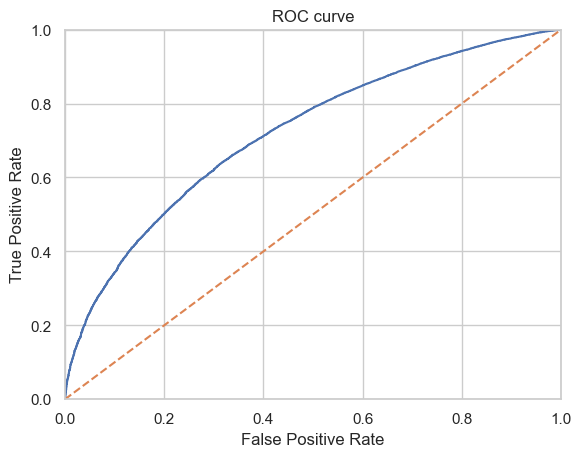

In [963]:
import matplotlib.pyplot as plt
plt.plot(fpr, tpr) # for plotting the ROC curve at various thresholds
plt.plot([0, 1], [0, 1], linestyle='--') # for plotting the diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.grid(True)
plt.show()

# The AUC is the area under the diagonal line which shows 50% chance of predicting correctly


In [965]:
AUROC = roc_auc_score(y_test, y_hat_test_proba_pd[:,1])
AUROC

0.7198354432713745

# Interpretation of AUC Curve:
- The AUC is the probability that a classifier will rank a randomly chosen positive instance higher than a randomly chosen negative one.
- An AUC of 0.5 is equivalent to random guessing.
- An AUC of 1.0 is equivalent to perfect classification.
The range varies as follows:

-------------------------------------------
|    AUC Value    |    Interpretation    |
-------------------------------------------
|  0.90 - 1.00    |    Excellent         |
|  0.80 - 0.90    |    Good              |
|  0.70 - 0.80    |    Fair              |
|  0.60 - 0.70    |    Poor              |
|  0.50 - 0.60    |    Bad               |
-------------------------------------------


# Our ROC Score is 71% which is FAIR

# Evaluation of Model Performance by GINI

Gini coefficient is a measure of statistical dispersion intended to represent the income or wealth distribution of a nation's residents, and is the most commonly used measure of inequality. 
A Gini coefficient of zero expresses perfect equality, where all values are the same (for example, where everyone has the same income). A Gini coefficient of one (or 100%) expresses maximal 
inequality among values (for example, where only one person has all the income or consumption, and all others have none).
In credit risk modeling, the Gini coefficient is often used to measure the discriminatory power of a model. It is calculated as the ratio of the area between the ROC curve and the diagonal line 
and the total area under the ROC curve. Here the x axis is the cumulative percentage of the total population(all borrowers), and the y axis is the cumulative percentage of the total bads. 
The Gini coefficient ranges from 0 to 1, where 0 indicates that the model has no discriminatory power, and 1 indicates that the model has perfect discriminatory power.


The Gini coefficient can be calculated using the following formula:


Gini = 2 * AUC - 1


where AUC is the area under the ROC curve. 


The Gini coefficient is a popular metric for evaluating the performance of credit risk models, as it provides a single number that summarizes the model's ability to differentiate between good and bad borrowers. In practice, a higher Gini coefficient indicates a better model.

# Evaluation of Model Performance by Kolmogorov-Smirnov Coefficient

The Kolmogorov-Smirnov test is a statistical method used to compare two distributions. 
It is a non-parametric test that compares the cumulative distribution functions of two datasets. 
The test statistic is the maximum difference between the two cumulative distribution functions. 
The null hypothesis of the test is that the two distributions are the same. If the test statistic is
 greater than the critical value, the null hypothesis is rejected, indicating that the two distributions 
 are different. The Kolmogorov-Smirnov test is commonly used in fields such as finance, biology, and engineering to 
 compare observed data with theoretical distributions or to compare two observed datasets.

 In Credit Risk Management, the Kolmogorov-Smirnov test is used to compare the distribution of credit scores
 for good and bad loans. By comparing the two distributions, banks can determine if there is a significant 
difference in credit risk between the two groups, thereby aiding in decision-making processes for loan approvals.
The cumulative distribution of good loans is compared with the cumulative distribution of bad loans, and the
Kolmogorov-Smirnov test is used to determine if the two distributions are significantly different. The KS test statistic 
is the maximum difference between the two cumulative distributions, and if it exceeds the critical value, the null hypothesis
is rejected, indicating that the two distributions are different. This information can be used to adjust credit scoring models
and improve risk assessment processes in credit risk management.

In [966]:
df_actual_pred_sorted = df_actual_pred.sort_values(by='Predicted Probability', ascending=True)
df_actual_pred_sorted.reset_index(inplace=True)
df_actual_pred_sorted.head(5)

,index,good_bad,Predicted Probability,Predicted
0,41676,0,0.394660,0
1,35909,0,0.398743,0
2,36242,1,0.402097,0
3,41663,1,0.404543,0
4,42344,1,0.406915,0


In [967]:
# Computing cumulative distribution functions of the good and bad loans
df_actual_pred_sorted['Cumulative N Population'] = df_actual_pred_sorted.index + 1
df_actual_pred_sorted['Cumulative N Good'] = df_actual_pred_sorted['good_bad'].cumsum()
df_actual_pred_sorted['Cumulative N Bad'] = df_actual_pred_sorted['Cumulative N Population'] - df_actual_pred_sorted['good_bad'].cumsum()
df_actual_pred_sorted['Cumulative Perc Population'] = df_actual_pred_sorted['Cumulative N Population'] / df_actual_pred_sorted.shape[0]
df_actual_pred_sorted['Cumulative Perc Good'] = df_actual_pred_sorted['Cumulative N Good'] / df_actual_pred_sorted['good_bad'].sum()
df_actual_pred_sorted['Cumulative Perc Bad'] = df_actual_pred_sorted['Cumulative N Bad'] / (df_actual_pred_sorted.shape[0] - df_actual_pred_sorted['good_bad'].sum())
df_actual_pred_sorted.head(5)


,index,good_bad,Predicted Probability,Predicted,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
0,41676,0,0.394660,0,1,0,1,0.000011,0.000000,0.000114
1,35909,0,0.398743,0,2,0,2,0.000021,0.000000,0.000228
2,36242,1,0.402097,0,3,1,2,0.000032,0.000012,0.000228
3,41663,1,0.404543,0,4,2,2,0.000043,0.000024,0.000228
4,42344,1,0.406915,0,5,3,2,0.000054,0.000036,0.000228


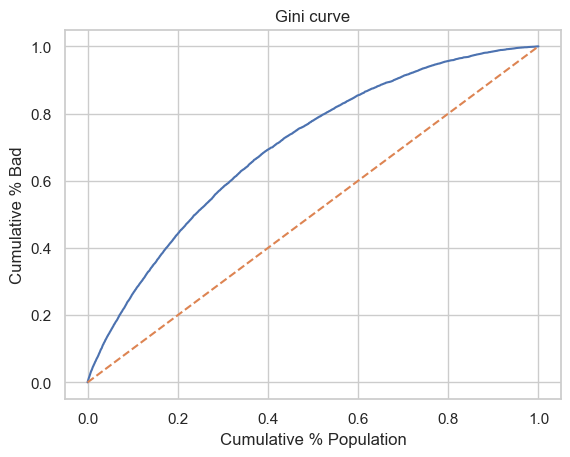

In [968]:
# Plotting the Gini curve
import matplotlib.pyplot as plt
plt.plot(df_actual_pred_sorted['Cumulative Perc Population'], df_actual_pred_sorted['Cumulative Perc Bad'])
plt.plot(df_actual_pred_sorted['Cumulative Perc Population'], df_actual_pred_sorted['Cumulative Perc Population'], linestyle = '--')
plt.xlabel('Cumulative % Population')
plt.ylabel('Cumulative % Bad')
plt.title('Gini curve')
plt.grid(True)
plt.show()

In [969]:
# Computing GINI from AUROC
Gini = AUROC*2 - 1
Gini

0.439670886542749

# GINI is 43%. Not Bad!

In [970]:
#Lets compute the KS statistic
df_actual_pred_sorted['KS'] = abs(df_actual_pred_sorted['Cumulative Perc Bad'] - df_actual_pred_sorted['Cumulative Perc Good'])
KS = max(df_actual_pred_sorted['KS'])
KS

0.32426959883478945

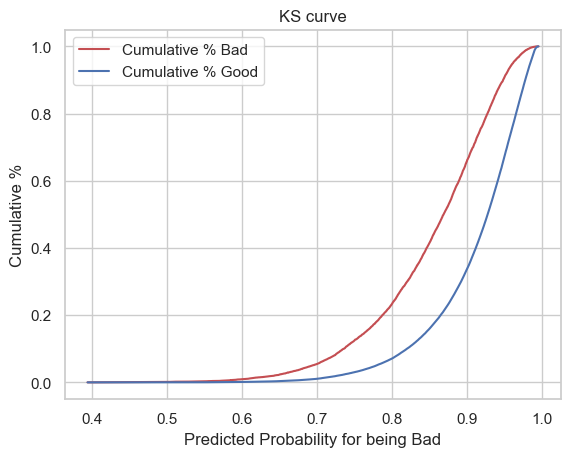

In [971]:
# Plotting the KS curve
import matplotlib.pyplot as plt
plt.plot(df_actual_pred_sorted['Predicted Probability'], df_actual_pred_sorted['Cumulative Perc Bad'], label = 'Cumulative % Bad',color='r')
plt.plot(df_actual_pred_sorted['Predicted Probability'], df_actual_pred_sorted['Cumulative Perc Good'], label = 'Cumulative % Good',color='b')
plt.xlabel('Predicted Probability for being Bad')
plt.ylabel('Cumulative %')
plt.title('KS curve')
plt.legend()
plt.grid(True)
plt.show()

# The KS Statistic is 0.32
 
# But how to check its significance?

The approximate critical value D(alpha) for a Two-Sample KS Test is given by:

D(alpha) = c(alpha) * sqrt((n1 + n2) / (n1 * n2))

where c(alpha) is the critical value for the two-sample KS test, and n1 and n2 are the sample sizes of the two samples.

The critical value c(alpha) for the two-sample KS test is given by:

c(alpha) = sqrt(-0.5 * log(alpha / 2))

where alpha is the significance level.


In [972]:
import math
# function to compute the c value
def c(alpha):
    return round(math.sqrt(0.5 * math.log(2 / alpha)),2)


In [973]:
# function to compute the D value
def d(alpha,n1,n2):

    if n1 <= 0 or n2 <= 0:
        raise ValueError("n1 and n2 must be greater than zero")
    d_value = round(c(alpha) * math.sqrt((n1 + n2) / (n1 * n2)), 2)
    
    return d_value

In [974]:
D = d(0.05, len(df_actual_pred_sorted), len(df_actual_pred_sorted))

print("D value is:", D)
print("KS statistic is:", KS)

D value is: 0.01
KS statistic is: 0.32426959883478945


In [975]:
# Comparing the KS statistic with the critical value D
if 'KS' in locals():
    print('The Distributions of Good and Bad loans are significantly different' if KS > D else 'The Distributions of Good and Bad loans are not significantly different')
else:
    print('KS statistic is not defined.')

The Distributions of Good and Bad loans are significantly different


In [976]:
#save the model
import pickle
pickle.dump(reg_pd, open('model.pkl','wb'))


# Applying the PD Model
* Calculating PD of Individual Accounts

In [977]:
# Consider the data of the first 20 loans in the X_Scaled_Test dataset
X_test_20 = X_test[:20]
X_test_20

,months_since_issue_d_class :38-40,months_since_issue_d_class :40-42,months_since_issue_d_class :42-44,months_since_issue_d_class :44-45,months_since_issue_d_class :45-49,months_since_issue_d_class :49-50,months_since_issue_d_class :50-51,months_since_issue_d_class :51-52,months_since_issue_d_class :52-54,months_since_issue_d_class :54-63,...,addr_state_c:ID_CT_IL_KS_CO_SC,addr_state_c:MA_WA_RI_TN_IN_GA_OR_WI_SD,addr_state_c:NC_MD_KY_UT_MI,addr_state_c:NE_IA_NV,addr_state_c:NJ_LA,addr_state_c:NY,addr_state_c:OK_VA_AZ_AR_DE,addr_state_c:PA_MN_OH,addr_state_c:TX,addr_state_c:VT_AK_MT_NH_WY_MS_WV_DC_ME
362514,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
288564,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
213591,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
263083,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
165001,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
82511,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24671,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
97373,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
44058,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
351326,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [978]:
# Consider a random borrower say the 5th borrower
X_test_20.iloc[4]

months_since_issue_d_class :38-40          0
months_since_issue_d_class :40-42          0
months_since_issue_d_class :42-44          0
months_since_issue_d_class :44-45          0
months_since_issue_d_class :45-49          0
months_since_issue_d_class :49-50          0
months_since_issue_d_class :50-51          0
months_since_issue_d_class :51-52          0
months_since_issue_d_class :52-54          0
months_since_issue_d_class :54-63          1
months_since_issue_d_class :63-76          0
months_since_issue_d_class :76-96          0
months_since_issue_d_class :>=96           0
int_rate_class :9.6-12                     0
int_rate_class :12-14.5                    0
int_rate_class :14.5-16                    0
int_rate_class :16-20                      0
int_rate_class :>=20                       0
months_since_earliest_cr_class :171-253    0
months_since_earliest_cr_class :253-432    1
months_since_earliest_cr_class :432-562    0
months_since_earliest_cr_class :>=562      0
inq_last_6

In [981]:
# Lets predict the probability of the 5th borrower being a bad loan by the model
# First compute log-odds
log_odd_good = reg_pd.intercept_[0] + np.dot(reg_pd.coef_, X_test_20.iloc[4])
probability_good_loan = 1 / (1 + np.exp(-log_odd_good))
probability_good_loan*100

array([96.99487887])

In [982]:
# Compute the probability of being a bad loan
prob_good = 1 / (1 + np.exp(-log_odd_good))
prob_bad = 1 - prob_good
print(f"Probability of being a bad loan for the 5th borrower: {round(prob_bad[0],4)*100}%")

Probability of being a bad loan for the 5th borrower: 3.01%


# Creating Scorecards
more interpretable to Non Technical people

In [984]:
reference_category_pd

['term:60',
 'months_since_issue_d_class :<38',
 'int_rate_class :5-9.6',
 'months_since_earliest_cr_class :<171',
 'delinq_2yrs :<=3',
 'inq_last_6mths :0',
 'total_acc :<=5',
 'annual_inc_class :<10000',
 'dti_class :<=1.6',
 'emp_length :0',
 'revol_bal_class :<819',
 'total_rev_hi_lim_class :<200000',
 'mths_since_last_record :<43',
 'revol_util :<36',
 'tot_cur_bal :<16000',
 'grade:A',
 'home_ownership:OTHER_RENT_NONE_ANY',
 'addr_state_c:NE_IA_NV',
 'verification_status:Not Verified',
 'purpose:car',
 'initial_list_status:f',
 'addr_state_c:CA']

In [992]:
# changes in the reference category as all variables are not significant
# we shall remove term:60, total_rev_hi_lim_class :<200000, total_ac :<=5, revol_util :<=36, delinq_2yrs :<=3

# so the new reference category would be
reference_category_pd = [ref for ref in reference_category_pd if ref not in ['term:60', 'total_rev_hi_lim_class :<200000', 'total_acc :<=5', 'revol_util :<36', 'delinq_2yrs :<=3']]
reference_category_pd = list(set(reference_category_pd))
reference_category_pd

['inq_last_6mths :0',
 'grade:A',
 'tot_cur_bal :<16000',
 'addr_state_c:CA',
 'months_since_issue_d_class :<38',
 'home_ownership:OTHER_RENT_NONE_ANY',
 'initial_list_status:f',
 'revol_bal_class :<819',
 'months_since_earliest_cr_class :<171',
 'verification_status:Not Verified',
 'dti_class :<=1.6',
 'mths_since_last_record :<43',
 'int_rate_class :5-9.6',
 'purpose:car',
 'annual_inc_class :<10000',
 'emp_length :0',
 'addr_state_c:NE_IA_NV']

In [993]:
df_ref_categories = pd.DataFrame(reference_category_pd, columns=['Feature name'])
df_ref_categories['Coefficients'] = 0
df_ref_categories['p_values'] = np.nan
df_ref_categories

,Feature name,Coefficients,p_values
0,inq_last_6mths :0,0,NaN
1,grade:A,0,NaN
2,tot_cur_bal :<16000,0,NaN
3,addr_state_c:CA,0,NaN
4,months_since_issue_d_class :<38,0,NaN
5,home_ownership:OTHER_RENT_NONE_ANY,0,NaN
6,initial_list_status:f,0,NaN
7,revol_bal_class :<819,0,NaN
8,months_since_earliest_cr_class :<171,0,NaN
9,verification_status:Not Verified,0,NaN


In [1003]:
df_scorecard = pd.concat([summary_table, df_ref_categories])
df_scorecard = df_scorecard.reset_index()


In [1004]:
df_scorecard['Original Feature name'] = df_scorecard['Feature name'].str.split(':').str[0]
# Display all rows
pd.options.display.max_rows = None
df_scorecard

,index,Feature name,Coefficients,p_values,Original Feature name
0,0,Intercept,3.930919,NaN,Intercept
1,1,months_since_issue_d_class :38-40,-0.317744,1.692672e-15,months_since_issue_d_class
2,2,months_since_issue_d_class :40-42,-0.501614,4.043588e-38,months_since_issue_d_class
3,3,months_since_issue_d_class :42-44,-0.686056,3.456432e-66,months_since_issue_d_class
4,4,months_since_issue_d_class :44-45,-0.774377,8.462931e-67,months_since_issue_d_class
5,5,months_since_issue_d_class :45-49,-0.838983,3.722125e-113,months_since_issue_d_class
6,6,months_since_issue_d_class :49-50,-1.012319,2.610583e-104,months_since_issue_d_class
7,7,months_since_issue_d_class :50-51,-1.010261,7.204374e-104,months_since_issue_d_class
8,8,months_since_issue_d_class :51-52,-1.057292,1.162001e-112,months_since_issue_d_class
9,9,months_since_issue_d_class :52-54,-1.157497,2.390532e-176,months_since_issue_d_class


In [998]:
df_scorecard_sorted = df_scorecard.sort_values(by='Original Feature name', ascending=False)
df_scorecard_sorted.reset_index(drop=True, inplace=True)
df_scorecard_sorted

,index,Feature name,Coefficients,p_values,Original Feature name
0,9,verification_status:Not Verified,0.000000,NaN,verification_status
1,75,verification_status:Verified,-0.081106,1.024827e-07,verification_status
2,74,verification_status:Source Verified,-0.096514,1.248429e-09,verification_status
3,2,tot_cur_bal :<16000,0.000000,NaN,tot_cur_bal
4,63,tot_cur_bal :72000-96000,-0.126319,3.034659e-05,tot_cur_bal
5,60,tot_cur_bal :16000-55000,-0.073328,1.529571e-03,tot_cur_bal
6,61,tot_cur_bal :55000-63000,-0.118205,2.249978e-03,tot_cur_bal
7,62,tot_cur_bal :63000-72000,-0.085890,6.750169e-03,tot_cur_bal
8,64,tot_cur_bal :96000-150000,-0.145049,4.580349e-07,tot_cur_bal
9,65,tot_cur_bal :>=150000,-0.049506,6.730147e-02,tot_cur_bal


To create scorecards we need to convert the Regression Coefficients into simple scores.
Let Minimum score be 300
and Maximum score be 850 ( Taking hint from FICO score)

In [1005]:
min_score = 300
max_score = 850

# Lets do credit worthiness assessment
 We need the minimum and the maximum of the credit worthiness assessments that can be obtained from the PD model. Higher coefficient value implies lower risk. Lower coefficient value implies higher risk. The minimum credit assessment is reached when a borrower falls into the worst categories for all variables, that will be with the lowest coefficients. The maximum credit assessment is reached when a borrower falls into the best categories for all variables, that will be with the highest coefficients



In [1006]:
# Lets find the minimum values of each group of independent variables in the df_scorecard_sorted
min_sum_coef = df_scorecard_sorted.groupby('Original Feature name')['Coefficients'].min().sum()
print("Minimum sum of coefficients:", min_sum_coef)

Minimum sum of coefficients: -1.9004435953014231


In [1007]:
# Lets find the maximum values of each group of independent variables in the df_scorecard_sorted dataframe
max_sum_coef = df_scorecard_sorted.groupby('Original Feature name')['Coefficients'].max().sum()
print("Maximum sum of coefficients:", max_sum_coef)

Maximum sum of coefficients: 6.17108891545316


# We find the variable score as follows:

variable_score = variable_coefficient * [(max_score - min_score)/(max_sum_coefficient - min_sum_coefficient)] 



In [1008]:
df_scorecard_sorted['Score - Calculation'] = df_scorecard_sorted['Coefficients'] * ((max_score - min_score) / (max_sum_coef - min_sum_coef))
df_scorecard_sorted

,index,Feature name,Coefficients,p_values,Original Feature name,Score - Calculation
0,9,verification_status:Not Verified,0.000000,NaN,verification_status,0.000000
1,75,verification_status:Verified,-0.081106,1.024827e-07,verification_status,-5.526618
2,74,verification_status:Source Verified,-0.096514,1.248429e-09,verification_status,-6.576520
3,2,tot_cur_bal :<16000,0.000000,NaN,tot_cur_bal,0.000000
4,63,tot_cur_bal :72000-96000,-0.126319,3.034659e-05,tot_cur_bal,-8.607469
5,60,tot_cur_bal :16000-55000,-0.073328,1.529571e-03,tot_cur_bal,-4.996648
6,61,tot_cur_bal :55000-63000,-0.118205,2.249978e-03,tot_cur_bal,-8.054547
7,62,tot_cur_bal :63000-72000,-0.085890,6.750169e-03,tot_cur_bal,-5.852593
8,64,tot_cur_bal :96000-150000,-0.145049,4.580349e-07,tot_cur_bal,-9.883728
9,65,tot_cur_bal :>=150000,-0.049506,6.730147e-02,tot_cur_bal,-3.373358


# Setting the intercept value
intercept_score = [(intercept_coef - min_sum_coef)/(max_sum_coef - min_sum_coef)]* (max_score -min_score) + min_score


In [1009]:
#Setting the intercept score:
intercept_coef = df_scorecard_sorted[df_scorecard_sorted['Feature name'] == 'Intercept']['Coefficients'].values[0]
df_scorecard_sorted['Score - Calculation'][118] = ((intercept_coef - min_sum_coef) / (max_sum_coef - min_sum_coef)) * (max_score - min_score) + min_score
df_scorecard_sorted['Score - Calculation'][118]

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/3834406211.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_scorecard_sorted['Score - Calculation'][118] = ((intercept_coef - min_sum_coef) / (max_sum_coef - min_sum_coef)

697.3532270990144

In [1010]:
# rounding off the scores
df_scorecard_sorted['Score - Preliminary'] = df_scorecard_sorted['Score - Calculation'].round()


In [1011]:
df_scorecard_sorted

,index,Feature name,Coefficients,p_values,Original Feature name,Score - Calculation,Score - Preliminary
0,9,verification_status:Not Verified,0.000000,NaN,verification_status,0.000000,0.0
1,75,verification_status:Verified,-0.081106,1.024827e-07,verification_status,-5.526618,-6.0
2,74,verification_status:Source Verified,-0.096514,1.248429e-09,verification_status,-6.576520,-7.0
3,2,tot_cur_bal :<16000,0.000000,NaN,tot_cur_bal,0.000000,0.0
4,63,tot_cur_bal :72000-96000,-0.126319,3.034659e-05,tot_cur_bal,-8.607469,-9.0
5,60,tot_cur_bal :16000-55000,-0.073328,1.529571e-03,tot_cur_bal,-4.996648,-5.0
6,61,tot_cur_bal :55000-63000,-0.118205,2.249978e-03,tot_cur_bal,-8.054547,-8.0
7,62,tot_cur_bal :63000-72000,-0.085890,6.750169e-03,tot_cur_bal,-5.852593,-6.0
8,64,tot_cur_bal :96000-150000,-0.145049,4.580349e-07,tot_cur_bal,-9.883728,-10.0
9,65,tot_cur_bal :>=150000,-0.049506,6.730147e-02,tot_cur_bal,-3.373358,-3.0


In [1014]:
min_sum_score_prel = df_scorecard_sorted.groupby('Original Feature name')['Score - Preliminary'].min().sum()
min_sum_score_prel

# min_sum_score is 1 less than min_score, due to rounding
# Lets adjust the min_score

300.0

In [1018]:
max_sum_score_prel = df_scorecard_sorted.groupby('Original Feature name')['Score - Preliminary'].max().sum()
max_sum_score_prel

# max_sum_score_prel is 2 more than max_score, due to rounding
# Let's adjust the max_score

850.0

In [1016]:
df_scorecard_sorted.groupby('Original Feature name')['Score - Preliminary'].min()
# The minimum score for each group of independent variables

Original Feature name
Intercept                          697.0
addr_state_c                       -10.0
annual_inc_class                     0.0
dti_class                           -2.0
emp_length                          -0.0
grade                              -76.0
home_ownership                      -7.0
initial_list_status                  0.0
inq_last_6mths                     -39.0
int_rate_class                     -75.0
months_since_earliest_cr_class     -16.0
months_since_issue_d_class        -112.0
mths_since_last_record             -14.0
purpose                            -29.0
revol_bal_class                      0.0
tot_cur_bal                        -10.0
verification_status                 -7.0
Name: Score - Preliminary, dtype: float64

Note : Making changes if min/max score are not 350/850

Adding 1 to the score of months_since_issue_d_class = -110
 It has index 42   
df_scorecard_sorted['Score - Final'] = df_scorecard_sorted['Score - Preliminary']   
df_scorecard_sorted['Score - Final'][42] = df_scorecard_sorted['Score - Preliminary'][42] + 1

In [1019]:
 df_scorecard_sorted.groupby('Original Feature name')['Score - Preliminary'].max().sort_values(ascending=False)
# The maximum score for each group of independent variables

Original Feature name
Intercept                          697.0
annual_inc_class                    51.0
addr_state_c                        28.0
purpose                             26.0
dti_class                           17.0
revol_bal_class                      9.0
mths_since_last_record               7.0
months_since_earliest_cr_class       7.0
emp_length                           5.0
initial_list_status                  3.0
tot_cur_bal                          0.0
inq_last_6mths                       0.0
months_since_issue_d_class           0.0
int_rate_class                       0.0
home_ownership                       0.0
grade                                0.0
verification_status                  0.0
Name: Score - Preliminary, dtype: float64

Note: corrections 
Lets subtract 1 from annual_inc_class = 52 with index 101 and subtract 1 from add_state_c = 28 with index 112
df_scorecard_sorted['Score - Final'][101] = df_scorecard_sorted['Score - Final'][101] - 1
df_scorecard_sorted['Score - Final'][112] = df_scorecard_sorted['Score - Final'][112] - 1

In [1021]:
# Lets save the scorecard to a csv file
df_scorecard_sorted.to_csv('df_scorecard.csv', index=False)

# my system keeps crashing, so I will save the data to a csv file

In [1022]:
# Also save the X_test data to a csv file
X_test.to_csv('X_test.csv', index=False)

# Calculating Credit Scores for borrowers

To calculate the credit score of a borrower, we only have to sum the credit scores corresponding to the respective dummy variable categories.

In [1023]:
X_test.shape

(93257, 101)

In [1092]:
df_scorecard_sorted.shape

(119, 7)

In [1093]:
# Lets create a data frame of columns of X_test alongwith the columns of reference category

# First create a data frame of reference category with length of X_test and all columns as 0
df_ref_categories = pd.DataFrame(columns = reference_category_pd, data = np.zeros((X_test.shape[0], len(reference_category_pd))))

X_test_with_ref = pd.concat([X_test.reset_index(drop=True), df_ref_categories.reset_index(drop=True)], axis=1)

In [1094]:
# Also we shall create a data from of X_train with the columns of reference category
df_ref_categories_train = pd.DataFrame(columns = reference_category_pd, data = np.zeros((X_train.shape[0], len(reference_category_pd))))
X_train_with_ref = pd.concat([X_train.reset_index(drop=True), df_ref_categories_train.reset_index(drop=True)], axis=1)

In [1095]:
X_test_with_ref.shape

(93257, 118)

In [1096]:
X_train_with_ref.shape

# This shall be required later in computing PSI

(373028, 118)

In [1097]:
X_train_with_ref['Intercept'] = 1

In [1098]:
# Lets add a column of intercept to the X_test_with_ref having value 1
X_test_with_ref['Intercept'] = 1

In [1099]:
X_test_with_ref.shape

(93257, 119)

In [1100]:
# Lets save the X_test_with_ref to a csv file
X_test_with_ref.to_csv('X_test_with_ref.csv', index=False)

In [1101]:
scorecard_features = df_scorecard_sorted['Feature name'].to_list()

In [1102]:
len(scorecard_features)

119

In [1086]:
df_scorecard_sorted

,index,Feature name,Coefficients,p_values,Original Feature name,Score - Calculation,Score - Preliminary
0,9,verification_status:Not Verified,0.000000,NaN,verification_status,0.000000,0.0
1,75,verification_status:Verified,-0.081106,1.024827e-07,verification_status,-5.526618,-6.0
2,74,verification_status:Source Verified,-0.096514,1.248429e-09,verification_status,-6.576520,-7.0
3,2,tot_cur_bal :<16000,0.000000,NaN,tot_cur_bal,0.000000,0.0
4,63,tot_cur_bal :72000-96000,-0.126319,3.034659e-05,tot_cur_bal,-8.607469,-9.0
5,60,tot_cur_bal :16000-55000,-0.073328,1.529571e-03,tot_cur_bal,-4.996648,-5.0
6,61,tot_cur_bal :55000-63000,-0.118205,2.249978e-03,tot_cur_bal,-8.054547,-8.0
7,62,tot_cur_bal :63000-72000,-0.085890,6.750169e-03,tot_cur_bal,-5.852593,-6.0
8,64,tot_cur_bal :96000-150000,-0.145049,4.580349e-07,tot_cur_bal,-9.883728,-10.0
9,65,tot_cur_bal :>=150000,-0.049506,6.730147e-02,tot_cur_bal,-3.373358,-3.0


In [1103]:
def compute_score(customer_column, scorecard):
    score = 0
    customer_column = customer_column.T
    for i in range(len(scorecard)):
        feature_name = scorecard.iloc[i,1]
        feature_value = customer_column[feature_name].values[0]
        coef_score = scorecard.iloc[i,-1]
        score += coef_score * feature_value
    
    return score[0]
    

In [1104]:
# Compute the credit score of all customers in the X_test_with_ref data and it in a column 'Credit Score'
X_ref = X_test_with_ref
Credit_Score = []
for i in range(X_ref.shape[0]):
    customer_column = pd.DataFrame(X_ref.iloc[i])
    score = compute_score(customer_column, df_scorecard_sorted)
    Credit_Score.append(score)
# Adding the Credit Score column to the X_ref data
X_ref['Credit Score'] = Credit_Score


In [1118]:
X_monitor = X_ref ### To be used in validation of models, computing PSI

In [1159]:
X_monitor.shape

(93257, 121)

In [1121]:
# Find credit score for training data
X_train_ref = X_train_with_ref
Credit_Score_train = []
for i in range(X_train_ref.shape[0]):
    customer_column = pd.DataFrame(X_train_ref.iloc[i])
    score = compute_score(customer_column, df_scorecard_sorted)
    Credit_Score_train.append(score)
# Adding the Credit Score column to the X_ref data
X_train_ref['Credit Score'] = Credit_Score_train


In [1122]:
X_dev = X_train_ref

In [1160]:
X_dev.shape

(373028, 120)

In [1124]:
# save X_mon and X_dev to csv files
X_monitor.to_csv('X_monitor.csv', index=False)
X_dev.to_csv('X_dev.csv', index=False)
# save the scorecard to a csv file

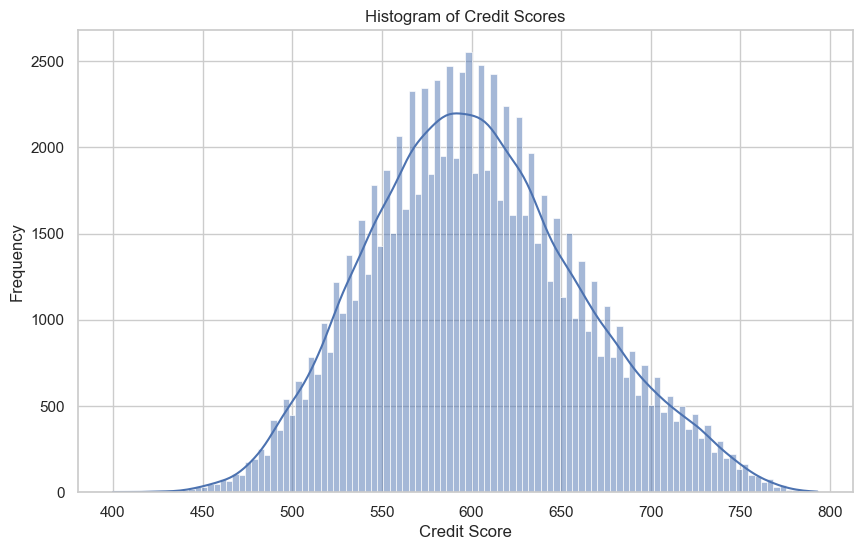

In [1125]:
# plot a histogram of the credit scores
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(X_ref['Credit Score'], kde=True)
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.title('Histogram of Credit Scores')
plt.grid(True)
plt.show()

In [1126]:
# Lets save the X_ref data to a csv file
X_ref.to_csv('X_test_scores.csv', index=False)

# From Credit Score to PD
sum_of_coef_from_score (S) = (( total_score - min_score )/( max_score - min_score )) * ( max_sum_coef - min_sum_coef ) + min_sum_coef

PD(non-default) = exp(S)/( exp(S) + 1 )

In [1127]:
# defining a function to convert Credit Score to PD
def score_to_prob(total_score ,min_score = 300,max_score = 850,scorecard = df_scorecard_sorted):
    
    max_sum_coef = scorecard.groupby('Original Feature name')['Coefficients'].max().sum()
    min_sum_coef = scorecard.groupby('Original Feature name')['Coefficients'].min().sum()


    sum_of_coef_from_score = (total_score - min_score) / (max_score - min_score) * (max_sum_coef - min_sum_coef) + min_sum_coef
    S = sum_of_coef_from_score
    odds = np.exp(S)
    p = odds / (1 + odds)
    return p

  

In [1128]:
# Lets apply this function to the credit scores of the 20 customers in the X_ref data
X_ref['PD'] = X_ref['Credit Score'].apply(lambda x: score_to_prob(total_score=x))

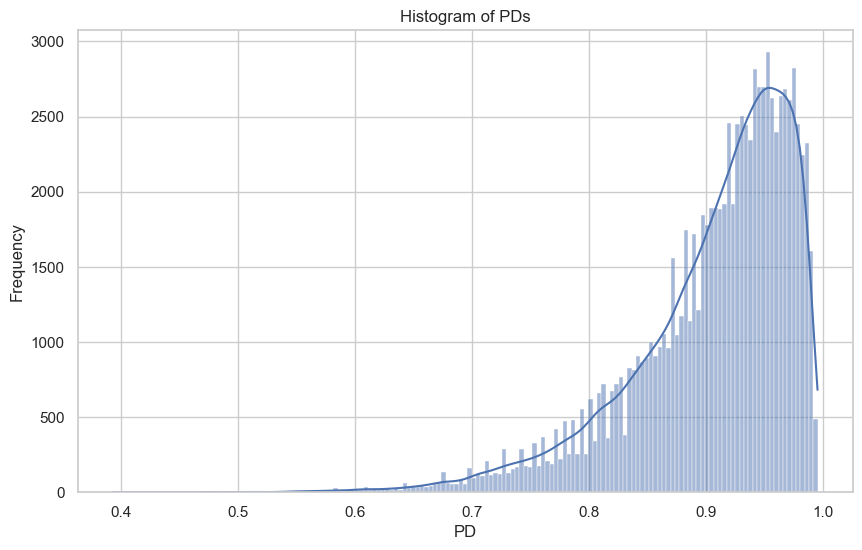

In [1129]:
# Plot the histogram of the PDs
plt.figure(figsize=(10,6))
sns.histplot(X_ref['PD'], kde=True)
plt.xlabel('PD')
plt.ylabel('Frequency')
plt.title('Histogram of PDs')
plt.grid(True)
plt.show()

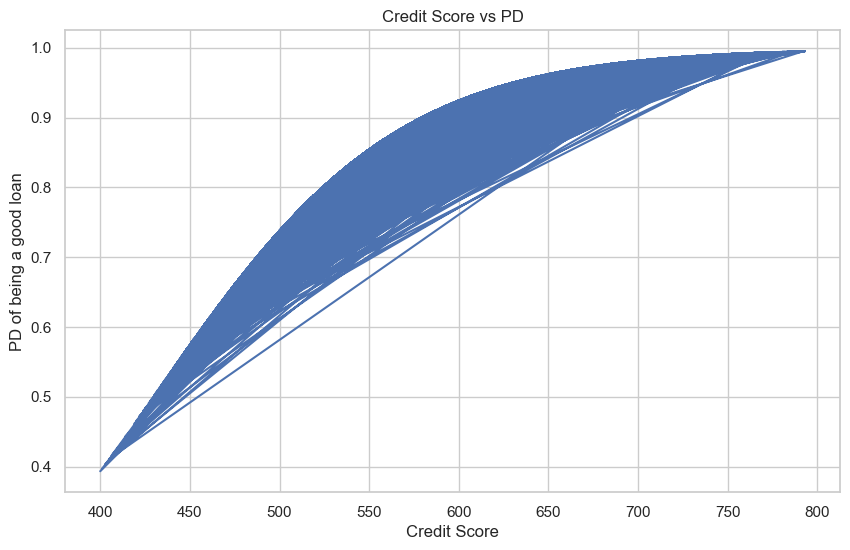

In [1130]:
# Plot a curve between the Credit Score and PD
plt.figure(figsize=(10,6))
plt.plot(X_ref['Credit Score'], X_ref['PD'])
plt.xlabel('Credit Score')
plt.ylabel('PD of being a good loan')
plt.title('Credit Score vs PD')
plt.grid(True)
plt.show()

# Setting Cut off

In [1131]:
# Constructing the ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_hat_test_proba_pd[:,1])

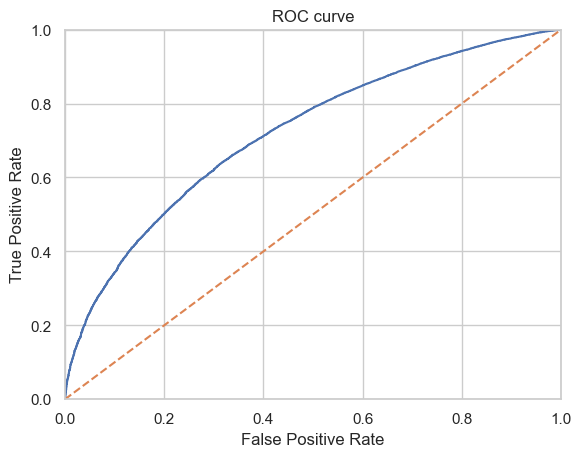

In [1132]:
import matplotlib.pyplot as plt
plt.plot(fpr, tpr) # for plotting the ROC curve at various thresholds
plt.plot([0, 1], [0, 1], linestyle='--') # for plotting the diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.grid(True)
plt.show()


In [1133]:
thresholds

array([       inf, 0.99521209, 0.99431298, ..., 0.42015577, 0.40209695,
       0.39465981])

In [1134]:
thresholds.shape

(15132,)

In [1143]:
df_cutoffs = pd.concat([pd.DataFrame(thresholds), pd.DataFrame(fpr), pd.DataFrame(tpr)], axis=1)
df_cutoffs.columns = ['thresholds', 'fpr', 'tpr']
df_cutoffs.head()

,thresholds,fpr,tpr
0,inf,0.000000,0.000000
1,0.995212,0.000000,0.000012
2,0.994313,0.000000,0.000260
3,0.994282,0.000114,0.000260
4,0.992310,0.000114,0.003244


In [1062]:
df_cutoffs['thresholds'][0] = 1 - 1 / np.power(10, 16)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/3197044947.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cutoffs['thresholds'][0] = 1 - 1 / np.power(10, 16)


# Scores from Threshold of Probability to decide cut off
score_from_prob = ( ln(prob_good / (1 - prob_good)) - min_sum_coef ) * ((max_score - min_score) / (max_sum_coef - min_sum_coef)) + min_score

In [1144]:
p = df_cutoffs['thresholds']
odds = p/(1-p)
df_cutoffs['Score'] = ( np.log(odds) - min_sum_coef ) * ( (max_score - min_score) / (max_sum_coef - min_sum_coef) ) + min_score

In [1145]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,inf,0.000000,0.000000,NaN
1,0.995212,0.000000,0.000012,793.155216
2,0.994313,0.000000,0.000260,781.367121
3,0.994282,0.000114,0.000260,780.994944
4,0.992310,0.000114,0.003244,760.670116


In [1146]:
df_cutoffs['Score'][0] = max_score

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/3137964156.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cutoffs['Score'][0] = max_score


In [1147]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,inf,0.000000,0.000000,850.000000
1,0.995212,0.000000,0.000012,793.155216
2,0.994313,0.000000,0.000260,781.367121
3,0.994282,0.000114,0.000260,780.994944
4,0.992310,0.000114,0.003244,760.670116


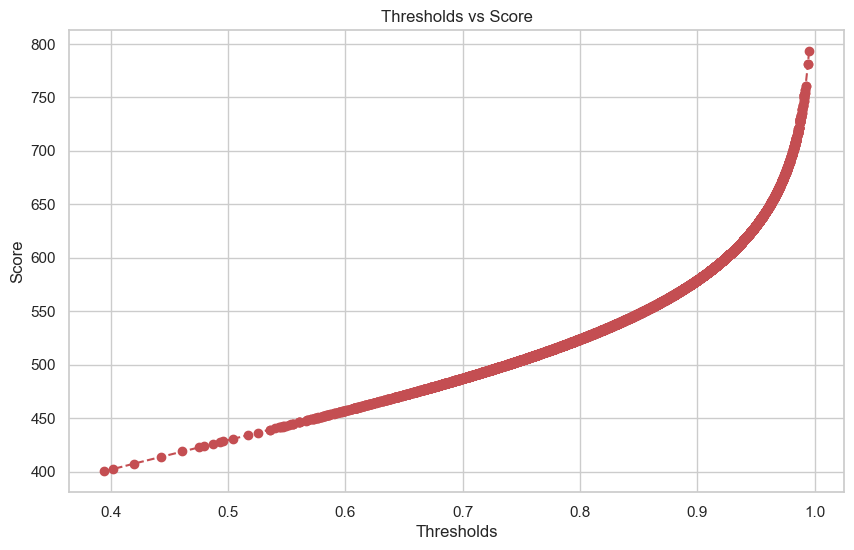

In [1148]:
# make a plot between thresholds and score
plt.figure(figsize=(10,6))
plt.plot(df_cutoffs['thresholds'], df_cutoffs['Score'], marker='o', linestyle='--', color='r')
plt.xlabel('Thresholds')
plt.ylabel('Score')
plt.title('Thresholds vs Score')
plt.grid(True)
plt.show()

In [1149]:
df_actual_pred_sorted.head()

,index,good_bad,Predicted Probability,Predicted,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad,KS
0,41676,0,0.394660,0,1,0,1,0.000011,0.000000,0.000114,0.000114
1,35909,0,0.398743,0,2,0,2,0.000021,0.000000,0.000228,0.000228
2,36242,1,0.402097,0,3,1,2,0.000032,0.000012,0.000228,0.000216
3,41663,1,0.404543,0,4,2,2,0.000043,0.000024,0.000228,0.000204
4,42344,1,0.406915,0,5,3,2,0.000054,0.000036,0.000228,0.000192


In [1150]:
# Lets create a function that calculates the number 
# of approved borrowers for a given threshold

def n_approved(p):
    return np.where(df_actual_pred_sorted['Predicted Probability'] >= p, 1, 0).sum()


In [1151]:
df_cutoffs['N Approved'] = df_cutoffs['thresholds'].apply(n_approved)
df_cutoffs['N Rejected'] = df_actual_pred_sorted.shape[0] - df_cutoffs['N Approved']
df_cutoffs['Approval Rate'] = df_cutoffs['N Approved'] / df_actual_pred_sorted.shape[0]
df_cutoffs['Rejection Rate'] = 1 - df_cutoffs['Approval Rate']

df_cutoffs.head()

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
0,inf,0.000000,0.000000,850.000000,0,93257,0.000000,1.000000
1,0.995212,0.000000,0.000012,793.155216,1,93256,0.000011,0.999989
2,0.994313,0.000000,0.000260,781.367121,22,93235,0.000236,0.999764
3,0.994282,0.000114,0.000260,780.994944,23,93234,0.000247,0.999753
4,0.992310,0.000114,0.003244,760.670116,275,92982,0.002949,0.997051


In [1152]:
# Lets assume the highest level of probability of default we'd accept is 10%
# So we will look up for uptill 90% probability of good loan for cut off of approval rate
df_cutoffs[(thresholds>0.899)&(thresholds<0.9001)]
# 5636th row with threshold 0.900009
# the approval rate is 63%


,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
5619,0.900094,0.340159,0.662424,579.289577,58943,34314,0.632049,0.367951
5620,0.900092,0.340273,0.662424,579.287714,58944,34313,0.632060,0.367940
5621,0.900090,0.340273,0.662436,579.286344,58945,34312,0.632071,0.367929
5622,0.900089,0.340387,0.662436,579.285232,58946,34311,0.632081,0.367919
5623,0.900085,0.340387,0.662495,579.282171,58951,34306,0.632135,0.367865
5624,0.900082,0.340501,0.662495,579.280384,58952,34305,0.632146,0.367854
5625,0.900062,0.340501,0.662590,579.264706,58960,34297,0.632231,0.367769
5626,0.900059,0.340614,0.662590,579.262975,58961,34296,0.632242,0.367758
5627,0.900056,0.340614,0.662626,579.260469,58964,34293,0.632274,0.367726
5628,0.900053,0.340728,0.662626,579.257960,58965,34292,0.632285,0.367715


In [1153]:
df_cutoffs.iloc[5636]

# approval is 63%
# rejection rate is 36%

thresholds            0.900009
fpr                   0.341183
tpr                   0.662780
Score               579.224513
N Approved        58982.000000
N Rejected        34275.000000
Approval Rate         0.632467
Rejection Rate        0.367533
Name: 5636, dtype: float64

In [1154]:
# For 5% probability of default
df_cutoffs[(thresholds>0.949)&(thresholds<0.9501)]

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
1572,0.950068,0.090899,0.326388,630.230824,28368,64889,0.304192,0.695808
1573,0.950067,0.091013,0.326388,630.229738,28369,64888,0.304202,0.695798
1574,0.950042,0.091013,0.326613,630.193446,28388,64869,0.304406,0.695594
1575,0.950042,0.091126,0.326613,630.193422,28389,64868,0.304417,0.695583
1576,0.950032,0.091126,0.326790,630.180023,28404,64853,0.304578,0.695422
1577,0.950030,0.091240,0.326790,630.176628,28405,64852,0.304588,0.695412
1578,0.950020,0.091240,0.326885,630.162295,28413,64844,0.304674,0.695326
1579,0.950019,0.091354,0.326885,630.160981,28414,64843,0.304685,0.695315
1580,0.949975,0.091354,0.327288,630.097860,28448,64809,0.305049,0.694951
1581,0.949974,0.091468,0.327288,630.095996,28449,64808,0.305060,0.694940


In [1155]:
df_cutoffs.iloc[1579]
#approval rate is 30%
# rejection rate is 70%

thresholds            0.950019
fpr                   0.091354
tpr                   0.326885
Score               630.160981
N Approved        28414.000000
N Rejected        64843.000000
Approval Rate         0.304685
Rejection Rate        0.695315
Name: 1579, dtype: float64

In [1156]:
# Lets save these cutoffs to a csv file
df_cutoffs.to_csv('df_cutoffs.csv', index=False)

In [1157]:
X_test_with_ref.shape

(93257, 121)

In [1158]:
X_train_with_ref.shape

(373028, 120)

# PD Model Monitoring

* How do we ensure that the model shall work fine with new latest data?
* How do we see if the present population is similar to the past one?

We use the followiing :

# Population Stability Index (PSI) :
Population Stability Index (PSI) is a metric that quantifies the change in the distribution of a population between two time periods. It is a very useful metric to monitor the performance of a predictive model over time. It tells us if the new data too different from the original one?

PSI is computed as the sum of the difference between the actual and expected event rate in all the bins that are created by the score. The expected event rate is calculated using the overall event rate in the original data. The formula to calculate PSI is as follows:

PSI = sum((Actual Event Rate - Expected Event Rate) * (ln(Actual Event Rate / Expected Event Rate))),

where the sum is taken over all the bins created by the score. Here the actual event rate is the proportion of positive cases in a bin, and the expected event rate is the proportion of positive cases in the original data.

Values of PSI range between 0 and 1. A PSI value of 0 indicates that the two distributions are identical, while a PSI value of 1 indicates that the two distributions are completely different.

Value | Interpretation
0-0.1 | No significant change in the population
0.1-0.25 | Moderate change in the population
0.25+ | Significant change in the population


In [2]:
# importing the necessary libraries
import numpy as np
import pandas as pd

In [ ]:
X_monitor.shape ## Testing data

(93257, 121)

In [ ]:
X_dev.shape ## Training data

(373028, 120)

In [1164]:
uncommon_features = set(X_monitor.columns) - set(X_dev.columns)
uncommon_features

{'PD'}

In [1165]:
# Lets drop the PD column from X_monitor
X_monitor.drop(['PD'], axis=1, inplace=True) # Dropping the PD column
X_monitor.shape

(93257, 120)

In [1178]:
# Need to compute the event rate of each independent variable for development data
expected_event_rate = pd.DataFrame(X_dev.mean(axis = 0))
expected_event_rate.reset_index(inplace = True)
expected_event_rate.columns = ['Feature name', 'Expected Event Rate']
print(expected_event_rate)

                                Feature name  Expected Event Rate
0          months_since_issue_d_class :38-40             0.106255
1          months_since_issue_d_class :40-42             0.103515
2          months_since_issue_d_class :42-44             0.077844
3          months_since_issue_d_class :44-45             0.040882
4          months_since_issue_d_class :45-49             0.133322
5          months_since_issue_d_class :49-50             0.031510
6          months_since_issue_d_class :50-51             0.030065
7          months_since_issue_d_class :51-52             0.027813
8          months_since_issue_d_class :52-54             0.053146
9          months_since_issue_d_class :54-63             0.154447
10         months_since_issue_d_class :63-76             0.092875
11         months_since_issue_d_class :76-96             0.055184
12          months_since_issue_d_class :>=96             0.017626
13                    int_rate_class :9.6-12             0.168111
14        

In [1174]:
# computing actual event rate from monitor data
actual_event_rate_monitor = pd.DataFrame(X_monitor.mean(axis = 0))
actual_event_rate_monitor.reset_index(inplace = True)
actual_event_rate_monitor.columns = ['Feature name', 'Actual Event Rate']
print(actual_event_rate_monitor)

                                Feature name  Actual Event Rate
0          months_since_issue_d_class :38-40           0.104571
1          months_since_issue_d_class :40-42           0.101933
2          months_since_issue_d_class :42-44           0.077635
3          months_since_issue_d_class :44-45           0.040973
4          months_since_issue_d_class :45-49           0.136151
5          months_since_issue_d_class :49-50           0.031333
6          months_since_issue_d_class :50-51           0.031086
7          months_since_issue_d_class :51-52           0.028009
8          months_since_issue_d_class :52-54           0.051031
9          months_since_issue_d_class :54-63           0.155184
10         months_since_issue_d_class :63-76           0.093237
11         months_since_issue_d_class :76-96           0.053497
12          months_since_issue_d_class :>=96           0.018251
13                    int_rate_class :9.6-12           0.165682
14                   int_rate_class :12-

In [1187]:
# Lets merge the expected and actual event rates
event_rates = pd.merge(expected_event_rate, actual_event_rate_monitor, on = 'Feature name', how = 'inner')
event_rates.head()

,Feature name,Expected Event Rate,Actual Event Rate
0,months_since_issue_d_class :38-40,0.106255,0.104571
1,months_since_issue_d_class :40-42,0.103515,0.101933
2,months_since_issue_d_class :42-44,0.077844,0.077635
3,months_since_issue_d_class :44-45,0.040882,0.040973
4,months_since_issue_d_class :45-49,0.133322,0.136151


In [1188]:
# Removing the rows with 0 values in any of the columns
event_rates = event_rates[(event_rates['Expected Event Rate'] != 0) & (event_rates['Actual Event Rate'] != 0)]
event_rates.reset_index(drop=True, inplace=True)
event_rates.head()

,Feature name,Expected Event Rate,Actual Event Rate
0,months_since_issue_d_class :38-40,0.106255,0.104571
1,months_since_issue_d_class :40-42,0.103515,0.101933
2,months_since_issue_d_class :42-44,0.077844,0.077635
3,months_since_issue_d_class :44-45,0.040882,0.040973
4,months_since_issue_d_class :45-49,0.133322,0.136151


In [1189]:
event_rates['Difference'] = event_rates['Actual Event Rate'] - event_rates['Expected Event Rate']
event_rates['log_difference'] = np.log(event_rates['Actual Event Rate'] / event_rates['Expected Event Rate'])
event_rates['PSI_i'] = event_rates['Difference'] * event_rates['log_difference']
event_rates['PSI'] = event_rates['PSI_i'].sum()
event_rates.head()

,Feature name,Expected Event Rate,Actual Event Rate,Difference,log_difference,PSI_i,PSI
0,months_since_issue_d_class :38-40,0.106255,0.104571,-0.001684,-0.015971,2.688757e-05,0.001375
1,months_since_issue_d_class :40-42,0.103515,0.101933,-0.001582,-0.015397,2.435325e-05,0.001375
2,months_since_issue_d_class :42-44,0.077844,0.077635,-0.000209,-0.002690,5.624255e-07,0.001375
3,months_since_issue_d_class :44-45,0.040882,0.040973,0.000091,0.002227,2.029845e-07,0.001375
4,months_since_issue_d_class :45-49,0.133322,0.136151,0.002828,0.020991,5.936803e-05,0.001375


In [1190]:
# Find inf values in the event_rates dataframe
event_rates[event_rates['PSI_i'] == np.inf]

,Feature name,Expected Event Rate,Actual Event Rate,Difference,log_difference,PSI_i,PSI


In [1191]:
print('PSI :', event_rates['PSI'].values[0])

# PSI indicates that the test population is not different than train population

PSI : 0.0013748846280973478


The Population Stability Index (PSI) is used to measure the stability of a variable over time, often for credit risk modeling and machine learning applications. It helps assess whether a model needs recalibration due to population drift.

# PSI Interpretation:

PSI < 0.1 → No significant change (Stable)

0.1 ≤ PSI < 0.25 → Moderate change (Requires monitoring)

PSI ≥ 0.25 → Significant change (Model recalibration needed)


# LGD and EAD Modelling

* LGD : the percentage of the exposure that was lost after the borrower defaulted
* EAD : the amount of the exposure at the moment the borrower defaulted

When building LGD and EAD models, it is a good practice to build models with data from borrowers that have had enough time to repay part of the remaining debt.

# What DATA would we check for?
 Naturally, data only of defaulted borrowers :)
 However, it will not be wise to include all defaulted accounts for LGD and EAD. It wont make sense to include a borrower who has entirely defaulted and lender cant recover anything from him. LGD and EAD is computed in the hope of recovering atleast some money from the borrower. So we need only data for accounts that have been written off and a sufficient amount of time has passed so there can be some recoveries.

 Hence, when building LGD and EAD models, it is a good practice to build models with data from borrowers that have had enough time to repay part of the remaining debt.

 In our data, these are only the accounts that were written off. Their loan_status is :

 * Charged Off

 * Does not meet the credit policy Status : Charged off







In [28]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1196]:
# loading the dataset

loan_data = pd.read_csv('loan_data_2007_2014_cleaned.csv') # Reading the updated csv file which was cleaned earlier

In [1197]:
loan_data.columns.to_list()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'loan_status',
 'purpose',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'months_since_earliest_cr',
 'months_since_issue_d',
 'months_since_last_pymnt_d',
 'months_since_last_credit_pull_d',
 'months_since_next_pymnt_d']

In [1198]:
loan_data['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [1199]:
# Extracting the relevant data suitable for LGD, EAD

loan_data_defaults = loan_data[loan_data['loan_status'].isin(['Charged Off','Does not meet the credit policy. Status:Charged Off'])]

In [1200]:
loan_data_defaults.drop('loan_status', axis=1, inplace=True)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/3217134540.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults.drop('loan_status', axis=1, inplace=True)


In [1201]:
loan_data_defaults.shape

(43236, 49)

Unlike PD modelling, we dont need to have all variables as dummy. For discrete variables, we will create as many dummy variables as the number of categories. 
We can use the continuous variables as they are or transform them. There is no need for fine classing or coarse classing.
 
LGD = 1 - Recovery Rate

We assume that for defaulted borrowers, the 'funded_amnt' reflects the total amount that was lost the moment the borrower defaulted.

Recovery rate is the amount recovered by the lender after the borrower defaults. It is expressed as a percentage of the total amount that was lost when the borrower defaulted.

Recovery rate = recoveries / funded_amnt

In [1202]:
loan_data_defaults['recovery_rate'] = loan_data_defaults['recoveries']/loan_data_defaults['funded_amnt']

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/2407519040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['recovery_rate'] = loan_data_defaults['recoveries']/loan_data_defaults['funded_amnt']


In [1203]:
loan_data_defaults['recovery_rate'].describe()

# Recovery rates are between 0 and 1
# But here the rate is crossing one, perhaps due to some error.

count    43236.000000
mean         0.060820
std          0.089770
min          0.000000
25%          0.000000
50%          0.029466
75%          0.114044
max          1.220774
Name: recovery_rate, dtype: float64

In [1204]:
loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] > 1, 1, loan_data_defaults['recovery_rate'])
loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] < 0, 0, loan_data_defaults['recovery_rate'])

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/1601776879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] > 1, 1, loan_data_defaults['recovery_rate'])
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/1601776879.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] < 0, 0, loan_data_defaults['recovery_rate'])


EAD is a measure of the potential loss in the event of default.
EAD = total funded amount * credit conversion factor

Lets consider Total recovered principal which reflects the total payments made on the principal of the loan. Also, credit conversion factor is the proportion of total exposure at the moment of default.

So, credit conversion factor = (Total funded amount - Total recovered principal) / Total funded amount


In [1205]:
loan_data_defaults['ccf'] = (loan_data_defaults['funded_amnt'] - loan_data_defaults['total_rec_prncp'])/loan_data_defaults['funded_amnt']

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/626532285.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['ccf'] = (loan_data_defaults['funded_amnt'] - loan_data_defaults['total_rec_prncp'])/loan_data_defaults['funded_amnt']


In [1206]:
loan_data_defaults['ccf'].describe()

count    43236.000000
mean         0.735952
std          0.200742
min          0.000438
25%          0.632088
50%          0.789908
75%          0.888543
max          1.000000
Name: ccf, dtype: float64

# Dependent variable for LGD is Recovery Rate
# Dependent variable for EAD is CCF

# explore the dependent variables graphically

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


<Axes: xlabel='recovery_rate', ylabel='Count'>

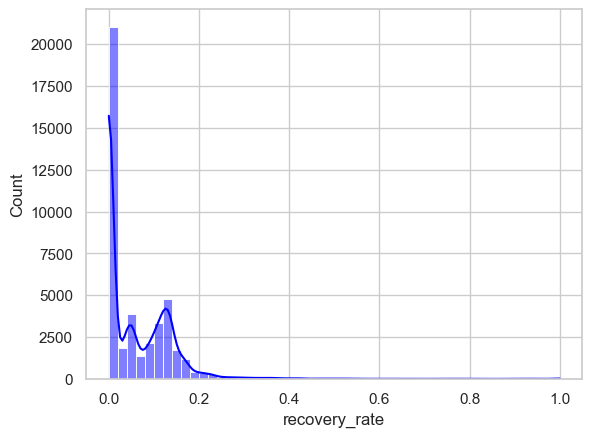

In [1207]:
sns.histplot(loan_data_defaults['recovery_rate'], kde=True, color='blue', bins=50)

<Axes: xlabel='ccf', ylabel='Count'>

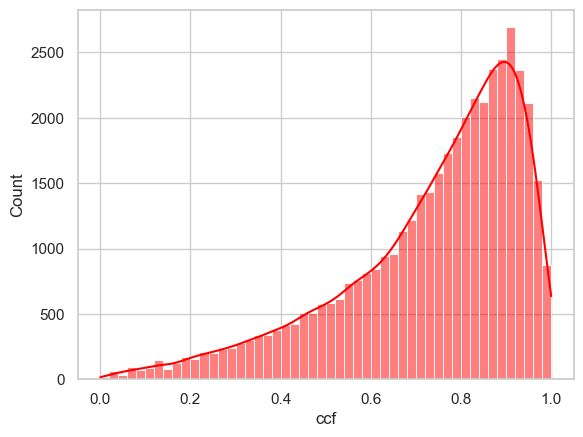

In [1208]:
sns.histplot(loan_data_defaults['ccf'], kde=True, color='red', bins=50)

Methodologically, the density of proportions follow beta distribution. The beta distribution is a continuous probability distribution defined on the interval [0, 1] and is parameterized by two positive shape parameters, denoted by α and β. The probability density function of the beta distribution is given by:

beta(x; α, β) = x^(α-1) * (1-x)^(β-1) / B(α, β)

where B(α, β) is the beta function, defined as:

B(α, β) = ∫_0^1 x^(α-1) * (1-x)^(β-1) dx

The beta distribution is a conjugate prior to the binomial distribution, which makes it a popular choice for modeling proportions. The beta distribution is also used in Bayesian statistics to model the uncertainty in the parameters of a binomial distribution. The beta distribution has a wide range of applications in various fields, such as biology, economics, and engineering. It is a versatile distribution that can be used to model a variety of data types, including proportions, probabilities, and continuous variables that are bounded between 0 and 1. The beta distribution is a flexible and powerful tool for modeling uncertainty and variability in data, and it is widely used in statistical analysis and data science.
The beta distribution has several important properties that make it a useful distribution for modeling proportions. First, the beta distribution is defined on the interval [0, 1], which makes it a natural choice for modeling proportions and probabilities. Second, the beta distribution is a flexible distribution that can take on a wide range of shapes, depending on the values of the shape parameters α and β. Third, the beta distribution is a conjugate prior to the binomial distribution, which means that the posterior distribution of the parameters of a binomial distribution is also a beta distribution. This property makes the beta distribution a popular choice for Bayesian analysis of proportions. Finally, the beta distribution has a simple and intuitive interpretation, with the shape parameters α and β controlling the shape of the distribution. In summary, the beta distribution is a versatile and powerful distribution that is well-suited for modeling proportions and probabilities in a wide range of applications.
Here we do Beta regression to model the proportion of the data.

python lacks library for beta regression, so we use R for this purpose. But R consumes large memory, so we devise a strategy as follows:

Two Stage Strategy:
1. Check if recovery rate equal to 0 or greater than 0? ---> logisitic regression model

2. If recovery rate is greater than 0, then how much exactly is it? ---> linear regression model


In [1209]:
loan_data_defaults['recovery_rate_0_1'] = np.where(loan_data_defaults['recovery_rate'] == 0, 0, 1)
loan_data_defaults['recovery_rate_0_1'].value_counts()

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/4016946296.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['recovery_rate_0_1'] = np.where(loan_data_defaults['recovery_rate'] == 0, 0, 1)


recovery_rate_0_1
1    24371
0    18865
Name: count, dtype: int64

For ccf, we see it is more homogeneously distributed across the whole range of values, so we can apply linear regression to predict the value of ccf. So for ccf we use a multiple linear regression model.


In [1210]:
data = loan_data_defaults

In [1211]:
data.columns.to_list()



['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'purpose',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'months_since_earliest_cr',
 'months_since_issue_d',
 'months_since_last_pymnt_d',
 'months_since_last_credit_pull_d',
 'months_since_next_pymnt_d',
 'recovery_rate',
 'ccf',
 'recovery_rate_0_1']

In [1212]:
# to remove :
remove_cols = ['member_id','sub_grade','policy_code']
data.drop(remove_cols, axis=1, inplace=True)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/3438533995.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(remove_cols, axis=1, inplace=True)


In [1214]:
non_numeric_columns = data.select_dtypes(include=['object']).columns # Selecting the non numeric columns   
non_numeric_columns_list = non_numeric_columns.tolist() # Converting to list for easier manipulation
non_numeric_columns_list # Displaying the non numeric columns as a list


['grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'initial_list_status']

In [1215]:
# As we can see how to convert the grade column to dummy variables, we do this for 
# all the non numeric columns 
# We define a function to do this ardous task!
def create_dummies(column, loan_data):
    dummies = pd.get_dummies(loan_data[column], prefix=column, prefix_sep=':', drop_first=True, dtype=int) # Creating dummy variables
    loan_data.drop(column, axis=1, inplace=True) # Dropping the original column
    loan_data = pd.concat([loan_data, dummies], axis=1) # Concatenating the dummy variables to the DataFrame
    loan_data.reset_index(drop=True, inplace=True)
    return loan_data # Returning the updated DataFrame

In [1216]:
dummies_list = non_numeric_columns_list + ['term']  # Creating a list of non numeric columns
# of non numeric columns except loan_status
for column in dummies_list:
    data = create_dummies(column, data) # Creating dummy variables for each non numeric column

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_5665/2858868286.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data.drop(column, axis=1, inplace=True) # Dropping the original column


In [1217]:
data.columns.to_list()

['id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'int_rate',
 'installment',
 'emp_length',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'months_since_earliest_cr',
 'months_since_issue_d',
 'months_since_last_pymnt_d',
 'months_since_last_credit_pull_d',
 'months_since_next_pymnt_d',
 'recovery_rate',
 'ccf',
 'recovery_rate_0_1',
 'grade:B',
 'grade:C',
 'grade:D',
 'grade:E',
 'grade:F',
 'grade:G',
 'home_ownership:NONE',
 'home_ownership:OTHER',
 'home_ownership:OWN',
 'home_ownership:RENT',
 'verification_status:Sou

In [1218]:
all_states = set(loan_data_defaults['addr_state'])
dummy_states = ['addr_state:AL',
 'addr_state:AR',
 'addr_state:AZ',
 'addr_state:CA',
 'addr_state:CO',
 'addr_state:CT',
 'addr_state:DC',
 'addr_state:DE',
 'addr_state:FL',
 'addr_state:GA',
 'addr_state:HI',
 'addr_state:IA',
 'addr_state:ID',
 'addr_state:IL',
 'addr_state:IN',
 'addr_state:KS',
 'addr_state:KY',
 'addr_state:LA',
 'addr_state:MA',
 'addr_state:MD',
 'addr_state:MI',
 'addr_state:MN',
 'addr_state:MO',
 'addr_state:MS',
 'addr_state:MT',
 'addr_state:NC',
 'addr_state:NE',
 'addr_state:NH',
 'addr_state:NJ',
 'addr_state:NM',
 'addr_state:NV',
 'addr_state:NY',
 'addr_state:OH',
 'addr_state:OK',
 'addr_state:OR',
 'addr_state:PA',
 'addr_state:RI',
 'addr_state:SC',
 'addr_state:SD',
 'addr_state:TN',
 'addr_state:TX',
 'addr_state:UT',
 'addr_state:VA',
 'addr_state:VT',
 'addr_state:WA',
 'addr_state:WI',
 'addr_state:WV',
 'addr_state:WY']


In [1219]:
dummy_states_list = set([state.split(':')[1] for state in dummy_states])
reference_state = all_states - dummy_states_list
reference_state

{'AK'}

In [1220]:
loan_data_defaults['home_ownership'].value_counts()

#reference_home_ownership = 'MORTGAGE'

home_ownership
RENT        20258
MORTGAGE    19147
OWN          3785
OTHER          38
NONE            8
Name: count, dtype: int64

In [1221]:
loan_data_defaults['verification_status'].value_counts()
#reference_verification_status = 'Not Verified'

verification_status
Verified           18459
Source Verified    12642
Not Verified       12135
Name: count, dtype: int64

In [1222]:
loan_data_defaults['purpose'].value_counts()


purpose
debt_consolidation    26127
credit_card            7449
other                  2892
home_improvement       2197
small_business         1394
major_purchase          831
medical                 545
car                     438
moving                  408
house                   278
wedding                 278
vacation                259
educational              88
renewable_energy         52
Name: count, dtype: int64

In [1223]:
all_purposes = set(loan_data_defaults['purpose'])
dummy_purposes = ['purpose:credit_card',
 'purpose:debt_consolidation',
 'purpose:educational',
 'purpose:home_improvement',
 'purpose:house',
 'purpose:major_purchase',
 'purpose:medical',
 'purpose:moving',
 'purpose:other',
 'purpose:renewable_energy',
 'purpose:small_business',
 'purpose:vacation',
 'purpose:wedding']

dummy_purposes_list = set([purpose.split(':')[1] for purpose in dummy_purposes])
reference_purpose = all_purposes - dummy_purposes_list
reference_purpose

{'car'}

In [1224]:
loan_data_defaults['initial_list_status'].value_counts()
#reference_initial_list_status = 'f'

initial_list_status
f    32094
w    11142
Name: count, dtype: int64

In [1225]:
reference_category = ['addr_state:AK','purpose:car', 'verification_status:Not Verified', 'home_ownership:MORTGAGE', 'grade:A','initial_list_status:f','term:30']

In [1226]:
data.to_csv('loan_data_defaults.csv', index=False)

In [1227]:
data = pd.read_csv('loan_data_defaults.csv')

In [1228]:
data.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,...,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:w,term:60
0,1077430,2500,2500,2500.0,15.27,59.83,0.0,30000.0,1.00,0.0,...,0,0,0,0,0,0,0,0,0,1
1,1071795,5600,5600,5600.0,21.28,152.39,4.0,40000.0,5.55,0.0,...,0,0,0,0,0,0,0,0,0,1
2,1071570,5375,5375,5350.0,12.69,121.45,0.0,15000.0,18.08,0.0,...,1,0,0,0,0,0,0,0,0,1
3,1064687,9000,9000,9000.0,13.49,305.38,0.0,30000.0,10.08,0.0,...,0,0,1,0,0,0,0,0,0,0
4,1069057,10000,10000,10000.0,10.65,325.74,3.0,100000.0,7.06,0.0,...,0,0,0,0,0,0,0,0,0,0


In [1230]:
data.shape

(43236, 117)

# LGD model

In [1234]:
#splitting the data into train and test for stage 1
from sklearn.model_selection import train_test_split
X = data.drop(['id','recovery_rate','recovery_rate_0_1','ccf','recoveries'],axis = 1)
y = data['recovery_rate_0_1']
lgd_inputs_stage1_train, lgd_inputs_stage1_test, lgd_targets_stage1_train, lgd_targets_stage1_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [1235]:
# Lets Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

lgd_inputs_stage1_train_scaled = scaler.fit_transform(lgd_inputs_stage1_train)
lgd_inputs_stage1_test_scaled = scaler.transform(lgd_inputs_stage1_test)

lgd_inputs_stage1_train_scaled = pd.DataFrame(lgd_inputs_stage1_train_scaled, columns = X.columns)


# Check for Multicollinearity by VIF

The Variance Inflation Factor (VIF) is used to detect multicollinearity in regression analysis. There is no strict threshold for VIF, but commonly used guidelines are:

VIF = 1: No correlation between the feature and other features.

1 < VIF < 5: Moderate correlation, generally considered acceptable.

VIF > 5: High correlation, indicates potential multicollinearity problems.

VIF > 10: Very high correlation, often considered as a rule of thumb threshold indicating serious multicollinearity issues.

Features with VIF values greater than 5 or 10 are typically considered for removal or further investigation. We use Ridge Regression if too many variables have high VIF.



In [1236]:
# Let X be:
X = lgd_inputs_stage1_train_scaled

In [1237]:
# First we find the multicolinearity in the X matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["Features"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif.sort_values(by = 'VIF', ascending = False)
vif

/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1785: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Features,VIF
1,funded_amnt,362.943163
19,total_pymnt,204.132970
0,loan_amnt,177.978203
20,total_pymnt_inv,168.594395
2,funded_amnt_inv,127.747037
65,addr_state:CA,65.953289
4,installment,55.235252
93,addr_state:NY,40.363954
70,addr_state:FL,36.293665
102,addr_state:TX,30.890422


In [1238]:
high_vif_features = vif[vif['VIF'] > 10]
high_vif_features

,Features,VIF
1,funded_amnt,362.943163
19,total_pymnt,204.132970
0,loan_amnt,177.978203
20,total_pymnt_inv,168.594395
2,funded_amnt_inv,127.747037
65,addr_state:CA,65.953289
4,installment,55.235252
93,addr_state:NY,40.363954
70,addr_state:FL,36.293665
102,addr_state:TX,30.890422


 In banking and credit risk modeling, simply dropping variables with high Variance Inflation Factor (VIF) can be problematic because:

Loss of Important Predictors: Some high-VIF variables might still contain valuable information, even if they are correlated.
Regulatory and Business Interpretability: Banks often need to justify why specific variables are included or excluded, especially for models used in credit scoring (e.g., PD, LGD, EAD models).
Confounding Effects: Dropping variables may remove critical relationships, leading to misleading interpretations.

# Why Ridge Regression is Better?
✅ Handles Multicollinearity: Ridge regression shrinks correlated coefficients rather than dropping variables, preserving model stability.

✅ Retains All Variables: Unlike variable selection methods, Ridge does not arbitrarily remove features, ensuring all risk factors are accounted for.

✅ Smooth Coefficients: It prevents extreme fluctuations in model parameters, which is crucial for regulatory-compliant risk models.

✅ Better Generalization: By controlling overfitting, Ridge improves out-of-sample predictions, which is essential for stress testing and IFRS 9 models.

In [1239]:
X = lgd_inputs_stage1_train_scaled
y = lgd_targets_stage1_train

# Estimating the Model

Logistic Regression function when there is no singularity

from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_p_values:
    
    def __init__(self,*args,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs,max_iter=1000)

    def fit(self,X,y):
        self.model.fit(X,y)
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X)
        Cramer_Rao = np.linalg.inv(F_ij)
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores]
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [84]:
# Using ridge regression, in case of singularity of gram matrix X^T*X
# (X^T*X)^-1 does not exist, so we do ridge regression

import numpy as np
from sklearn.linear_model import LogisticRegression
from scipy import stats

class LogisticRegression_with_p_values(LogisticRegression):
    def fit(self, X, y):
        # Fit the model
        super().fit(X, y)
        
        # Number of observations and features
        n = X.shape[0]
        p = X.shape[1]
        
        # Compute the predicted probabilities
        denom = (2.0 * (1.0 + np.cosh(self.decision_function(X))))
        denom = np.tile(denom, (X.shape[1], 1)).T
        F_ij = np.dot((X / denom).T, X)
        
        # Add regularization term to avoid singular matrix
        alpha = 1.0  # Regularization strength
        F_ij += alpha * np.eye(F_ij.shape[0])
        
        # Compute the inverse of the Fisher Information Matrix
        Cramer_Rao = np.linalg.inv(F_ij)
        
        # Compute the standard errors of the coefficients
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        
        # Compute the z-scores
        z_scores = self.coef_[0] / sigma_estimates
        
        # Compute the p-values
        self.p_values = [stats.norm.sf(abs(x)) * 2 for x in z_scores]
        return self



In [1241]:
reg_lgd_stage_1 = LogisticRegression_with_p_values()
reg_lgd_stage_1.fit(X,y)

/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression_with_p_values()

In [1242]:
feature_name = X.columns.values
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg_lgd_stage_1.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg_lgd_stage_1.intercept_[0]]
summary_table = summary_table.sort_index()
p_values = reg_lgd_stage_1.p_values
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,9.918689,NaN
1,loan_amnt,0.091453,6.821721e-01
2,funded_amnt,-0.167172,6.771658e-01
3,funded_amnt_inv,1.012987,3.225182e-04
4,int_rate,0.310706,5.390354e-04
5,installment,-1.506225,4.884059e-14
6,emp_length,0.013593,6.040595e-01
7,annual_inc,-0.048467,1.757274e-01
8,dti,-0.057511,5.784875e-02
9,delinq_2yrs,-0.048709,1.645890e-01


In [1243]:
# Lets remove the features with p-values greater than 0.05
summary_table = summary_table[summary_table['p_values'] < 0.05]
significant_features = summary_table['Feature name'].values
significant_features

array(['funded_amnt_inv', 'int_rate', 'installment', 'inq_last_6mths',
       'pub_rec', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'collection_recovery_fee', 'last_pymnt_amnt',
       'months_since_earliest_cr', 'months_since_issue_d',
       'months_since_last_pymnt_d', 'months_since_last_credit_pull_d',
       'months_since_next_pymnt_d', 'home_ownership:OWN',
       'purpose:educational', 'initial_list_status:w', 'term:60'],
      dtype=object)

In [1244]:
summary_table

,Feature name,Coefficients,p_values
3,funded_amnt_inv,1.012987,3.225182e-04
4,int_rate,0.310706,5.390354e-04
5,installment,-1.506225,4.884059e-14
10,inq_last_6mths,0.059462,3.105989e-02
14,pub_rec,-0.080392,1.076353e-02
20,total_pymnt,23.395433,0.000000e+00
21,total_pymnt_inv,1.661792,1.130384e-07
22,total_rec_prncp,-14.917159,0.000000e+00
23,total_rec_int,-10.152403,0.000000e+00
25,collection_recovery_fee,20.424382,0.000000e+00


In [ ]:
##############################

In [1245]:
sorted(data.columns.to_list()+reference_category)
    

['acc_now_delinq',
 'addr_state:AK',
 'addr_state:AL',
 'addr_state:AR',
 'addr_state:AZ',
 'addr_state:CA',
 'addr_state:CO',
 'addr_state:CT',
 'addr_state:DC',
 'addr_state:DE',
 'addr_state:FL',
 'addr_state:GA',
 'addr_state:HI',
 'addr_state:IA',
 'addr_state:ID',
 'addr_state:IL',
 'addr_state:IN',
 'addr_state:KS',
 'addr_state:KY',
 'addr_state:LA',
 'addr_state:MA',
 'addr_state:MD',
 'addr_state:MI',
 'addr_state:MN',
 'addr_state:MO',
 'addr_state:MS',
 'addr_state:MT',
 'addr_state:NC',
 'addr_state:NE',
 'addr_state:NH',
 'addr_state:NJ',
 'addr_state:NM',
 'addr_state:NV',
 'addr_state:NY',
 'addr_state:OH',
 'addr_state:OK',
 'addr_state:OR',
 'addr_state:PA',
 'addr_state:RI',
 'addr_state:SC',
 'addr_state:SD',
 'addr_state:TN',
 'addr_state:TX',
 'addr_state:UT',
 'addr_state:VA',
 'addr_state:VT',
 'addr_state:WA',
 'addr_state:WI',
 'addr_state:WV',
 'addr_state:WY',
 'annual_inc',
 'ccf',
 'collection_recovery_fee',
 'collections_12_mths_ex_med',
 'delinq_2yrs',
 

In [1246]:
final_inputs_stage_1 = [
       'recovery_rate_0_1',
       'recovery_rate',
         'ccf'      
] + significant_features.tolist()


In [ ]:
final_inputs_stage_1 #lgd stage 1

['recovery_rate_0_1',
 'recovery_rate',
 'ccf',
 'funded_amnt_inv',
 'int_rate',
 'installment',
 'inq_last_6mths',
 'pub_rec',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'months_since_earliest_cr',
 'months_since_issue_d',
 'months_since_last_pymnt_d',
 'months_since_last_credit_pull_d',
 'months_since_next_pymnt_d',
 'home_ownership:OWN',
 'purpose:educational',
 'initial_list_status:w',
 'term:60']

In [1266]:
data_lgd_stage_1 = data[final_inputs_stage_1 ]

In [1267]:
data_lgd_stage_1.shape

(43236, 23)

In [1268]:
data_lgd_stage_1.head()

,recovery_rate_0_1,recovery_rate,ccf,funded_amnt_inv,int_rate,installment,inq_last_6mths,pub_rec,total_pymnt,total_pymnt_inv,...,last_pymnt_amnt,months_since_earliest_cr,months_since_issue_d,months_since_last_pymnt_d,months_since_last_credit_pull_d,months_since_next_pymnt_d,home_ownership:OWN,purpose:educational,initial_list_status:w,term:60
0,1,0.046832,0.817416,2500.0,15.27,59.83,5.0,0.0,1008.71,1008.71,...,119.66,224.0,72.0,56.0,51.0,22.0,0,0,0,1
1,1,0.033761,0.971068,5600.0,21.28,152.39,2.0,0.0,646.02,646.02,...,152.39,164.0,72.0,68.0,64.0,22.0,1,0,0,1
2,1,0.050100,0.874701,5350.0,12.69,121.45,0.0,0.0,1476.19,1469.34,...,121.45,159.0,72.0,61.0,57.0,22.0,0,0,0,1
3,1,0.049367,0.860429,9000.0,13.49,305.38,1.0,0.0,2270.70,2270.70,...,305.38,164.0,72.0,65.0,61.0,22.0,0,0,0,0
4,1,0.064510,0.456653,10000.0,10.65,325.74,2.0,0.0,7471.99,7471.99,...,325.74,319.0,72.0,50.0,45.0,22.0,0,0,0,0


In [1269]:
#splitting the data_lgd_stage_1 into train and test for stage 1
from sklearn.model_selection import train_test_split
X = data_lgd_stage_1.drop(['recovery_rate','recovery_rate_0_1','ccf'],axis = 1)
y = data_lgd_stage_1['recovery_rate_0_1']
lgd_inputs_stage1_train, lgd_inputs_stage1_test, lgd_targets_stage1_train, lgd_targets_stage1_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [1270]:
lgd_inputs_stage1_test.head()

,funded_amnt_inv,int_rate,installment,inq_last_6mths,pub_rec,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,collection_recovery_fee,last_pymnt_amnt,months_since_earliest_cr,months_since_issue_d,months_since_last_pymnt_d,months_since_last_credit_pull_d,months_since_next_pymnt_d,home_ownership:OWN,purpose:educational,initial_list_status:w,term:60
21362,10100.0,18.49,367.63,3.0,0.0,7386.81,7386.81,4922.11,2430.49,6.1578,367.63,220.0,60.0,40.0,23.0,22.0,0,0,1,0
8768,8950.0,7.90,281.62,0.0,0.0,5315.94,5286.41,2766.11,611.95,340.1896,281.62,221.0,49.0,37.0,23.0,22.0,0,0,0,0
11903,5950.0,24.50,174.36,0.0,1.0,3482.64,3453.66,1263.88,2218.76,0.0000,174.36,225.0,52.0,32.0,23.0,22.0,0,0,0,1
42973,19525.0,7.62,609.21,0.0,0.0,10706.67,10692.98,7076.36,1449.91,392.4720,609.21,308.0,47.0,33.0,28.0,22.0,0,0,0,0
29933,18650.0,15.99,655.59,2.0,0.0,5219.87,5219.87,3412.63,1807.24,0.0000,655.59,211.0,37.0,29.0,23.0,22.0,1,0,0,0


In [1271]:
X.columns.shape

(20,)

In [1272]:
# Lets Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

lgd_inputs_stage1_train_scaled = scaler.fit_transform(lgd_inputs_stage1_train)
lgd_inputs_stage1_test_scaled = scaler.transform(lgd_inputs_stage1_test)


In [1273]:
reg2_lgd_stage_1 = LogisticRegression_with_p_values()
reg2_lgd_stage_1.fit(lgd_inputs_stage1_train_scaled, lgd_targets_stage1_train)

LogisticRegression_with_p_values()

In [1280]:
reg2_lgd_stage_1.coef_.shape

(1, 20)

In [1281]:
feature_name = X.columns.values
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg2_lgd_stage_1.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg2_lgd_stage_1.intercept_[0]]
summary_table = summary_table.sort_index()
p_values = reg2_lgd_stage_1.p_values
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,9.617838,NaN
1,funded_amnt_inv,0.712066,2.570381e-05
2,int_rate,0.216832,1.016307e-08
3,installment,-1.267358,5.066090e-16
4,inq_last_6mths,0.056021,3.151230e-02
5,pub_rec,-0.078166,9.211800e-03
6,total_pymnt,23.521019,0.000000e+00
7,total_pymnt_inv,2.039802,1.226067e-15
8,total_rec_prncp,-15.239190,0.000000e+00
9,total_rec_int,-10.362906,0.000000e+00


# Testing the Model

In [1282]:
y_hat_test_lgd_stage_1 = reg2_lgd_stage_1.predict(lgd_inputs_stage1_test_scaled)

In [1283]:
lgd_inputs_stage1_test_scaled.shape

(8648, 20)

In [1284]:
pd.DataFrame(y_hat_test_lgd_stage_1).value_counts()

0
1    4661
0    3987
Name: count, dtype: int64

In [1285]:
y_hat_test_proba_lgd_stage_1 = reg2_lgd_stage_1.predict_proba(lgd_inputs_stage1_test_scaled)
y_hat_test_proba_lgd_stage_1

array([[8.20271153e-01, 1.79728847e-01],
       [4.24105195e-14, 1.00000000e+00],
       [8.97318098e-01, 1.02681902e-01],
       ...,
       [8.92841356e-11, 1.00000000e+00],
       [1.57821122e-07, 9.99999842e-01],
       [9.78740715e-01, 2.12592851e-02]])

In [1286]:
y_hat_test_proba_lgd_stage_1 = y_hat_test_proba_lgd_stage_1[:,1]
# probability of recovery rate being more than 0
y_hat_test_proba_lgd_stage_1

array([0.17972885, 1.        , 0.1026819 , ..., 1.        , 0.99999984,
       0.02125929])

In [1287]:
lgd_targets_stage1_test_temp = lgd_targets_stage1_test

In [1288]:
lgd_targets_stage1_test_temp.reset_index(drop=True, inplace=True)

In [1289]:
df_actual_predicted_probs = pd.concat([lgd_targets_stage1_test_temp, pd.DataFrame(y_hat_test_proba_lgd_stage_1)], axis=1)
df_actual_predicted_probs.columns = ['lgd_targets_stage1_test', 'y_hat_test_proba_lgd_stage_1']
df_actual_predicted_probs.index = lgd_inputs_stage1_test.index
df_actual_predicted_probs.head()

,lgd_targets_stage1_test,y_hat_test_proba_lgd_stage_1
21362,1,0.179729
8768,1,1.000000
11903,0,0.102682
42973,1,1.000000
29933,0,0.013398


In [1290]:
tr = 0.5
df_actual_predicted_probs['y_hat_test_lgd_stage_1'] = np.where(df_actual_predicted_probs['y_hat_test_proba_lgd_stage_1'] > tr, 1, 0)
df_actual_predicted_probs.head()

,lgd_targets_stage1_test,y_hat_test_proba_lgd_stage_1,y_hat_test_lgd_stage_1
21362,1,0.179729,0
8768,1,1.000000,1
11903,0,0.102682,0
42973,1,1.000000,1
29933,0,0.013398,0


In [1291]:
# Create a cross table of predicted and actual values
cross_table = pd.crosstab(df_actual_predicted_probs['lgd_targets_stage1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames=['Actual'], colnames=['Predicted'])
cross_table

# A lot of missclassification here!


Predicted,0,1
Actual,,
0,3673,89
1,314,4572


In [1292]:
# Lets find the classification report
from sklearn.metrics import classification_report
print(classification_report(df_actual_predicted_probs['lgd_targets_stage1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1']))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3762
           1       0.98      0.94      0.96      4886

    accuracy                           0.95      8648
   macro avg       0.95      0.96      0.95      8648
weighted avg       0.95      0.95      0.95      8648



Accuracy of 95%. Recall, f-1 score everything good, great model. But accuracy at a given cut-off is not as informative as the Receiver Operating Characteristic( ROC ) Curve, which shows the True Positive Rates as a function of False positive rates, essentially covering all possible cut off points. Lets calculate ROC.

In [1293]:
from sklearn.metrics import roc_curve, roc_auc_score    

In [1294]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['lgd_targets_stage1_test'], df_actual_predicted_probs['y_hat_test_proba_lgd_stage_1'])

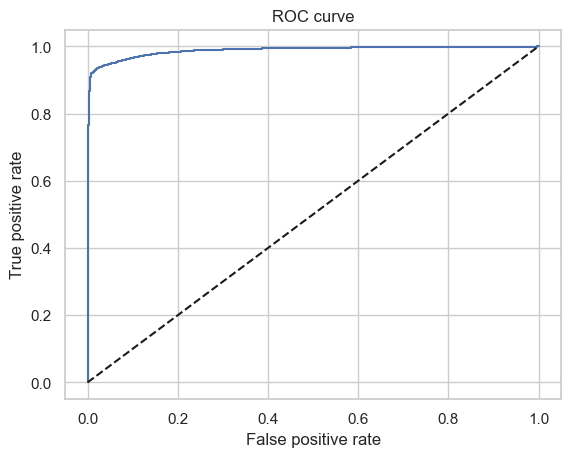

In [1295]:
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.grid(True)
plt.show()


In [1297]:
AUROC = roc_auc_score(df_actual_predicted_probs['lgd_targets_stage1_test'], df_actual_predicted_probs['y_hat_test_proba_lgd_stage_1'])
AUROC

# AUROC is 98%. Excellent improvement!

0.9881531779435566

Note : It is more important to have a large proportion of correctly classified values that are greater than 0, than to have correctly classified 0s.

The reason for this is that during the 2nd stage some of the values, classified as >1 may be estimated to be = 0, thus correcting the current misclassification.

In [1298]:
# Can we compute the Gini index?
Gini = AUROC*2 - 1
Gini
# gini too is not great at 97%

# This seems to unrealistic. Is there any overfitting?

0.9763063558871132

# Saving the Model

* pickle (module) is used for converting python objects to character stream(string) and vice versa.

1. Save the 'regression_lgd_stage1' variable into a fine
2. Load the file into a new notebook to reuse the model.

In [1299]:
import pickle

In [1300]:
pickle.dump(reg2_lgd_stage_1, open('lgd_model_stage_1.sav', 'wb'))

# Stage 2 - Linear Regression

1. Stage 1 only checked if the recovery rate > 0
2. Stage 2 would estimate the recovery rate >0 by Linear regression.

In [1301]:
data = pd.read_csv('loan_data_defaults.csv')

In [1302]:
lgd_stage_2_data = data[data['recovery_rate_0_1'] == 1]


In [1303]:
lgd_stage_2_data = lgd_stage_2_data[final_inputs_stage_1]

In [1304]:
lgd_stage_2_data.head()

,recovery_rate_0_1,recovery_rate,ccf,funded_amnt_inv,int_rate,installment,inq_last_6mths,pub_rec,total_pymnt,total_pymnt_inv,...,last_pymnt_amnt,months_since_earliest_cr,months_since_issue_d,months_since_last_pymnt_d,months_since_last_credit_pull_d,months_since_next_pymnt_d,home_ownership:OWN,purpose:educational,initial_list_status:w,term:60
0,1,0.046832,0.817416,2500.0,15.27,59.83,5.0,0.0,1008.71,1008.71,...,119.66,224.0,72.0,56.0,51.0,22.0,0,0,0,1
1,1,0.033761,0.971068,5600.0,21.28,152.39,2.0,0.0,646.02,646.02,...,152.39,164.0,72.0,68.0,64.0,22.0,1,0,0,1
2,1,0.050100,0.874701,5350.0,12.69,121.45,0.0,0.0,1476.19,1469.34,...,121.45,159.0,72.0,61.0,57.0,22.0,0,0,0,1
3,1,0.049367,0.860429,9000.0,13.49,305.38,1.0,0.0,2270.70,2270.70,...,305.38,164.0,72.0,65.0,61.0,22.0,0,0,0,0
4,1,0.064510,0.456653,10000.0,10.65,325.74,2.0,0.0,7471.99,7471.99,...,325.74,319.0,72.0,50.0,45.0,22.0,0,0,0,0


In [1305]:
lgd_stage_2_data.shape

(24371, 23)

In [1306]:
# train test split
from sklearn.model_selection import train_test_split
lgd_inputs_stage2_train, lgd_inputs_stage2_test,lgd_targets_stage2_train, lgd_targets_stage2_test = train_test_split(lgd_stage_2_data.drop(['recovery_rate','recovery_rate_0_1','ccf'],axis = 1), lgd_stage_2_data['recovery_rate'], test_size=0.2, random_state=42)    

In [1307]:
#Scaling the data
scaler = StandardScaler()
lgd_inputs_stage2_train_scaled = scaler.fit_transform(lgd_inputs_stage2_train)
lgd_inputs_stage2_test_scaled = scaler.transform(lgd_inputs_stage2_test)

In [1308]:
# So we have X and y as

X = pd.DataFrame(lgd_inputs_stage2_train_scaled, columns = lgd_inputs_stage2_train.columns.values)
y = lgd_targets_stage2_train.values

We will have to fit the stage 2 recovery rates using the significant variables of stage 1 model.

In [1309]:
# First we find the multicolinearity in the X matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["Features"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif.sort_values(by = 'VIF', ascending = False)
vif

,Features,VIF
5,total_pymnt,110.365212
6,total_pymnt_inv,81.232599
0,funded_amnt_inv,45.914153
2,installment,36.623059
7,total_rec_prncp,15.332484
8,total_rec_int,10.648483
12,months_since_issue_d,8.210322
13,months_since_last_pymnt_d,7.039091
19,term:60,5.412556
9,collection_recovery_fee,2.638217


In [1310]:
vif[vif['VIF'] > 10]

# There is multicoliniearity in the data

,Features,VIF
5,total_pymnt,110.365212
6,total_pymnt_inv,81.232599
0,funded_amnt_inv,45.914153
2,installment,36.623059
7,total_rec_prncp,15.332484
8,total_rec_int,10.648483


In [1311]:
X.head()

,funded_amnt_inv,int_rate,installment,inq_last_6mths,pub_rec,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,collection_recovery_fee,last_pymnt_amnt,months_since_earliest_cr,months_since_issue_d,months_since_last_pymnt_d,months_since_last_credit_pull_d,months_since_next_pymnt_d,home_ownership:OWN,purpose:educational,initial_list_status:w,term:60
0,1.002879,-0.130456,0.439964,-0.848018,-0.296110,-0.308529,-0.289795,-0.795332,-0.601934,1.650125,0.164383,1.001060,-1.528116,-0.895351,-0.754617,-0.135484,3.235465,-0.051213,2.260885,1.319577
1,-0.511646,-1.253968,-0.464221,-0.848018,-0.296110,0.353476,0.375196,1.162358,-0.275941,-0.505947,-0.194936,0.636899,0.571294,-0.335385,-0.171342,-0.135484,-0.309075,-0.051213,-0.442305,-0.757819
2,-0.837851,0.601563,-0.714441,1.486926,-0.296110,-0.226734,-0.207632,-0.231409,-0.315764,0.437298,-0.629344,-0.880437,0.062346,-0.405380,-1.119164,-0.135484,-0.309075,-0.051213,-0.442305,-0.757819
3,1.119381,-0.081810,0.546052,1.486926,-0.296110,-0.748531,-0.731782,-0.787107,-0.568720,-0.477585,0.206542,0.272739,0.062346,0.854544,1.068117,-0.135484,-0.309075,-0.051213,-0.442305,1.319577
4,1.818392,0.657160,1.326633,2.265241,2.259428,-0.154982,-0.135556,-0.752109,-0.371240,1.755199,0.516741,-0.018590,-1.210024,-0.545372,-0.390070,-0.135484,-0.309075,-0.051213,2.260885,1.319577


# Linear Regression when gram matrix is not singular

import scipy.stats as stat

class LinearRegression(linear_model.LinearRegression):
    def __init__(self, fit_intercept=True, normalize=False, copy_X=True,
                 n_jobs=1, positive=False):
        self.fit_intercept = fit_intercept
        self.normalize = normalize
        self.copy_X = copy_X
        self.n_jobs = n_jobs
        self.positive = positive
    def fit(self, X, y, n_jobs=1):
        self = super(LinearRegression, self).fit(X, y, n_jobs)
        sse = np.sum((self.predict(X) - y) ** 2, axis=0) / float(X.shape[0] - X.shape[1])
        se = np.array([np.sqrt(np.diagonal(sse * np.linalg.inv(np.dot(X.T, X))))])
        self.t = self.coef_ / se
        self.p = np.squeeze(2 * (1 - stat.t.cdf(np.abs(self.t), y.shape[0] - X.shape[1])))
        return self

# But our Gram Matrix is Singular due to Multicollinearity

So we do Ridge Regression

In [1312]:
import numpy as np
from sklearn.linear_model import Ridge
from scipy import stats

class RidgeRegression_with_p_values(Ridge):
    def fit(self, X, y):
        # Fit the model
        super().fit(X, y)
        
        # Number of observations and features
        n = X.shape[0]
        p = X.shape[1]
        
        # Compute the predicted values
        y_pred = self.predict(X)
        
        # Compute the Mean Squared Error (MSE)
        mse = np.mean((y - y_pred) ** 2)
        
        # Compute the Gram matrix and its inverse
        g_matrix = np.dot(X.T, X)
        g_matrix_inv = np.linalg.inv(g_matrix + self.alpha * np.eye(g_matrix.shape[0]))  # Add regularization term
        
        # Compute the standard errors of the coefficients
        se = np.sqrt(np.diagonal(g_matrix_inv * mse))
        
        # Compute the t-statistics
        t_stats = self.coef_ / se
        
        # Compute the p-values
        p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - p - 1))
        
        # Store the p-values
        self.p_values = p_values
        return self






In [1313]:
reg_lgd_st_2 = RidgeRegression_with_p_values(alpha=1.0)
reg_lgd_st_2.fit(X, y)

RidgeRegression_with_p_values()

In [1314]:
feature_name = lgd_inputs_stage2_train.columns.values

In [1315]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg_lgd_st_2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg_lgd_st_2.intercept_]
summary_table = summary_table.sort_index()
p_values = reg_lgd_st_2.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values.round(3)
summary_table

,Feature name,Coefficients,p_values
0,Intercept,0.108100,NaN
1,funded_amnt_inv,-0.048069,0.000
2,int_rate,0.002021,0.001
3,installment,-0.009285,0.000
4,inq_last_6mths,-0.000713,0.072
5,pub_rec,-0.000494,0.183
6,total_pymnt,0.256101,0.000
7,total_pymnt_inv,0.028686,0.000
8,total_rec_prncp,-0.160178,0.000
9,total_rec_int,-0.111048,0.000


In [1316]:
# Finding significant features
summary_table = summary_table[summary_table['p_values'] < 0.05]
significant_features = summary_table['Feature name'].values
significant_features

array(['funded_amnt_inv', 'int_rate', 'installment', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'collection_recovery_fee', 'last_pymnt_amnt',
       'months_since_earliest_cr', 'months_since_issue_d',
       'months_since_last_pymnt_d', 'months_since_last_credit_pull_d',
       'months_since_next_pymnt_d', 'purpose:educational',
       'initial_list_status:w'], dtype=object)

In [1317]:
summary_table

,Feature name,Coefficients,p_values
1,funded_amnt_inv,-0.048069,0.000
2,int_rate,0.002021,0.001
3,installment,-0.009285,0.000
6,total_pymnt,0.256101,0.000
7,total_pymnt_inv,0.028686,0.000
8,total_rec_prncp,-0.160178,0.000
9,total_rec_int,-0.111048,0.000
10,collection_recovery_fee,0.006479,0.000
11,last_pymnt_amnt,-0.001488,0.000
12,months_since_earliest_cr,0.001397,0.000


In [ ]:
final_inputs_stage_2 = [
       'recovery_rate_0_1',
       'recovery_rate',
         'ccf'      
] + significant_features.tolist() #lgd stage 2

In [1319]:
final_stage_2_data = lgd_stage_2_data[final_inputs_stage_2]

In [1320]:
final_stage_2_data.shape

(24371, 19)

In [1321]:
# train test split
from sklearn.model_selection import train_test_split
lgd_inputs_stage2_train, lgd_inputs_stage2_test, lgd_targets_stage2_train, lgd_targets_stage2_test = train_test_split(final_stage_2_data.drop(['recovery_rate', 'recovery_rate_0_1', 'ccf'], axis=1), final_stage_2_data['recovery_rate'], test_size=0.2, random_state=42)

In [1322]:
#Scaling the data
scaler = StandardScaler()
lgd_inputs_stage2_train_scaled = scaler.fit_transform(lgd_inputs_stage2_train)
lgd_inputs_stage2_test_scaled = scaler.transform(lgd_inputs_stage2_test)

In [1323]:
# So we have X and y as

X = pd.DataFrame(lgd_inputs_stage2_train_scaled, columns = lgd_inputs_stage2_train.columns.values)
y = lgd_targets_stage2_train.values

In [1324]:
X.shape

(19496, 16)

In [1326]:
reg_lgd_st_2 = RidgeRegression_with_p_values(alpha=1.0)
reg_lgd_st_2.fit(X, y)

RidgeRegression_with_p_values()

In [1327]:
feature_name = lgd_inputs_stage2_train.columns.values

In [1328]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg_lgd_st_2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg_lgd_st_2.intercept_]
summary_table = summary_table.sort_index()
p_values = reg_lgd_st_2.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values.round(3)
summary_table

,Feature name,Coefficients,p_values
0,Intercept,0.108100,NaN
1,funded_amnt_inv,-0.048736,0.000
2,int_rate,0.001757,0.001
3,installment,-0.008733,0.000
4,total_pymnt,0.255665,0.000
5,total_pymnt_inv,0.029193,0.000
6,total_rec_prncp,-0.160122,0.000
7,total_rec_int,-0.111061,0.000
8,collection_recovery_fee,0.006461,0.000
9,last_pymnt_amnt,-0.001490,0.000


In [1329]:
# Lets do prediction on the test data
y_hat_test_stage_2 = reg_lgd_st_2.predict(lgd_inputs_stage2_test_scaled)

/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RidgeRegression_with_p_values was fitted with feature names
  warnings.warn(


In [1330]:
# Lets find the MSE and R^2
from sklearn.metrics import mean_squared_error, r2_score
MSE = mean_squared_error(lgd_targets_stage2_test, y_hat_test_stage_2)
R_squared = r2_score(lgd_targets_stage2_test, y_hat_test_stage_2)
print("Mean Squared Error:", MSE)
print("R^2 Score:", R_squared)


Mean Squared Error: 0.0026196400602560613
R^2 Score: 0.6980857749467279


R^2 of 0.69 is not Bad

In [1331]:
lgd_inputs_stage1_test.shape

(8648, 20)

In [1332]:
lgd_inputs_stage2_test_scaled.shape

(4875, 16)

In [1333]:
lgd_targets_stage2_test_temp = lgd_targets_stage2_test

In [1334]:
lgd_targets_stage2_test_temp.reset_index(drop=True, inplace=True)

In [1335]:
correlation_act_pred = pd.concat([lgd_targets_stage2_test_temp, pd.DataFrame(y_hat_test_stage_2)], axis=1).corr()
# Change column names and row names
correlation_act_pred.columns = ['Actual Recovery Rate', 'Predicted Recovery Rate']
correlation_act_pred.index = ['Actual Recovery Rate', 'Predicted Recovery Rate']
correlation_act_pred

,Actual Recovery Rate,Predicted Recovery Rate
Actual Recovery Rate,1.000000,0.835541
Predicted Recovery Rate,0.835541,1.000000


Correlation between Actual and Predicted recovery rate is good.

# Can we do cross-validation/ hyperparameter tuning ?

* Yes, by RidgeCV

In [114]:
# Cross validation : RidgeCV

import numpy as np
from sklearn.linear_model import RidgeCV
from scipy import stats

class RidgeRegression_with_p_values(RidgeCV):
    def fit(self, X, y):
        # Fit the model
        super().fit(X, y)
        
        # Number of observations and features
        n = X.shape[0]
        p = X.shape[1]
        
        # Compute the predicted values
        y_pred = self.predict(X)
        
        # Compute the Mean Squared Error (MSE)
        mse = np.mean((y - y_pred) ** 2)
        
        # Compute the Gram matrix and its inverse
        g_matrix = np.dot(X.T, X)
        g_matrix_inv = np.linalg.inv(g_matrix + self.alpha_ * np.eye(g_matrix.shape[0]))  # Add regularization term
        
        # Compute the standard errors of the coefficients
        se = np.sqrt(np.diagonal(g_matrix_inv * mse))
        
        # Compute the t-statistics
        t_stats = self.coef_ / se
        
        # Compute the p-values
        p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - p - 1))
        
        # Store the p-values
        self.p_values = p_values
        return self



In [1337]:
# train test split
from sklearn.model_selection import train_test_split
lgd_inputs_stage2_train, lgd_inputs_stage2_test,lgd_targets_stage2_train, lgd_targets_stage2_test = train_test_split(lgd_stage_2_data.drop(['recovery_rate','recovery_rate_0_1','ccf'],axis = 1), lgd_stage_2_data['recovery_rate'], test_size=0.2, random_state=42)    

#Scaling the data
scaler = StandardScaler()
lgd_inputs_stage2_train_scaled = scaler.fit_transform(lgd_inputs_stage2_train)
lgd_inputs_stage2_test_scaled = scaler.transform(lgd_inputs_stage2_test)

# So we have X and y as

X = pd.DataFrame(lgd_inputs_stage2_train_scaled, columns = lgd_inputs_stage2_train.columns.values)
y = lgd_targets_stage2_train.values

In [1338]:
X.shape

(19496, 20)

In [1339]:
# Example usage with cross-validation to find the best alpha
alphas = np.logspace(-6, 6, 13)  # Range of alpha values to try
reg_lgd_st_2 = RidgeRegression_with_p_values(alphas=alphas, cv=5)
reg_lgd_st_2.fit(X, y)

# Print the best alpha 
print("Best alpha:", reg_lgd_st_2.alpha_)

Best alpha: 1.0


In [1340]:
feature_name = lgd_inputs_stage2_train.columns.values

In [1341]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg_lgd_st_2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg_lgd_st_2.intercept_]
summary_table = summary_table.sort_index()
p_values = reg_lgd_st_2.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values.round(3)
summary_table

,Feature name,Coefficients,p_values
0,Intercept,0.108100,NaN
1,funded_amnt_inv,-0.048069,0.000
2,int_rate,0.002021,0.001
3,installment,-0.009285,0.000
4,inq_last_6mths,-0.000713,0.072
5,pub_rec,-0.000494,0.183
6,total_pymnt,0.256101,0.000
7,total_pymnt_inv,0.028686,0.000
8,total_rec_prncp,-0.160178,0.000
9,total_rec_int,-0.111048,0.000


In [1342]:
# Lets find the MSE and R^2
from sklearn.metrics import mean_squared_error, r2_score
MSE = mean_squared_error(lgd_targets_stage2_test, y_hat_test_stage_2)
R_squared = r2_score(lgd_targets_stage2_test, y_hat_test_stage_2)
print("Mean Squared Error:", MSE)
print("R^2 Score:", R_squared)


Mean Squared Error: 0.0026196400602560613
R^2 Score: 0.6980857749467279


Not much improvement in the performance of the model despite of CV.

However, for Finance & Banking typical R^2 range is 0.3-0.7 (Macroeconomic factors cause variance)


In [1343]:
lgd_targets_stage2_test_temp = lgd_targets_stage2_test

In [1344]:
lgd_targets_stage2_test_temp.reset_index(drop=True, inplace=True)

In [1345]:
correlation_act_pred = pd.concat([lgd_targets_stage2_test_temp, pd.DataFrame(y_hat_test_stage_2)], axis=1).corr()
# Change column names and row names
correlation_act_pred.columns = ['Actual Recovery Rate', 'Predicted Recovery Rate']
correlation_act_pred.index = ['Actual Recovery Rate', 'Predicted Recovery Rate']
correlation_act_pred


,Actual Recovery Rate,Predicted Recovery Rate
Actual Recovery Rate,1.000000,0.835541
Predicted Recovery Rate,0.835541,1.000000


The correlation between Actual and Predicted Recovery rate is 0.83, which is pretty good!

In [1346]:
# Lets find the error in the model
error = lgd_targets_stage2_test - y_hat_test_stage_2

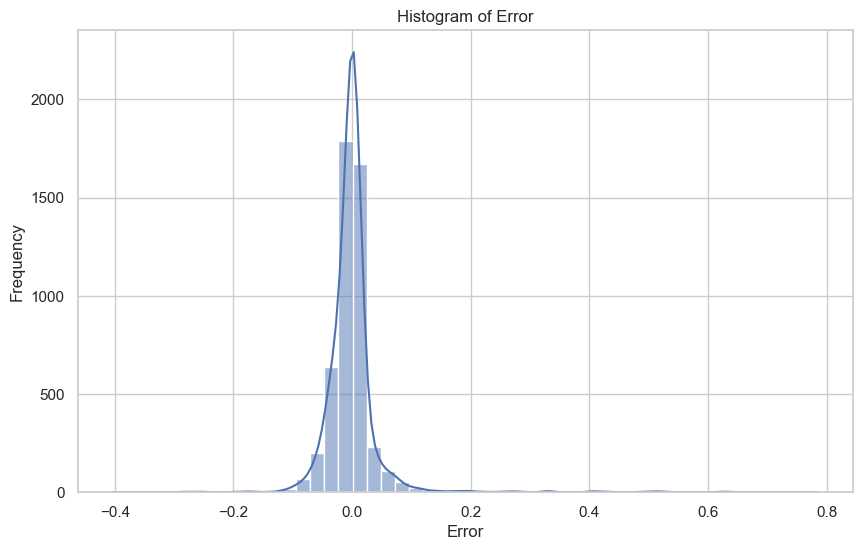

In [1347]:
# Plotting the histogram of the error
plt.figure(figsize=(10,6))
sns.histplot(error, kde=True, bins=50)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Histogram of Error')
plt.grid(True)
plt.show()

# Residuals reflect symmetric distribution around 0

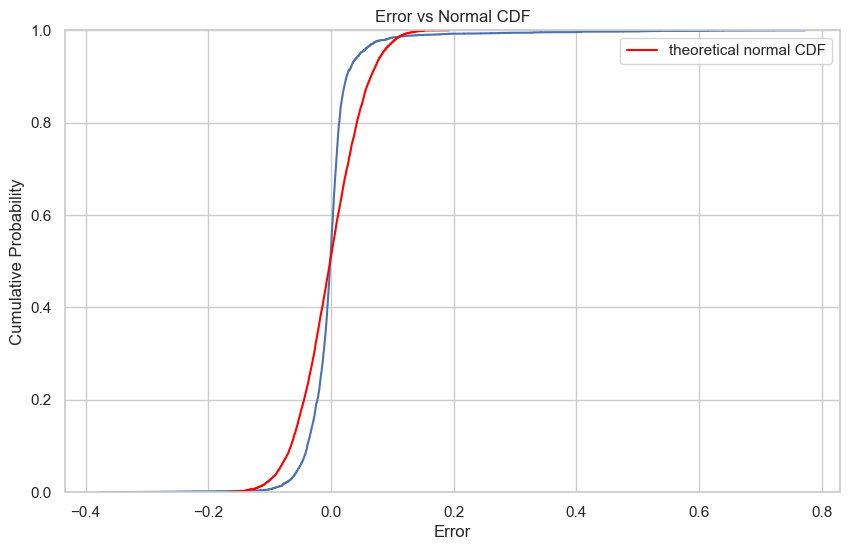

In [659]:
# Plot the error cdf versus the normal cdf
import scipy.stats as stats
plt.figure(figsize=(10,6))
sns.ecdfplot(error)
sns.ecdfplot(np.random.normal(np.mean(error), np.std(error), size=10000), label = 'theoretical normal CDF', color = 'red')
plt.xlabel('Error')
plt.ylabel('Cumulative Probability')
plt.title('Error vs Normal CDF')
plt.grid(True)
plt.legend()
plt.show()




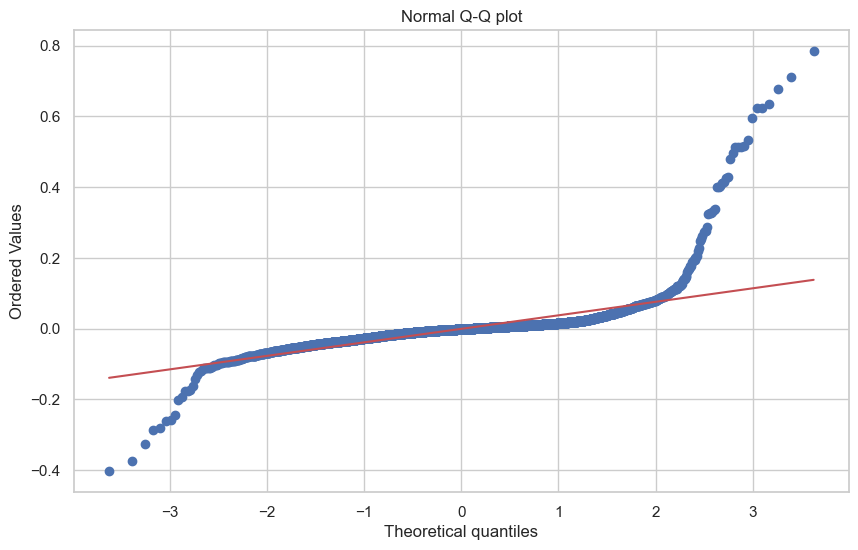

In [1348]:
# Q-Q plot
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
stats.probplot(error, dist="norm", plot=plt)
plt.title('Normal Q-Q plot')
plt.grid(True)
plt.show()

Visual inspection tells us that error is roughly normal.

In [1349]:
# lets save this model
import pickle
pickle.dump(reg_lgd_st_2, open('lgd_model_stage_2.sav', 'wb'))

To reach the actual LGD Model, we have to combine both stages.

# Combining Stage 1 and Stage 2

In [1350]:
lgd_inputs_stage1_test.shape

(8648, 20)

In [1351]:
lgd_inputs_stage2_test.shape

(4875, 20)

In [1360]:
y_hat_test_lgd_stage_2_all = reg_lgd_st_2.predict(lgd_inputs_stage1_test_scaled)
# Predicting the recovery rates by stage 2 models, using the inputs of stage 1 test data

/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RidgeRegression_with_p_values was fitted with feature names
  warnings.warn(


In [1361]:
y_hat_test_lgd_stage_2_all

array([0.09263937, 0.20276627, 0.10645617, ..., 0.17539847, 0.15103898,
       0.08243599])

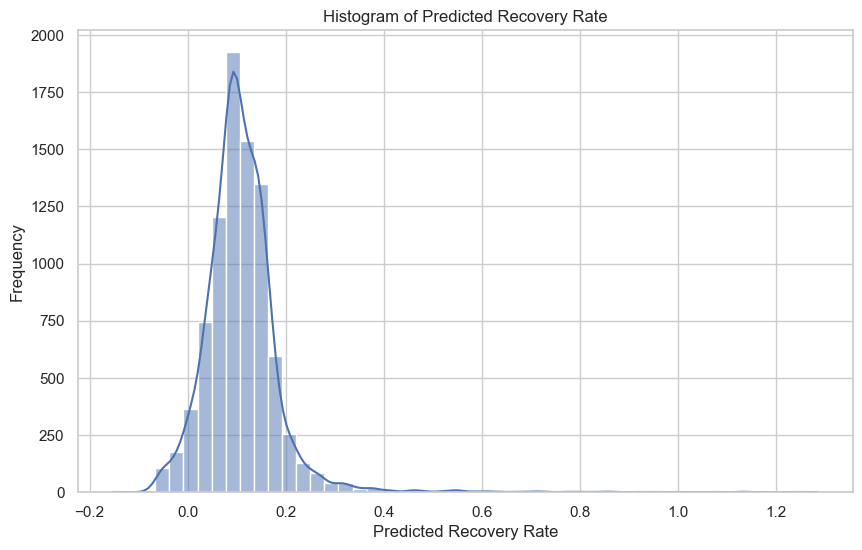

In [1362]:
# PLOT of y_hat_test_lgd_stage_2_all
plt.figure(figsize=(10,6))
sns.histplot(y_hat_test_lgd_stage_2_all, kde=True, bins=50)
plt.xlabel('Predicted Recovery Rate')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted Recovery Rate')
plt.grid(True)
plt.show()

* Every observation classified as 0 by the stage 1 logistic regression model has estimated recovery rate of 0

* Every observation classified as 1 by the stage 1 logistic regression model has estimated recovery rate as per the stage 2 linear model

We can simply multiply the two corresponding values from the two models to reach this recovery rate.


In [1363]:
y_hat_test_lgd_stage_1.shape

(8648,)

The Predicted Recovery Rate = Predicted Recovery Class ( 0 or 1) from stage 1 * Predicted Recovery Rate from stage 2

In [1364]:
y_hat_test_lgd = y_hat_test_lgd_stage_1 * y_hat_test_lgd_stage_2_all

In [1365]:
pd.DataFrame(y_hat_test_lgd).describe()

,0
count,8648.000000
mean,0.077818
std,0.094705
min,-0.040258
25%,0.000000
50%,0.062615
75%,0.142070
max,1.284249


Some predicted values are less than 0 and greater than 1. We have to set them as 0 and 1 respectively.

In [1366]:
y_hat_test_lgd = np.where(y_hat_test_lgd > 1, 1, y_hat_test_lgd)
y_hat_test_lgd = np.where(y_hat_test_lgd < 0, 0, y_hat_test_lgd)

In [1367]:
pd.DataFrame(y_hat_test_lgd).describe()

,0
count,8648.000000
mean,0.077748
std,0.093579
min,0.000000
25%,0.000000
50%,0.062615
75%,0.142070
max,1.000000


# EAD Model

* Dependent variable is Credit Conversion factor(CCF) : The proportion from the original amount of the loan that is still outstanding at the moment when the borrower defaulted.

In [134]:
data = pd.read_csv('loan_data_defaults.csv')

In [135]:
data.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,...,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:w,term:60
0,1077430,2500,2500,2500.0,15.27,59.83,0.0,30000.0,1.00,0.0,...,0,0,0,0,0,0,0,0,0,1
1,1071795,5600,5600,5600.0,21.28,152.39,4.0,40000.0,5.55,0.0,...,0,0,0,0,0,0,0,0,0,1
2,1071570,5375,5375,5350.0,12.69,121.45,0.0,15000.0,18.08,0.0,...,1,0,0,0,0,0,0,0,0,1
3,1064687,9000,9000,9000.0,13.49,305.38,0.0,30000.0,10.08,0.0,...,0,0,1,0,0,0,0,0,0,0
4,1069057,10000,10000,10000.0,10.65,325.74,3.0,100000.0,7.06,0.0,...,0,0,0,0,0,0,0,0,0,0


# Can We Model PD, LGD, and EAD Using Different Variables for ECL Computation?

Yes, PD (Probability of Default), LGD (Loss Given Default), and EAD (Exposure at Default) can be modeled using different variables for Expected Credit Loss (ECL) computation. In fact, using different predictors for each component is a best practice in credit risk modeling because:

✅ PD, LGD, and EAD are distinct risk components → Each is influenced by different factors.

✅ Using different variables improves model accuracy → Helps in reducing bias and overfitting.

✅ Regulatory compliance (IFRS 9, Basel II/III) → Allows for separate, optimized models.

In [137]:
# Lets again train,test split the data
from sklearn.model_selection import train_test_split
ead_inputs_train,ead_inputs_test,ead_targets_train,ead_targets_test = train_test_split(data.drop(['recovery_rate','recovery_rate_0_1','ccf','id'], axis=1), data['ccf'], test_size=0.2, random_state=42)

In [138]:
ead_inputs_train.shape

(34588, 113)

 We already know that the columns are multicolinear, as shown by VIF. 

So we will use Ridge regression with RidgeCV for best alpha

In [139]:
# Scaling the data
scaler = StandardScaler()
ead_inputs_train_scaled = scaler.fit_transform(ead_inputs_train)
ead_inputs_test_scaled = scaler.transform(ead_inputs_test)

In [140]:
X = pd.DataFrame(ead_inputs_train_scaled, columns = ead_inputs_train.columns.values)
y = ead_targets_train.values

In [141]:
# Run ridge regression with RidgeCV
reg_ead = RidgeRegression_with_p_values(alphas = np.logspace(-6, 6, 13), cv=5)
reg_ead.fit(X, y)
# ALSO print best alpha
print("Best alpha:", reg_ead.alpha_)

Best alpha: 10.0


In [142]:
# Find coefficients and p-values
feature_name = ead_inputs_train.columns.values
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg_ead.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg_ead.intercept_]
summary_table = summary_table.sort_index()
p_values = reg_ead.p_values
p_values = np.append(np.nan,np.array(p_values)) 
summary_table['p_values'] = p_values.round(3)
summary_table

,Feature name,Coefficients,p_values
0,Intercept,0.736447,NaN
1,loan_amnt,0.018692,0.000
2,funded_amnt,-0.038698,0.000
3,funded_amnt_inv,-0.045292,0.000
4,int_rate,-0.031843,0.000
...,...,...,...
109,addr_state:WI,0.000744,0.452
110,addr_state:WV,0.000809,0.216
111,addr_state:WY,0.000478,0.375
112,initial_list_status:w,0.000740,0.102


In [144]:
# Find significant features
summary_table = summary_table[summary_table['p_values'] < 0.05]
significant_features = summary_table['Feature name'].values
significant_features

array(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'emp_length', 'delinq_2yrs', 'inq_last_6mths',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'total_acc',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'collection_recovery_fee', 'last_pymnt_amnt',
       'tot_cur_bal', 'total_rev_hi_lim', 'months_since_issue_d',
       'months_since_last_pymnt_d', 'months_since_last_credit_pull_d',
       'months_since_next_pymnt_d', 'grade:B', 'grade:C', 'grade:D',
       'grade:E', 'grade:F', 'grade:G',
       'verification_status:Source Verified',
       'verification_status:Verified', 'purpose:credit_card',
       'purpose:debt_consolidation', 'purpose:home_improvement',
       'purpose:house', 'purpose:major_purchase', 'purpose:medical',
       'purpose:moving', 'purpose:other', 'purpose:renewable_energy',
       'purpose:small_business', 'purpose:wedding', 'addr_state:DE',
       'term:60'], dtype=object)

In [145]:
summary_table

,Feature name,Coefficients,p_values
1,loan_amnt,0.018692,0.000
2,funded_amnt,-0.038698,0.000
3,funded_amnt_inv,-0.045292,0.000
4,int_rate,-0.031843,0.000
5,installment,0.105017,0.000
6,emp_length,-0.001219,0.005
9,delinq_2yrs,-0.001038,0.033
10,inq_last_6mths,0.001799,0.000
12,mths_since_last_record,0.001644,0.000
13,open_acc,-0.004051,0.000


In [146]:
final_inputs_ead = [
       'recovery_rate_0_1',
       'recovery_rate',
         'ccf'      
] + significant_features.tolist()

In [147]:
final_data = data[final_inputs_ead]

In [148]:
# Lets again train,test split the data
from sklearn.model_selection import train_test_split
ead_inputs_train,ead_inputs_test,ead_targets_train,ead_targets_test = train_test_split(final_data.drop(['recovery_rate','recovery_rate_0_1','ccf'], axis=1), final_data['ccf'], test_size=0.2, random_state=42)

In [149]:
ead_inputs_train.shape

(34588, 45)

In [150]:
# Scaling the data
scaler = StandardScaler()
ead_inputs_train_scaled = scaler.fit_transform(ead_inputs_train)
ead_inputs_test_scaled = scaler.transform(ead_inputs_test)

In [151]:
X = pd.DataFrame(ead_inputs_train_scaled, columns = ead_inputs_train.columns.values)
y = ead_targets_train.values

In [152]:
# Run ridge regression with RidgeCV
reg_ead = RidgeRegression_with_p_values(alphas = np.logspace(-6, 6, 13), cv=5)
reg_ead.fit(X, y)
# ALSO print best alpha
print("Best alpha:", reg_ead.alpha_)

Best alpha: 10.0


In [153]:
# Find coefficients and p-values
feature_name = ead_inputs_train.columns.values
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg_ead.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg_ead.intercept_]
summary_table = summary_table.sort_index()
p_values = reg_ead.p_values
p_values = np.append(np.nan,np.array(p_values)) 
summary_table['p_values'] = p_values.round(3)
summary_table

,Feature name,Coefficients,p_values
0,Intercept,0.736447,NaN
1,loan_amnt,0.019389,0.000
2,funded_amnt,-0.039272,0.000
3,funded_amnt_inv,-0.044826,0.000
4,int_rate,-0.032497,0.000
5,installment,0.104877,0.000
6,emp_length,-0.001227,0.004
7,delinq_2yrs,-0.000446,0.291
8,inq_last_6mths,0.002048,0.000
9,mths_since_last_record,0.001489,0.001


In [154]:
# Lets save the ead model
import pickle
pickle.dump(reg_ead, open('ead_model.sav', 'wb'))

In [155]:
# Evaluation of the model
y_hat_test_ead = reg_ead.predict(ead_inputs_test_scaled)


/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RidgeRegression_with_p_values was fitted with feature names
  warnings.warn(


In [156]:
# Finding MSE, R^2
from sklearn.metrics import mean_squared_error, r2_score
MSE = mean_squared_error(ead_targets_test, y_hat_test_ead)
R_squared = r2_score(ead_targets_test, y_hat_test_ead)
print("Mean Squared Error:", MSE)
print("R^2 Score:", R_squared)

Mean Squared Error: 0.005976815780348613
R^2 Score: 0.8529666604273276


Thats a pretty high R^2 of 85%

In [157]:
# Finding correlations between actual and predicted values
ead_targets_test_temp = ead_targets_test
ead_targets_test_temp.reset_index(drop=True, inplace=True)
correlation_act_pred = pd.concat([ead_targets_test_temp, pd.DataFrame(y_hat_test_ead)], axis=1).corr()
# Change column names and row names
correlation_act_pred.columns = ['Actual CCF', 'Predicted CCF']
correlation_act_pred.index = ['Actual CCF', 'Predicted CCF']
correlation_act_pred

,Actual CCF,Predicted CCF
Actual CCF,1.000000,0.923637
Predicted CCF,0.923637,1.000000


Actual and Predicted CCF have high correlation of 92%

In [1391]:
reference_category

['addr_state:AK',
 'purpose:car',
 'verification_status:Not Verified',
 'home_ownership:MORTGAGE',
 'grade:A',
 'initial_list_status:f',
 'term:30']

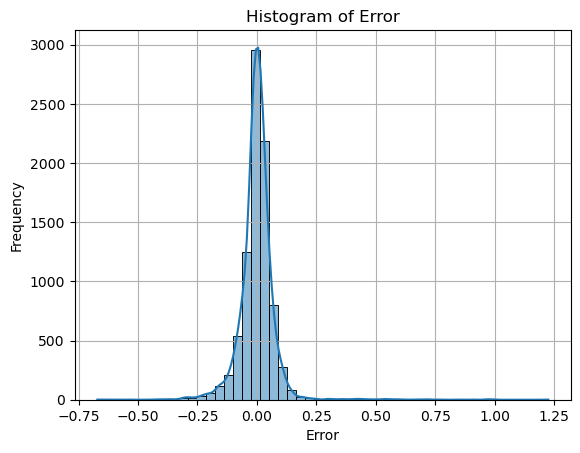

In [159]:
# plot the residuals histogram
import matplotlib.pyplot as plt
import seaborn as sns
error = ead_targets_test - y_hat_test_ead
sns.histplot(error, kde=True, bins=50)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Histogram of Error')
plt.grid(True)
plt.show()

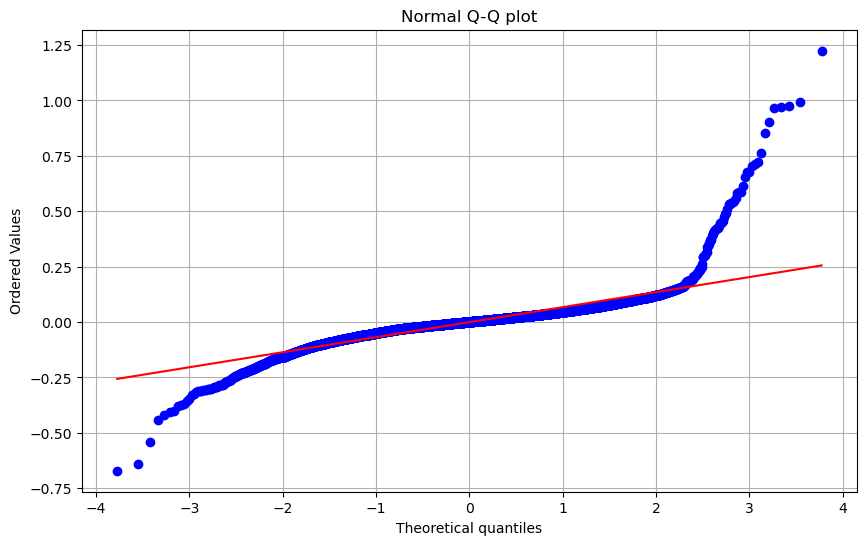

In [160]:
# Q-Q plot
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
stats.probplot(error, dist="norm", plot=plt)
plt.title('Normal Q-Q plot')
plt.grid(True)
plt.show()

Roughly, the data seems normal in the residuals

In [161]:
pd.DataFrame(y_hat_test_ead).describe()

,0
count,8648.000000
mean,0.734581
std,0.183932
min,-0.276334
25%,0.632776
50%,0.769333
75%,0.866778
max,1.085996


In [162]:
y_hat_test_ead = np.where(y_hat_test_ead > 1, 1, y_hat_test_ead)
y_hat_test_ead = np.where(y_hat_test_ead < 0, 0, y_hat_test_ead)

In [163]:
pd.DataFrame(y_hat_test_ead).describe()

,0
count,8648.000000
mean,0.733923
std,0.182315
min,0.000000
25%,0.632776
50%,0.769333
75%,0.866778
max,1.000000


# Expected Credit Loss

ECL = PD * LGD * EAD

# Should Expected Credit Loss (ECL) Be Computed for the Whole Dataset (Including Training & Testing Data)?

No, ECL should be computed only on the final model predictions, typically on the test (out-of-sample) or validation dataset. Here’s why:

✅ Training data is used to build the model, not for final ECL estimation.

✅ ECL should be computed on unseen data to ensure it generalizes well.

✅ Regulatory frameworks (IFRS 9, Basel III) recommend testing on out-of-time or out-of-sample data to avoid bias.

🔹 How Should ECL Be Computed?

ECL is calculated using the formula:


ECL=PD×LGD×EAD

📌 Correct Approach:

Train models on training data.

Validate models using validation data.

Compute ECL on the test dataset (new, unseen data).

📌 Incorrect Approach:

Computing ECL on the training data can lead to overfitting and unrealistically low risk estimates.

# When Can You Compute ECL on the Whole Dataset?

🔹 For Reporting Purposes: If you need to report total ECL, you may compute it on the entire portfolio after final model validation.

🔹 For Model Monitoring: Periodically check ECL trends over time across the full dataset.

Lets first enumerate all the models we have formulated so far:
1. PD Model :

    reg_pd

2. LGD Model :

    reg2_lgd_stage_1

    reg_lgd_st_2

3. EAD Model :

    reg_ead

 Now let us automate and integrate the entire process of PD, LGD and EAD so as to compute ECL
 
 We will first have the cleaned preprocessed data or its subset

 For each model, we shalL have a function which will take the data as input and return the out of that model in the form of
a dataframe with the predicted values 

We need a final data frame with id column and the predicted values of PD, LGD and EAD


In [54]:
# Lets upload the first data as first_data
import pandas as pd
import numpy as np
first_data = pd.read_csv('loan_data_2007_2014_cleaned.csv')

In [55]:
first_data.columns.to_list()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'loan_status',
 'purpose',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'months_since_earliest_cr',
 'months_since_issue_d',
 'months_since_last_pymnt_d',
 'months_since_last_credit_pull_d',
 'months_since_next_pymnt_d']

In [56]:
# first lets process the columns suiting the PD Model.
# We can form a function to do this
def process_columns_pd(data):

    loan_data = data.copy()

    loan_data['good_bad'] = np.where(loan_data['loan_status'].isin(['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off']), 0, 1) # Creating the good_bad column
    loan_data.drop('loan_status', axis=1, inplace=True) # Dropping the loan_status column
    loan_data['home_ownership'] = loan_data['home_ownership'].replace(['OTHER', 'RENT','NONE','ANY'], 'OTHER_RENT_NONE_ANY') # Replacing 'OTHER' and 'RENT' with 'OTHER_RENT'
    
    loan_data['addr_state_c'] = loan_data['addr_state'].replace(['NE', 'IA','NV'], 'NE_IA_NV')
    loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['FL','AL','MO','NM'],'FL_AL_MO_NM')
    loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['NJ','LA'],'NJ_LA')
    loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['NC','MD','KY','UT','MI'],'NC_MD_KY_UT_MI')
    loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['OK','VA','AZ','AR','DE'],'OK_VA_AZ_AR_DE')
    loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['PA','MN','OH'],'PA_MN_OH')
    loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['MA','WA','RI','TN','IN','GA','OR','WI','SD'],'MA_WA_RI_TN_IN_GA_OR_WI_SD')
    loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['ID','CT','IL','KS','CO','SC'],'ID_CT_IL_KS_CO_SC')
    loan_data['addr_state_c'] = loan_data['addr_state_c'].replace(['VT','AK','MT','NH','WY','MS','WV','DC','ME'],'VT_AK_MT_NH_WY_MS_WV_DC_ME')

    loan_data['months_since_issue_d_class :<38'] = np.where(loan_data['months_since_issue_d'] < 38, 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :38-40'] = np.where((loan_data['months_since_issue_d'] >= 38) & (loan_data['months_since_issue_d'] < 40), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :40-42'] = np.where((loan_data['months_since_issue_d'] >= 40) & (loan_data['months_since_issue_d'] < 42), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :42-44'] = np.where((loan_data['months_since_issue_d'] >= 42) & (loan_data['months_since_issue_d'] < 44), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :44-45'] = np.where((loan_data['months_since_issue_d'] >= 44) & (loan_data['months_since_issue_d'] < 45), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :45-49'] = np.where((loan_data['months_since_issue_d'] >= 45) & (loan_data['months_since_issue_d'] < 49), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :49-50'] = np.where((loan_data['months_since_issue_d'] >= 49) & (loan_data['months_since_issue_d'] < 50), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :50-51'] = np.where((loan_data['months_since_issue_d'] >= 50) & (loan_data['months_since_issue_d'] < 51), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :51-52'] = np.where((loan_data['months_since_issue_d'] >= 51) & (loan_data['months_since_issue_d'] < 52), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :52-54'] = np.where((loan_data['months_since_issue_d'] >= 52) & (loan_data['months_since_issue_d'] < 54), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :54-63'] = np.where((loan_data['months_since_issue_d'] >= 54) & (loan_data['months_since_issue_d'] < 63), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :63-76'] = np.where((loan_data['months_since_issue_d'] >= 63) & (loan_data['months_since_issue_d'] < 76), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :76-96'] = np.where((loan_data['months_since_issue_d'] >= 76) & (loan_data['months_since_issue_d'] < 96), 1, 0) # Creating a new column
    loan_data['months_since_issue_d_class :>=96'] = np.where(loan_data['months_since_issue_d'] >= 96, 1, 0) # Creating a new column

    loan_data['int_rate_class :5-9.6'] = np.where((loan_data['int_rate'] >= 5) & (loan_data['int_rate'] < 9.6), 1, 0) # Creating a new column
    loan_data['int_rate_class :9.6-12'] = np.where((loan_data['int_rate'] >= 9.6) & (loan_data['int_rate'] < 12), 1, 0) # Creating a new column
    loan_data['int_rate_class :12-14.5'] = np.where((loan_data['int_rate'] >= 12) & (loan_data['int_rate'] < 14.5), 1, 0) # Creating a new column
    loan_data['int_rate_class :14.5-16'] = np.where((loan_data['int_rate'] >= 14.5) & (loan_data['int_rate'] < 16), 1, 0) # Creating a new column
    loan_data['int_rate_class :16-20'] = np.where((loan_data['int_rate'] >= 16) & (loan_data['int_rate'] < 20), 1, 0) # Creating a new column
    loan_data['int_rate_class :>=20'] = np.where(loan_data['int_rate'] >= 20, 1, 0) # Creating a new column

    loan_data.drop(['funded_amnt'], axis=1, inplace=True)

    loan_data['months_since_earliest_cr_class :<171'] = np.where(loan_data['months_since_earliest_cr'] < 171, 1, 0) # Creating a new column
    loan_data['months_since_earliest_cr_class :171-253'] = np.where((loan_data['months_since_earliest_cr'] >= 171) & (loan_data['months_since_earliest_cr'] < 253), 1, 0) # Creating a new column
    loan_data['months_since_earliest_cr_class :253-432'] = np.where((loan_data['months_since_earliest_cr'] >= 253) & (loan_data['months_since_earliest_cr'] < 432), 1, 0) # Creating a new column
    loan_data['months_since_earliest_cr_class :432-562'] = np.where((loan_data['months_since_earliest_cr'] >= 432) & (loan_data['months_since_earliest_cr'] < 562), 1, 0) # Creating a new column
    loan_data['months_since_earliest_cr_class :>=562'] = np.where(loan_data['months_since_earliest_cr'] >= 562, 1, 0) # Creating a new column

    loan_data.drop(['installment'], axis=1, inplace=True) # Dropping the installment and installment_class

    loan_data['delinq_2yrs :<=3'] = np.where(loan_data['delinq_2yrs'] <= 3, 1, 0) # Creating a new column
    loan_data['delinq_2yrs :>3'] = np.where(loan_data['delinq_2yrs'] > 3, 1, 0) 

    loan_data['inq_last_6mths :0'] = np.where(loan_data['inq_last_6mths'] == 0, 1, 0) # Creating a new column
    loan_data['inq_last_6mths :1'] = np.where(loan_data['inq_last_6mths'] == 1, 1, 0) # Creating a new column
    loan_data['inq_last_6mths :2-4'] = np.where((loan_data['inq_last_6mths'] >= 2) & (loan_data['inq_last_6mths'] <= 4), 1, 0) # Creating a new column
    loan_data['inq_last_6mths :>=5'] = np.where(loan_data['inq_last_6mths'] >= 5, 1, 0) 
    
    loan_data['total_acc :<=5'] = np.where(loan_data['total_acc'] <= 5, 1, 0) # Creating a new column
    loan_data['total_acc :6-18'] = np.where((loan_data['total_acc'] >= 6) & (loan_data['total_acc'] <= 18), 1, 0) # Creating a new column
    loan_data['total_acc :19-52'] = np.where((loan_data['total_acc'] >= 19) & (loan_data['total_acc'] <= 52), 1, 0) # Creating a new column
    loan_data['total_acc :>=53'] = np.where(loan_data['total_acc'] >= 53, 1, 0)

    loan_data['annual_inc_class :<10000'] = np.where(loan_data['annual_inc'] < 10000, 1, 0) # Creating a new column
    loan_data['annual_inc_class :10000-22000'] = np.where((loan_data['annual_inc'] >= 10000) & (loan_data['annual_inc'] < 22000), 1, 0) # Creating a new column
    loan_data['annual_inc_class :22000-37000'] = np.where((loan_data['annual_inc'] >= 22000) & (loan_data['annual_inc'] < 37000), 1, 0) # Creating a new column
    loan_data['annual_inc_class :37000-46000'] = np.where((loan_data['annual_inc'] >= 37000) & (loan_data['annual_inc'] < 46000), 1, 0) # Creating a new column
    loan_data['annual_inc_class :46000-56000'] = np.where((loan_data['annual_inc'] >= 46000) & (loan_data['annual_inc'] < 56000), 1, 0) # Creating a new column
    loan_data['annual_inc_class :56000-76000'] = np.where((loan_data['annual_inc'] >= 56000) & (loan_data['annual_inc'] < 76000), 1, 0) # Creating a new column
    loan_data['annual_inc_class :76000-96000'] = np.where((loan_data['annual_inc'] >= 76000) & (loan_data['annual_inc'] < 96000), 1, 0) # Creating a new column
    loan_data['annual_inc_class :96000-114000'] = np.where((loan_data['annual_inc'] >= 96000) & (loan_data['annual_inc'] < 114000), 1, 0) # Creating a new column
    loan_data['annual_inc_class :114000-140000'] = np.where((loan_data['annual_inc'] >= 114000) & (loan_data['annual_inc'] < 140000), 1, 0) # Creating a new column
    loan_data['annual_inc_class :>=140000'] = np.where(loan_data['annual_inc'] >= 140000, 1, 0)

    loan_data['dti_class :<=1.6'] = np.where(loan_data['dti'] <= 1.6, 1, 0) # Creating a new column
    loan_data['dti_class :1.6-4'] = np.where((loan_data['dti'] > 1.6) & (loan_data['dti'] <= 4), 1, 0) # Creating a new column
    loan_data['dti_class :4-11.2'] = np.where((loan_data['dti'] > 4) & (loan_data['dti'] <= 11.2), 1, 0) # Creating a new column
    loan_data['dti_class :11.2-15.2'] = np.where((loan_data['dti'] > 11.2) & (loan_data['dti'] <= 15.2), 1, 0) # Creating a new column
    loan_data['dti_class :15.2-17.6'] = np.where((loan_data['dti'] > 15.2) & (loan_data['dti'] <= 17.6), 1, 0) # Creating a new column
    loan_data['dti_class :17.6-19.2'] = np.where((loan_data['dti'] > 17.6) & (loan_data['dti'] <= 19.2), 1, 0) # Creating a new column
    loan_data['dti_class :19.2-20.8'] = np.where((loan_data['dti'] > 19.2) & (loan_data['dti'] <= 20.8), 1, 0) # Creating a new column
    loan_data['dti_class :20.8-23.2'] = np.where((loan_data['dti'] > 20.8) & (loan_data['dti'] <= 23.2), 1, 0) # Creating a new column
    loan_data['dti_class :23.2-27.2'] = np.where((loan_data['dti'] > 23.2) & (loan_data['dti'] <= 27.2), 1, 0) # Creating a new column
    loan_data['dti_class :27.2-35.2'] = np.where((loan_data['dti'] > 27.2) & (loan_data['dti'] <= 35.2), 1, 0) # Creating a new column
    loan_data['dti_class :>35.2'] = np.where(loan_data['dti'] > 35.2, 1, 0) 

    loan_data['emp_length :0'] = np.where(loan_data['emp_length'] == 0, 1, 0) # Creating a new column
    loan_data['emp_length :1-4'] = np.where(loan_data['emp_length'].isin(range(1,5)), 1, 0) # Creating a new column
    loan_data['emp_length :5-7'] = np.where(loan_data['emp_length'].isin(range(5,8)), 1, 0) # Creating a new column
    loan_data['emp_length :8-9'] = np.where(loan_data['emp_length'].isin(range(8,10)), 1, 0) # Creating a new column
    loan_data['emp_length :10+'] = np.where(loan_data['emp_length'] >= 10, 1, 0)

    loan_data['revol_bal_class :<819'] = np.where(loan_data['revol_bal'] < 819, 1, 0) # Creating a new column
    loan_data['revol_bal_class :819-1639'] = np.where((loan_data['revol_bal'] >= 819) & (loan_data['revol_bal'] < 1639), 1, 0) # Creating a new column
    loan_data['revol_bal_class :1639-5734'] = np.where((loan_data['revol_bal'] >= 1639) & (loan_data['revol_bal'] < 5734), 1, 0) # Creating a new column
    loan_data['revol_bal_class :5734-12286'] = np.where((loan_data['revol_bal'] >= 5734) & (loan_data['revol_bal'] < 12286), 1, 0) # Creating a new column
    loan_data['revol_bal_class :12286-18019'] = np.where((loan_data['revol_bal'] >= 12286) & (loan_data['revol_bal'] < 18019), 1, 0) # Creating a new column
    loan_data['revol_bal_class :18019-22115'] = np.where((loan_data['revol_bal'] >= 18019) & (loan_data['revol_bal'] < 22115), 1, 0) # Creating a new column
    loan_data['revol_bal_class :22115-29486'] = np.where((loan_data['revol_bal'] >= 22115) & (loan_data['revol_bal'] < 29486), 1, 0) # Creating a new column
    loan_data['revol_bal_class :29486-40952'] = np.where((loan_data['revol_bal'] >= 29486) & (loan_data['revol_bal'] < 40952), 1, 0) # Creating a new column
    loan_data['revol_bal_class :>=40952'] = np.where(loan_data['revol_bal'] >= 40952, 1, 0) 

    loan_data['total_rev_hi_lim_class :<200000'] = np.where(loan_data['total_rev_hi_lim'] < 200000, 1, 0) # Creating a new column
    loan_data['total_rev_hi_lim_class :200000-600000'] = np.where((loan_data['total_rev_hi_lim'] >= 200000) & (loan_data['total_rev_hi_lim'] < 600000), 1, 0) # Creating a new column
    loan_data['total_rev_hi_lim_class :>=600000'] = np.where(loan_data['total_rev_hi_lim'] >= 600000, 1, 0) # Creating a new column

    loan_data['mths_since_last_record :<43'] = np.where(loan_data['mths_since_last_record'] < 43, 1, 0) # Creating a new column
    loan_data['mths_since_last_record :43-69'] = np.where((loan_data['mths_since_last_record'] >= 43) & (loan_data['mths_since_last_record'] < 69), 1, 0) # Creating a new column
    loan_data['mths_since_last_record :69-87'] = np.where((loan_data['mths_since_last_record'] >= 69) & (loan_data['mths_since_last_record'] < 87), 1, 0) # Creating a new column
    loan_data['mths_since_last_record :>=87'] = np.where(loan_data['mths_since_last_record'] >= 87, 1, 0) # Creating a new column

    loan_data['revol_util :<36'] = np.where(loan_data['revol_util'] < 36, 1, 0) # Creating a new column
    loan_data['revol_util :36-70'] = np.where((loan_data['revol_util'] >= 36) & (loan_data['revol_util'] < 70), 1, 0) # Creating a new column
    loan_data['revol_util :70-124'] = np.where((loan_data['revol_util'] >= 70) & (loan_data['revol_util'] < 124), 1, 0) # Creating a new column
    loan_data['revol_util :>=124'] = np.where(loan_data['revol_util'] >= 124, 1, 0) #

    loan_data['tot_cur_bal :<16000'] = np.where(loan_data['tot_cur_bal'] < 16000, 1, 0) # Creating a new column
    loan_data['tot_cur_bal :16000-55000'] = np.where((loan_data['tot_cur_bal'] >= 16000) & (loan_data['tot_cur_bal'] < 55000), 1, 0) # Creating a new column
    loan_data['tot_cur_bal :55000-63000'] = np.where((loan_data['tot_cur_bal'] >= 55000) & (loan_data['tot_cur_bal'] < 63000), 1, 0) # Creating a new column
    loan_data['tot_cur_bal :63000-72000'] = np.where((loan_data['tot_cur_bal'] >= 63000) & (loan_data['tot_cur_bal'] < 72000), 1, 0) # Creating a new column
    loan_data['tot_cur_bal :72000-96000'] = np.where((loan_data['tot_cur_bal'] >= 72000) & (loan_data['tot_cur_bal'] < 96000), 1, 0) # Creating a new column
    loan_data['tot_cur_bal :96000-150000'] = np.where((loan_data['tot_cur_bal'] >= 96000) & (loan_data['tot_cur_bal'] < 150000), 1, 0) # Creating a new column
    loan_data['tot_cur_bal :>=150000'] = np.where(loan_data['tot_cur_bal'] >= 150000, 1, 0)

    non_numeric_columns_list = ['grade','home_ownership','verification_status','purpose','initial_list_status','addr_state_c']
    
    dummies_list = non_numeric_columns_list + ['term']
    
    for column in dummies_list:
        dummies = pd.get_dummies(loan_data[column], prefix=column, prefix_sep=':', drop_first=True, dtype=int)
        loan_data.drop(column, axis=1, inplace=True)
        loan_data = pd.concat([loan_data, dummies], axis=1)
        loan_data.reset_index(drop=True, inplace=True)
    

    return loan_data

In [57]:
pd_data = process_columns_pd(first_data)

In [193]:
final_inputs_pd = [

    'id',
    
    'months_since_issue_d_class :38-40',
 'months_since_issue_d_class :40-42',
 'months_since_issue_d_class :42-44',
 'months_since_issue_d_class :44-45',
 'months_since_issue_d_class :45-49',
 'months_since_issue_d_class :49-50',
 'months_since_issue_d_class :50-51',
 'months_since_issue_d_class :51-52',
 'months_since_issue_d_class :52-54',
 'months_since_issue_d_class :54-63',
 'months_since_issue_d_class :63-76',
 'months_since_issue_d_class :76-96',
 'months_since_issue_d_class :>=96',
 'int_rate_class :9.6-12',
 'int_rate_class :12-14.5',
 'int_rate_class :14.5-16',
 'int_rate_class :16-20',
 'int_rate_class :>=20',
 'months_since_earliest_cr_class :171-253',
 'months_since_earliest_cr_class :253-432',
 'months_since_earliest_cr_class :432-562',
 'months_since_earliest_cr_class :>=562',
 
 'inq_last_6mths :1',
 'inq_last_6mths :2-4',
 'inq_last_6mths :>=5',

 'annual_inc_class :10000-22000',
 'annual_inc_class :22000-37000',
 'annual_inc_class :37000-46000',
 'annual_inc_class :46000-56000',
 'annual_inc_class :56000-76000',
 'annual_inc_class :76000-96000',
 'annual_inc_class :96000-114000',
 'annual_inc_class :114000-140000',
 'annual_inc_class :>=140000',
 'dti_class :1.6-4',
 'dti_class :4-11.2',
 'dti_class :11.2-15.2',
 'dti_class :15.2-17.6',
 'dti_class :17.6-19.2',
 'dti_class :19.2-20.8',
 'dti_class :20.8-23.2',
 'dti_class :23.2-27.2',
 'dti_class :27.2-35.2',
 'dti_class :>35.2',
 'emp_length :1-4',
 'emp_length :5-7',
 'emp_length :8-9',
 'emp_length :10+',
 'revol_bal_class :819-1639',
 'revol_bal_class :1639-5734',
 'revol_bal_class :5734-12286',
 'revol_bal_class :12286-18019',
 'revol_bal_class :18019-22115',
 'revol_bal_class :22115-29486',
 'revol_bal_class :29486-40952',
 'revol_bal_class :>=40952',
 
 'mths_since_last_record :43-69',
 'mths_since_last_record :69-87',
 'mths_since_last_record :>=87',
 
 'tot_cur_bal :16000-55000',
 'tot_cur_bal :55000-63000',
 'tot_cur_bal :63000-72000',
 'tot_cur_bal :72000-96000',
 'tot_cur_bal :96000-150000',
 'tot_cur_bal :>=150000',

 'grade:B',
 'grade:C',
 'grade:D',
 'grade:E',
 'grade:F',
 'grade:G',

 'home_ownership:OTHER_RENT_NONE_ANY',
 'home_ownership:OWN',

 'verification_status:Source Verified',
 'verification_status:Verified',

 'purpose:credit_card',
 'purpose:debt_consolidation',
 'purpose:educational',
 'purpose:home_improvement',
 'purpose:house',
 'purpose:major_purchase',
 'purpose:medical',
 'purpose:moving',
 'purpose:other',
 'purpose:renewable_energy',
 'purpose:small_business',
 'purpose:vacation',
 'purpose:wedding',

 'initial_list_status:w',

 'addr_state_c:FL_AL_MO_NM',
 'addr_state_c:HI',
 'addr_state_c:ID_CT_IL_KS_CO_SC',
 'addr_state_c:MA_WA_RI_TN_IN_GA_OR_WI_SD',
 'addr_state_c:NC_MD_KY_UT_MI',
 'addr_state_c:NE_IA_NV',
 'addr_state_c:NJ_LA',
 'addr_state_c:NY',
 'addr_state_c:OK_VA_AZ_AR_DE',
 'addr_state_c:PA_MN_OH',
 'addr_state_c:TX',
 'addr_state_c:VT_AK_MT_NH_WY_MS_WV_DC_ME'
     
]

In [194]:
X_pd = pd_data[final_inputs_pd]



In [195]:
# Lets upload the saved model reg_pd
# How to use saved model?
import pickle
reg_pd = pickle.load(open('model.pkl', 'rb'))


In [196]:
X_pd['PD'] = reg_pd.model.predict_proba(X_pd.drop(['id'], axis = 1))[:,1]


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_30396/3503369059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_pd['PD'] = reg_pd.model.predict_proba(X_pd.drop(['id'], axis = 1))[:,1]


In [197]:
X_pd = X_pd[['id','PD']]

In [86]:
def process_columns_lgd(data):

    loan_data = data.copy()

    def create_dummies(column, loan_data):
        dummies = pd.get_dummies(loan_data[column], prefix=column, prefix_sep=':', drop_first=True, dtype=int) # Creating dummy variables
        loan_data.drop(column, axis=1, inplace=True) # Dropping the original column
        loan_data = pd.concat([loan_data, dummies], axis=1) # Concatenating the dummy variables to the DataFrame
        loan_data.reset_index(drop=True, inplace=True)
        return loan_data # Returning the updated DataFrame
    
    dummies_list = ['grade','home_ownership','verification_status','purpose','addr_state','initial_list_status','term']
    
    for column in dummies_list:
        loan_data = create_dummies(column, loan_data)

    return loan_data


In [94]:
lgd_data = process_columns_lgd(first_data)

In [93]:
lgd_inputs = ['id', 'funded_amnt_inv', 'int_rate', 'installment', 'inq_last_6mths',
       'pub_rec', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'collection_recovery_fee', 'last_pymnt_amnt',
       'months_since_earliest_cr', 'months_since_issue_d',
       'months_since_last_pymnt_d', 'months_since_last_credit_pull_d',
       'months_since_next_pymnt_d', 'home_ownership:OWN',
       'purpose:educational', 'initial_list_status:w', 'term:60']

In [95]:
lgd_data = lgd_data[lgd_inputs]

In [96]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_lgd = lgd_data

In [92]:
# import the model of lgd stage 1
import pickle
reg_lgd_1 = pickle.load(open('lgd_model_stage_1.sav', 'rb'))

In [100]:
X_lgd_1 = reg_lgd_1.predict(scaler.fit_transform(X_lgd.drop(['id'],axis =1)))

In [101]:
X_lgd_1 = pd.DataFrame(X_lgd_1, columns = ['Recovery_0_1'])

In [104]:
X_lgd_1.value_counts()

Recovery_0_1
1               432380
0                33905
Name: count, dtype: int64

In [107]:
lgd_data['Recovery_0_1'] = X_lgd_1['Recovery_0_1']
lgd_data.head()

,id,funded_amnt_inv,int_rate,installment,inq_last_6mths,pub_rec,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,...,months_since_earliest_cr,months_since_issue_d,months_since_last_pymnt_d,months_since_last_credit_pull_d,months_since_next_pymnt_d,home_ownership:OWN,purpose:educational,initial_list_status:w,term:60,Recovery_0_1
0,1077501,4975.0,10.65,162.87,1.0,0.0,5861.071414,5831.78,5000.00,861.07,...,395.0,72.0,35.0,23.0,22.0,0,0,0,0,1
1,1077430,2500.0,15.27,59.83,5.0,0.0,1008.710000,1008.71,456.46,435.17,...,224.0,72.0,56.0,51.0,22.0,0,0,0,1,1
2,1077175,2400.0,15.96,84.33,2.0,0.0,3003.653644,3003.65,2400.00,603.65,...,193.0,72.0,42.0,23.0,22.0,0,0,0,0,1
3,1076863,10000.0,13.49,339.31,1.0,0.0,12226.302210,12226.30,10000.00,2209.33,...,262.0,72.0,35.0,35.0,22.0,0,0,0,0,1
4,1075358,3000.0,12.69,67.79,0.0,0.0,3242.170000,3242.17,2233.10,1009.07,...,263.0,72.0,23.0,23.0,22.0,0,0,0,1,1


In [116]:
lgd_inputs_2 = ['id','funded_amnt_inv', 'int_rate','installment','inq_last_6mths','pub_rec','total_pymnt','total_pymnt_inv','total_rec_prncp',
'total_rec_int','collection_recovery_fee','last_pymnt_amnt','months_since_earliest_cr','months_since_issue_d', 'months_since_last_pymnt_d',
'months_since_last_credit_pull_d', 'months_since_next_pymnt_d','home_ownership:OWN','purpose:educational','initial_list_status:w','term:60'
]

In [117]:
lgd_data_2 = lgd_data[lgd_inputs_2]
lgd_data_2.head()

,id,funded_amnt_inv,int_rate,installment,inq_last_6mths,pub_rec,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,...,last_pymnt_amnt,months_since_earliest_cr,months_since_issue_d,months_since_last_pymnt_d,months_since_last_credit_pull_d,months_since_next_pymnt_d,home_ownership:OWN,purpose:educational,initial_list_status:w,term:60
0,1077501,4975.0,10.65,162.87,1.0,0.0,5861.071414,5831.78,5000.00,861.07,...,171.62,395.0,72.0,35.0,23.0,22.0,0,0,0,0
1,1077430,2500.0,15.27,59.83,5.0,0.0,1008.710000,1008.71,456.46,435.17,...,119.66,224.0,72.0,56.0,51.0,22.0,0,0,0,1
2,1077175,2400.0,15.96,84.33,2.0,0.0,3003.653644,3003.65,2400.00,603.65,...,649.91,193.0,72.0,42.0,23.0,22.0,0,0,0,0
3,1076863,10000.0,13.49,339.31,1.0,0.0,12226.302210,12226.30,10000.00,2209.33,...,357.48,262.0,72.0,35.0,35.0,22.0,0,0,0,0
4,1075358,3000.0,12.69,67.79,0.0,0.0,3242.170000,3242.17,2233.10,1009.07,...,67.79,263.0,72.0,23.0,23.0,22.0,0,0,0,1


In [118]:
# import the model of lgd stage 1
import pickle
reg_lgd_2 = pickle.load(open('lgd_model_stage_2.sav', 'rb'))

In [119]:
X_lgd_2 = reg_lgd_2.predict(scaler.fit_transform(lgd_data_2.drop(['id'],axis =1)))

/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RidgeRegression_with_p_values was fitted with feature names
  warnings.warn(


In [122]:
X_lgd_2 = pd.DataFrame(X_lgd_2,columns = ['Recovery Rate'])

In [125]:
X_lgd_2.describe()

,Recovery Rate
count,466285.000000
mean,0.108100
std,0.070423
min,-0.207999
25%,0.075616
50%,0.112860
75%,0.152309
max,1.427152


In [126]:
X_lgd_2 = np.where(X_lgd_2 >1,1,X_lgd_2)
X_lgd_2 = np.where(X_lgd_2 <0,0,X_lgd_2)

In [129]:
X_lgd_2 = pd.DataFrame(X_lgd_2,columns = ['Recovery Rate'])
X_lgd_2.describe()

,Recovery Rate
count,466285.000000
mean,0.111767
std,0.062120
min,0.000000
25%,0.075616
50%,0.112860
75%,0.152309
max,1.000000


In [131]:
lgd_data['Pred Recovery Rate'] = X_lgd_2['Recovery Rate']* lgd_data['Recovery_0_1']
lgd_data.head()

,id,funded_amnt_inv,int_rate,installment,inq_last_6mths,pub_rec,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,...,months_since_last_pymnt_d,months_since_last_credit_pull_d,months_since_next_pymnt_d,home_ownership:OWN,purpose:educational,initial_list_status:w,term:60,Recovery_0_1,Recovery Rate,Pred Recovery Rate
0,1077501,4975.0,10.65,162.87,1.0,0.0,5861.071414,5831.78,5000.00,861.07,...,35.0,23.0,22.0,0,0,0,0,1,0.114751,0.114751
1,1077430,2500.0,15.27,59.83,5.0,0.0,1008.710000,1008.71,456.46,435.17,...,56.0,51.0,22.0,0,0,0,1,1,0.093240,0.093240
2,1077175,2400.0,15.96,84.33,2.0,0.0,3003.653644,3003.65,2400.00,603.65,...,42.0,23.0,22.0,0,0,0,0,1,0.117182,0.117182
3,1076863,10000.0,13.49,339.31,1.0,0.0,12226.302210,12226.30,10000.00,2209.33,...,35.0,35.0,22.0,0,0,0,0,1,0.109395,0.109395
4,1075358,3000.0,12.69,67.79,0.0,0.0,3242.170000,3242.17,2233.10,1009.07,...,23.0,23.0,22.0,0,0,0,1,1,0.071331,0.071331


In [132]:
lgd_data = lgd_data[['id','Pred Recovery Rate']]

In [133]:
lgd_data.head()

,id,Pred Recovery Rate
0,1077501,0.114751
1,1077430,0.093240
2,1077175,0.117182
3,1076863,0.109395
4,1075358,0.071331


EAD = total funded amount * credit conversion factor


In [182]:
ead_inputs = ['id','loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'emp_length', 'delinq_2yrs', 'inq_last_6mths',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'total_acc',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'collection_recovery_fee', 'last_pymnt_amnt',
       'tot_cur_bal', 'total_rev_hi_lim', 'months_since_issue_d',
       'months_since_last_pymnt_d', 'months_since_last_credit_pull_d',
       'months_since_next_pymnt_d', 'grade:B', 'grade:C', 'grade:D',
       'grade:E', 'grade:F', 'grade:G',
       'verification_status:Source Verified',
       'verification_status:Verified', 'purpose:credit_card',
       'purpose:debt_consolidation', 'purpose:home_improvement',
       'purpose:house', 'purpose:major_purchase', 'purpose:medical',
       'purpose:moving', 'purpose:other', 'purpose:renewable_energy',
       'purpose:small_business', 'purpose:wedding', 'addr_state:DE',
       'term:60']

In [183]:
ead_data = process_columns_lgd(first_data)

In [184]:
ead_data = ead_data[ead_inputs]

In [185]:
X_ead = reg_ead.predict(scaler.fit_transform(ead_data.drop(['id'],axis =1)))
X_ead = pd.DataFrame(X_ead,columns = ['Pred CCF'])  


/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RidgeRegression_with_p_values was fitted with feature names
  warnings.warn(


In [186]:
X_ead.describe()

,Pred CCF
count,466285.000000
mean,0.736447
std,0.180958
min,-0.244086
25%,0.610037
50%,0.748102
75%,0.855768
max,1.483274


In [187]:
X_ead['Pred CCF'] = np.where(X_ead['Pred CCF'] > 1, 1, X_ead['Pred CCF'])
X_ead['Pred CCF'] = np.where(X_ead['Pred CCF'] < 0, 0, X_ead['Pred CCF'])
X_ead.describe()

,Pred CCF
count,466285.000000
mean,0.731752
std,0.172272
min,0.000000
25%,0.610037
50%,0.748102
75%,0.855768
max,1.000000


In [188]:
ead_data['Pred EAD'] = X_ead['Pred CCF'] * ead_data['funded_amnt']
ead_data.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,emp_length,delinq_2yrs,inq_last_6mths,mths_since_last_record,...,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:wedding,addr_state:DE,term:60,Pred EAD
0,1077501,5000,5000,4975.0,10.65,162.87,10.0,0.0,1.0,82.0,...,0,0,0,0,0,0,0,0,0,2259.458876
1,1077430,2500,2500,2500.0,15.27,59.83,0.0,0.0,5.0,74.0,...,0,0,0,0,0,0,0,0,1,2369.048354
2,1077175,2400,2400,2400.0,15.96,84.33,10.0,0.0,2.0,74.0,...,0,0,0,0,0,1,0,0,0,1345.425462
3,1076863,10000,10000,10000.0,13.49,339.31,10.0,0.0,1.0,74.0,...,0,0,0,1,0,0,0,0,0,4620.150515
4,1075358,3000,3000,3000.0,12.69,67.79,1.0,0.0,0.0,82.0,...,0,0,0,1,0,0,0,0,1,1326.608967


In [189]:
ead_data = ead_data[['id','Pred EAD']]

In [190]:
ead_data.head()

,id,Pred EAD
0,1077501,2259.458876
1,1077430,2369.048354
2,1077175,1345.425462
3,1076863,4620.150515
4,1075358,1326.608967


In [198]:
X_pd.head()

,id,PD
0,1077501,0.838522
1,1077430,0.633953
2,1077175,0.718708
3,1076863,0.818128
4,1075358,0.887491


In [199]:
lgd_data.head()

,id,Pred Recovery Rate
0,1077501,0.114751
1,1077430,0.093240
2,1077175,0.117182
3,1076863,0.109395
4,1075358,0.071331


In [201]:
# Lets merge the 3 dataframes based on id
import pandas as pd
import numpy as np
ECL_data = pd.merge(X_pd, lgd_data, how = 'inner',on = 'id')

In [202]:
ECL_data = pd.merge(ECL_data, ead_data, how = 'inner',on = 'id')

In [203]:
ECL_data.shape

(466285, 4)

In [204]:
ECL_data.head()

,id,PD,Pred Recovery Rate,Pred EAD
0,1077501,0.838522,0.114751,2259.458876
1,1077430,0.633953,0.093240,2369.048354
2,1077175,0.718708,0.117182,1345.425462
3,1076863,0.818128,0.109395,4620.150515
4,1075358,0.887491,0.071331,1326.608967


In [205]:
ECL_data['LGD'] = 1 - ECL_data['Pred Recovery Rate']

In [206]:
ECL_data['ECL'] = ECL_data['PD'] * ECL_data['LGD'] * ECL_data['Pred EAD']

In [207]:
ECL_data['ECL'].describe()

count    466285.000000
mean       8734.133632
std        6495.575831
min           0.000000
25%        4110.368019
50%        6986.243876
75%       11272.432143
max       34834.962533
Name: ECL, dtype: float64

In [208]:
Total_ECL = ECL_data['ECL'].sum()

In [209]:
Total_ECL

4072595500.408924

In [218]:
Total_ECL/first_data['funded_amnt'].sum()

0.6111289685916149

In [212]:
first_data['loan_amnt'].sum()

6675931775

In [214]:
ECL_data.head()

,id,PD,Pred Recovery Rate,Pred EAD,LGD,ECL
0,1077501,0.838522,0.114751,2259.458876,0.885249,1677.199277
1,1077430,0.633953,0.093240,2369.048354,0.906760,1361.830832
2,1077175,0.718708,0.117182,1345.425462,0.882818,853.657389
3,1076863,0.818128,0.109395,4620.150515,0.890605,3366.372185
4,1075358,0.887491,0.071331,1326.608967,0.928669,1093.371713


In [215]:
ECL_data = pd.merge(ECL_data, first_data[['funded_amnt','id']],how = 'inner',on = 'id')

In [217]:
ECL_data['ECL proportion'] = ECL_data['ECL']/ECL_data['funded_amnt']
ECL_data['ECL proportion'].describe()

count    466285.000000
mean          0.593849
std           0.171890
min           0.000000
25%           0.462555
50%           0.591074
75%           0.714407
max           0.995285
Name: ECL proportion, dtype: float64